# Objective of This Notebook

The objective of this notebook is to transform the cleaned financial statement dataset into a business-focused KPI dataset suitable for clustering analysis. KPI engineering will be performed using a configurable KPI definition framework, allowing financial metrics to be calculated dynamically from the underlying financial statement data.

Once the KPI dataset has been generated, the notebook will evaluate data quality, prepare the features for modelling, and apply dimensionality reduction and clustering techniques to identify groups of financially similar companies. The resulting clusters will serve as the foundation for automated peer benchmarking and subsequent business interpretation.

# **1. Notebook Setup**

### **1.1 Imports**

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

### **1.2 Notebook Configuration**

In [2]:
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

# Plot settings
plt.style.use("default")

plt.rcParams["figure.figsize"] = (12, 6)

np.random.seed(RANDOM_STATE)

### **1.3 Paths**

In [3]:
PROJECT_ROOT = Path().resolve().parent

DATA_DIR = PROJECT_ROOT / "data"

RAW_DATA_DIR = DATA_DIR / "raw"
INTERIM_DATA_DIR = DATA_DIR / "interim"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"

SRC_DIR = PROJECT_ROOT / "src"

# Add project root to Python path
sys.path.append(str(PROJECT_ROOT))

### **1.4 Project Imports**

In [4]:
from src.features.kpi_engine import (
    load_kpi_definitions,
    validate_kpi_definitions,
    calculate_kpis,
)

# **2. Dataset Overview**

### **2.1 Load Clean Dataset**

Here we load the final output from Notebook #2

In [5]:
financials_df = pd.read_excel(
    INTERIM_DATA_DIR / "clean_financials_with_metadata.xlsx"
)

print(f"Dataset shape: {financials_df.shape}")

financials_df.head()

Dataset shape: (4576, 222)


,Symbol,Company Name,Exchange,Sector,Industry,Employees,MarketCap,EnterpriseValue,Tax Effect Of Unusual Items,Tax Rate For Calcs,Normalized EBITDA,Total Unusual Items,Total Unusual Items Excluding Goodwill,Net Income From Continuing Operation Net Minority Interest,Reconciled Depreciation,Reconciled Cost Of Revenue,EBITDA,EBIT,Net Interest Income,Interest Expense,Interest Income,Normalized Income,Net Income From Continuing And Discontinued Operation,Total Expenses,Total Operating Income As Reported,Diluted Average Shares,Basic Average Shares,Diluted EPS,Basic EPS,Diluted NI Availto Com Stockholders,Net Income Common Stockholders,Net Income,Net Income Including Noncontrolling Interests,Net Income Continuous Operations,Tax Provision,Pretax Income,Other Income Expense,Other Non Operating Income Expenses,Special Income Charges,Other Special Charges,Impairment Of Capital Assets,Gain On Sale Of Security,Net Non Operating Interest Income Expense,Interest Expense Non Operating,Interest Income Non Operating,Operating Income,Operating Expense,Depreciation Amortization Depletion Income Statement,Depreciation And Amortization In Income Statement,Research And Development,Selling General And Administration,Selling And Marketing Expense,General And Administrative Expense,Other Gand A,Gross Profit,Cost Of Revenue,Total Revenue,Operating Revenue,Treasury Shares Number,Ordinary Shares Number,Share Issued,Net Debt,Total Debt,Tangible Book Value,Invested Capital,Working Capital,Net Tangible Assets,Capital Lease Obligations,Common Stock Equity,Total Capitalization,Total Equity Gross Minority Interest,Stockholders Equity,Gains Losses Not Affecting Retained Earnings,Other Equity Adjustments,Retained Earnings,Additional Paid In Capital,Capital Stock,Common Stock,Preferred Stock,Total Liabilities Net Minority Interest,Total Non Current Liabilities Net Minority Interest,Other Non Current Liabilities,Non Current Deferred Liabilities,Non Current Deferred Taxes Liabilities,Long Term Debt And Capital Lease Obligation,Long Term Capital Lease Obligation,Long Term Debt,Current Liabilities,Other Current Liabilities,Current Deferred Liabilities,Current Deferred Revenue,Current Debt And Capital Lease Obligation,Current Debt,Other Current Borrowings,Payables And Accrued Expenses,Current Accrued Expenses,Payables,Total Tax Payable,Income Tax Payable,Accounts Payable,Total Assets,Total Non Current Assets,Other Non Current Assets,Non Current Deferred Assets,Non Current Deferred Taxes Assets,Goodwill And Other Intangible Assets,Other Intangible Assets,Goodwill,Net PPE,Accumulated Depreciation,Gross PPE,Leases,Other Properties,Machinery Furniture Equipment,Properties,Current Assets,Other Current Assets,Receivables,Taxes Receivable,Accounts Receivable,Allowance For Doubtful Accounts Receivable,Gross Accounts Receivable,Cash Cash Equivalents And Short Term Investments,Cash And Cash Equivalents,Free Cash Flow,Repurchase Of Capital Stock,Repayment Of Debt,Issuance Of Debt,Capital Expenditure,Interest Paid Supplemental Data,Income Tax Paid Supplemental Data,End Cash Position,Beginning Cash Position,Effect Of Exchange Rate Changes,Changes In Cash,Financing Cash Flow,Cash Flow From Continuing Financing Activities,Net Other Financing Charges,Proceeds From Stock Option Exercised,Net Common Stock Issuance,Common Stock Payments,Net Issuance Payments Of Debt,Net Short Term Debt Issuance,Net Long Term Debt Issuance,Long Term Debt Payments,Long Term Debt Issuance,Investing Cash Flow,Cash Flow From Continuing Investing Activities,Net Business Purchase And Sale,Sale Of Business,Purchase Of Business,Net PPE Purchase And Sale,Purchase Of PPE,Capital Expenditure Reported,Operating Cash Flow,Cash Flow From Continuing Operating Activities,Change In Working Capital,Change In Other Working Capital,Change In Other Current Assets,Change In Payables And Accrued Expense,Change In Accrued Expense,Change In Payable,Change In Account Payable,Change In Tax Payable,Change In Income Tax Payable,Change

### **2.2 Dataset description**

In [6]:
# ==================================================
# Initial Dataset Validation
# ==================================================

print(f"Number of companies: {financials_df['Symbol'].nunique():,}")

print(f"Number of sectors: {financials_df['Sector'].nunique():,}")

print(f"Number of industries: {financials_df['Industry'].nunique():,}")

Number of companies: 4,576
Number of sectors: 11
Number of industries: 145


In [7]:
financials_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4576 entries, 0 to 4575
Columns: 222 entries, Symbol to Long Term Equity Investment
dtypes: float64(217), str(5)
memory usage: 7.8 MB


In [8]:
financials_df.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
Employees,4195.0,1.231073e+04,5.583885e+04,1.000000e+00,1.610000e+02,1.139000e+03,6.500000e+03,2.100000e+06
MarketCap,4570.0,2.108848e+10,1.729725e+11,1.308890e+05,1.516642e+08,1.159357e+09,6.347573e+09,5.189349e+12
EnterpriseValue,4512.0,7.891645e+10,2.608636e+12,-5.515685e+13,1.737587e+08,1.512113e+09,8.821250e+09,1.264616e+14
Tax Effect Of Unusual Items,4573.0,-3.105859e+08,1.463905e+10,-7.838690e+11,-1.765680e+06,0.000000e+00,0.000000e+00,2.348990e+11
Tax Rate For Calcs,4569.0,1.716604e-01,1.038284e-01,0.000000e+00,9.300000e-02,2.100000e-01,2.330000e-01,4.000000e-01
Normalized EBITDA,4048.0,3.270788e+10,1.788561e+12,-6.651988e+13,-5.521470e+06,6.408400e+07,6.144380e+08,7.343200e+13
Total Unusual Items,3626.0,-2.167490e+09,8.837795e+10,-3.919345e+12,-2.876875e+07,-1.314000e+06,1.049750e+06,8.945870e+11
Total Unusual Items Excluding Goodwill,3627.0,-2.167066e+09,8.836577e+10,-3.919345e+12,-2.878950e+07,-1.316000e+06,1.049500e+06,8.945870e+11
Net Income From Continuing Operation Net Minority Interest,4572.0,-5.395741e+09,1.513552e+12,-9.938466e+13,-2.243575e+07,1.190650e+07,2.339192e+08,1.748600e+13
Reconciled Depreciation,4472.0,2.465760e+10,6.815284e+11,-1.829000e+09,3.149193e+06,2.731600e+07,1.759378e+08,3.765300e+13


# **3. KPI Engineering**

### **3.1 Load KPI Definitions**

In [9]:
kpi_definitions_path = PROJECT_ROOT / "config" / "kpi_definitions.csv"

kpi_definitions = load_kpi_definitions(kpi_definitions_path)

print(f"Number of KPI definitions: {len(kpi_definitions)}")

kpi_definitions

Number of KPI definitions: 20


,ID,KPI,Category,UoM,What is better?,Formula,Required Fields,Include in Clustering
0,1,Gross Margin,Profitability,%,Bigger better,(`Total Revenue` - `Cost Of Revenue`) / `Total...,Total Revenue; Cost Of Revenue,Yes
1,2,Operating Margin,Profitability,%,Bigger better,`Operating Income` / `Total Revenue`,Operating Income; Total Revenue,Yes
2,3,Net Margin,Profitability,%,Bigger better,`Net Income` / `Total Revenue`,Net Income; Total Revenue,Yes
3,4,EBITDA Margin,Profitability,%,Bigger better,`EBITDA` / `Total Revenue`,EBITDA; Total Revenue,Yes
4,5,Return on Assets,Profitability,%,Bigger better,`Net Income` / `Total Assets`,Net Income; Total Assets,Yes
5,6,Return on Equity,Profitability,%,Bigger better,`Net Income` / `Stockholders Equity`,Net Income; Stockholders Equity,Yes
6,7,Asset Turnover,Efficiency,Ratio,Bigger better,`Total Revenue` / `Total Assets`,Total Revenue; Total Assets,Yes
7,8,Revenue per Employee,Productivity,USD,Bigger better,`Total Revenue` / `Employees`,Total Revenue; Employees,Yes
8,9,Current Ratio,Liquidity,Ratio,Bigger better,`Current Assets` / `Current Liabilities`,Current Assets; Current Liabilities,Yes
9,10,Quick Ratio,Liquidity,Ratio,Bigger better,(`Current Assets` - `Inventory`) / `Current Li...,Current Assets; Inventory; Current Liabilities,Yes


### **3.2 Validate KPI Definitions**

In [10]:
kpi_validation = validate_kpi_definitions(
    data=financials_df,
    kpi_definitions=kpi_definitions
)

kpi_validation

,KPI,Required Fields,Missing Fields,Can Calculate
0,Gross Margin,"[Total Revenue, Cost Of Revenue]",[],True
1,Operating Margin,"[Operating Income, Total Revenue]",[],True
2,Net Margin,"[Net Income, Total Revenue]",[],True
3,EBITDA Margin,"[EBITDA, Total Revenue]",[],True
4,Return on Assets,"[Net Income, Total Assets]",[],True
5,Return on Equity,"[Net Income, Stockholders Equity]",[],True
6,Asset Turnover,"[Total Revenue, Total Assets]",[],True
7,Revenue per Employee,"[Total Revenue, Employees]",[],True
8,Current Ratio,"[Current Assets, Current Liabilities]",[],True
9,Quick Ratio,"[Current Assets, Inventory, Current Liabilities]",[],True


### **3.3 Calculate KPI**

In [11]:
kpi_df = calculate_kpis(
    data=financials_df,
    kpi_definitions=kpi_definitions
)

print(f"KPI dataset shape: {kpi_df.shape}")

kpi_df.head()

KPI dataset shape: (4576, 25)


,Symbol,Company Name,Exchange,Sector,Industry,Gross Margin,Operating Margin,Net Margin,EBITDA Margin,Return on Assets,Return on Equity,Asset Turnover,Revenue per Employee,Current Ratio,Quick Ratio,Cash Ratio,Debt to Equity,Debt Ratio,Equity Ratio,Operating Cash Flow Margin,Free Cash Flow Margin,Cash Conversion Ratio,Market Cap to Revenue,Enterprise Value to Revenue,Enterprise Value to EBITDA
0,ACCS,ACCESS Newswire Inc. Common Stock,AMEX,Communication Services,Advertising Agencies,0.765463,-0.071665,0.189708,0.046067,0.102186,0.141407,0.538650,2.485604e+05,0.882994,NaN,0.317152,0.094678,0.068418,0.722638,0.024670,0.016181,0.130040,1.084714,1.076394,23.365605
1,AGIG,Abundia Global Impact Group Inc. Common stock,AMEX,Utilities,Utilities - Renewable,-0.047454,-25.858421,-71.724291,-69.686045,-0.924561,-1.548945,0.012890,2.053160e+05,0.836948,NaN,0.721485,0.546426,0.326160,0.596897,-19.608939,-44.075759,0.273393,125.432738,97.566142,-1.400081
2,AIB,"BlockchAIn Digital Infrastructure, Inc Common ...",AMEX,Technology,Software - Application,0.189844,-0.048485,-0.045118,-0.001916,-0.048382,-0.106299,1.072338,6.172204e+06,0.397528,NaN,0.001749,0.010397,0.004732,0.455148,0.126155,0.124052,-2.796112,7.339492,6.117684,-3192.660184
3,AIRI,Air Industries Group Common Stock,AMEX,Industrials,Aerospace & Defense,0.170844,-0.007053,-0.027232,0.078817,-0.022373,-0.067965,0.821564,2.995062e+05,1.243726,0.332917,0.018077,1.604396,0.528142,0.329184,-0.028213,-0.097536,1.036015,0.307715,0.969575,12.301565
4,AMBO,Ambow Education Holding Ltd. American Deposito...,AMEX,Consumer Defensive,Education & Training Services,0.547576,0.011828,0.143521,0.103179,0.065349,0.164727,0.455328,2.309512e+05,2.201539,2.185335,0.168321,1.178788,0.467638,0.396711,0.014468,-0.089767,0.100809,0.746118,15.444388,149.685683


Joining back the Total Revenue and MarketCap as we need it after

In [12]:
print("Rows in financials_df:", len(financials_df))
print("Rows in kpi_df (before merge):", len(kpi_df))

# --- Merge Total Revenue into KPI dataframe ---
kpi_df = kpi_df.merge(
    financials_df[['Symbol', 'Total Revenue', 'MarketCap']],
    on='Symbol',
    how='left'
)

print("Rows in kpi_df (after merge):", len(kpi_df))


Rows in financials_df: 4576
Rows in kpi_df (before merge): 4576
Rows in kpi_df (after merge): 4576


# **4. Quality Control**

### **4.1 Business Eligibility Filtering (FILTER REVENUE HERE)**

In [13]:
MIN_REVENUE = 25_000_000 # 10M is reasonable but allows unstable margins that bias the data, 50M is too restrictive

eligible_kpi_df = kpi_df[
    kpi_df["Total Revenue"] >= MIN_REVENUE
].copy()

print(f"Companies before revenue eligibility filter: {len(kpi_df):,}")
print(f"Companies after revenue eligibility filter: {len(eligible_kpi_df):,}")

Companies before revenue eligibility filter: 4,576
Companies after revenue eligibility filter: 3,809


In [14]:
# Revenue Distribution Diagnostics

kpi_df["Total Revenue"].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75])

count    4.576000e+03
mean     1.800574e+11
std      3.734056e+12
min      5.500000e+02
1%       8.252400e+04
5%       2.000000e+06
10%      7.843546e+06
25%      6.852400e+07
50%      5.943835e+08
75%      3.379406e+09
max      1.467420e+14
Name: Total Revenue, dtype: float64

In [15]:
# Companies with extremely low revenue
low_revenue_companies = kpi_df[
    kpi_df["Total Revenue"] < MIN_REVENUE
].sort_values("Total Revenue")

low_revenue_companies[
    [
        "Symbol",
        "Company Name",
        "Sector",
        "Industry",
        "Total Revenue",
        "EBITDA Margin",
        "Free Cash Flow Margin",
        "MarketCap"
    ]
].head(30)

,Symbol,Company Name,Sector,Industry,Total Revenue,EBITDA Margin,Free Cash Flow Margin,MarketCap
1779,MYSE,"Myseum.AI, Inc. - Common Stock",Technology,Software - Application,550.0,-9845.523636,-8123.430909,9083049.0
226,ADTX,"Aditxt, Inc. - Common Stock",Healthcare,Biotechnology,3195.0,-12559.181847,-8044.476369,133811.0
589,CABR,"Caring Brands, Inc. - Common Stock",Healthcare,Drug Manufacturers - Specialty & Generic,4215.0,-731.915777,-401.484698,10546147.0
1284,HSCS,HeartSciences Inc. - Common Stock,Healthcare,Medical Devices,4350.0,-1870.533333,-1711.076322,5716536.0
2507,TCRT,"Alaunos Therapeutics, Inc. - Common Stock",Healthcare,Biotechnology,5000.0,-843.600000,-593.400000,7472966.0
650,CELZ,"Creative Medical Technology Holdings, Inc. - C...",Healthcare,Biotechnology,6000.0,-1003.247833,-976.074167,8335987.0
379,ASBP,"Aspire Biopharma Holdings, Inc. - Common Stock",Healthcare,Biotechnology,6202.0,-2571.682199,-793.854886,7162644.0
2690,VRAX,Virax Biolabs Group Limited - Ordinary Shares,Healthcare,Biotechnology,6331.0,-916.494551,-816.216396,1570798.0
317,AMOD,"Alpha Modus Holdings, Inc. - Class A Common Stock",Technology,Software - Application,7138.0,-565.927991,-450.859064,12459010.0
1177,GNLX,Genelux Corporation - Common Stock,Healthcare,Biotechnology,8000.0,-4080.000000,-3295.750000,137660080.0


In [16]:
for threshold in [1_000_000, 5_000_000, 10_000_000, 25_000_000, 50_000_000, 100_000_000]:
    count = (kpi_df["Total Revenue"] >= threshold).sum()
    print(f"Revenue >= ${threshold:,.0f}: {count:,} companies")

Revenue >= $1,000,000: 4,412 companies
Revenue >= $5,000,000: 4,209 companies
Revenue >= $10,000,000: 4,071 companies
Revenue >= $25,000,000: 3,809 companies
Revenue >= $50,000,000: 3,556 companies
Revenue >= $100,000,000: 3,234 companies


So the dataset contains a long tail of very low-revenue public companies. Many of them are biotech, pre-commercial healthcare, early-stage tech, or distressed/special-case companies. Their financial ratios explode because the denominator is tiny.

### **4.2 Revenue Eligibility by Sector**

In [17]:
# ==================================================
# Revenue Eligibility by Sector
# ==================================================

revenue_eligibility_by_sector = (
    kpi_df
    .assign(IsEligible=lambda df: df["Total Revenue"] >= MIN_REVENUE)
    .groupby("Sector")["IsEligible"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "Total Companies",
        "sum": "Eligible Companies",
        "mean": "Eligibility Rate"
    })
    .sort_values("Eligible Companies", ascending=False)
)

revenue_eligibility_by_sector

,Total Companies,Eligible Companies,Eligibility Rate
Sector,,,
Financial Services,707,641,0.906648
Technology,751,590,0.785619
Industrials,660,554,0.839394
Healthcare,740,500,0.675676
Consumer Cyclical,527,460,0.872865
Communication Services,253,228,0.901186
Basic Materials,219,195,0.890411
Consumer Defensive,230,195,0.847826
Energy,206,193,0.936893


### **4.3 Identify KPI Columns**

In [18]:
metadata_columns = [
    "Symbol",
    "Company Name",
    "Exchange",
    "Sector",
    "Industry",
]

kpi_columns = [
    col for col in eligible_kpi_df.columns
    if col not in metadata_columns
]

print(f"Number of KPI columns: {len(kpi_columns)}")
kpi_columns

Number of KPI columns: 22


['Gross Margin',
 'Operating Margin',
 'Net Margin',
 'EBITDA Margin',
 'Return on Assets',
 'Return on Equity',
 'Asset Turnover',
 'Revenue per Employee',
 'Current Ratio',
 'Quick Ratio',
 'Cash Ratio',
 'Debt to Equity',
 'Debt Ratio',
 'Equity Ratio',
 'Operating Cash Flow Margin',
 'Free Cash Flow Margin',
 'Cash Conversion Ratio',
 'Market Cap to Revenue',
 'Enterprise Value to Revenue',
 'Enterprise Value to EBITDA',
 'Total Revenue',
 'MarketCap']

### **4.4 KPI Missing Value Analysis**

In [19]:
kpi_missing_summary = (
    eligible_kpi_df[kpi_columns]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)

kpi_missing_summary.columns = ["KPI", "Missing %"]

kpi_missing_summary

,KPI,Missing %
0,Quick Ratio,39.459176
1,Gross Margin,15.200840
2,Enterprise Value to EBITDA,14.281964
3,Cash Ratio,13.494355
4,Current Ratio,13.389341
5,Operating Margin,13.284327
6,EBITDA Margin,13.284327
7,Revenue per Employee,7.088475
8,Debt to Equity,2.704122
9,Debt Ratio,2.179050


### **4.5 KPI Distribution Summary**

In [20]:
eligible_kpi_df[kpi_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Gross Margin,3230.0,4.179450e-01,2.807836e-01,-4.361503e+00,2.324958e-01,3.956873e-01,6.012306e-01,2.920271e+00
Operating Margin,3303.0,-5.065975e-02,8.765533e-01,-2.190575e+01,-2.208881e-02,6.867452e-02,1.688157e-01,1.615151e+01
Net Margin,3804.0,-7.937732e-02,1.014595e+00,-2.618382e+01,-4.920801e-02,4.878194e-02,1.545252e-01,1.729894e+01
EBITDA Margin,3303.0,-4.350278e-03,1.058724e+00,-2.614368e+01,9.587561e-03,1.176178e-01,2.552080e-01,2.296902e+00
Return on Assets,3801.0,5.362225e-01,3.515799e+01,-3.223611e+01,-3.112453e-02,1.774402e-02,6.109242e-02,2.167230e+03
Return on Equity,3781.0,-2.468437e+01,1.510355e+03,-9.287120e+04,-6.459521e-02,7.881329e-02,1.611648e-01,3.948148e+01
Asset Turnover,3806.0,1.263804e+00,2.944726e+01,3.009175e-03,2.646191e-01,5.597577e-01,9.598995e-01,1.813641e+03
Revenue per Employee,3539.0,6.538427e+06,1.449260e+08,8.746689e+03,3.103624e+05,4.930215e+05,1.014190e+06,7.690074e+09
Current Ratio,3299.0,2.793567e+00,1.157307e+01,2.876521e-02,1.078062e+00,1.685302e+00,2.814601e+00,6.386798e+02
Quick Ratio,2306.0,1.966297e+00,2.558429e+00,4.106309e-02,7.849278e-01,1.265786e+00,2.137438e+00,3.886399e+01


# **5. Peer and KPI Universe Filtering**

### **5.1 Filter KPIs for Clustering**

In [21]:
# Here we filter KPIs Included in Clustering

clustering_kpis = (
    kpi_definitions[
        kpi_definitions["Include in Clustering"].str.lower() == "yes"
    ]["KPI"]
    .tolist()
)

available_clustering_kpis = [
    kpi for kpi in clustering_kpis
    if kpi in eligible_kpi_df.columns
]

print(f"KPIs selected for clustering: {len(available_clustering_kpis)}")
available_clustering_kpis

KPIs selected for clustering: 17


['Gross Margin',
 'Operating Margin',
 'Net Margin',
 'EBITDA Margin',
 'Return on Assets',
 'Return on Equity',
 'Asset Turnover',
 'Revenue per Employee',
 'Current Ratio',
 'Quick Ratio',
 'Cash Ratio',
 'Debt to Equity',
 'Debt Ratio',
 'Equity Ratio',
 'Operating Cash Flow Margin',
 'Free Cash Flow Margin',
 'Cash Conversion Ratio']

In [22]:
# Remove Companies Missing Required Clustering KPIs

MIN_KPI_COVERAGE = 0.70
MIN_COMPANY_KPI_COMPLETENESS = 0.70

kpi_coverage = eligible_kpi_df[available_clustering_kpis].notna().mean()

selected_clustering_kpis = kpi_coverage[
    kpi_coverage >= MIN_KPI_COVERAGE
].index.tolist()

print(f"Original clustering KPIs: {len(available_clustering_kpis)}")
print(f"Selected clustering KPIs after coverage filter: {len(selected_clustering_kpis)}")

kpi_coverage.sort_values()

Original clustering KPIs: 17
Selected clustering KPIs after coverage filter: 16


Quick Ratio                   0.605408
Gross Margin                  0.847992
Cash Ratio                    0.865056
Current Ratio                 0.866107
EBITDA Margin                 0.867157
Operating Margin              0.867157
Revenue per Employee          0.929115
Debt to Equity                0.972959
Debt Ratio                    0.978210
Cash Conversion Ratio         0.992386
Return on Equity              0.992649
Operating Cash Flow Margin    0.993699
Equity Ratio                  0.996850
Free Cash Flow Margin         0.997375
Return on Assets              0.997900
Net Margin                    0.998687
Asset Turnover                0.999212
dtype: float64

In [23]:
# Filter Companies by KPI Completeness

company_kpi_completeness = eligible_kpi_df[selected_clustering_kpis].notna().mean(axis=1)

modeling_df = eligible_kpi_df[
    company_kpi_completeness >= MIN_COMPANY_KPI_COMPLETENESS
].copy()

print(f"Companies before KPI filtering: {len(eligible_kpi_df):,}")
print(f"Companies after KPI completeness filtering: {len(modeling_df):,}")

Companies before KPI filtering: 3,809
Companies after KPI completeness filtering: 3,304


### **5.2 Revenue Distribution Diagnostics**

In [24]:
kpi_df["Total Revenue"].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75]) # we want to see the before vs after

# Companies with extremely low revenue
low_revenue_companies = kpi_df[
    kpi_df["Total Revenue"] < MIN_REVENUE
].sort_values("Total Revenue")

low_revenue_companies[
    [
        "Symbol",
        "Company Name",
        "Sector",
        "Industry",
        "Total Revenue",
        "EBITDA Margin",
        "Free Cash Flow Margin",
        "MarketCap"
    ]
].head(30)

,Symbol,Company Name,Sector,Industry,Total Revenue,EBITDA Margin,Free Cash Flow Margin,MarketCap
1779,MYSE,"Myseum.AI, Inc. - Common Stock",Technology,Software - Application,550.0,-9845.523636,-8123.430909,9083049.0
226,ADTX,"Aditxt, Inc. - Common Stock",Healthcare,Biotechnology,3195.0,-12559.181847,-8044.476369,133811.0
589,CABR,"Caring Brands, Inc. - Common Stock",Healthcare,Drug Manufacturers - Specialty & Generic,4215.0,-731.915777,-401.484698,10546147.0
1284,HSCS,HeartSciences Inc. - Common Stock,Healthcare,Medical Devices,4350.0,-1870.533333,-1711.076322,5716536.0
2507,TCRT,"Alaunos Therapeutics, Inc. - Common Stock",Healthcare,Biotechnology,5000.0,-843.600000,-593.400000,7472966.0
650,CELZ,"Creative Medical Technology Holdings, Inc. - C...",Healthcare,Biotechnology,6000.0,-1003.247833,-976.074167,8335987.0
379,ASBP,"Aspire Biopharma Holdings, Inc. - Common Stock",Healthcare,Biotechnology,6202.0,-2571.682199,-793.854886,7162644.0
2690,VRAX,Virax Biolabs Group Limited - Ordinary Shares,Healthcare,Biotechnology,6331.0,-916.494551,-816.216396,1570798.0
317,AMOD,"Alpha Modus Holdings, Inc. - Class A Common Stock",Technology,Software - Application,7138.0,-565.927991,-450.859064,12459010.0
1177,GNLX,Genelux Corporation - Common Stock,Healthcare,Biotechnology,8000.0,-4080.000000,-3295.750000,137660080.0


In [25]:
# Import the filtering.py function from models
from src.models.filtering import filter_peer_universe


### **5.3 Filtering Parameters (START HERE)**

In [26]:
# Edit as needed

SELECTED_SECTORS = ["Technology"]
REVENUE_RANGE = None
EXCLUDE_REVENUE_OUTLIERS = False
MIN_COMPANIES_REQUIRED = 30

### **5.4 Apply Peer Universe Filter**

In [27]:
peer_universe_df = filter_peer_universe(
    data=modeling_df,
    sectors=SELECTED_SECTORS,
    revenue_column="Total Revenue",
    revenue_range=REVENUE_RANGE,
    exclude_revenue_outliers=EXCLUDE_REVENUE_OUTLIERS,
)

print(f"Companies before filtering: {len(modeling_df):,}")
print(f"Companies after filtering: {len(peer_universe_df):,}")

peer_universe_df.head()

Companies before filtering: 3,304
Companies after filtering: 588


,Symbol,Company Name,Exchange,Sector,Industry,Gross Margin,Operating Margin,Net Margin,EBITDA Margin,Return on Assets,Return on Equity,Asset Turnover,Revenue per Employee,Current Ratio,Quick Ratio,Cash Ratio,Debt to Equity,Debt Ratio,Equity Ratio,Operating Cash Flow Margin,Free Cash Flow Margin,Cash Conversion Ratio,Market Cap to Revenue,Enterprise Value to Revenue,Enterprise Value to EBITDA,Total Revenue,MarketCap
0,AXIL,"AXIL Brands, Inc. Common Stock",AMEX,Technology,Consumer Electronics,0.709952,0.044230,0.032562,0.055649,0.066434,0.088511,2.040244,2.625752e+06,3.758144,2.729383,1.936742,0.078412,0.058854,0.750572,0.073452,0.058435,2.255776,1.763011,1.628837,29.269686,26257522.0,46292300.0
1,BKTI,BK Technologies Corporation Common Stock,AMEX,Technology,Communication Equipment,0.487897,0.185595,0.157141,0.206236,0.212296,0.302832,1.350988,7.490348e+05,4.208129,2.845063,1.958237,0.035236,0.024702,0.701035,0.225693,0.189299,1.436244,3.694689,3.385875,16.417443,86139000.0,318256832.0
2,CHOW,ChowChow Cloud International Holdings Limited ...,AMEX,Technology,Software - Infrastructure,0.129065,-0.093689,-0.093748,-0.089977,-0.242287,-0.346627,2.584458,NaN,3.439537,NaN,0.879958,0.069397,0.048508,0.698984,-0.225362,-0.269679,2.403924,0.050915,-0.015705,0.174538,251216649.0,12790596.0
3,CTM,"Castellum, Inc. Common Stock",AMEX,Technology,Information Technology Services,0.366376,-0.053240,-0.045365,-0.024887,-0.057235,-0.067080,1.261633,2.166639e+05,4.401152,NaN,2.658078,0.034154,0.029141,0.853231,-0.036855,-0.039725,0.812402,1.540340,1.089176,-43.764113,52866001.0,81431616.0
4,EXOD,"Exodus Movement, Inc. Class A Common Stock",AMEX,Technology,Software - Infrastructure,0.482275,-0.063035,-0.093401,-0.134339,-0.042559,-0.045887,0.455653,5.653535e+05,13.486890,NaN,0.670833,NaN,NaN,0.927456,-0.210290,-0.212487,2.251475,1.706184,1.079119,-8.032823,121551000.0,207388368.0


In [28]:
if len(peer_universe_df) < MIN_COMPANIES_REQUIRED:
    raise ValueError(
        f"Filtered peer universe contains only {len(peer_universe_df)} companies. "
        f"At least {MIN_COMPANIES_REQUIRED} are required for clustering."
    )

peer_universe_df["Sector"].value_counts()

Sector
Technology    588
Name: count, dtype: int64

### **5.5 KPI Distributions**

In [29]:
peer_universe_df[selected_clustering_kpis].describe().T

,count,mean,std,min,25%,50%,75%,max
Gross Margin,586.0,4.825622e-01,2.454138e-01,-1.121617,0.308155,0.481224,0.688098,9.515733e-01
Operating Margin,587.0,-3.882142e-02,4.575824e-01,-4.874131,-0.060976,0.045861,0.140981,6.766872e-01
Net Margin,588.0,-1.072007e-01,6.892456e-01,-8.063466,-0.090980,0.027968,0.121577,2.276719e+00
EBITDA Margin,587.0,-3.852715e-03,7.178221e-01,-11.389550,-0.016456,0.093541,0.211196,2.296902e+00
Return on Assets,586.0,-3.978047e-02,3.175747e-01,-3.653922,-0.056693,0.017972,0.069093,6.423495e-01
Return on Equity,586.0,-4.134148e-02,1.421031e+00,-18.972112,-0.114090,0.046453,0.175832,9.428476e+00
Asset Turnover,586.0,8.750126e-01,2.667766e+00,0.007742,0.413701,0.611594,0.936356,6.191586e+01
Revenue per Employee,558.0,2.426672e+06,2.796856e+07,15507.583333,259138.930511,380000.606283,625134.404483,5.917158e+08
Current Ratio,588.0,2.691242e+00,3.432706e+00,0.040659,1.148189,1.793978,2.776300,3.887792e+01
Cash Ratio,588.0,9.821099e-01,2.143059e+00,0.005831,0.240056,0.534159,1.021824,3.649171e+01


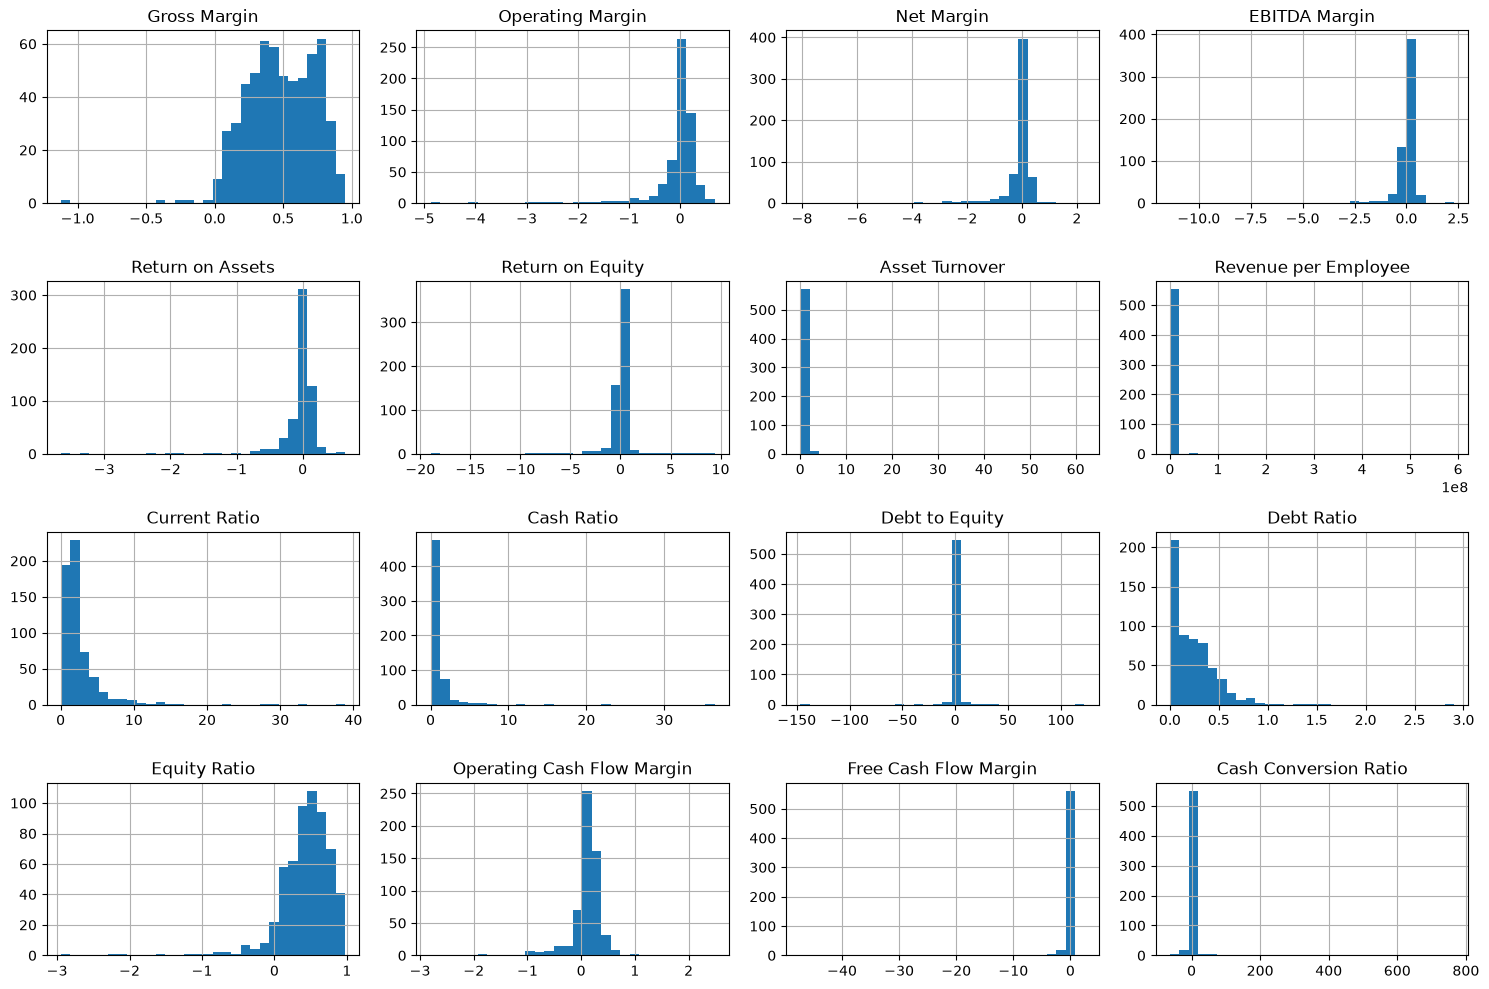

In [30]:
peer_universe_df[selected_clustering_kpis].hist(
    figsize=(15,10),
    bins=30
)
plt.tight_layout()

# **6. KPI Outlier Analysis**

### **6.1 Creating Boxplots**

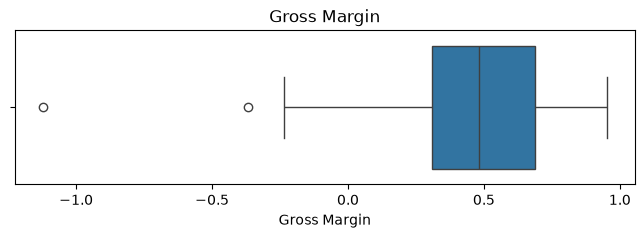

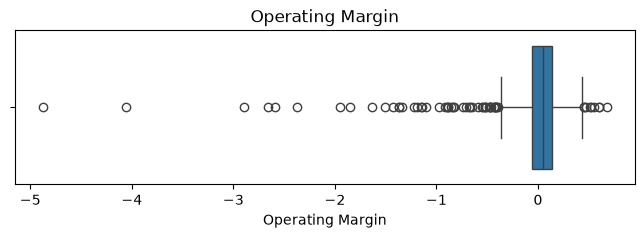

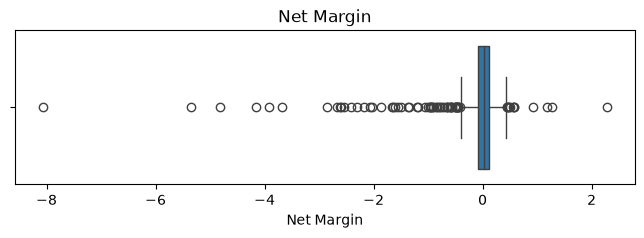

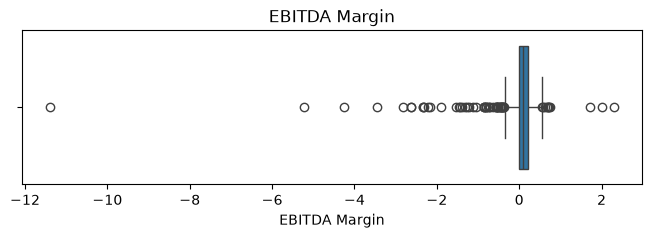

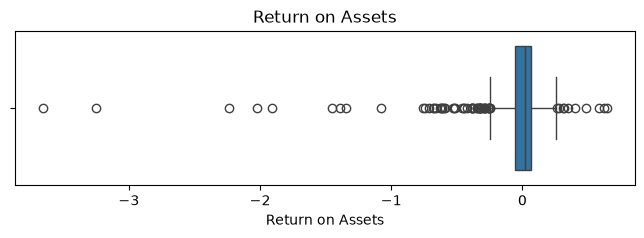

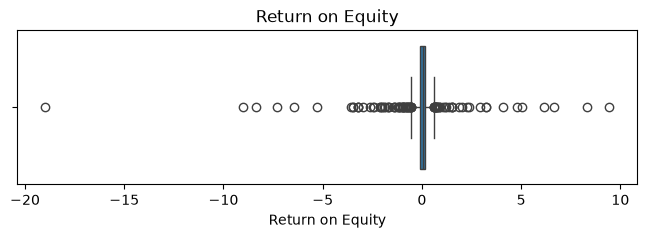

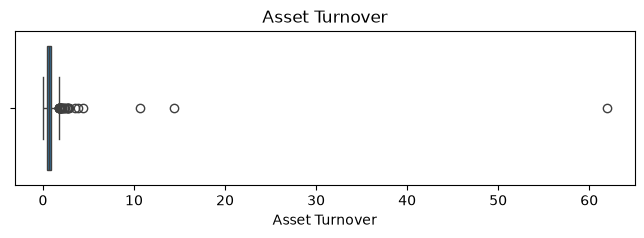

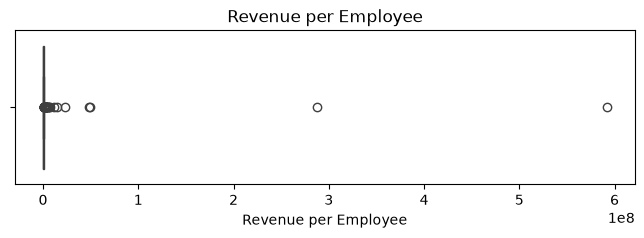

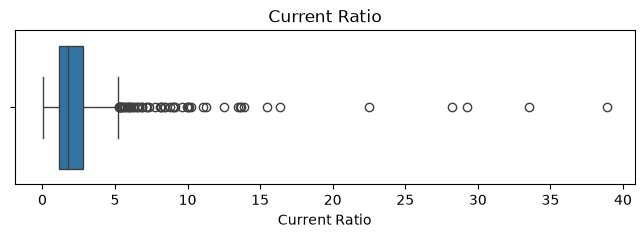

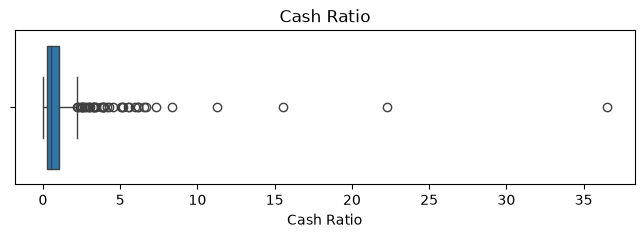

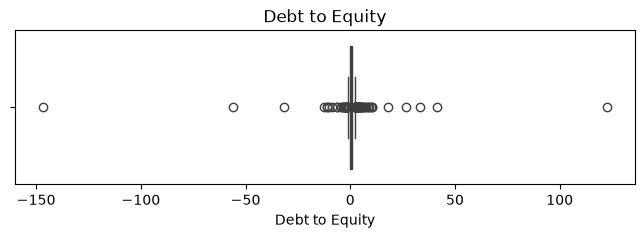

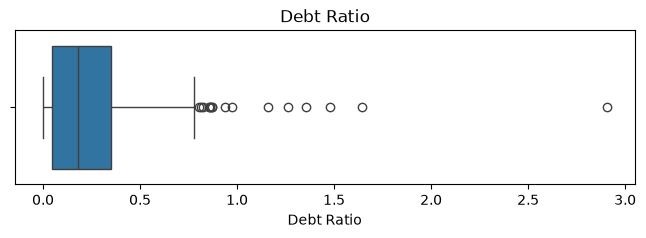

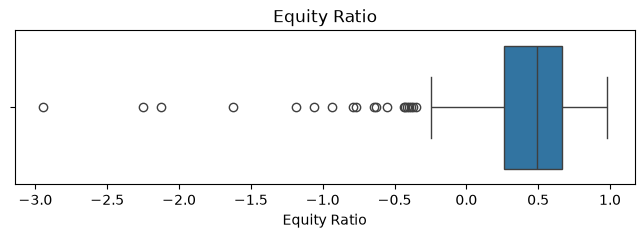

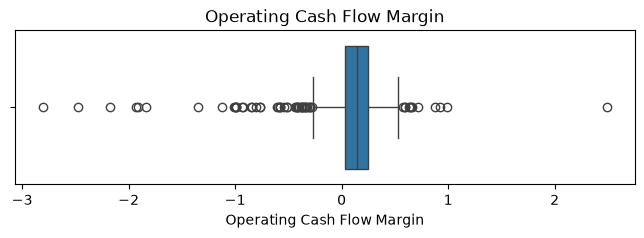

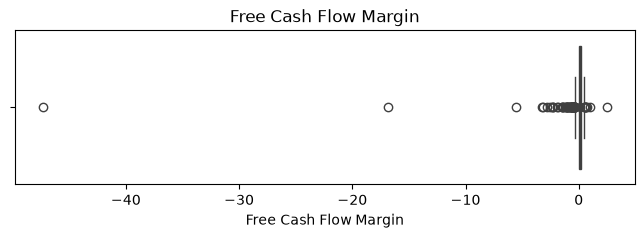

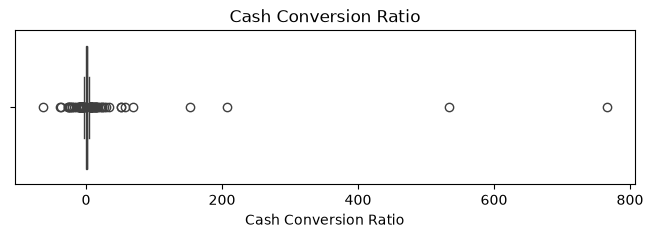

In [31]:
for kpi in selected_clustering_kpis:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=peer_universe_df[kpi])
    plt.title(kpi)
    plt.show()

There are so many outliers, that it's hard to see the data distribution

### **6.2 Impute missing KPIs**

In [32]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_imputed = imputer.fit_transform(
    peer_universe_df[selected_clustering_kpis]
)

imputed_features_df = pd.DataFrame(
    X_imputed,
    columns=selected_clustering_kpis,
    index=peer_universe_df.index
)

imputed_features_df.head()

,Gross Margin,Operating Margin,Net Margin,EBITDA Margin,Return on Assets,Return on Equity,Asset Turnover,Revenue per Employee,Current Ratio,Cash Ratio,Debt to Equity,Debt Ratio,Equity Ratio,Operating Cash Flow Margin,Free Cash Flow Margin,Cash Conversion Ratio
0,0.709952,0.044230,0.032562,0.055649,0.066434,0.088511,2.040244,2.625752e+06,3.758144,1.936742,0.078412,0.058854,0.750572,0.073452,0.058435,2.255776
1,0.487897,0.185595,0.157141,0.206236,0.212296,0.302832,1.350988,7.490348e+05,4.208129,1.958237,0.035236,0.024702,0.701035,0.225693,0.189299,1.436244
2,0.129065,-0.093689,-0.093748,-0.089977,-0.242287,-0.346627,2.584458,3.800006e+05,3.439537,0.879958,0.069397,0.048508,0.698984,-0.225362,-0.269679,2.403924
3,0.366376,-0.053240,-0.045365,-0.024887,-0.057235,-0.067080,1.261633,2.166639e+05,4.401152,2.658078,0.034154,0.029141,0.853231,-0.036855,-0.039725,0.812402
4,0.482275,-0.063035,-0.093401,-0.134339,-0.042559,-0.045887,0.455653,5.653535e+05,13.486890,0.670833,0.264777,0.181524,0.927456,-0.210290,-0.212487,2.251475


### **6.3 Clustering Feature Selection**

In [33]:
balanced_clustering_kpis = [
    "EBITDA Margin",
    "Return on Assets",
    "Asset Turnover",
    "Revenue per Employee",
    "Current Ratio",
    "Debt Ratio",
    "Free Cash Flow Margin",
    "Cash Conversion Ratio",
]

missing_balanced_kpis = [
    kpi for kpi in balanced_clustering_kpis
    if kpi not in selected_clustering_kpis
]

if missing_balanced_kpis:
    raise ValueError(
        f"The following balanced clustering KPIs are missing from the selected KPI set: "
        f"{missing_balanced_kpis}"
    )

print(f"Balanced clustering KPIs: {len(balanced_clustering_kpis)}")
balanced_clustering_kpis

Balanced clustering KPIs: 8


['EBITDA Margin',
 'Return on Assets',
 'Asset Turnover',
 'Revenue per Employee',
 'Current Ratio',
 'Debt Ratio',
 'Free Cash Flow Margin',
 'Cash Conversion Ratio']

In [34]:
# Build Balanced Feature Matrix

balanced_features_df = imputed_features_df[
    balanced_clustering_kpis
].copy()

balanced_features_df.head()

,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
0,0.055649,0.066434,2.040244,2.625752e+06,3.758144,0.058854,0.058435,2.255776
1,0.206236,0.212296,1.350988,7.490348e+05,4.208129,0.024702,0.189299,1.436244
2,-0.089977,-0.242287,2.584458,3.800006e+05,3.439537,0.048508,-0.269679,2.403924
3,-0.024887,-0.057235,1.261633,2.166639e+05,4.401152,0.029141,-0.039725,0.812402
4,-0.134339,-0.042559,0.455653,5.653535e+05,13.486890,0.181524,-0.212487,2.251475


### **6.4 Winzorization**

In [35]:
# Strong Winsorization for Clustering Features

def winsorize_series(series, lower=0.05, upper=0.95):
    lower_bound = series.quantile(lower)
    upper_bound = series.quantile(upper)

    return series.clip(
        lower=lower_bound,
        upper=upper_bound
    )

In [36]:
balanced_features_df = imputed_features_df[
    balanced_clustering_kpis
].copy()

balanced_winsorized_features_df = balanced_features_df.copy()

for kpi in balanced_clustering_kpis:
    balanced_winsorized_features_df[kpi] = winsorize_series(
        balanced_winsorized_features_df[kpi],
        lower=0.05,
        upper=0.95
    )

balanced_winsorized_features_df.describe().T

,count,mean,std,min,25%,50%,75%,max
EBITDA Margin,588.0,0.055283,0.266843,-0.717492,-0.015872,0.093541,0.211078,4.277354e-01
Return on Assets,588.0,-0.012752,0.140029,-0.383116,-0.056394,0.017972,0.067786,1.829171e-01
Asset Turnover,588.0,0.710181,0.402200,0.151636,0.413872,0.611594,0.935315,1.701135e+00
Revenue per Employee,588.0,550229.851134,483298.202133,108573.650725,265282.456622,380000.606283,618047.651501,2.040110e+06
Current Ratio,588.0,2.365061,1.730334,0.618711,1.148189,1.793978,2.776300,7.301735e+00
Debt Ratio,588.0,0.218591,0.185258,0.006131,0.047380,0.181524,0.344485,6.183062e-01
Free Cash Flow Margin,588.0,0.045801,0.237251,-0.639055,-0.013331,0.088529,0.187793,3.471780e-01
Cash Conversion Ratio,588.0,0.873917,2.900198,-6.268921,-0.091769,1.129946,1.990632,7.172117e+00


In [37]:
# ==================================================
# Business Rule Caps for Clustering Features
# ADDED THIS ONE AFTERWARDS

business_caps = {
    "EBITDA Margin": (-1.0, 1.0),
    "Free Cash Flow Margin": (-1.0, 1.0),
    "Return on Assets": (-1.0, 1.0),
    "Cash Conversion Ratio": (-5.0, 5.0),
    "Current Ratio": (0.0, 10.0),
    "Debt Ratio": (0.0, 2.0),
}

capped_features_df = balanced_winsorized_features_df.copy()

for kpi, (lower_cap, upper_cap) in business_caps.items():
    if kpi in capped_features_df.columns:
        capped_features_df[kpi] = capped_features_df[kpi].clip(
            lower=lower_cap,
            upper=upper_cap
        )

capped_features_df.describe().T

,count,mean,std,min,25%,50%,75%,max
EBITDA Margin,588.0,0.055283,0.266843,-0.717492,-0.015872,0.093541,0.211078,4.277354e-01
Return on Assets,588.0,-0.012752,0.140029,-0.383116,-0.056394,0.017972,0.067786,1.829171e-01
Asset Turnover,588.0,0.710181,0.402200,0.151636,0.413872,0.611594,0.935315,1.701135e+00
Revenue per Employee,588.0,550229.851134,483298.202133,108573.650725,265282.456622,380000.606283,618047.651501,2.040110e+06
Current Ratio,588.0,2.365061,1.730334,0.618711,1.148189,1.793978,2.776300,7.301735e+00
Debt Ratio,588.0,0.218591,0.185258,0.006131,0.047380,0.181524,0.344485,6.183062e-01
Free Cash Flow Margin,588.0,0.045801,0.237251,-0.639055,-0.013331,0.088529,0.187793,3.471780e-01
Cash Conversion Ratio,588.0,0.809765,2.440748,-5.000000,-0.091769,1.129946,1.990632,5.000000e+00


### **6.5 RobustScaler**

In [38]:
# Scale Balanced Winsorized Feature Matrix

from sklearn.preprocessing import RobustScaler

balanced_scaler = RobustScaler()

X_balanced_scaled = balanced_scaler.fit_transform(
    capped_features_df
)

balanced_model_features_df = pd.DataFrame(
    X_balanced_scaled,
    columns=balanced_clustering_kpis,
    index=balanced_winsorized_features_df.index
)

balanced_model_features_df.describe().T

,count,mean,std,min,25%,50%,75%,max
EBITDA Margin,588.0,-0.168576,1.175782,-3.573632,-0.482100,0.000000e+00,0.517900,1.472553
Return on Assets,588.0,-0.247413,1.127624,-3.229885,-0.598856,0.000000e+00,0.401144,1.328274
Asset Turnover,588.0,0.189065,0.771321,-0.882087,-0.379183,0.000000e+00,0.620817,2.089471
Revenue per Employee,588.0,0.482557,1.370028,-0.769427,-0.325197,0.000000e+00,0.674803,4.705990
Current Ratio,588.0,0.350764,1.062786,-0.721859,-0.396649,-6.808790e-17,0.603351,3.382913
Debt Ratio,588.0,0.124759,0.623543,-0.590340,-0.451502,0.000000e+00,0.548498,1.470128
Free Cash Flow Margin,588.0,-0.212443,1.179629,-3.617592,-0.506454,0.000000e+00,0.493546,1.286021
Cash Conversion Ratio,588.0,-0.153756,1.172084,-2.943692,-0.586686,0.000000e+00,0.413314,1.858459


In [39]:
# Check Scaled Feature Extremes

scaled_extremes = pd.DataFrame({
    "Min": balanced_model_features_df.min(),
    "Max": balanced_model_features_df.max(),
    "Max Absolute Value": balanced_model_features_df.abs().max()
}).sort_values(
    "Max Absolute Value",
    ascending=False
)

scaled_extremes

,Min,Max,Max Absolute Value
Revenue per Employee,-0.769427,4.705990,4.705990
Free Cash Flow Margin,-3.617592,1.286021,3.617592
EBITDA Margin,-3.573632,1.472553,3.573632
Current Ratio,-0.721859,3.382913,3.382913
Return on Assets,-3.229885,1.328274,3.229885
Cash Conversion Ratio,-2.943692,1.858459,2.943692
Asset Turnover,-0.882087,2.089471,2.089471
Debt Ratio,-0.590340,1.470128,1.470128


# **7. PCA Analysis**

### **7.1 Fit PCA**

In [40]:
from sklearn.decomposition import PCA

# ==================================================
# PCA on Strongly Winsorized Balanced Feature Set
# ==================================================

balanced_pca = PCA()

X_balanced_pca = balanced_pca.fit_transform(X_balanced_scaled)

balanced_explained_variance = pd.DataFrame({
    "Component": range(1, len(balanced_pca.explained_variance_ratio_) + 1),
    "Explained Variance": balanced_pca.explained_variance_ratio_,
    "Cumulative Variance": np.cumsum(balanced_pca.explained_variance_ratio_)
})

balanced_explained_variance

,Component,Explained Variance,Cumulative Variance
0,1,0.357841,0.357841
1,2,0.200461,0.558302
2,3,0.137276,0.695578
3,4,0.131653,0.827231
4,5,0.066986,0.894217
5,6,0.052088,0.946306
6,7,0.033244,0.979549
7,8,0.020451,1.000000


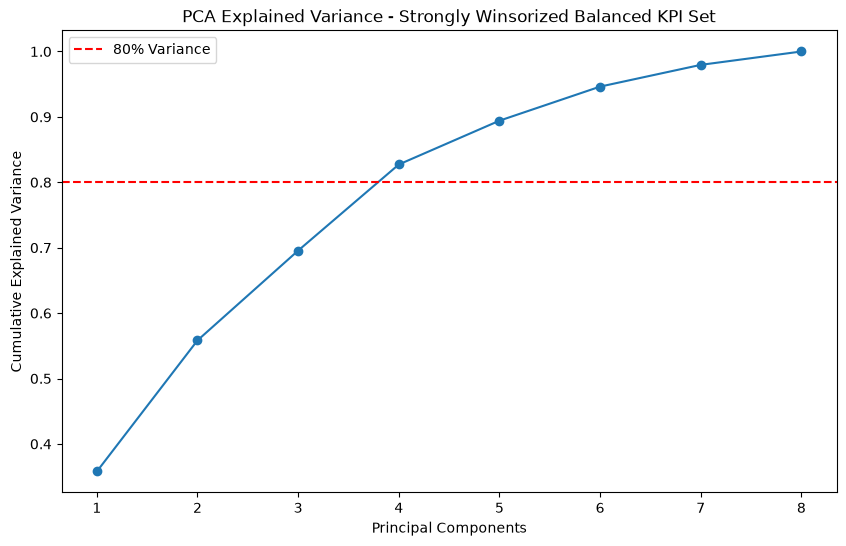

In [41]:
plt.figure(figsize=(10, 6))

plt.plot(
    balanced_explained_variance["Component"],
    balanced_explained_variance["Cumulative Variance"],
    marker="o"
)

plt.axhline(
    y=0.80,
    color="red",
    linestyle="--",
    label="80% Variance"
)

plt.xlabel("Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance - Strongly Winsorized Balanced KPI Set")
plt.legend()
plt.show()

In [42]:
balanced_pca_loadings = pd.DataFrame(
    balanced_pca.components_.T,
    index=balanced_clustering_kpis,
    columns=[f"PC{i+1}" for i in range(balanced_pca.n_components_)]
)

balanced_pca_loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
EBITDA Margin,0.592417,-0.046561,-0.132492,-0.053925,-0.293134,0.162852,0.189327,0.691461
Return on Assets,0.547490,-0.045883,0.050870,-0.190020,-0.300276,0.354370,-0.231410,-0.624627
Asset Turnover,0.004794,0.124271,-0.145782,0.165639,0.591474,0.753047,0.135159,0.025627
Revenue per Employee,0.145524,0.970773,0.044028,0.109009,-0.039767,-0.136448,-0.046877,-0.014260
Current Ratio,-0.008608,0.072671,0.676739,-0.615594,0.165207,0.059696,0.352130,0.053494
Debt Ratio,-0.011680,0.007224,-0.176992,0.210883,-0.227296,-0.048520,0.872142,-0.330704
Free Cash Flow Margin,0.529831,-0.107580,-0.178591,-0.068119,0.626243,-0.505348,0.071792,-0.135868
Cash Conversion Ratio,0.217173,-0.144830,0.659902,0.702565,0.036708,-0.030153,-0.018932,0.013266


### **7.2 Scree Plot**

In [43]:
# N_COMPONENTS = 4

# pca = PCA(n_components=N_COMPONENTS)

# X_pca = pca.fit_transform(X_scaled)

# pca_df = pd.DataFrame(
#     X_pca,
#     columns=[
#         f"PC{i+1}"
#         for i in range(N_COMPONENTS)
#     ]
# )

# pca_df.head()

We lost the 'X_scaled' somewhere...

Old: PCA 1 overpowers the others, not good

In [44]:
# plot_df = peer_universe_df.copy()

# plot_df["PC1"] = X_pca[:, 0]
# plot_df["PC2"] = X_pca[:, 1]

# plt.figure(figsize=(10, 8))

# plt.scatter(
#     plot_df["PC1"],
#     plot_df["PC2"],
#     alpha=0.6
# )

# plt.xlabel("PC1")
# plt.ylabel("PC2")
# plt.title("PCA Projection")

# plt.show()

In [45]:
# pca_loadings = pd.DataFrame(
#     pca.components_.T,
#     index=selected_clustering_kpis,
#     columns=[f"PC{i+1}" for i in range(pca.n_components_)]
# )

# pca_loadings

In [46]:
# pca_loadings["PC1"].sort_values(
#     key=abs,
#     ascending=False
# )

Up until this point, PCA is dominated by profitability and cash flow... this is not necessarily wrong, as these features are genuinely important for benchmarking, but it's not the level of depth I'm trying to achieve for the clusters. We might need to create a category-balanced feature selection.

# **8. KPI Correlation Analysis**

### **8.1 Correlation Matrix**

In [47]:
correlation_matrix = balanced_winsorized_features_df[
    balanced_clustering_kpis
].corr()

correlation_matrix

,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
EBITDA Margin,1.000000,0.819909,-0.027818,0.112977,-0.076853,0.051887,0.671650,0.180553
Return on Assets,0.819909,1.000000,-0.051167,0.097366,0.095458,-0.102709,0.597794,0.184097
Asset Turnover,-0.027818,-0.051167,1.000000,0.167252,-0.168442,0.022250,0.057484,-0.013821
Revenue per Employee,0.112977,0.097366,0.167252,1.000000,0.048601,0.026897,0.037551,-0.026565
Current Ratio,-0.076853,0.095458,-0.168442,0.048601,1.000000,-0.372168,-0.061686,0.001673
Debt Ratio,0.051887,-0.102709,0.022250,0.026897,-0.372168,1.000000,-0.066261,0.026459
Free Cash Flow Margin,0.671650,0.597794,0.057484,0.037551,-0.061686,-0.066261,1.000000,0.155785
Cash Conversion Ratio,0.180553,0.184097,-0.013821,-0.026565,0.001673,0.026459,0.155785,1.000000


In [48]:
balanced_winsorized_features_df

,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
0,0.055649,0.066434,1.701135,2.040110e+06,3.758144,0.058854,0.058435,2.255776
1,0.206236,0.182917,1.350988,7.490348e+05,4.208129,0.024702,0.189299,1.436244
2,-0.089977,-0.242287,1.701135,3.800006e+05,3.439537,0.048508,-0.269679,2.403924
3,-0.024887,-0.057235,1.261633,2.166639e+05,4.401152,0.029141,-0.039725,0.812402
4,-0.134339,-0.042559,0.455653,5.653535e+05,7.301735,0.181524,-0.212487,2.251475
...,...,...,...,...,...,...,...,...
583,0.188336,0.060908,0.718231,3.987312e+05,1.070830,0.287023,0.119329,1.474664
584,0.339973,0.099458,0.281798,1.513739e+06,7.301735,0.006131,0.347178,1.049615
585,0.245456,0.083757,0.691104,2.728806e+05,1.006203,0.086177,0.347178,3.411732
586,-0.097456,-0.070937,0.458358,3.393145e+05,1.023291,0.405357,-0.102265,0.641210


### **8.2 Correlation Heatmap**

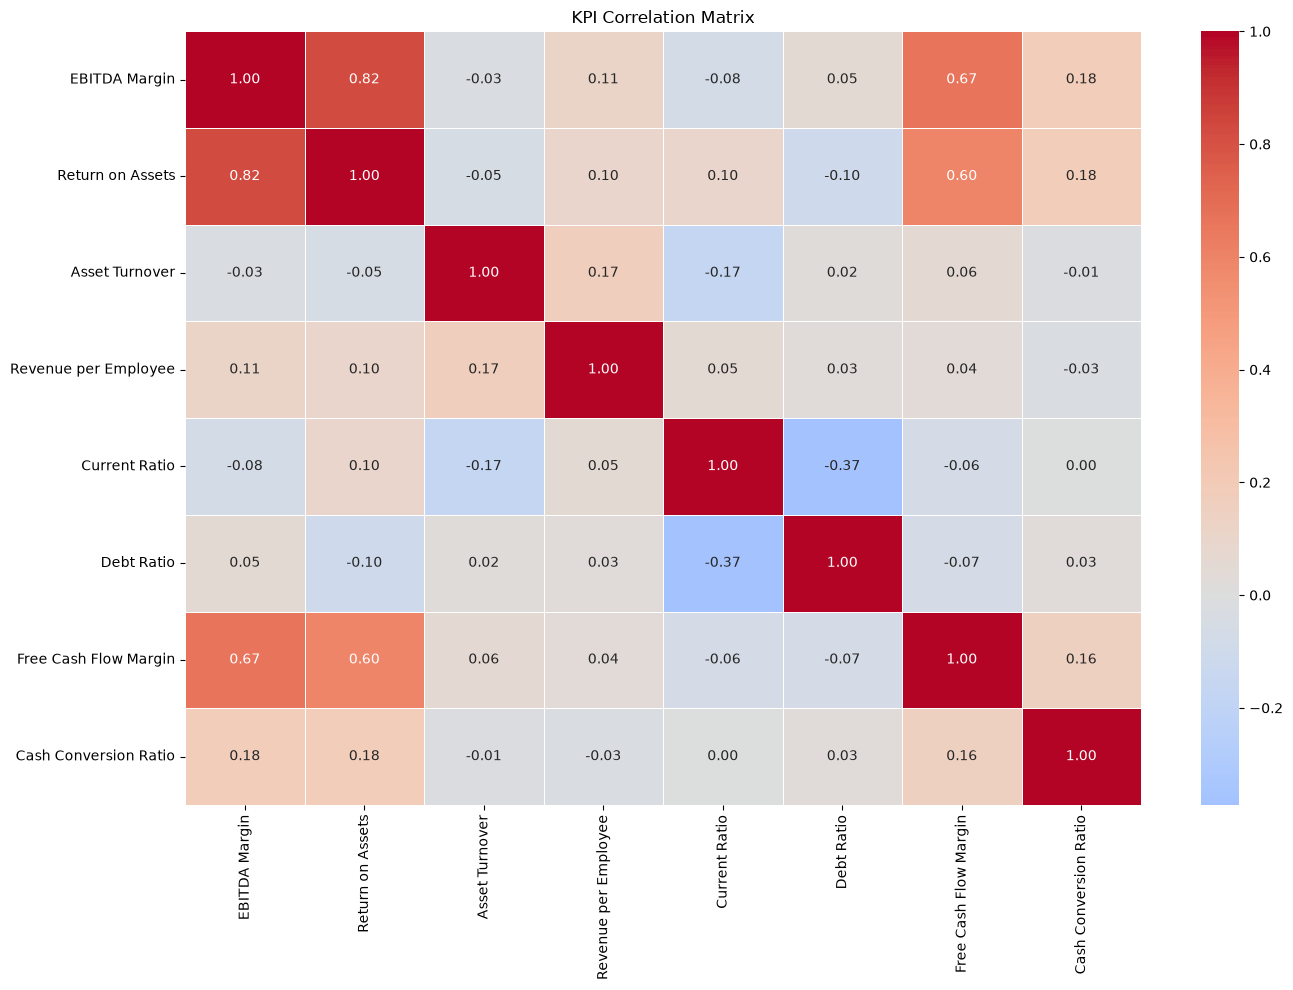

In [49]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("KPI Correlation Matrix")
plt.tight_layout()
plt.show()

### **8.3 Highly Correlated KPIs**

In [50]:
CORRELATION_THRESHOLD = 0.85

corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["KPI 1", "KPI 2", "Correlation"]

high_corr_pairs = corr_pairs[
    corr_pairs["Correlation"].abs() >= CORRELATION_THRESHOLD
].sort_values(
    by="Correlation",
    key=abs,
    ascending=False
)

high_corr_pairs

,KPI 1,KPI 2,Correlation


None, this is a good sign the previous scaling worked

### **8.4 Correlation by Category**

In [51]:
kpi_category_mapping = (
    kpi_definitions
    .set_index("KPI")["Category"]
    .to_dict()
)

correlation_category_summary = high_corr_pairs.copy()

correlation_category_summary["Category 1"] = correlation_category_summary["KPI 1"].map(
    kpi_category_mapping
)

correlation_category_summary["Category 2"] = correlation_category_summary["KPI 2"].map(
    kpi_category_mapping
)

correlation_category_summary

,KPI 1,KPI 2,Correlation,Category 1,Category 2


Same here

### **8.5 Average Absolute Correlation per KPI**

In [52]:
avg_abs_correlation = (
    correlation_matrix
    .abs()
    .replace(1, np.nan)
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

avg_abs_correlation.columns = [
    "KPI",
    "Average Absolute Correlation"
]

avg_abs_correlation

,KPI,Average Absolute Correlation
0,Return on Assets,0.278357
1,EBITDA Margin,0.277378
2,Free Cash Flow Margin,0.235459
3,Current Ratio,0.117840
4,Debt Ratio,0.095519
5,Cash Conversion Ratio,0.084136
6,Revenue per Employee,0.073887
7,Asset Turnover,0.072605


# **9. Clustering Experiments**

In [53]:
# Here we finally start with the clustering -> 7/2/2026

## **9.1 K-Means Baseline**

K-Means is used as the baseline clustering algorithm due to its simplicity, computational efficiency, and interpretability. The model is evaluated across a range of cluster counts using multiple internal validation metrics.

To ensure consistency with subsequent clustering experiments, K-Means is applied to the four-dimensional PCA representation of the balanced KPI feature space. These four principal components retain more than 80% of the total variance.

### 9.1.1 Prepare Clustering Input

In [54]:
# ==================================================
# Prepare Clustering Input
# ==================================================

N_COMPONENTS = 4

X_cluster = X_balanced_pca[:, :N_COMPONENTS]

print(f"Clustering input shape: {X_cluster.shape}")

Clustering input shape: (588, 4)


In [55]:
print(
    f"Cumulative variance retained: "
    f"{balanced_explained_variance.loc[N_COMPONENTS - 1, 'Cumulative Variance']:.2%}"
)

Cumulative variance retained: 82.72%


### 9.1.2 Evaluate Candidate Values of K

In [56]:
K_RANGE = range(2, 11)

In [57]:
# ==================================================
# Evaluate Candidate Values of K
# ==================================================

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

K_RANGE = range(2, 11)

kmeans_results = []

for k in K_RANGE:

    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=50,
    )

    cluster_labels = model.fit_predict(X_cluster)

    kmeans_results.append({
        "Model": "K-Means",
        "K": k,
        "Inertia": model.inertia_,
        "Silhouette Score": silhouette_score(
            X_cluster,
            cluster_labels
        ),
        "Davies-Bouldin Index": davies_bouldin_score(
            X_cluster,
            cluster_labels
        ),
        "Calinski-Harabasz Score": calinski_harabasz_score(
            X_cluster,
            cluster_labels
        ),
    })

kmeans_results_df = pd.DataFrame(kmeans_results)

kmeans_results_df

,Model,K,Inertia,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,K-Means,2,3206.419707,0.319061,1.369437,249.046472
1,K-Means,3,2509.045790,0.348711,1.143806,240.160732
2,K-Means,4,1883.189369,0.349593,1.057253,277.647527
3,K-Means,5,1588.694517,0.366551,0.978495,273.430977
4,K-Means,6,1410.063611,0.362804,1.002467,260.779147
5,K-Means,7,1247.159813,0.370703,0.993112,257.927914
6,K-Means,8,1123.008618,0.316147,1.054260,254.259554
7,K-Means,9,1016.500830,0.320375,1.011666,252.947603
8,K-Means,10,948.131394,0.322486,1.017627,245.270329


### 9.1.3 Identify Best K by Metric

In [58]:
# ==================================================
# Best K by Evaluation Metric
# ==================================================

best_silhouette_k = (
    kmeans_results_df
    .loc[kmeans_results_df["Silhouette Score"].idxmax(), "K"]
)

best_davies_bouldin_k = (
    kmeans_results_df
    .loc[kmeans_results_df["Davies-Bouldin Index"].idxmin(), "K"]
)

best_calinski_harabasz_k = (
    kmeans_results_df
    .loc[kmeans_results_df["Calinski-Harabasz Score"].idxmax(), "K"]
)

print(f"Best K by Silhouette Score: {best_silhouette_k}")
print(f"Best K by Davies-Bouldin Index: {best_davies_bouldin_k}")
print(f"Best K by Calinski-Harabasz Score: {best_calinski_harabasz_k}")

Best K by Silhouette Score: 7
Best K by Davies-Bouldin Index: 5
Best K by Calinski-Harabasz Score: 4


### 9.1.4 Elbow Method

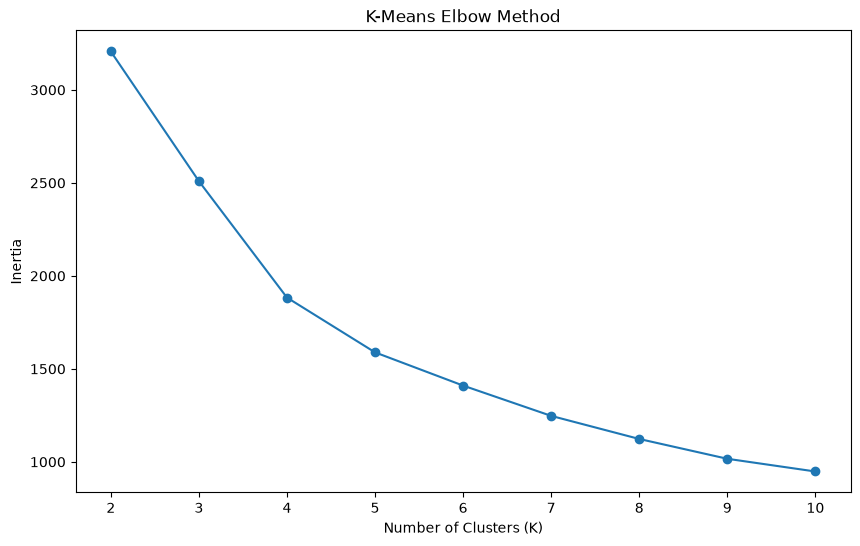

In [59]:
# ==================================================
# Elbow Method
# ==================================================

plt.figure(figsize=(10, 6))

plt.plot(
    kmeans_results_df["K"],
    kmeans_results_df["Inertia"],
    marker="o",
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")
plt.xticks(list(K_RANGE))
plt.show()

### 9.1.5 Silhouette Score

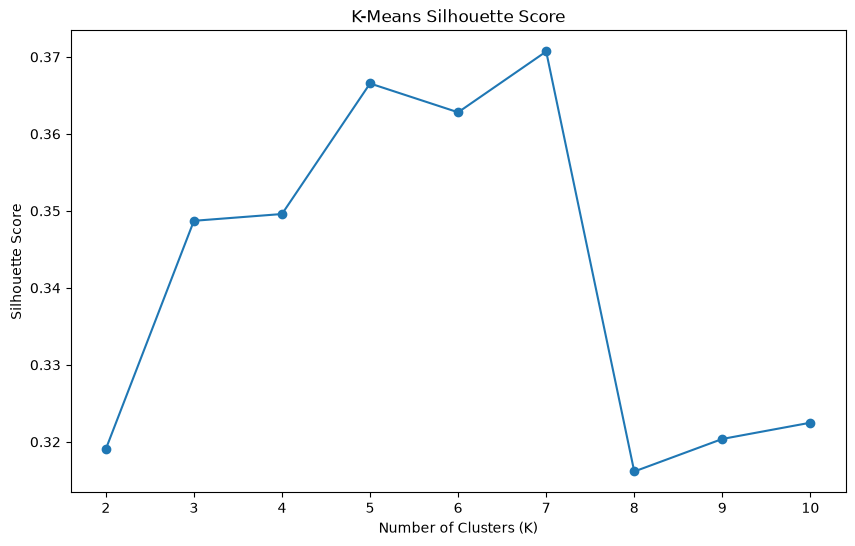

In [60]:
# ==================================================
# Silhouette Score
# ==================================================

plt.figure(figsize=(10, 6))

plt.plot(
    kmeans_results_df["K"],
    kmeans_results_df["Silhouette Score"],
    marker="o",
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Score")
plt.xticks(list(K_RANGE))
plt.show()

### 9.1.6 Davies-Bouldin Index

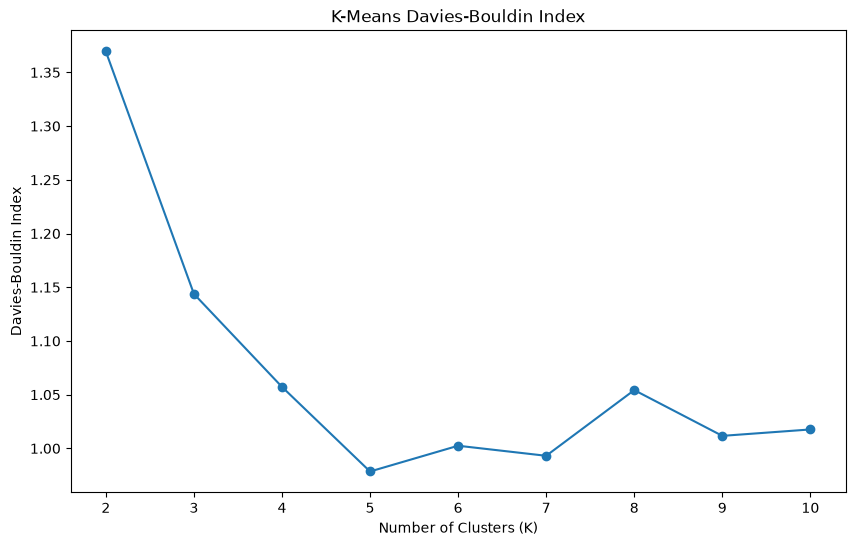

In [61]:
# ==================================================
# Davies-Bouldin Index
# ==================================================

plt.figure(figsize=(10, 6))

plt.plot(
    kmeans_results_df["K"],
    kmeans_results_df["Davies-Bouldin Index"],
    marker="o",
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Davies-Bouldin Index")
plt.title("K-Means Davies-Bouldin Index")
plt.xticks(list(K_RANGE))
plt.show()

### 9.1.7 Calinski-Harabasz Score

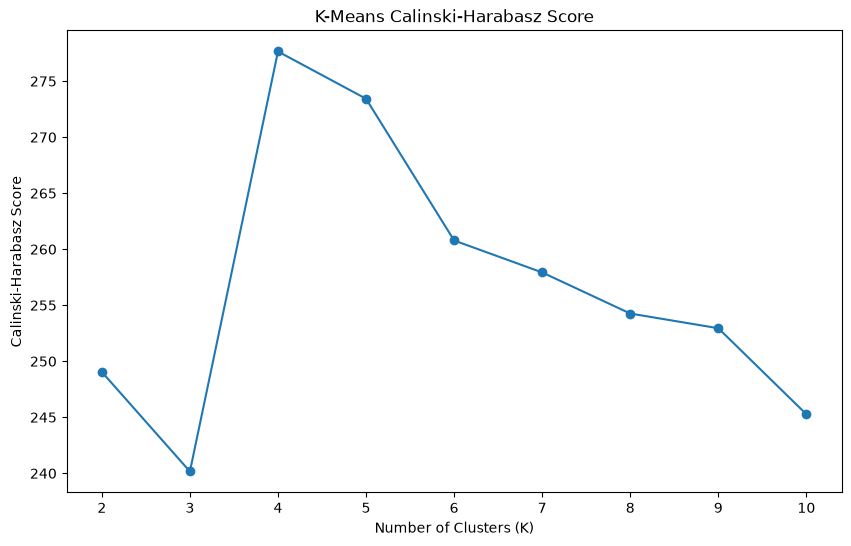

In [62]:
# ==================================================
# Calinski-Harabasz Score
# ==================================================

plt.figure(figsize=(10, 6))

plt.plot(
    kmeans_results_df["K"],
    kmeans_results_df["Calinski-Harabasz Score"],
    marker="o",
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Calinski-Harabasz Score")
plt.title("K-Means Calinski-Harabasz Score")
plt.xticks(list(K_RANGE))
plt.show()

### 9.1.8 Candidate K Comparison

In [63]:
# ==================================================
# Compare Candidate K Solutions
# ==================================================

candidate_k_values = [4, 5, 7]

candidate_cluster_results = {}

for k in candidate_k_values:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=50,
    )

    labels = model.fit_predict(X_cluster)

    candidate_cluster_results[k] = {
        "model": model,
        "labels": labels,
    }

    cluster_sizes = (
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )

    print(f"\nK = {k}")
    print(cluster_sizes)


K = 4
0    292
1     71
2     65
3    160
Name: count, dtype: int64

K = 5
0     71
1     51
2    157
3     61
4    248
Name: count, dtype: int64



K = 7
0     52
1    245
2     69
3     46
4     50
5    109
6     17
Name: count, dtype: int64


In [64]:
# ==================================================
# Candidate Cluster Size Summary
# ==================================================

cluster_size_records = []

for k, result in candidate_cluster_results.items():

    cluster_sizes = (
        pd.Series(result["labels"])
        .value_counts()
        .sort_index()
    )

    for cluster, size in cluster_sizes.items():
        cluster_size_records.append({
            "K": k,
            "Cluster": cluster,
            "Company Count": size,
            "Cluster Share": size / len(X_cluster),
        })

cluster_size_summary_df = pd.DataFrame(cluster_size_records)

cluster_size_summary_df

,K,Cluster,Company Count,Cluster Share
0,4,0,292,0.496599
1,4,1,71,0.120748
2,4,2,65,0.110544
3,4,3,160,0.272109
4,5,0,71,0.120748
5,5,1,51,0.086735
6,5,2,157,0.267007
7,5,3,61,0.103741
8,5,4,248,0.421769
9,7,0,52,0.088435


In [65]:
cluster_balance_summary = (
    cluster_size_summary_df
    .groupby("K")
    .agg(
        Smallest_Cluster=("Company Count", "min"),
        Largest_Cluster=("Company Count", "max"),
        Smallest_Share=("Cluster Share", "min"),
        Largest_Share=("Cluster Share", "max"),
    )
)

cluster_balance_summary

,Smallest_Cluster,Largest_Cluster,Smallest_Share,Largest_Share
K,,,,
4,65,292,0.110544,0.496599
5,51,248,0.086735,0.421769
7,17,245,0.028912,0.416667


The largest cluster contains about half the companies, but the remaining three clusters are all large enough to support stable benchmark quartiles. A 65-company cluster is still perfectly usable.
K = 5 now looks like the strongest compromise between:

statistical performance + cluster balance + benchmark usability + interpretability

### 9.1.9 Candidate Cluster Profile Comparison

Candidate K-Means solutions are compared using the median values of the balanced clustering KPIs within each cluster. Median values are used instead of means because financial KPI distributions remain skewed even after preprocessing.

These profiles help determine whether additional clusters represent genuinely distinct financial archetypes or merely divide similar groups into smaller segments.

In [66]:
# ==================================================
# Build Candidate Cluster Profiles
# ==================================================

candidate_cluster_profiles_with_counts = {}

for k, profile in candidate_cluster_profiles_with_counts.items():

    cluster_sizes = (
        pd.Series(candidate_cluster_results[k]["labels"])
        .value_counts()
        .sort_index()
        .rename("Company Count")
    )

    profile_with_counts = profile.copy()

    profile_with_counts.insert(
        0,
        "Company Count",
        cluster_sizes
    )

    candidate_cluster_profiles_with_counts[k] = profile_with_counts

    print(f"\nK = {k}")
    display(profile_with_counts)

In [67]:
# ==================================================
# Standardised Candidate Cluster Profiles
# ==================================================

candidate_standardised_profiles = {}

for k, result in candidate_cluster_results.items():

    scaled_profile_df = balanced_model_features_df.copy()
    scaled_profile_df["Cluster"] = result["labels"]

    standardised_profile = (
        scaled_profile_df
        .groupby("Cluster")[balanced_clustering_kpis]
        .median()
    )

    candidate_standardised_profiles[k] = standardised_profile

    print(f"\nK = {k}")
    display(standardised_profile)


K = 4


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.412884,0.300174,-0.034259,-0.028002,0.015060,0.000000,0.295455,0.361332
1,-2.836556,-2.742502,-0.223246,-0.203253,0.123662,-0.161247,-2.524256,-0.356207
2,0.279532,0.342853,0.441232,3.985499,0.098999,-0.066051,0.088860,0.055279
3,-0.390394,-0.516687,0.097704,-0.022537,-0.054214,0.023336,-0.231549,-1.142728



K = 5


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,-2.836556,-2.742502,-0.223246,-0.203253,0.123662,-0.161247,-2.524256,-0.356207
1,0.191252,0.320401,-0.268872,0.398471,2.879457,-0.527834,0.292335,0.147089
2,-0.383510,-0.526184,0.120210,-0.020463,-0.062553,0.030546,-0.230322,-1.132829
3,0.209824,0.326107,0.502948,4.062406,-0.054431,0.000000,-0.065661,0.055279
4,0.429811,0.303633,0.004416,-0.057944,-0.122102,0.106809,0.305440,0.374699



K = 7


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.363339,0.390704,0.514737,3.949638,0.107372,0.000000,0.212928,0.120883
1,0.436608,0.305983,0.000000,-0.060399,-0.129808,0.127143,0.312306,0.369474
2,-0.233946,-0.290646,0.048892,0.041921,0.074453,0.000000,0.073936,-2.943692
3,-3.573632,-2.893255,-0.345790,-0.361725,0.149845,-0.166066,-3.411856,-0.338373
4,0.191862,0.347472,-0.240431,0.377407,2.889256,-0.532103,0.296495,0.145665
5,-0.639417,-0.913526,0.220894,-0.060499,-0.134639,0.062639,-0.493822,-0.624244
6,-1.354693,-1.794776,0.512182,4.705990,-0.075618,-0.071644,-1.221703,-0.421175


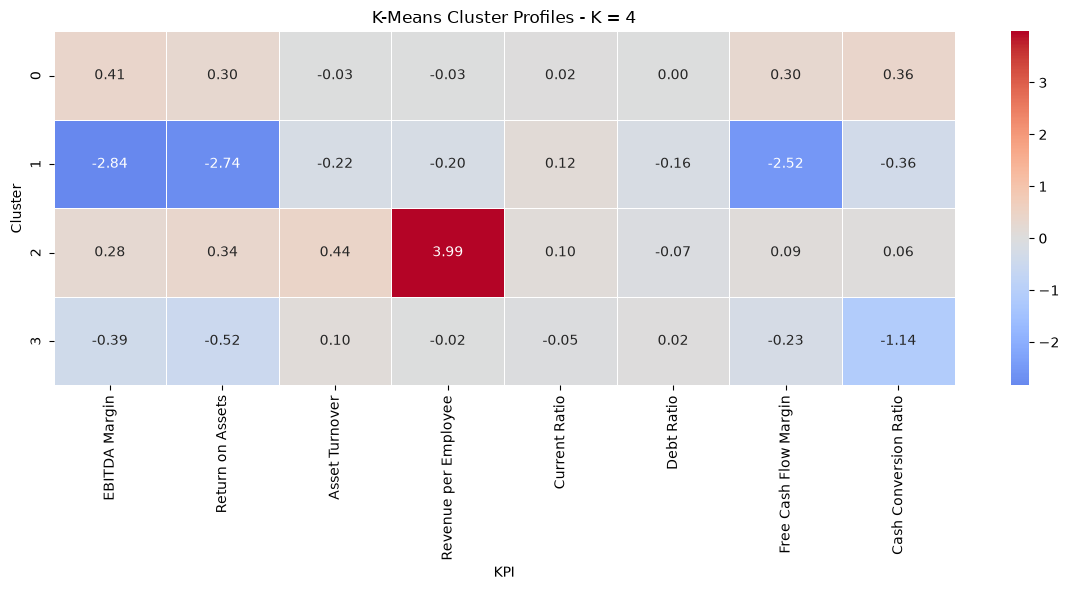

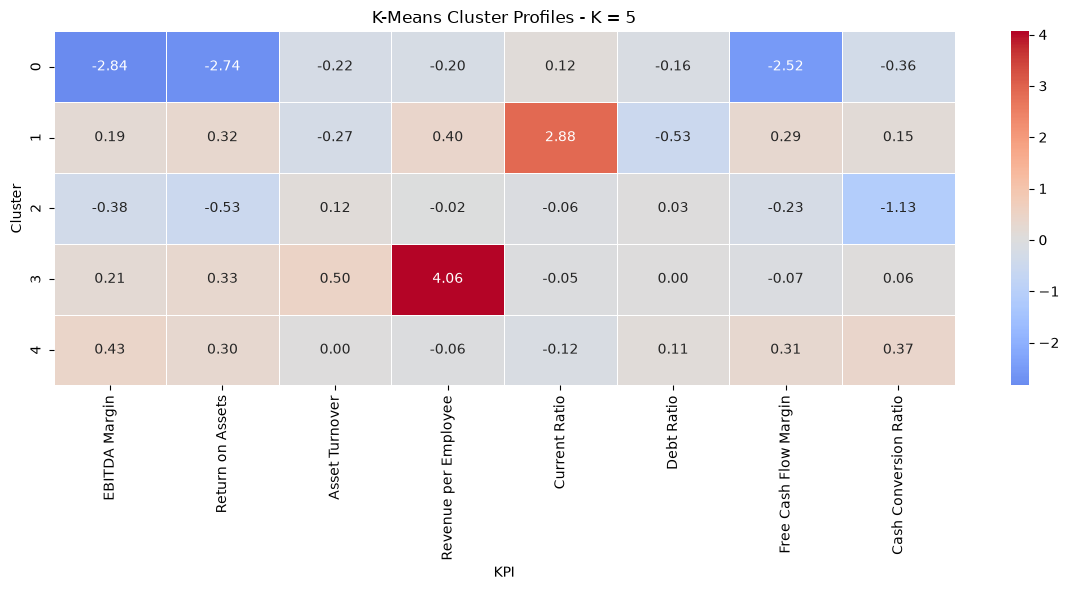

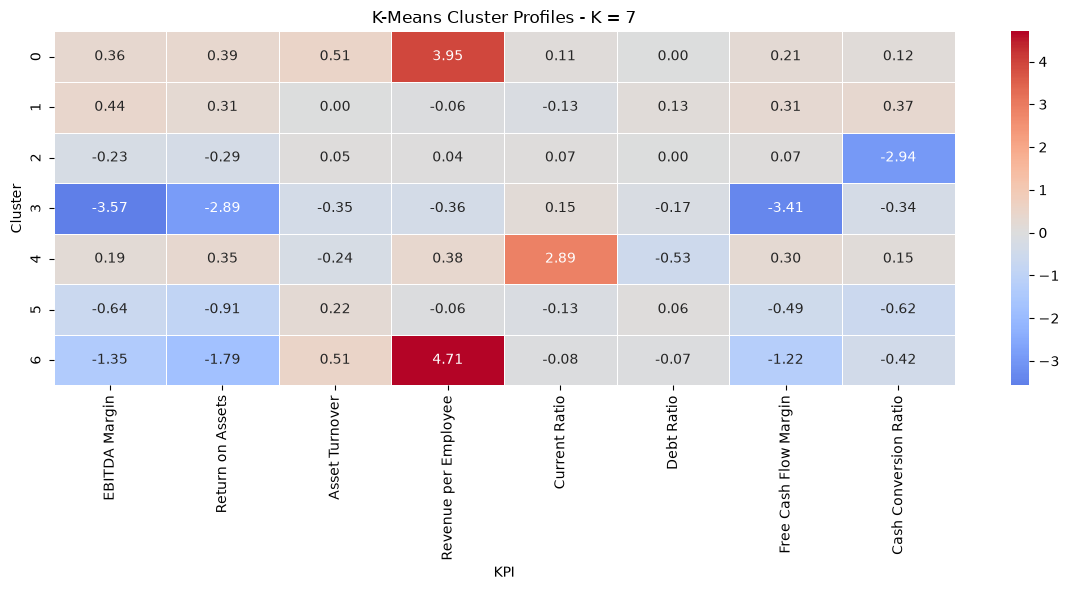

In [68]:
# ==================================================
# Candidate Cluster Profile Heatmaps
# ==================================================

for k, profile in candidate_standardised_profiles.items():

    plt.figure(figsize=(12, 6))

    sns.heatmap(
        profile,
        annot=True,
        fmt=".2f",
        center=0,
        cmap="coolwarm",
        linewidths=0.5
    )

    plt.title(f"K-Means Cluster Profiles - K = {k}")
    plt.xlabel("KPI")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()

Ideal amount of clusters for K-Means baseline = 5

## **9.2 Agglomerative Clustering**

Agglomerative Clustering is evaluated as a hierarchical alternative to K-Means. Unlike centroid-based methods, it progressively merges similar observations based on pairwise distances, allowing the underlying hierarchical structure of the peer universe to influence cluster formation.

To ensure a fair comparison with the K-Means baseline, the method is applied to the same four-component PCA representation and evaluated using the same internal validation metrics.

### 9.2.1 Evaluate Candidate Cluster Counts

In [69]:
# ==================================================
# Evaluate Agglomerative Clustering
# ==================================================

from sklearn.cluster import AgglomerativeClustering

agglomerative_results = []

for k in K_RANGE:

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward",
    )

    cluster_labels = model.fit_predict(X_cluster)

    agglomerative_results.append({
        "Model": "Agglomerative",
        "K": k,
        "Silhouette Score": silhouette_score(
            X_cluster,
            cluster_labels
        ),
        "Davies-Bouldin Index": davies_bouldin_score(
            X_cluster,
            cluster_labels
        ),
        "Calinski-Harabasz Score": calinski_harabasz_score(
            X_cluster,
            cluster_labels
        ),
    })

agglomerative_results_df = pd.DataFrame(
    agglomerative_results
)

agglomerative_results_df

,Model,K,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,Agglomerative,2,0.295106,1.450031,208.256556
1,Agglomerative,3,0.345746,1.152500,234.977396
2,Agglomerative,4,0.341366,1.055563,257.013876
3,Agglomerative,5,0.346407,1.019320,242.868826
4,Agglomerative,6,0.353685,1.007341,228.690932
5,Agglomerative,7,0.339207,0.986033,222.339384
6,Agglomerative,8,0.343959,1.058845,223.044428
7,Agglomerative,9,0.303126,1.178190,216.461226
8,Agglomerative,10,0.282523,1.154307,212.573454


### 9.2.2 Identify Best K by Metric

In [70]:
# ==================================================
# Best K by Evaluation Metric
# ==================================================

best_agg_silhouette_k = (
    agglomerative_results_df
    .loc[
        agglomerative_results_df["Silhouette Score"].idxmax(),
        "K"
    ]
)

best_agg_davies_bouldin_k = (
    agglomerative_results_df
    .loc[
        agglomerative_results_df["Davies-Bouldin Index"].idxmin(),
        "K"
    ]
)

best_agg_calinski_harabasz_k = (
    agglomerative_results_df
    .loc[
        agglomerative_results_df["Calinski-Harabasz Score"].idxmax(),
        "K"
    ]
)

print(
    f"Best K by Silhouette Score: "
    f"{best_agg_silhouette_k}"
)

print(
    f"Best K by Davies-Bouldin Index: "
    f"{best_agg_davies_bouldin_k}"
)

print(
    f"Best K by Calinski-Harabasz Score: "
    f"{best_agg_calinski_harabasz_k}"
)

Best K by Silhouette Score: 6
Best K by Davies-Bouldin Index: 7
Best K by Calinski-Harabasz Score: 4


### 9.2.3 Silhouette Score

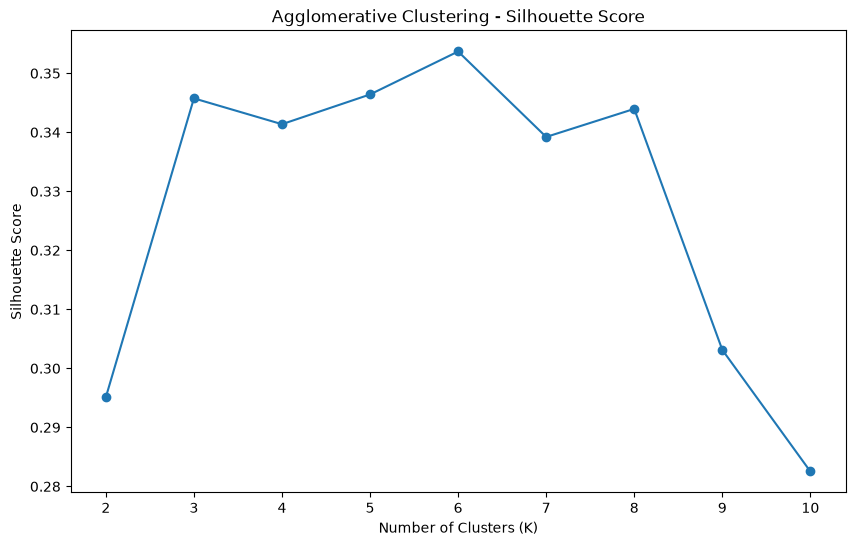

In [71]:
# ==================================================
# Silhouette Score
# ==================================================

plt.figure(figsize=(10, 6))

plt.plot(
    agglomerative_results_df["K"],
    agglomerative_results_df["Silhouette Score"],
    marker="o",
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Agglomerative Clustering - Silhouette Score")
plt.xticks(list(K_RANGE))
plt.show()

### 9.2.4 Davies-Bouldin Index

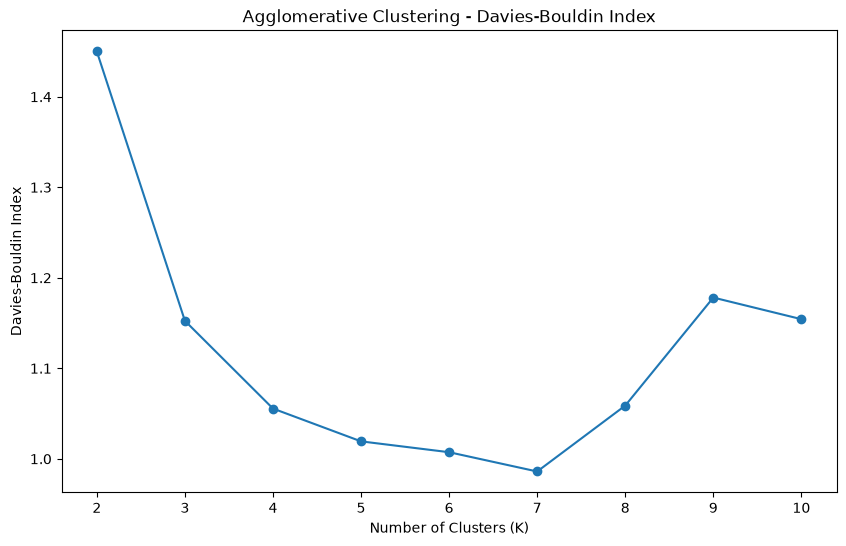

In [72]:
# ==================================================
# Davies-Bouldin Index
# ==================================================

plt.figure(figsize=(10, 6))

plt.plot(
    agglomerative_results_df["K"],
    agglomerative_results_df["Davies-Bouldin Index"],
    marker="o",
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Davies-Bouldin Index")
plt.title("Agglomerative Clustering - Davies-Bouldin Index")
plt.xticks(list(K_RANGE))
plt.show()

### 9.2.5 Calinski-Harabasz Score

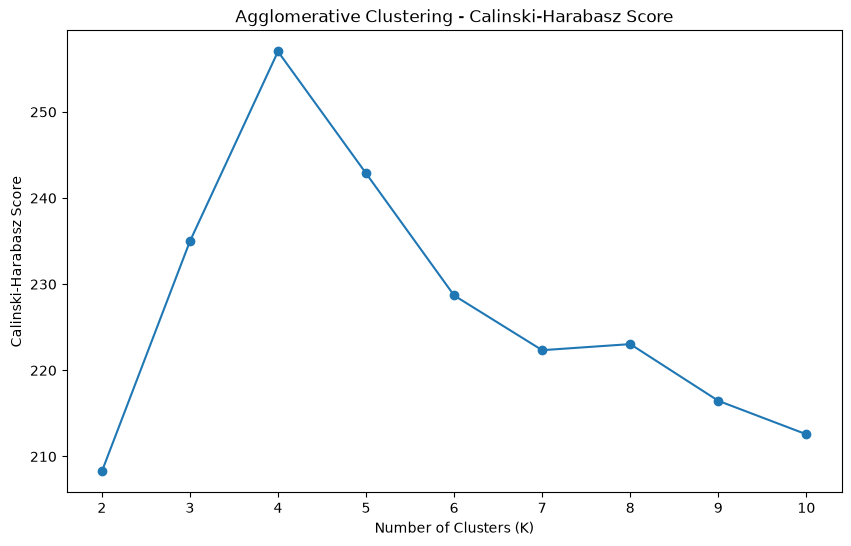

In [73]:
# ==================================================
# Calinski-Harabasz Score
# ==================================================

plt.figure(figsize=(10, 6))

plt.plot(
    agglomerative_results_df["K"],
    agglomerative_results_df["Calinski-Harabasz Score"],
    marker="o",
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Agglomerative Clustering - Calinski-Harabasz Score")
plt.xticks(list(K_RANGE))
plt.show()

### 9.2.6 Compare Directly Against K-Means

In [74]:
# ==================================================
# Compare K-Means and Agglomerative Results
# ==================================================

traditional_model_comparison_df = pd.concat([
    kmeans_results_df[
        [
            "Model",
            "K",
            "Silhouette Score",
            "Davies-Bouldin Index",
            "Calinski-Harabasz Score",
        ]
    ],
    agglomerative_results_df,
], ignore_index=True)

traditional_model_comparison_df

,Model,K,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,K-Means,2,0.319061,1.369437,249.046472
1,K-Means,3,0.348711,1.143806,240.160732
2,K-Means,4,0.349593,1.057253,277.647527
3,K-Means,5,0.366551,0.978495,273.430977
4,K-Means,6,0.362804,1.002467,260.779147
5,K-Means,7,0.370703,0.993112,257.927914
6,K-Means,8,0.316147,1.054260,254.259554
7,K-Means,9,0.320375,1.011666,252.947603
8,K-Means,10,0.322486,1.017627,245.270329
9,Agglomerative,2,0.295106,1.450031,208.256556


In [75]:
# ==================================================
# Best Configuration per Algorithm
# ==================================================

best_configurations = pd.DataFrame([
    {
        "Model": "K-Means",
        "Best Silhouette K": best_silhouette_k,
        "Best DBI K": best_davies_bouldin_k,
        "Best CH K": best_calinski_harabasz_k,
    },
    {
        "Model": "Agglomerative",
        "Best Silhouette K": best_agg_silhouette_k,
        "Best DBI K": best_agg_davies_bouldin_k,
        "Best CH K": best_agg_calinski_harabasz_k,
    },
])

best_configurations

,Model,Best Silhouette K,Best DBI K,Best CH K
0,K-Means,7,5,4
1,Agglomerative,6,7,4


In [76]:
# ==================================================
# Agglomerative Candidate Solutions
# ==================================================

agg_candidate_k_values = [4, 6, 7]

agg_candidate_cluster_results = {}

for k in agg_candidate_k_values:

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward",
    )

    labels = model.fit_predict(X_cluster)

    agg_candidate_cluster_results[k] = {
        "model": model,
        "labels": labels,
    }

    cluster_sizes = (
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )

    print(f"\nK = {k}")
    print(cluster_sizes)


K = 4
0    303
1     69
2     61
3    155
Name: count, dtype: int64

K = 6
0    155
1    262
2     61
3     32
4     41
5     37
Name: count, dtype: int64

K = 7
0     61
1    262
2    108
3     32
4     41
5     37
6     47
Name: count, dtype: int64


### 9.2.7 Candidate Cluster Profile Comparison

Candidate Agglomerative Clustering solutions are compared using the median values of the balanced clustering KPIs within each cluster. As with the K-Means baseline, both raw KPI medians and standardised cluster profiles are examined to assess whether additional clusters reveal genuinely distinct financial archetypes.

In [77]:
# ==================================================
# Build Agglomerative Candidate Cluster Profiles
# ==================================================

agg_candidate_k_values = [4, 6, 7]

agg_candidate_cluster_results = {}

for k in agg_candidate_k_values:

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward",
    )

    labels = model.fit_predict(X_cluster)

    agg_candidate_cluster_results[k] = {
        "model": model,
        "labels": labels,
    }

agg_candidate_cluster_profiles = {}

for k, result in agg_candidate_cluster_results.items():

    profile_df = peer_universe_df.copy()
    profile_df["Cluster"] = result["labels"]

    cluster_profile = (
        profile_df
        .groupby("Cluster")[balanced_clustering_kpis]
        .median()
    )

    agg_candidate_cluster_profiles[k] = cluster_profile

    print(f"\nK = {k}")
    display(cluster_profile)


K = 4


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.191174,0.057743,0.593730,3.701225e+05,1.800306,0.180540,0.152648,1.839595
1,-0.445817,-0.281418,0.447391,2.573457e+05,2.626396,0.110365,-0.388299,0.420272
2,0.055649,0.024165,0.884521,1.979221e+06,1.705358,0.194676,0.025991,0.877259
3,0.004941,-0.048548,0.681026,3.621543e+05,1.659286,0.200134,0.045970,-1.204523



K = 6


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.004941,-0.048548,0.681026,3.621543e+05,1.659286,0.200134,0.045970,-1.204523
1,0.191086,0.057727,0.616199,3.629565e+05,1.595182,0.215030,0.151646,1.871157
2,0.055649,0.024165,0.884521,1.979221e+06,1.705358,0.194676,0.025991,0.877259
3,-0.310246,-0.100547,0.368610,2.717425e+05,5.244454,0.041885,-0.296773,0.383032
4,0.192153,0.057759,0.478709,4.145614e+05,6.482053,0.022165,0.161175,1.569946
5,-0.697904,-0.524118,0.567417,2.443098e+05,1.227205,0.259063,-0.435338,0.472094



K = 7


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.055649,0.024165,0.884521,1.979221e+06,1.705358,0.194676,0.025991,0.877259
1,0.191086,0.057727,0.616199,3.629565e+05,1.595182,0.215030,0.151646,1.871157
2,-0.023554,-0.080649,0.727645,3.338740e+05,1.583716,0.208323,0.013811,-0.584377
3,-0.310246,-0.100547,0.368610,2.717425e+05,5.244454,0.041885,-0.296773,0.383032
4,0.192153,0.057759,0.478709,4.145614e+05,6.482053,0.022165,0.161175,1.569946
5,-0.697904,-0.524118,0.567417,2.443098e+05,1.227205,0.259063,-0.435338,0.472094
6,0.041133,-0.016942,0.637089,4.371535e+05,1.976053,0.156934,0.127079,-6.862472


In [78]:
# ==================================================
# Add Cluster Sizes to Agglomerative Profiles
# ==================================================

agg_candidate_cluster_profiles_with_counts = {}

for k, profile in agg_candidate_cluster_profiles.items():

    cluster_sizes = (
        pd.Series(agg_candidate_cluster_results[k]["labels"])
        .value_counts()
        .sort_index()
        .rename("Company Count")
    )

    profile_with_counts = profile.copy()

    profile_with_counts.insert(
        0,
        "Company Count",
        cluster_sizes
    )

    agg_candidate_cluster_profiles_with_counts[k] = profile_with_counts

    print(f"\nK = {k}")
    display(profile_with_counts)


K = 4


,Company Count,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,,
0,303,0.191174,0.057743,0.593730,3.701225e+05,1.800306,0.180540,0.152648,1.839595
1,69,-0.445817,-0.281418,0.447391,2.573457e+05,2.626396,0.110365,-0.388299,0.420272
2,61,0.055649,0.024165,0.884521,1.979221e+06,1.705358,0.194676,0.025991,0.877259
3,155,0.004941,-0.048548,0.681026,3.621543e+05,1.659286,0.200134,0.045970,-1.204523



K = 6


,Company Count,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,,
0,155,0.004941,-0.048548,0.681026,3.621543e+05,1.659286,0.200134,0.045970,-1.204523
1,262,0.191086,0.057727,0.616199,3.629565e+05,1.595182,0.215030,0.151646,1.871157
2,61,0.055649,0.024165,0.884521,1.979221e+06,1.705358,0.194676,0.025991,0.877259
3,32,-0.310246,-0.100547,0.368610,2.717425e+05,5.244454,0.041885,-0.296773,0.383032
4,41,0.192153,0.057759,0.478709,4.145614e+05,6.482053,0.022165,0.161175,1.569946
5,37,-0.697904,-0.524118,0.567417,2.443098e+05,1.227205,0.259063,-0.435338,0.472094



K = 7


,Company Count,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,,
0,61,0.055649,0.024165,0.884521,1.979221e+06,1.705358,0.194676,0.025991,0.877259
1,262,0.191086,0.057727,0.616199,3.629565e+05,1.595182,0.215030,0.151646,1.871157
2,108,-0.023554,-0.080649,0.727645,3.338740e+05,1.583716,0.208323,0.013811,-0.584377
3,32,-0.310246,-0.100547,0.368610,2.717425e+05,5.244454,0.041885,-0.296773,0.383032
4,41,0.192153,0.057759,0.478709,4.145614e+05,6.482053,0.022165,0.161175,1.569946
5,37,-0.697904,-0.524118,0.567417,2.443098e+05,1.227205,0.259063,-0.435338,0.472094
6,47,0.041133,-0.016942,0.637089,4.371535e+05,1.976053,0.156934,0.127079,-6.862472


In [79]:
# ==================================================
# Standardised Agglomerative Cluster Profiles
# ==================================================

agg_candidate_standardised_profiles = {}

for k, result in agg_candidate_cluster_results.items():

    scaled_profile_df = balanced_model_features_df.copy()
    scaled_profile_df["Cluster"] = result["labels"]

    standardised_profile = (
        scaled_profile_df
        .groupby("Cluster")[balanced_clustering_kpis]
        .median()
    )

    agg_candidate_standardised_profiles[k] = standardised_profile

    print(f"\nK = {k}")
    display(standardised_profile)


K = 4


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.430198,0.320141,-0.031929,0.000000,0.003887,0.000000,0.315343,0.335161
1,-2.376558,-2.410933,-0.314901,-0.300499,0.511278,-0.211477,-2.370817,-0.340796
2,-0.166960,0.049870,0.523407,4.533386,-0.054431,0.000000,-0.310939,-0.110897
3,-0.388925,-0.530775,0.129359,-0.042410,-0.082729,0.041168,-0.211607,-1.121047



K = 6


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,-0.388925,-0.530775,0.129359,-0.042410,-0.082729,0.041168,-0.211607,-1.121047
1,0.429811,0.318715,0.008144,-0.001972,-0.122102,0.090982,0.313824,0.348552
2,-0.166960,0.049870,0.523407,4.533386,-0.054431,0.000000,-0.310939,-0.110897
3,-1.779194,-0.954411,-0.465984,-0.303560,2.119313,-0.469030,-1.915743,-0.358679
4,0.434515,0.320401,-0.254841,0.064500,2.879457,-0.527080,0.338547,0.211295
5,-3.487323,-3.229885,-0.084722,-0.203253,-0.348117,0.260982,-2.604698,-0.315910



K = 7


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,-0.166960,0.049870,0.523407,4.533386,-0.054431,0.000000,-0.310939,-0.110897
1,0.429811,0.318715,0.008144,-0.001972,-0.122102,0.090982,0.313824,0.348552
2,-0.505665,-0.769209,0.221726,-0.107572,-0.129144,0.089866,-0.371499,-0.823243
3,-1.779194,-0.954411,-0.465984,-0.303560,2.119313,-0.469030,-1.915743,-0.358679
4,0.434515,0.320401,-0.254841,0.064500,2.879457,-0.527080,0.338547,0.211295
5,-3.487323,-3.229885,-0.084722,-0.203253,-0.348117,0.260982,-2.604698,-0.315910
6,-0.230923,-0.281155,0.048892,0.072493,0.111832,-0.066028,0.191674,-2.943692


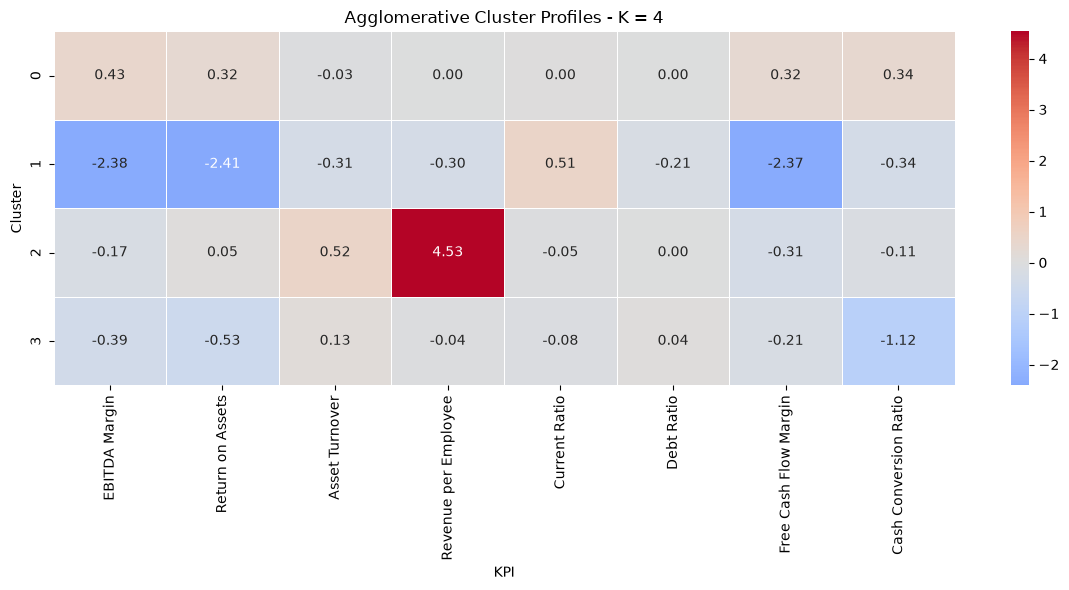

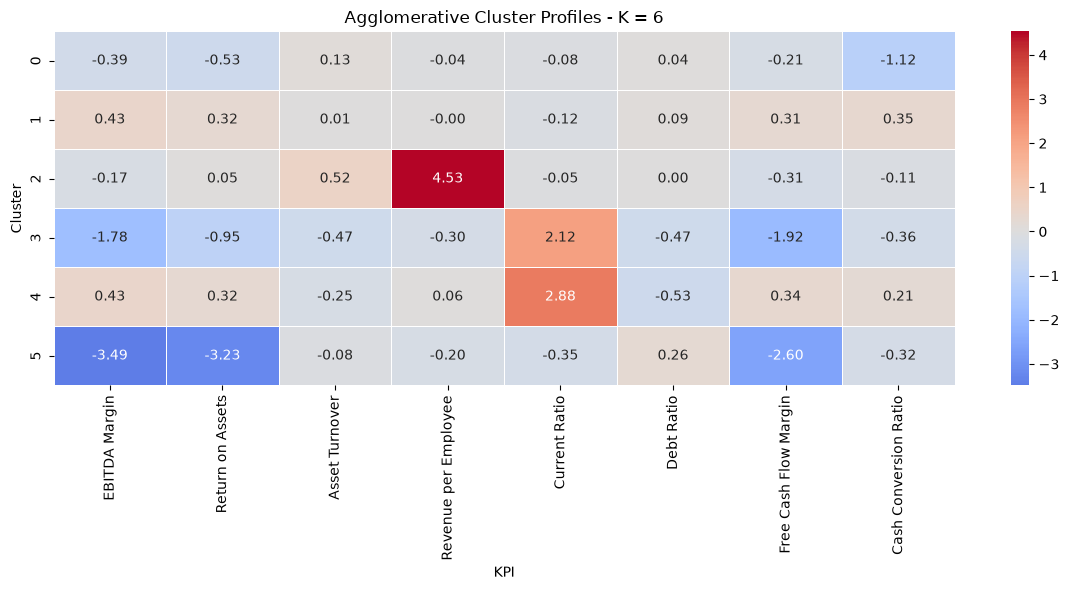

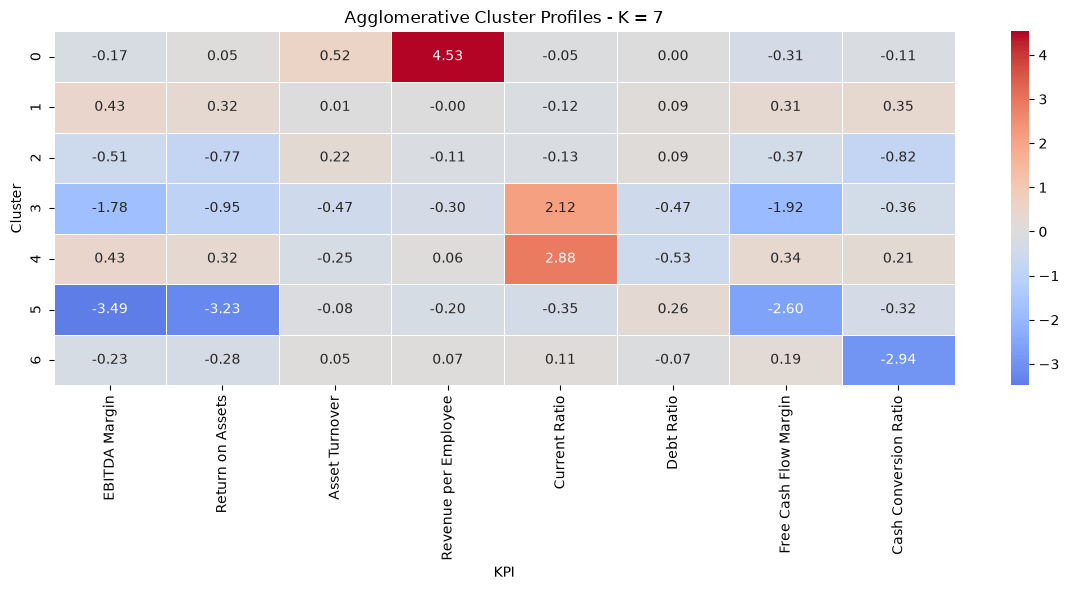

In [80]:
# ==================================================
# Agglomerative Candidate Cluster Profile Heatmaps
# ==================================================

for k, profile in agg_candidate_standardised_profiles.items():

    plt.figure(figsize=(12, 6))

    sns.heatmap(
        profile,
        annot=True,
        fmt=".2f",
        center=0,
        cmap="coolwarm",
        linewidths=0.5
    )

    plt.title(f"Agglomerative Cluster Profiles - K = {k}")
    plt.xlabel("KPI")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()

For Agglomerative Clustering, I'll choose K=6

for this Technology / revenue ≥ $25M experiment

## **9.3 Gaussian Mixture Models**

Gaussian Mixture Models are evaluated as a probabilistic alternative to K-Means and Agglomerative Clustering. Rather than assigning each company deterministically to a single cluster, GMM estimates the probability that each observation belongs to every cluster.

This soft-assignment approach can be very relevant to financial peer selection, as some companies may exhibit characteristics of multiple financial archetypes rather than fitting cleanly within a single peer group.

To ensure comparability with previous experiments, GMM is applied to the same four-component PCA representation and evaluated using the same internal validation metrics.

### 9.3.1 Evaluate Candidate Cluster Counts

In [81]:
# ==================================================
# Evaluate Gaussian Mixture Models
# ==================================================

from sklearn.mixture import GaussianMixture

gmm_results = []

for k in K_RANGE:

    model = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=RANDOM_STATE,
        n_init=10,
    )

    cluster_labels = model.fit_predict(X_cluster)

    gmm_results.append({
        "Model": "Gaussian Mixture",
        "K": k,
        "Silhouette Score": silhouette_score(
            X_cluster,
            cluster_labels
        ),
        "Davies-Bouldin Index": davies_bouldin_score(
            X_cluster,
            cluster_labels
        ),
        "Calinski-Harabasz Score": calinski_harabasz_score(
            X_cluster,
            cluster_labels
        ),
        "AIC": model.aic(X_cluster),
        "BIC": model.bic(X_cluster),
    })

gmm_results_df = pd.DataFrame(gmm_results)

gmm_results_df

,Model,K,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,AIC,BIC
0,Gaussian Mixture,2,0.254293,2.276902,100.093423,7119.191140,7246.116222
1,Gaussian Mixture,3,0.270513,1.606195,165.499963,6873.109042,7065.685028
2,Gaussian Mixture,4,0.263630,1.422348,171.173556,6599.356478,6857.583368
3,Gaussian Mixture,5,0.268021,1.592171,166.826275,6498.648605,6822.526399
4,Gaussian Mixture,6,0.230164,1.440857,150.029372,6327.309528,6716.838227
5,Gaussian Mixture,7,0.229873,1.398148,146.100193,6237.643134,6692.822737
6,Gaussian Mixture,8,0.203427,1.323506,141.791415,6013.577260,6534.407767
7,Gaussian Mixture,9,0.203903,1.317608,133.992217,5968.569705,6555.051116
8,Gaussian Mixture,10,0.209222,1.137737,146.313967,5921.817704,6573.950020


### 9.3.2 Identify Best K by Metric

In [82]:
# ==================================================
# Best K by Evaluation Metric
# ==================================================

best_gmm_silhouette_k = (
    gmm_results_df
    .loc[
        gmm_results_df["Silhouette Score"].idxmax(),
        "K"
    ]
)

best_gmm_davies_bouldin_k = (
    gmm_results_df
    .loc[
        gmm_results_df["Davies-Bouldin Index"].idxmin(),
        "K"
    ]
)

best_gmm_calinski_harabasz_k = (
    gmm_results_df
    .loc[
        gmm_results_df["Calinski-Harabasz Score"].idxmax(),
        "K"
    ]
)

best_gmm_aic_k = (
    gmm_results_df
    .loc[
        gmm_results_df["AIC"].idxmin(),
        "K"
    ]
)

best_gmm_bic_k = (
    gmm_results_df
    .loc[
        gmm_results_df["BIC"].idxmin(),
        "K"
    ]
)

print(f"Best K by Silhouette Score: {best_gmm_silhouette_k}")
print(f"Best K by Davies-Bouldin Index: {best_gmm_davies_bouldin_k}")
print(f"Best K by Calinski-Harabasz Score: {best_gmm_calinski_harabasz_k}")
print(f"Best K by AIC: {best_gmm_aic_k}")
print(f"Best K by BIC: {best_gmm_bic_k}")

Best K by Silhouette Score: 3
Best K by Davies-Bouldin Index: 10
Best K by Calinski-Harabasz Score: 4
Best K by AIC: 10
Best K by BIC: 8


### 9.3.3 Silhouette Score

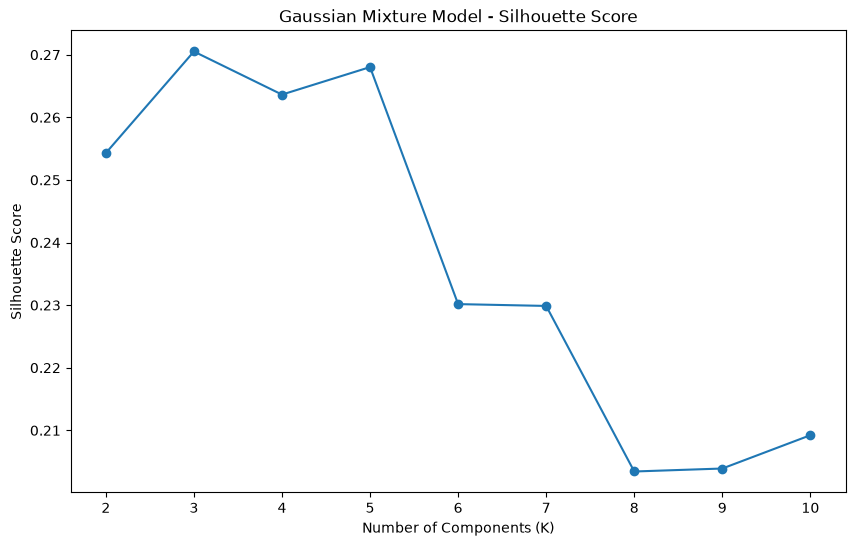

In [83]:
plt.figure(figsize=(10, 6))

plt.plot(
    gmm_results_df["K"],
    gmm_results_df["Silhouette Score"],
    marker="o",
)

plt.xlabel("Number of Components (K)")
plt.ylabel("Silhouette Score")
plt.title("Gaussian Mixture Model - Silhouette Score")
plt.xticks(list(K_RANGE))
plt.show()

### 9.3.4 Davies-Bouldin Index

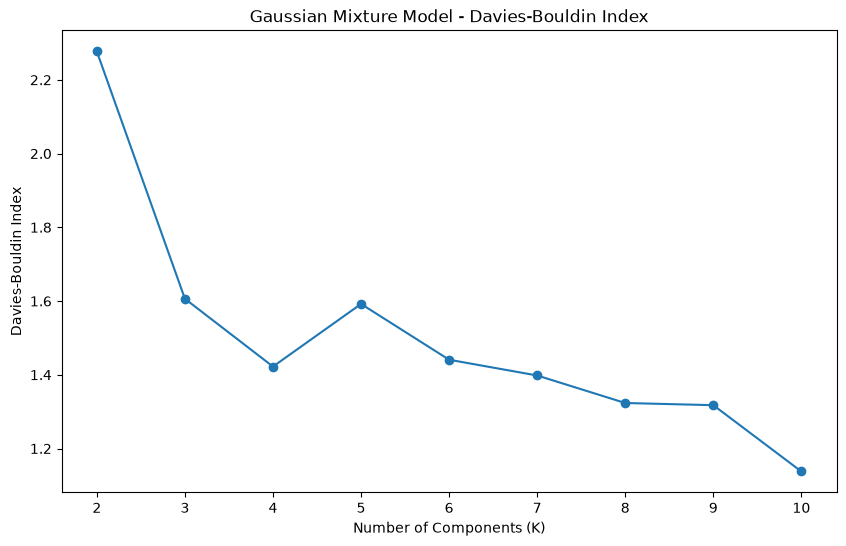

In [84]:
plt.figure(figsize=(10, 6))

plt.plot(
    gmm_results_df["K"],
    gmm_results_df["Davies-Bouldin Index"],
    marker="o",
)

plt.xlabel("Number of Components (K)")
plt.ylabel("Davies-Bouldin Index")
plt.title("Gaussian Mixture Model - Davies-Bouldin Index")
plt.xticks(list(K_RANGE))
plt.show()

### 9.3.5 Calinski-Harabasz Score

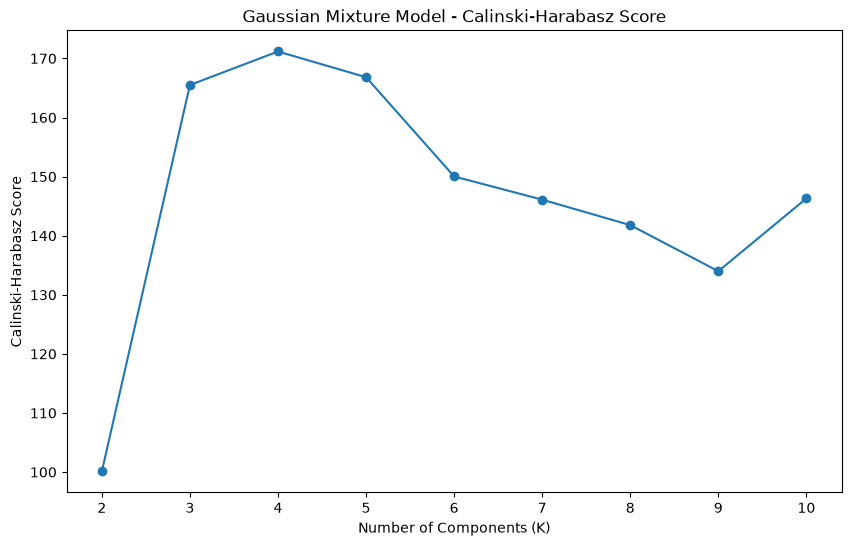

In [85]:
plt.figure(figsize=(10, 6))

plt.plot(
    gmm_results_df["K"],
    gmm_results_df["Calinski-Harabasz Score"],
    marker="o",
)

plt.xlabel("Number of Components (K)")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Gaussian Mixture Model - Calinski-Harabasz Score")
plt.xticks(list(K_RANGE))
plt.show()

### 9.2.6 Plot AIC and BIC

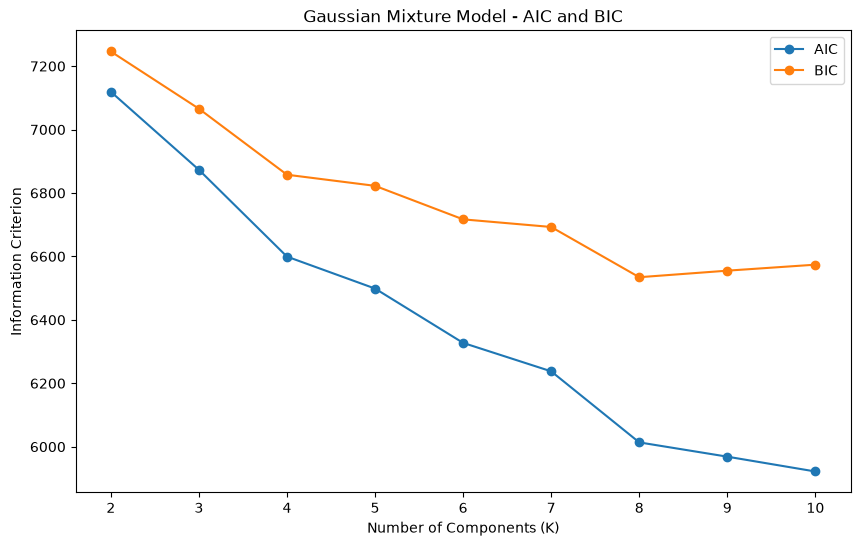

In [86]:
# ==================================================
# AIC and BIC
# ==================================================

plt.figure(figsize=(10, 6))

plt.plot(
    gmm_results_df["K"],
    gmm_results_df["AIC"],
    marker="o",
    label="AIC",
)

plt.plot(
    gmm_results_df["K"],
    gmm_results_df["BIC"],
    marker="o",
    label="BIC",
)

plt.xlabel("Number of Components (K)")
plt.ylabel("Information Criterion")
plt.title("Gaussian Mixture Model - AIC and BIC")
plt.xticks(list(K_RANGE))
plt.legend()
plt.show()

### 9.3.7 Compare Against Existing Algorithms

In [87]:
# ==================================================
# Compare Traditional Clustering Algorithms
# ==================================================

traditional_model_comparison_df = pd.concat([
    kmeans_results_df[
        [
            "Model",
            "K",
            "Silhouette Score",
            "Davies-Bouldin Index",
            "Calinski-Harabasz Score",
        ]
    ],
    agglomerative_results_df,
    gmm_results_df[
        [
            "Model",
            "K",
            "Silhouette Score",
            "Davies-Bouldin Index",
            "Calinski-Harabasz Score",
        ]
    ],
], ignore_index=True)

traditional_model_comparison_df

,Model,K,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,K-Means,2,0.319061,1.369437,249.046472
1,K-Means,3,0.348711,1.143806,240.160732
2,K-Means,4,0.349593,1.057253,277.647527
3,K-Means,5,0.366551,0.978495,273.430977
4,K-Means,6,0.362804,1.002467,260.779147
5,K-Means,7,0.370703,0.993112,257.927914
6,K-Means,8,0.316147,1.054260,254.259554
7,K-Means,9,0.320375,1.011666,252.947603
8,K-Means,10,0.322486,1.017627,245.270329
9,Agglomerative,2,0.295106,1.450031,208.256556


Update configuration table

In [88]:
best_configurations = pd.DataFrame([
    {
        "Model": "K-Means",
        "Best Silhouette K": best_silhouette_k,
        "Best DBI K": best_davies_bouldin_k,
        "Best CH K": best_calinski_harabasz_k,
    },
    {
        "Model": "Agglomerative",
        "Best Silhouette K": best_agg_silhouette_k,
        "Best DBI K": best_agg_davies_bouldin_k,
        "Best CH K": best_agg_calinski_harabasz_k,
    },
    {
        "Model": "Gaussian Mixture",
        "Best Silhouette K": best_gmm_silhouette_k,
        "Best DBI K": best_gmm_davies_bouldin_k,
        "Best CH K": best_gmm_calinski_harabasz_k,
    },
])

best_configurations

,Model,Best Silhouette K,Best DBI K,Best CH K
0,K-Means,7,5,4
1,Agglomerative,6,7,4
2,Gaussian Mixture,3,10,4


### 9.3.8 Candidate GMM Solutions

In [89]:
gmm_candidate_k_values = [3, 4, 5, 8]

In [90]:
# ==================================================
# Fit Candidate GMM Solutions
# ==================================================

gmm_candidate_cluster_results = {}

for k in gmm_candidate_k_values:

    model = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=RANDOM_STATE,
        n_init=10,
    )

    labels = model.fit_predict(X_cluster)
    probabilities = model.predict_proba(X_cluster)

    gmm_candidate_cluster_results[k] = {
        "model": model,
        "labels": labels,
        "probabilities": probabilities,
    }

### 9.3.9 Cluster Size Balance

In [91]:
# ==================================================
# Candidate GMM Cluster Sizes
# ==================================================

gmm_cluster_size_records = []

for k, result in gmm_candidate_cluster_results.items():

    cluster_sizes = (
        pd.Series(result["labels"])
        .value_counts()
        .sort_index()
    )

    print(f"\nK = {k}")
    print(cluster_sizes)

    for cluster, size in cluster_sizes.items():
        gmm_cluster_size_records.append({
            "K": k,
            "Cluster": cluster,
            "Company Count": size,
            "Cluster Share": size / len(X_cluster),
        })

gmm_cluster_size_summary_df = pd.DataFrame(
    gmm_cluster_size_records
)

gmm_cluster_size_summary_df


K = 3
0    151
1    342
2     95
Name: count, dtype: int64

K = 4
0    165
1    223
2     87
3    113
Name: count, dtype: int64

K = 5
0    217
1     94
2    106
3     54
4    117
Name: count, dtype: int64

K = 8
0     67
1    175
2     94
3     76
4     48
5     53
6     36
7     39
Name: count, dtype: int64


,K,Cluster,Company Count,Cluster Share
0,3,0,151,0.256803
1,3,1,342,0.581633
2,3,2,95,0.161565
3,4,0,165,0.280612
4,4,1,223,0.379252
5,4,2,87,0.147959
6,4,3,113,0.192177
7,5,0,217,0.369048
8,5,1,94,0.159864
9,5,2,106,0.180272


In [92]:
gmm_cluster_balance_summary = (
    gmm_cluster_size_summary_df
    .groupby("K")
    .agg(
        Smallest_Cluster=("Company Count", "min"),
        Largest_Cluster=("Company Count", "max"),
        Smallest_Share=("Cluster Share", "min"),
        Largest_Share=("Cluster Share", "max"),
    )
)

gmm_cluster_balance_summary

,Smallest_Cluster,Largest_Cluster,Smallest_Share,Largest_Share
K,,,,
3,95,342,0.161565,0.581633
4,87,223,0.147959,0.379252
5,54,217,0.091837,0.369048
8,36,175,0.061224,0.297619


### 9.3.10 Membership Confidence Analysis

In [93]:
# ==================================================
# Membership Confidence Analysis
# ==================================================

gmm_confidence_summaries = {}

for k, result in gmm_candidate_cluster_results.items():

    probabilities = result["probabilities"]

    max_probability = probabilities.max(axis=1)

    confidence_summary = pd.Series(
        max_probability
    ).describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
    )

    gmm_confidence_summaries[k] = confidence_summary

    print(f"\nK = {k}")
    display(confidence_summary)


K = 3


count    588.000000
mean       0.940717
std        0.115247
min        0.464726
10%        0.777290
25%        0.957306
50%        0.992100
75%        0.999468
90%        1.000000
max        1.000000
dtype: float64


K = 4


count    588.000000
mean       0.943001
std        0.115683
min        0.425971
10%        0.776913
25%        0.964047
50%        0.994402
75%        0.999504
90%        1.000000
max        1.000000
dtype: float64


K = 5


count    588.000000
mean       0.941514
std        0.106900
min        0.491904
10%        0.794915
25%        0.949003
50%        0.988318
75%        0.996443
90%        0.998744
max        1.000000
dtype: float64


K = 8


count    588.000000
mean       0.942446
std        0.102209
min        0.473938
10%        0.804901
25%        0.950851
50%        0.984532
75%        0.997331
90%        0.999665
max        1.000000
dtype: float64

In [94]:
# ==================================================
# Ambiguous Membership Rates
# ==================================================

confidence_thresholds = [0.50, 0.60, 0.70, 0.80]

gmm_ambiguity_records = []

for k, result in gmm_candidate_cluster_results.items():

    max_probability = result["probabilities"].max(axis=1)

    for threshold in confidence_thresholds:

        ambiguous_share = (
            max_probability < threshold
        ).mean()

        gmm_ambiguity_records.append({
            "K": k,
            "Confidence Threshold": threshold,
            "Ambiguous Company Share": ambiguous_share,
        })

gmm_ambiguity_summary_df = pd.DataFrame(
    gmm_ambiguity_records
)

gmm_ambiguity_summary_df

,K,Confidence Threshold,Ambiguous Company Share
0,3,0.5,0.005102
1,3,0.6,0.037415
2,3,0.7,0.074830
3,3,0.8,0.119048
4,4,0.5,0.005102
5,4,0.6,0.037415
6,4,0.7,0.071429
7,4,0.8,0.117347
8,5,0.5,0.001701
9,5,0.6,0.032313


### 9.3.11 Candidate Cluster Profile Comparison

In [95]:
# ==================================================
# Build Candidate GMM Cluster Profiles
# ==================================================

gmm_candidate_cluster_profiles = {}

for k, result in gmm_candidate_cluster_results.items():

    profile_df = peer_universe_df.copy()
    profile_df["Cluster"] = result["labels"]

    cluster_profile = (
        profile_df
        .groupby("Cluster")[balanced_clustering_kpis]
        .median()
    )

    gmm_candidate_cluster_profiles[k] = cluster_profile

    print(f"\nK = {k}")
    display(cluster_profile)


K = 3


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.127005,0.052648,0.646025,1.031322e+06,2.618533,0.088948,0.102357,1.340110
1,0.125465,0.028105,0.625137,3.408975e+05,1.643102,0.213257,0.129990,1.317084
2,-0.316858,-0.232935,0.541344,3.006212e+05,1.659286,0.190599,-0.142968,0.253558



K = 4


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.104388,0.050915,0.665314,950200.776645,2.601925,0.086511,0.079503,1.321424
1,0.188336,0.049314,0.602476,326486.027588,1.579522,0.229723,0.144969,1.915132
2,-0.338407,-0.234467,0.536089,284768.928571,1.737633,0.186315,-0.176626,0.293488
3,0.026941,-0.033475,0.667930,363318.668281,1.722444,0.205120,0.074222,-2.461920



K = 5


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.185812,0.049113,0.602476,3.260784e+05,1.561907,0.232048,0.143419,1.923213
1,-0.315823,-0.224862,0.542060,2.980820e+05,1.759672,0.182537,-0.120632,0.251262
2,0.023756,-0.033475,0.684145,3.488583e+05,1.737326,0.208125,0.063390,-2.274179
3,-0.058247,-0.060280,0.541196,1.049046e+06,1.713260,0.109328,-0.108306,-0.078738
4,0.201282,0.096842,0.641145,8.929157e+05,2.850026,0.068071,0.185494,1.570103



K = 8


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.013420,-0.057752,0.706031,3.256881e+05,1.692134,0.272078,0.046530,-1.065644
1,0.201928,0.060499,0.606311,3.176441e+05,1.603931,0.202252,0.145421,1.649203
2,-0.315823,-0.224862,0.542060,3.006212e+05,1.722490,0.184642,-0.120632,0.251262
3,0.210003,0.108822,0.835028,1.145299e+06,2.006355,0.206454,0.188494,1.461843
4,0.102598,0.011660,0.590610,3.703208e+05,1.538326,0.250525,0.141922,10.069973
5,-0.060425,-0.067138,0.633060,1.070118e+06,1.681595,0.109328,-0.067323,-0.166495
6,0.039394,-0.013362,0.672651,3.953539e+05,1.924605,0.131081,0.125748,-8.564206
7,0.192153,0.066361,0.462641,4.469968e+05,6.482053,0.018073,0.161175,1.562210


In [96]:
# ==================================================
# Standardised GMM Cluster Profiles
# ==================================================

gmm_candidate_standardised_profiles = {}

for k, result in gmm_candidate_cluster_results.items():

    scaled_profile_df = balanced_model_features_df.copy()
    scaled_profile_df["Cluster"] = result["labels"]

    standardised_profile = (
        scaled_profile_df
        .groupby("Cluster")[balanced_clustering_kpis]
        .median()
    )

    gmm_candidate_standardised_profiles[k] = standardised_profile

    print(f"\nK = {k}")
    display(standardised_profile)


K = 3


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.147455,0.279240,0.066030,1.826814,0.506449,-0.281530,0.058127,0.100336
1,0.140667,0.079841,0.014431,-0.080658,-0.092669,0.078519,0.206148,0.089319
2,-1.804059,-2.020505,-0.134723,-0.188057,-0.082729,0.030546,-1.151017,-0.420855



K = 4


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.047796,0.265284,0.103021,1.589685,0.496248,-0.282604,-0.041287,0.088143
1,0.417695,0.252139,-0.017428,-0.115095,-0.131721,0.127143,0.280622,0.376886
2,-1.898629,-2.032847,-0.144800,-0.216425,-0.034607,0.016126,-1.318368,-0.401680
3,-0.293454,-0.406285,0.098172,-0.039401,-0.043937,0.077617,-0.071132,-1.724868



K = 5


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.406573,0.250216,-0.017428,-0.126207,-0.142540,0.135799,0.272919,0.377231
1,-1.794871,-1.955498,-0.133349,-0.195655,-0.021071,0.003408,-1.039959,-0.421957
2,-0.307488,-0.414293,0.139134,-0.047289,-0.034796,0.084477,-0.124993,-1.634712
3,-0.668817,-0.616307,-0.069135,1.831828,-0.049577,-0.201501,-0.978676,-0.574071
4,0.474737,0.635126,0.056670,1.446776,0.648634,-0.333686,0.478358,0.211295



K = 8


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,-0.353033,-0.597652,0.141319,-0.136607,-0.062553,0.273652,-0.208822,-1.054355
1,0.477583,0.340561,-0.008379,-0.160756,-0.116728,0.042049,0.282873,0.247283
2,-1.794871,-1.955498,-0.133349,-0.195655,-0.043908,0.010495,-1.039959,-0.421957
3,0.513167,0.731600,0.428491,2.169427,0.130444,0.059286,0.497032,0.158559
4,0.039911,-0.050831,-0.040243,-0.005254,-0.157023,0.168100,0.265475,1.858459
5,-0.678414,-0.685375,0.041166,1.836842,-0.069026,-0.232115,-0.774906,-0.585647
6,-0.238584,-0.252323,0.117092,0.042722,0.080232,-0.117905,0.185057,-2.943692
7,0.434515,0.389668,-0.285656,0.151907,2.879457,-0.544284,0.338547,0.207580


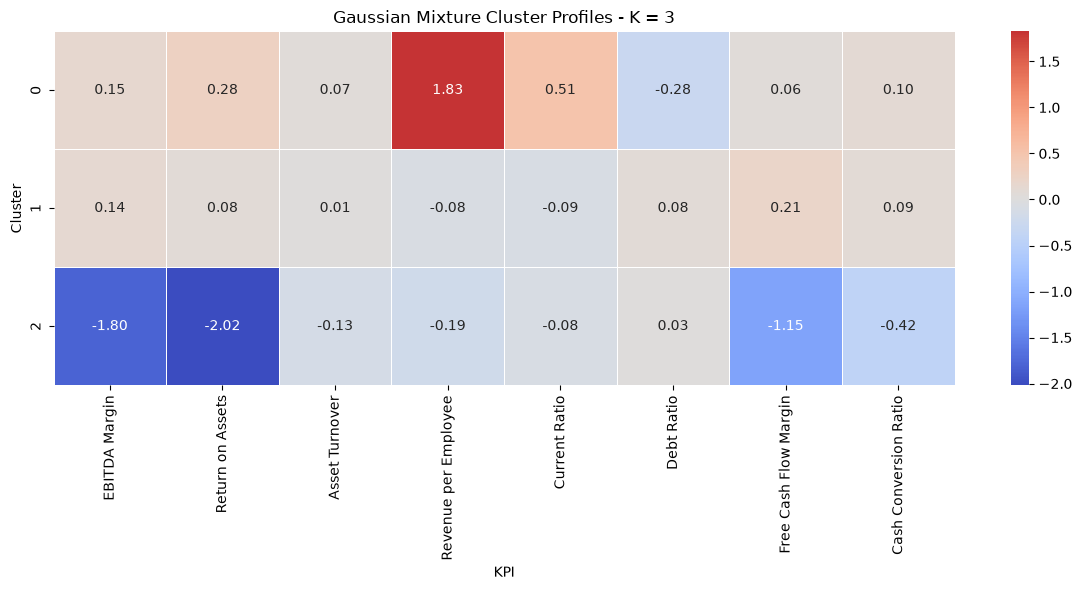

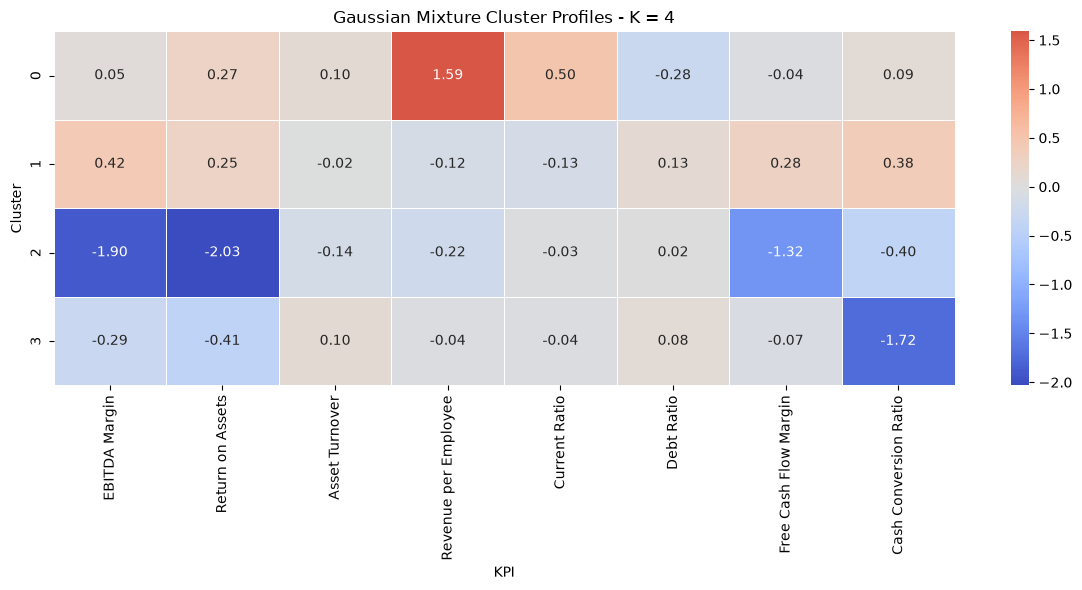

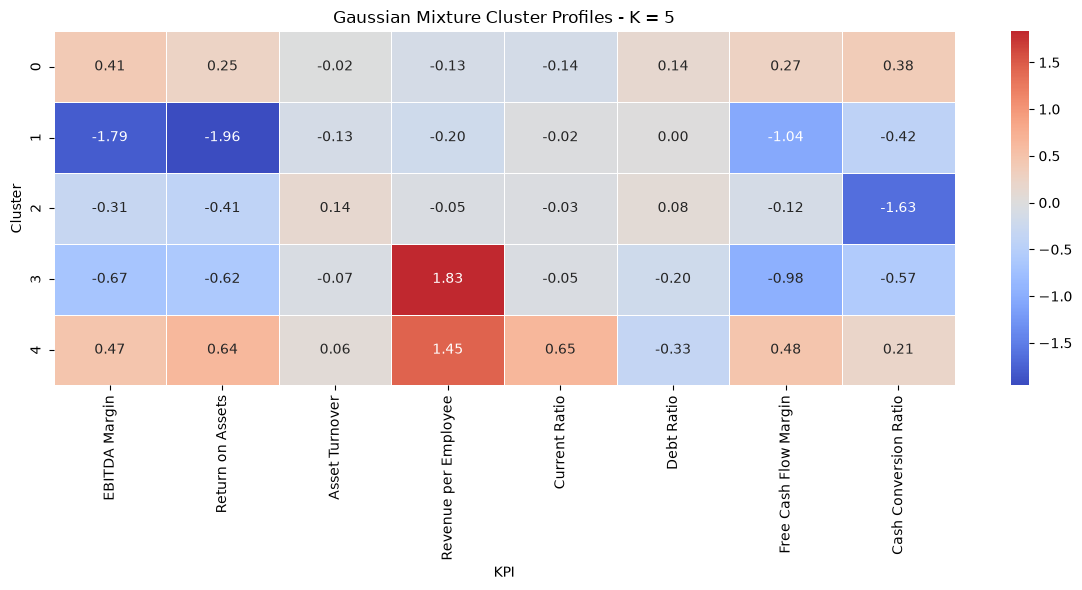

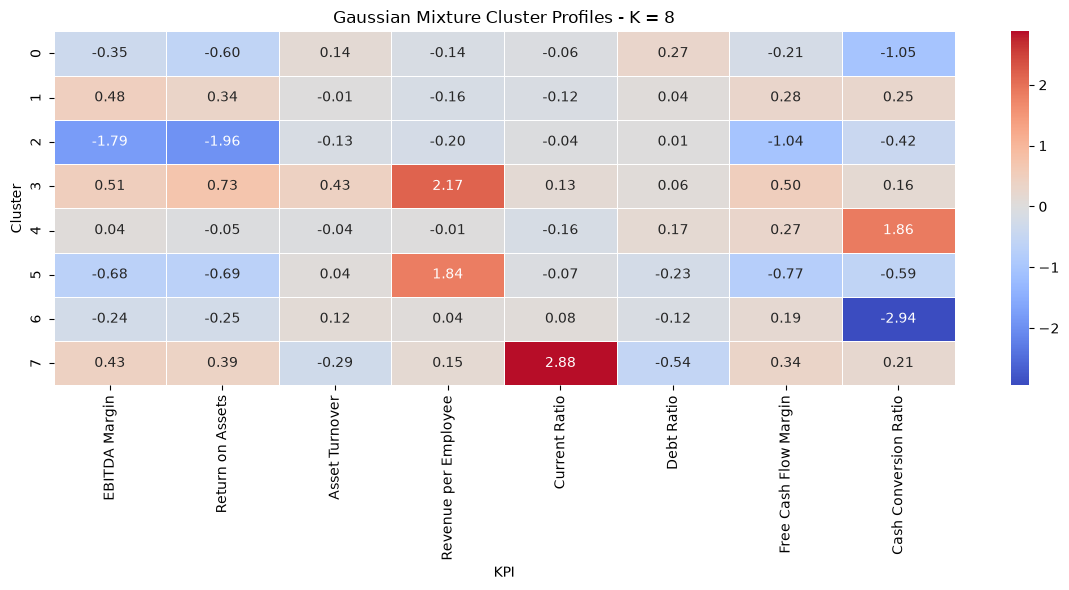

In [97]:
# ==================================================
# Candidate GMM Cluster Profile Heatmaps
# ==================================================

for k, profile in gmm_candidate_standardised_profiles.items():

    plt.figure(figsize=(12, 6))

    sns.heatmap(
        profile,
        annot=True,
        fmt=".2f",
        center=0,
        cmap="coolwarm",
        linewidths=0.5,
    )

    plt.title(f"Gaussian Mixture Cluster Profiles - K = {k}")
    plt.xlabel("KPI")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()

Preferred GMM configuration: K=5,
because it gives the best balance of:

- interpretable archetypes
- healthy cluster sizes
- strong membership confidence
- manageable complexity
- direct comparability with K-Means K=5

## 9.4 Density-Based Clustering with HDBSCAN

HDBSCAN is evaluated as a density-based alternative to the centroid-based, hierarchical and probabilistic methods examined previously. Rather than requiring every company to be assigned to a predefined number of clusters, HDBSCAN identifies stable dense regions in the feature space and may classify isolated observations as noise.

This characteristic is particularly relevant to automated financial peer selection, as some companies may not have sufficiently similar peers within the selected comparison universe. As with previous experiments, HDBSCAN is applied to the same four-component PCA representation.

In [98]:
from sklearn.cluster import HDBSCAN

### 9.4.1 Evaluate candidate minimum cluster sizes

In [99]:
MIN_CLUSTER_SIZES = [10, 15, 20, 25]
MIN_SAMPLES_VALUES = [5, 10, 15]

In [100]:
# ==================================================
# HDBSCAN Parameter Sensitivity Analysis
# ==================================================

hdbscan_tuning_results = []
hdbscan_tuning_candidate_results = {}

for min_cluster_size in MIN_CLUSTER_SIZES:
    for min_samples in MIN_SAMPLES_VALUES:

        model = HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
        )

        labels = model.fit_predict(X_cluster)

        non_noise_mask = labels != -1

        n_clusters = len(set(labels) - {-1})
        noise_count = (labels == -1).sum()
        noise_share = noise_count / len(labels)

        result = {
            "Min Cluster Size": min_cluster_size,
            "Min Samples": min_samples,
            "Number of Clusters": n_clusters,
            "Noise Count": noise_count,
            "Noise Share": noise_share,
        }

        if n_clusters >= 2 and non_noise_mask.sum() > n_clusters:

            result.update({
                "Silhouette Score": silhouette_score(
                    X_cluster[non_noise_mask],
                    labels[non_noise_mask],
                ),
                "Davies-Bouldin Index": davies_bouldin_score(
                    X_cluster[non_noise_mask],
                    labels[non_noise_mask],
                ),
                "Calinski-Harabasz Score": calinski_harabasz_score(
                    X_cluster[non_noise_mask],
                    labels[non_noise_mask],
                ),
            })

        else:

            result.update({
                "Silhouette Score": np.nan,
                "Davies-Bouldin Index": np.nan,
                "Calinski-Harabasz Score": np.nan,
            })

        # Store evaluation metrics
        hdbscan_tuning_results.append(result)

        # Store model outputs using BOTH parameters as the key
        hdbscan_tuning_candidate_results[
            (min_cluster_size, min_samples)
        ] = {
            "model": model,
            "labels": labels,
        }


hdbscan_tuning_results_df = pd.DataFrame(
    hdbscan_tuning_results
)

hdbscan_tuning_results_df

,Min Cluster Size,Min Samples,Number of Clusters,Noise Count,Noise Share,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,10,5,5,236,0.401361,0.467794,0.685629,236.521217
1,10,10,3,306,0.520408,0.485200,0.699859,252.305885
2,10,15,3,349,0.593537,0.509209,0.652650,259.813215
3,15,5,4,247,0.420068,0.470286,0.708144,282.234128
4,15,10,3,306,0.520408,0.485200,0.699859,252.305885
5,15,15,3,349,0.593537,0.509209,0.652650,259.813215
6,20,5,3,262,0.445578,0.460132,0.794721,277.772476
7,20,10,3,306,0.520408,0.485200,0.699859,252.305885
8,20,15,3,349,0.593537,0.509209,0.652650,259.813215
9,25,5,3,262,0.445578,0.460132,0.794721,277.772476


### 9.4.2 Add cluster balance diagnostics

In [101]:
# ==================================================
# HDBSCAN Tuned Cluster Size Summary
# ==================================================

hdbscan_cluster_size_records = []

for (
    min_cluster_size,
    min_samples,
), result in hdbscan_tuning_candidate_results.items():

    labels = result["labels"]

    cluster_sizes = (
        pd.Series(labels[labels != -1])
        .value_counts()
        .sort_index()
    )

    for cluster, size in cluster_sizes.items():

        hdbscan_cluster_size_records.append({
            "Min Cluster Size": min_cluster_size,
            "Min Samples": min_samples,
            "Cluster": cluster,
            "Company Count": size,
            "Cluster Share": size / len(labels),
        })


hdbscan_cluster_size_summary_df = pd.DataFrame(
    hdbscan_cluster_size_records
)

hdbscan_cluster_size_summary_df

,Min Cluster Size,Min Samples,Cluster,Company Count,Cluster Share
0,10,5,0,15,0.025510
1,10,5,1,11,0.018707
2,10,5,2,34,0.057823
3,10,5,3,216,0.367347
4,10,5,4,76,0.129252
5,10,10,0,199,0.338435
6,10,10,1,58,0.098639
7,10,10,2,25,0.042517
8,10,15,0,28,0.047619
9,10,15,1,172,0.292517


In [102]:
# ==================================================
# HDBSCAN Cluster Balance Summary
# ==================================================

hdbscan_cluster_balance_summary = (
    hdbscan_cluster_size_summary_df
    .groupby([
        "Min Cluster Size",
        "Min Samples",
    ])
    .agg(
        Smallest_Cluster=("Company Count", "min"),
        Largest_Cluster=("Company Count", "max"),
        Smallest_Share=("Cluster Share", "min"),
        Largest_Share=("Cluster Share", "max"),
    )
)

hdbscan_cluster_balance_summary

Smallest_Cluster  Largest_Cluster  \
Min Cluster Size Min Samples                                      
10               5                          11              216   
                 10                         25              199   
                 15                         28              172   
15               5                          15              216   
                 10                         25              199   
                 15                         28              172   
20               5                          34              216   
                 10                         25              199   
                 15                         28              172   
25               5                          34              216   
                 10                         25              199   
                 15                         28              172   

                              Smallest_Share  Largest_Share  
Min Cluster Size Min Samples                                 
10               5                  0.018707       0.367347  
                 10                 0.042517       0.338435  
                 15                 0.047619       0.292517  
15               5                  0.025510       0.367347  
                 10                 0.042517       0.338435  
                 15                 0.047619       0.292517  
20               5                  0.057823       0.367347  
                 10                 0.042517       0.338435  
                 15                 0.047619       0.292517  
25               5                  0.057823       0.367347  
                 10                 0.042517       0.338435  
                 15                 0.047619       0.292517

### 9.4.3 Discovered Clusters

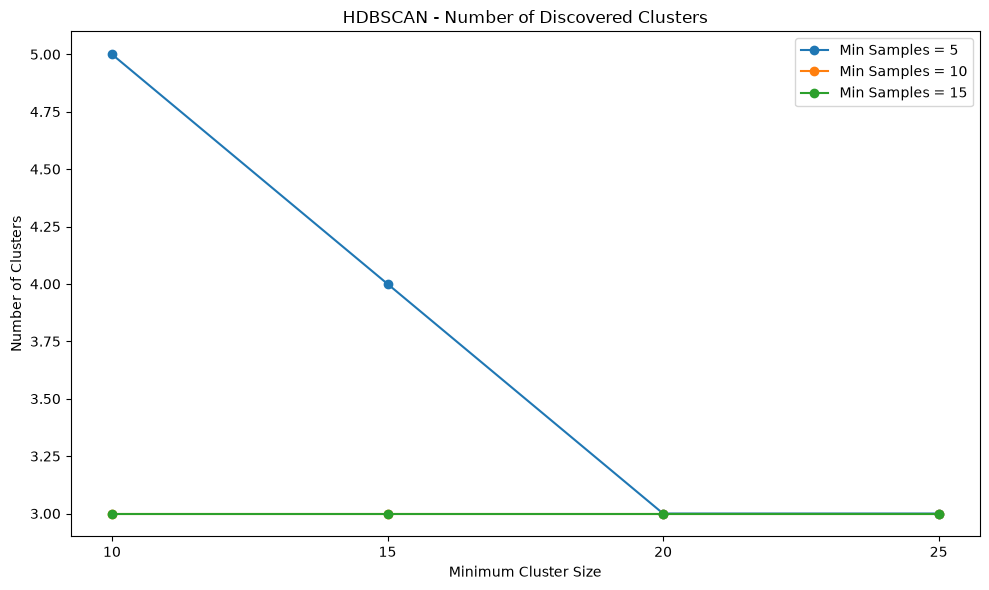

In [103]:
# ==================================================
# HDBSCAN - Number of Discovered Clusters
# ==================================================

plt.figure(figsize=(10, 6))

for min_samples in MIN_SAMPLES_VALUES:

    subset = hdbscan_tuning_results_df[
        hdbscan_tuning_results_df["Min Samples"] == min_samples
    ].sort_values("Min Cluster Size")

    plt.plot(
        subset["Min Cluster Size"],
        subset["Number of Clusters"],
        marker="o",
        label=f"Min Samples = {min_samples}",
    )

plt.xlabel("Minimum Cluster Size")
plt.ylabel("Number of Clusters")
plt.title("HDBSCAN - Number of Discovered Clusters")
plt.xticks(MIN_CLUSTER_SIZES)
plt.legend()
plt.tight_layout()
plt.show()

### 9.4.4 Companies Classified as Noise

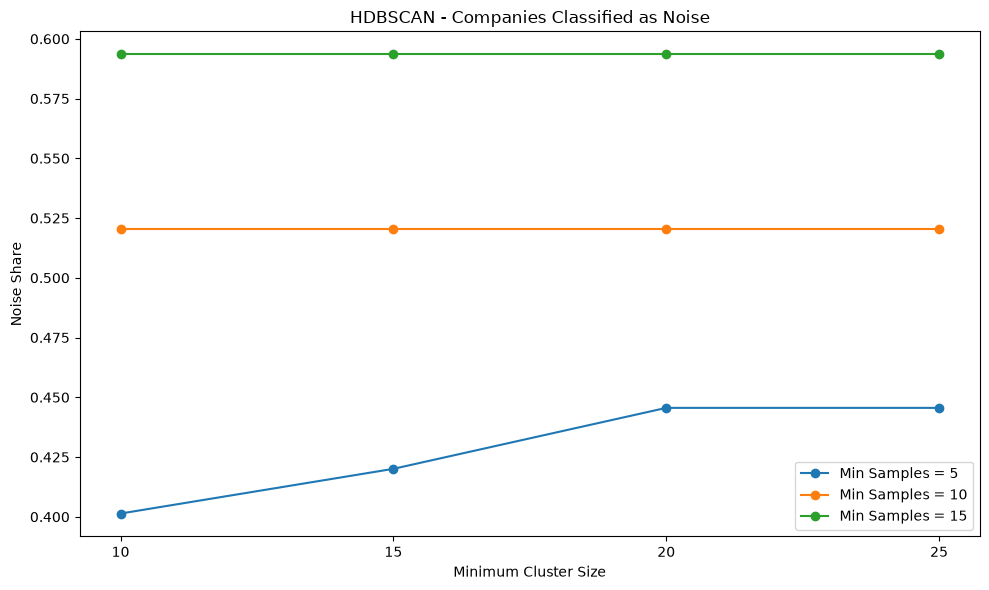

In [104]:
# ==================================================
# HDBSCAN - Companies Classified as Noise
# ==================================================

plt.figure(figsize=(10, 6))

for min_samples in MIN_SAMPLES_VALUES:

    subset = hdbscan_tuning_results_df[
        hdbscan_tuning_results_df["Min Samples"] == min_samples
    ].sort_values("Min Cluster Size")

    plt.plot(
        subset["Min Cluster Size"],
        subset["Noise Share"],
        marker="o",
        label=f"Min Samples = {min_samples}",
    )

plt.xlabel("Minimum Cluster Size")
plt.ylabel("Noise Share")
plt.title("HDBSCAN - Companies Classified as Noise")
plt.xticks(MIN_CLUSTER_SIZES)
plt.legend()
plt.tight_layout()
plt.show()

### 9.4.5 Silhouette Score

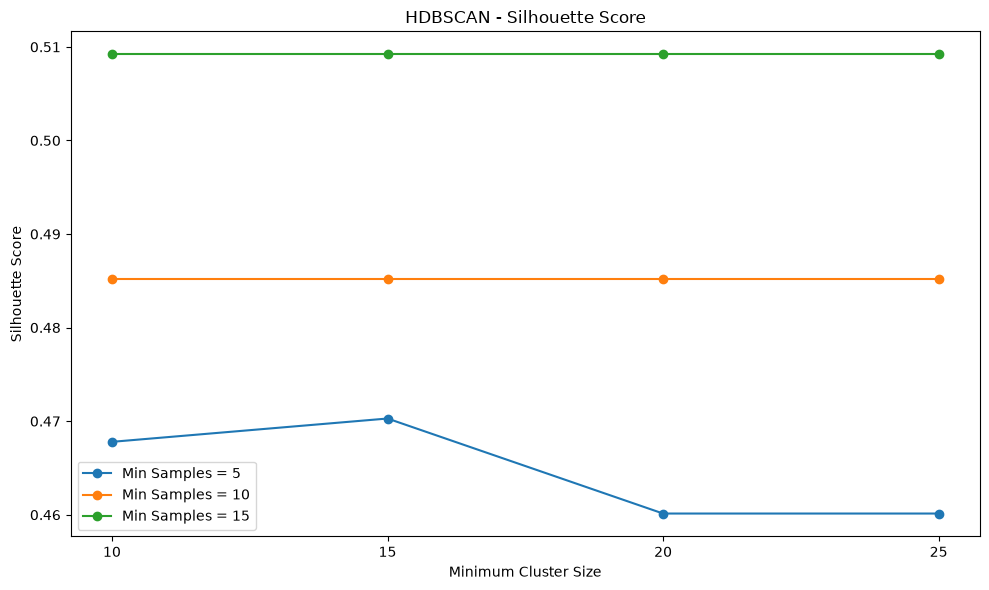

In [105]:
# ==================================================
# HDBSCAN - Silhouette Score
# ==================================================

plt.figure(figsize=(10, 6))

for min_samples in MIN_SAMPLES_VALUES:

    subset = hdbscan_tuning_results_df[
        hdbscan_tuning_results_df["Min Samples"] == min_samples
    ].sort_values("Min Cluster Size")

    plt.plot(
        subset["Min Cluster Size"],
        subset["Silhouette Score"],
        marker="o",
        label=f"Min Samples = {min_samples}",
    )

plt.xlabel("Minimum Cluster Size")
plt.ylabel("Silhouette Score")
plt.title("HDBSCAN - Silhouette Score")
plt.xticks(MIN_CLUSTER_SIZES)
plt.legend()
plt.tight_layout()
plt.show()

For Technology, Revenue >= $25M, min cluster sizes [20, 30, 40, 50, 75, 100]:

HDBSCAN produced the strongest separation among the companies it assigned to clusters, but achieved this by excluding approximately 63% of the peer universe as noise.

In [106]:
# Next step is to profile the three different configurations

Let’s profile exactly these three HDBSCAN configurations:

(10, 5)   → broader coverage, 5 clusters

(15, 5)   → balanced compromise, 4 clusters

(10, 15)  → high-purity solution, 3 clusters


### 9.4.6 Candidate Cluster Profile Comparison

Three candidate HDBSCAN configurations are compared to assess the trade-off between peer-universe coverage, cluster separation, and business interpretability.

Companies labelled as `-1` are treated as noise and excluded from cluster profile calculations because they do not represent a coherent peer group. The proportion of companies classified as noise is reported separately for each configuration.

In [107]:
# ==================================================
# Candidate HDBSCAN Configurations
# ==================================================

hdbscan_candidate_configurations = [
    (10, 5),   # Broader coverage
    (15, 5),   # Balanced compromise
    (10, 15),  # High-purity solution
]

hdbscan_candidate_configurations

[(10, 5), (15, 5), (10, 15)]

In [108]:
# ==================================================
# Build Candidate HDBSCAN Cluster Profiles
# ==================================================

hdbscan_candidate_cluster_profiles = {}
hdbscan_candidate_noise_summary = []

for configuration in hdbscan_candidate_configurations:

    min_cluster_size, min_samples = configuration

    result = hdbscan_tuning_candidate_results[
        (min_cluster_size, min_samples)
    ]

    labels = result["labels"]

    profile_df = peer_universe_df.copy()
    profile_df["Cluster"] = labels

    # Noise diagnostics
    noise_count = (profile_df["Cluster"] == -1).sum()
    noise_share = noise_count / len(profile_df)

    hdbscan_candidate_noise_summary.append({
        "Min Cluster Size": min_cluster_size,
        "Min Samples": min_samples,
        "Noise Count": noise_count,
        "Noise Share": noise_share,
    })

    # Remove noise before profiling real clusters
    clustered_profile_df = profile_df[
        profile_df["Cluster"] != -1
    ].copy()

    cluster_profile = (
        clustered_profile_df
        .groupby("Cluster")[balanced_clustering_kpis]
        .median()
    )

    hdbscan_candidate_cluster_profiles[
        configuration
    ] = cluster_profile

    print(
        f"\nMin Cluster Size = {min_cluster_size}, "
        f"Min Samples = {min_samples}"
    )

    display(cluster_profile)


Min Cluster Size = 10, Min Samples = 5


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.329886,0.135167,0.522170,2.955907e+06,2.201066,0.190501,0.302120,1.340110
1,0.238882,0.075590,0.470644,4.145614e+05,7.183609,0.004889,0.229665,1.348713
2,0.039394,-0.015800,0.649693,3.947890e+05,1.857899,0.193755,0.133679,-7.158177
3,0.191901,0.051744,0.605395,3.281077e+05,1.559851,0.220585,0.149960,1.871174
4,-0.028302,-0.081990,0.732256,3.237819e+05,1.572260,0.218902,0.037429,-0.630023



Min Cluster Size = 15, Min Samples = 5


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.329886,0.135167,0.522170,2.955907e+06,2.201066,0.190501,0.302120,1.340110
1,0.039394,-0.015800,0.649693,3.947890e+05,1.857899,0.193755,0.133679,-7.158177
2,0.191901,0.051744,0.605395,3.281077e+05,1.559851,0.220585,0.149960,1.871174
3,-0.028302,-0.081990,0.732256,3.237819e+05,1.572260,0.218902,0.037429,-0.630023



Min Cluster Size = 10, Min Samples = 15


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.038132,-0.015800,0.620088,373788.594903,1.837289,0.183837,0.127312,-7.083244
1,0.199322,0.055969,0.578006,325378.587109,1.548582,0.234392,0.160692,1.824160
2,-0.015287,-0.073753,0.726778,317283.595922,1.520025,0.281329,0.042205,-0.629072


In [109]:
hdbscan_candidate_noise_summary_df = pd.DataFrame(
    hdbscan_candidate_noise_summary
)

hdbscan_candidate_noise_summary_df

,Min Cluster Size,Min Samples,Noise Count,Noise Share
0,10,5,236,0.401361
1,15,5,247,0.420068
2,10,15,349,0.593537


In [110]:
# ==================================================
# Add Cluster Sizes to HDBSCAN Profiles
# ==================================================

hdbscan_candidate_profiles_with_counts = {}

for configuration, profile in (
    hdbscan_candidate_cluster_profiles.items()
):

    min_cluster_size, min_samples = configuration

    labels = hdbscan_tuning_candidate_results[
        configuration
    ]["labels"]

    cluster_sizes = (
        pd.Series(labels[labels != -1])
        .value_counts()
        .sort_index()
        .rename("Company Count")
    )

    profile_with_counts = profile.copy()

    profile_with_counts.insert(
        0,
        "Company Count",
        cluster_sizes,
    )

    hdbscan_candidate_profiles_with_counts[
        configuration
    ] = profile_with_counts

    print(
        f"\nMin Cluster Size = {min_cluster_size}, "
        f"Min Samples = {min_samples}"
    )

    display(profile_with_counts)


Min Cluster Size = 10, Min Samples = 5


,Company Count,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,,
0,15,0.329886,0.135167,0.522170,2.955907e+06,2.201066,0.190501,0.302120,1.340110
1,11,0.238882,0.075590,0.470644,4.145614e+05,7.183609,0.004889,0.229665,1.348713
2,34,0.039394,-0.015800,0.649693,3.947890e+05,1.857899,0.193755,0.133679,-7.158177
3,216,0.191901,0.051744,0.605395,3.281077e+05,1.559851,0.220585,0.149960,1.871174
4,76,-0.028302,-0.081990,0.732256,3.237819e+05,1.572260,0.218902,0.037429,-0.630023



Min Cluster Size = 15, Min Samples = 5


,Company Count,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,,
0,15,0.329886,0.135167,0.522170,2.955907e+06,2.201066,0.190501,0.302120,1.340110
1,34,0.039394,-0.015800,0.649693,3.947890e+05,1.857899,0.193755,0.133679,-7.158177
2,216,0.191901,0.051744,0.605395,3.281077e+05,1.559851,0.220585,0.149960,1.871174
3,76,-0.028302,-0.081990,0.732256,3.237819e+05,1.572260,0.218902,0.037429,-0.630023



Min Cluster Size = 10, Min Samples = 15


,Company Count,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,,
0,28,0.038132,-0.015800,0.620088,373788.594903,1.837289,0.183837,0.127312,-7.083244
1,172,0.199322,0.055969,0.578006,325378.587109,1.548582,0.234392,0.160692,1.824160
2,39,-0.015287,-0.073753,0.726778,317283.595922,1.520025,0.281329,0.042205,-0.629072


In [111]:
# ==================================================
# Standardised HDBSCAN Cluster Profiles
# ==================================================

hdbscan_candidate_standardised_profiles = {}

for configuration in hdbscan_candidate_configurations:

    min_cluster_size, min_samples = configuration

    labels = hdbscan_tuning_candidate_results[
        configuration
    ]["labels"]

    scaled_profile_df = (
        balanced_model_features_df.copy()
    )

    scaled_profile_df["Cluster"] = labels

    # Exclude noise
    clustered_scaled_df = scaled_profile_df[
        scaled_profile_df["Cluster"] != -1
    ].copy()

    standardised_profile = (
        clustered_scaled_df
        .groupby("Cluster")[balanced_clustering_kpis]
        .median()
    )

    hdbscan_candidate_standardised_profiles[
        configuration
    ] = standardised_profile

    print(
        f"\nMin Cluster Size = {min_cluster_size}, "
        f"Min Samples = {min_samples}"
    )

    display(standardised_profile)


Min Cluster Size = 10, Min Samples = 5


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,1.041400,0.943752,-0.171494,4.705990,0.250037,0.000000,1.061990,0.100924
1,0.640416,0.463990,-0.270307,0.000000,3.310358,-0.590340,0.701737,0.105055
2,-0.238584,-0.271956,0.073064,0.020961,0.039261,0.020584,0.224489,-2.943692
3,0.433403,0.271505,-0.010134,-0.098384,-0.143803,0.098373,0.305440,0.348552
4,-0.536870,-0.804973,0.231399,-0.151550,-0.136181,0.125809,-0.254071,-0.845163



Min Cluster Size = 15, Min Samples = 5


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,1.041400,0.943752,-0.171494,4.705990,0.250037,0.000000,1.061990,0.100924
1,-0.238584,-0.271956,0.073064,0.020961,0.039261,0.020584,0.224489,-2.943692
2,0.433403,0.271505,-0.010134,-0.098384,-0.143803,0.098373,0.305440,0.348552
3,-0.536870,-0.804973,0.231399,-0.151550,-0.136181,0.125809,-0.254071,-0.845163



Min Cluster Size = 10, Min Samples = 15


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,-0.244145,-0.271956,0.016289,-0.017609,0.026602,0.007784,0.192833,-2.943692
1,0.466102,0.302524,-0.057873,-0.141083,-0.150724,0.137722,0.358798,0.333372
2,-0.479525,-0.738639,0.220894,-0.169200,-0.168264,0.335924,-0.230322,-0.844707


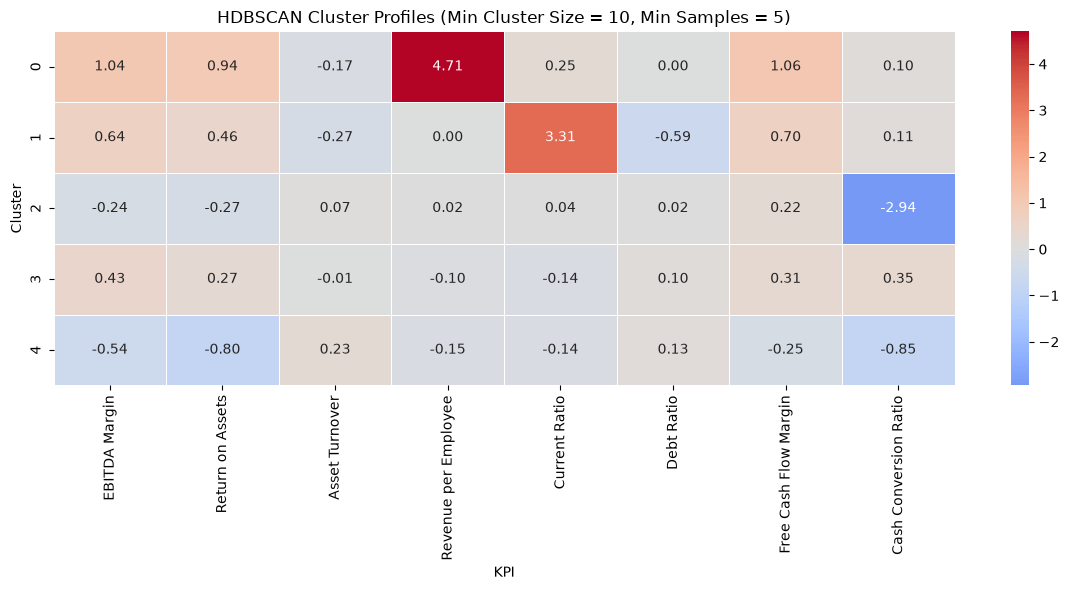

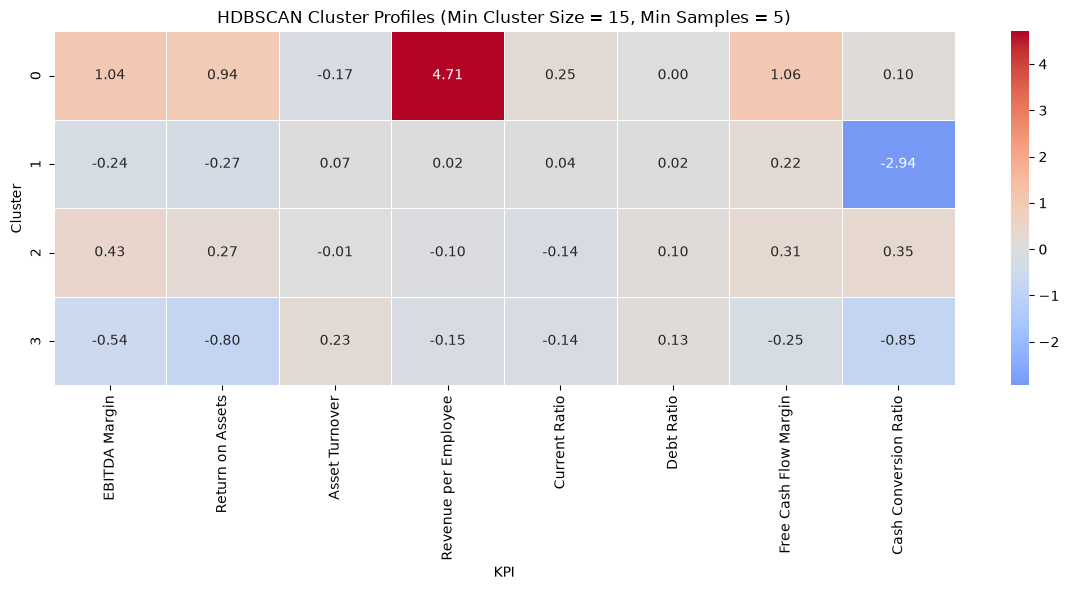

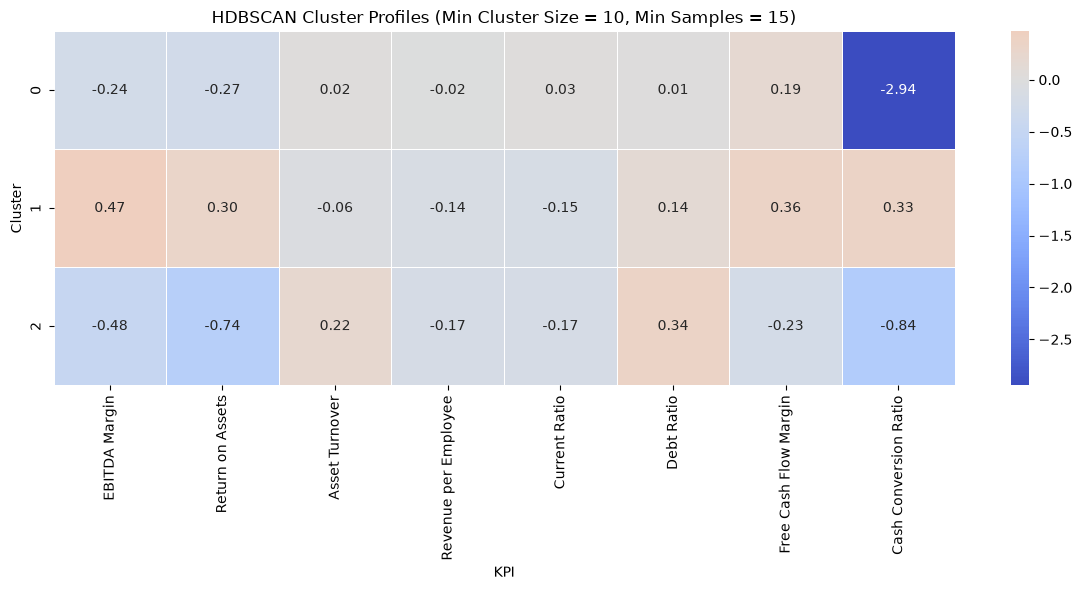

In [112]:
# ==================================================
# Candidate HDBSCAN Cluster Profile Heatmaps
# ==================================================

for configuration, profile in (
    hdbscan_candidate_standardised_profiles.items()
):

    min_cluster_size, min_samples = configuration

    plt.figure(figsize=(12, 6))

    sns.heatmap(
        profile,
        annot=True,
        fmt=".2f",
        center=0,
        cmap="coolwarm",
        linewidths=0.5,
    )

    plt.title(
        "HDBSCAN Cluster Profiles "
        f"(Min Cluster Size = {min_cluster_size}, "
        f"Min Samples = {min_samples})"
    )

    plt.xlabel("KPI")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()

HDBSCAN identified highly distinct and interpretable financial archetypes, particularly under the (15, 5) configuration. However, approximately 42% of the eligible peer universe was classified as noise. This suggests that density-based clustering is effective for identifying high-confidence natural peer groups, but is less suitable as the sole clustering engine for a benchmarking system requiring broad company coverage.

In [113]:
# !pip install tensorflow # we need to change the environment here as Python 3.14 is not compatible with TF

## **9.5 Autoencoder-Based Clustering**

### 9.5.1 Experimental Design

The autoencoder experiment evaluates whether non-linear neural representation learning can produce a more useful company feature space for financial peer clustering than linear PCA.

To ensure a controlled comparison, the autoencoder receives the same eight balanced, preprocessed KPI features used in the traditional clustering experiments. The learned latent representation is then clustered using K-Means and compared with the existing PCA + K-Means baseline.

The experiment therefore isolates the effect of the representation-learning method:

- Traditional baseline: Preprocessed KPIs → PCA → K-Means
- Neural approach: Preprocessed KPIs → Autoencoder → K-Means

This isolates the effect of the representation-learning method on downstream clustering quality.

In [114]:
# ==================================================
# Autoencoder Imports
# ==================================================

import random

import tensorflow as tf

from tensorflow.keras import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Input

In [115]:
# ==================================================
# Reproducibility
# ==================================================

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


In [116]:
# ==================================================
# Autoencoder Experiment Input
# ==================================================

X_autoencoder = X_balanced_scaled.copy()

print(f"Autoencoder input shape: {X_autoencoder.shape}")

Autoencoder input shape: (588, 8)


### 9.5.2 Define the experiment input

In [117]:
# ==================================================
# Validate Autoencoder Input
# ==================================================

print(f"Missing values: {np.isnan(X_autoencoder).sum()}")
print(f"Infinite values: {np.isinf(X_autoencoder).sum()}")

print(f"Minimum value: {X_autoencoder.min():.3f}")
print(f"Maximum value: {X_autoencoder.max():.3f}")

Missing values: 0
Infinite values: 0
Minimum value: -3.618
Maximum value: 4.706


### 9.5.3 Train / validation split

In [118]:
from sklearn.model_selection import train_test_split

X_ae_train, X_ae_validation = train_test_split(
    X_autoencoder,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

print(f"Training observations: {len(X_ae_train):,}")
print(f"Validation observations: {len(X_ae_validation):,}")

Training observations: 470
Validation observations: 118


### 9.5.4 Define the baseline architecture

In [119]:
# ==================================================
# Baseline Autoencoder Configuration
# ==================================================

INPUT_DIM = X_autoencoder.shape[1]
LATENT_DIM = 3

print(f"Input dimensions: {INPUT_DIM}")
print(f"Latent dimensions: {LATENT_DIM}")

Input dimensions: 8
Latent dimensions: 3


In [120]:
# ==================================================
# Build Baseline Autoencoder
# ==================================================

input_layer = Input(
    shape=(INPUT_DIM,),
    name="input_layer",
)

# Encoder
encoded = Dense(
    16,
    activation="relu",
    name="encoder_dense_1",
)(input_layer)

encoded = Dense(
    8,
    activation="relu",
    name="encoder_dense_2",
)(encoded)

latent_space = Dense(
    LATENT_DIM,
    activation="linear",
    name="latent_space",
)(encoded)

# Decoder
decoded = Dense(
    8,
    activation="relu",
    name="decoder_dense_1",
)(latent_space)

decoded = Dense(
    16,
    activation="relu",
    name="decoder_dense_2",
)(decoded)

output_layer = Dense(
    INPUT_DIM,
    activation="linear",
    name="reconstruction",
)(decoded)

Create the full autoencoder

In [121]:
autoencoder = Model(
    inputs=input_layer,
    outputs=output_layer,
    name="baseline_autoencoder",
)

Create the encoder

In [122]:
encoder = Model(
    inputs=input_layer,
    outputs=latent_space,
    name="baseline_encoder",
)

Compile

In [123]:
autoencoder.compile(
    optimizer="adam",
    loss="mse",
)

In [124]:
autoencoder.summary()

Model: "baseline_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder_dense_1 (Dense)              │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder_dense_2 (Dense)              │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ latent_space (Dense)                 │ (None, 3)                   │              27 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder_dense_1 (Dense)              │ (None, 8)                   │              32 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder_dense_2 (Dense)              │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reconstruction (Dense)               │ (None, 8)                   │             136 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 619 (2.42 KB)

 Trainable params: 619 (2.42 KB)

 Non-trainable params: 0 (0.00 B)

### 9.5.5 Train the Encoder

In [125]:
# ==================================================
# Early Stopping
# ==================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
)

In [126]:
# ==================================================
# Train Baseline Autoencoder
# ==================================================

history = autoencoder.fit(
    X_ae_train,
    X_ae_train,
    validation_data=(
        X_ae_validation,
        X_ae_validation,
    ),
    epochs=300,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/300


 1/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - loss: 1.1607

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 1.1647 - val_loss: 1.5236


Epoch 2/300


 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.1221

...

 1/15 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 0.1923

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1691 - val_loss: 0.2982


Epoch 300/300


 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1920

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1690 - val_loss: 0.2981


### 9.5.5 Plot training history

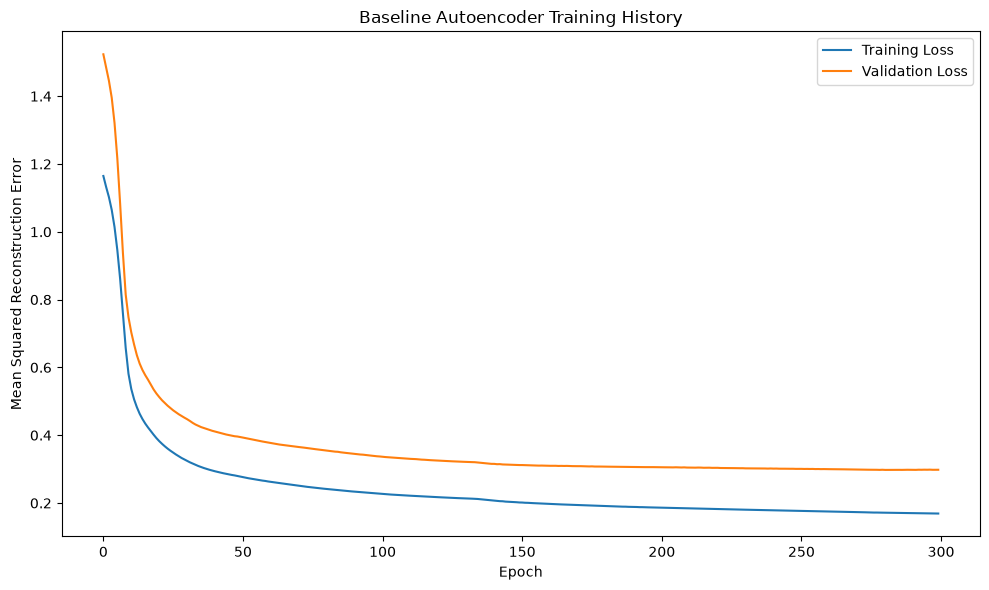

In [127]:
# ==================================================
# Plot Reconstruction Loss
# ==================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss",
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Reconstruction Error")
plt.title("Baseline Autoencoder Training History")
plt.legend()
plt.tight_layout()
plt.show()

### 9.5.6 Evaluate reconstruction performance

In [128]:
# ==================================================
# Reconstruction Performance
# ==================================================

train_reconstruction_loss = autoencoder.evaluate(
    X_ae_train,
    X_ae_train,
    verbose=0,
)

validation_reconstruction_loss = autoencoder.evaluate(
    X_ae_validation,
    X_ae_validation,
    verbose=0,
)

print(
    f"Training reconstruction loss: "
    f"{train_reconstruction_loss:.6f}"
)

print(
    f"Validation reconstruction loss: "
    f"{validation_reconstruction_loss:.6f}"
)

Training reconstruction loss: 0.169467
Validation reconstruction loss: 0.297689


In [129]:
print(
    f"Epochs trained: "
    f"{len(history.history['loss'])}"
)

Epochs trained: 300


### 9.5.8 Generate the learned latent representation

In [130]:
# ==================================================
# Generate Autoencoder Latent Representation
# ==================================================

X_autoencoder_latent = encoder.predict(
    X_autoencoder,
    verbose=0,
)

print(
    f"Latent representation shape: "
    f"{X_autoencoder_latent.shape}"
)

Latent representation shape: (588, 3)


In [131]:
# Create a dataframe
autoencoder_latent_df = pd.DataFrame(
    X_autoencoder_latent,
    columns=[
        f"AE_Latent_{i+1}"
        for i in range(LATENT_DIM)
    ],
    index=peer_universe_df.index,
)

autoencoder_latent_df.head()

,AE_Latent_1,AE_Latent_2,AE_Latent_3
0,10.529150,4.880256,-2.502122
1,5.537302,1.350513,-1.304647
2,5.258399,0.858178,2.838855
3,5.073230,0.422162,1.235074
4,10.441610,1.019347,1.601736


### 9.5.9 Visualize the latent space

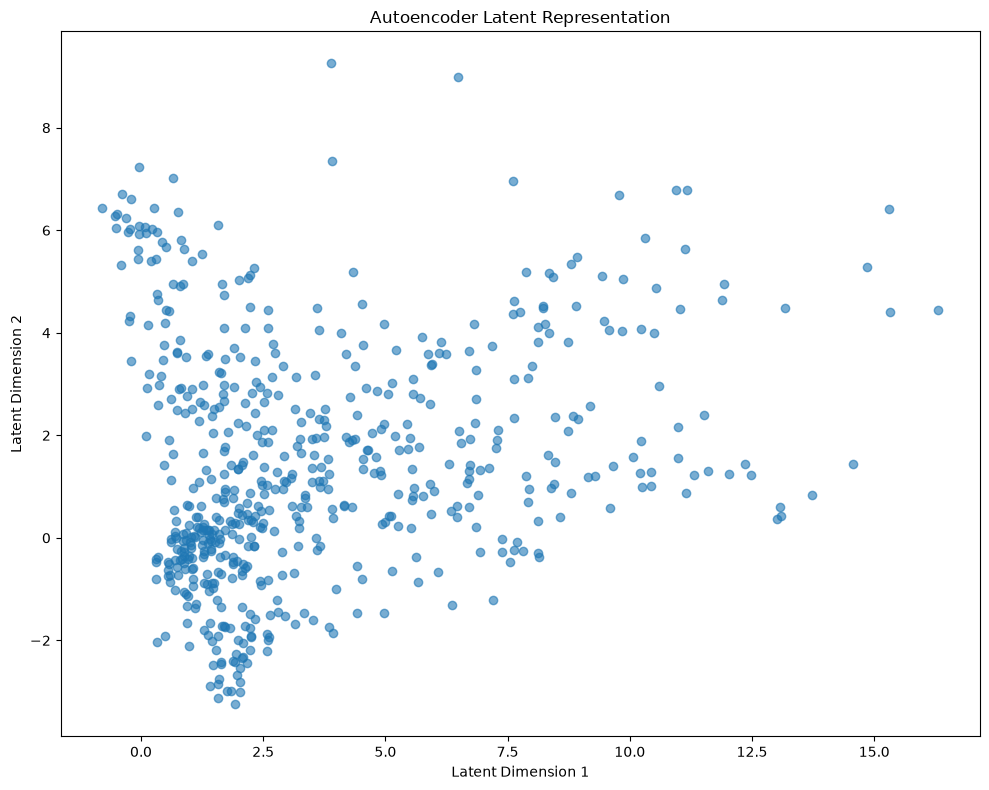

In [132]:
# ==================================================
# Autoencoder Latent Space Projection
# ==================================================

plt.figure(figsize=(10, 8))

plt.scatter(
    autoencoder_latent_df["AE_Latent_1"],
    autoencoder_latent_df["AE_Latent_2"],
    alpha=0.6,
)

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("Autoencoder Latent Representation")
plt.tight_layout()
plt.show()

In [133]:
autoencoder_latent_df.describe().T

,count,mean,std,min,25%,50%,75%,max
AE_Latent_1,588.0,3.614538,3.251768,-0.789001,1.293449,2.316045,5.269177,16.309227
AE_Latent_2,588.0,1.465227,2.316836,-3.250099,-0.168842,1.109193,2.959338,9.255707
AE_Latent_3,588.0,0.987018,2.503874,-4.406617,-0.756720,0.436572,2.778602,8.680838


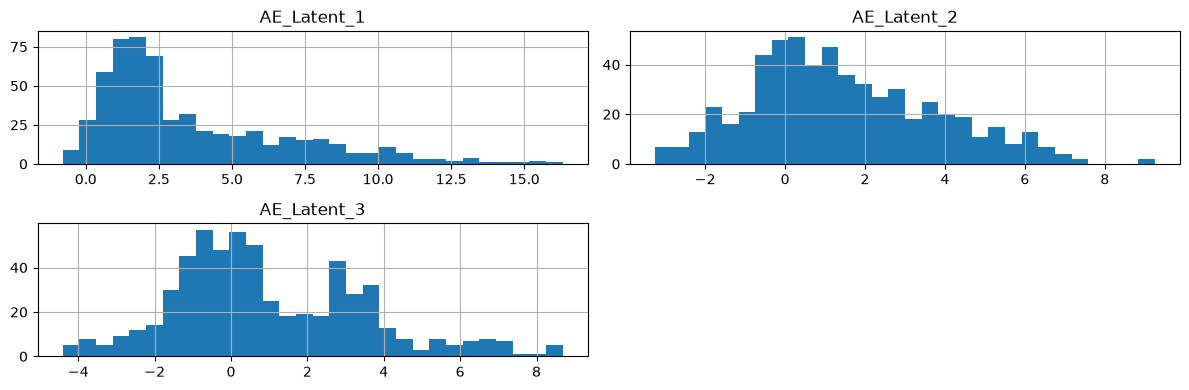

In [134]:
autoencoder_latent_df.hist(
    figsize=(12, 4),
    bins=30,
)

plt.tight_layout()
plt.show()

### 9.5.10 Prepare Latent Representation for Clustering

In [135]:
# ==================================================
# Scale Autoencoder Latent Representation
# ==================================================

from sklearn.preprocessing import StandardScaler

latent_scaler = StandardScaler()

X_autoencoder_cluster = latent_scaler.fit_transform(
    X_autoencoder_latent
)

autoencoder_cluster_features_df = pd.DataFrame(
    X_autoencoder_cluster,
    columns=[
        f"AE_Latent_{i+1}"
        for i in range(LATENT_DIM)
    ],
    index=peer_universe_df.index,
)

autoencoder_cluster_features_df.describe().T

,count,mean,std,min,25%,50%,75%,max
AE_Latent_1,588.0,-1.297516e-08,1.000851,-1.355352,-0.714401,-0.399659,0.509276,3.907259
AE_Latent_2,588.0,-1.621895e-08,1.000851,-2.036977,-0.705903,-0.153803,0.645442,3.365414
AE_Latent_3,588.0,-1.459706e-08,1.000851,-2.155950,-0.697009,-0.220025,0.716134,3.075383


### 9.5.11 Autoencoder + K-Means Evaluation

In [136]:
# ==================================================
# Evaluate Autoencoder + K-Means
# ==================================================

autoencoder_kmeans_results = []

for k in K_RANGE:

    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=50,
    )

    cluster_labels = model.fit_predict(
        X_autoencoder_cluster
    )

    autoencoder_kmeans_results.append({
        "Model": "Autoencoder + K-Means",
        "K": k,
        "Inertia": model.inertia_,
        "Silhouette Score": silhouette_score(
            X_autoencoder_cluster,
            cluster_labels,
        ),
        "Davies-Bouldin Index": davies_bouldin_score(
            X_autoencoder_cluster,
            cluster_labels,
        ),
        "Calinski-Harabasz Score": calinski_harabasz_score(
            X_autoencoder_cluster,
            cluster_labels,
        ),
    })


autoencoder_kmeans_results_df = pd.DataFrame(
    autoencoder_kmeans_results
)

autoencoder_kmeans_results_df

,Model,K,Inertia,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,Autoencoder + K-Means,2,1140.585938,0.393748,1.192034,320.292061
1,Autoencoder + K-Means,3,759.981689,0.437328,1.006960,386.424190
2,Autoencoder + K-Means,4,562.381836,0.462708,0.890033,415.936269
3,Autoencoder + K-Means,5,477.407257,0.392505,1.003876,392.790217
4,Autoencoder + K-Means,6,414.624969,0.377022,0.996815,378.817658
5,Autoencoder + K-Means,7,364.871826,0.383520,0.978683,371.314600
6,Autoencoder + K-Means,8,320.711426,0.345428,0.921442,372.879631
7,Autoencoder + K-Means,9,282.454132,0.350527,0.908657,379.625791
8,Autoencoder + K-Means,10,253.791092,0.357132,0.912924,382.160639


### 9.5.12 Identify Best K by Metric

In [137]:
# ==================================================
# Best K by Evaluation Metric
# ==================================================

best_ae_silhouette_k = (
    autoencoder_kmeans_results_df
    .loc[
        autoencoder_kmeans_results_df[
            "Silhouette Score"
        ].idxmax(),
        "K",
    ]
)

best_ae_davies_bouldin_k = (
    autoencoder_kmeans_results_df
    .loc[
        autoencoder_kmeans_results_df[
            "Davies-Bouldin Index"
        ].idxmin(),
        "K",
    ]
)

best_ae_calinski_harabasz_k = (
    autoencoder_kmeans_results_df
    .loc[
        autoencoder_kmeans_results_df[
            "Calinski-Harabasz Score"
        ].idxmax(),
        "K",
    ]
)

print(
    f"Best K by Silhouette Score: "
    f"{best_ae_silhouette_k}"
)

print(
    f"Best K by Davies-Bouldin Index: "
    f"{best_ae_davies_bouldin_k}"
)

print(
    f"Best K by Calinski-Harabasz Score: "
    f"{best_ae_calinski_harabasz_k}"
)

Best K by Silhouette Score: 4
Best K by Davies-Bouldin Index: 4
Best K by Calinski-Harabasz Score: 4


### 9.5.13 Evaluation Charts

Elbow Method

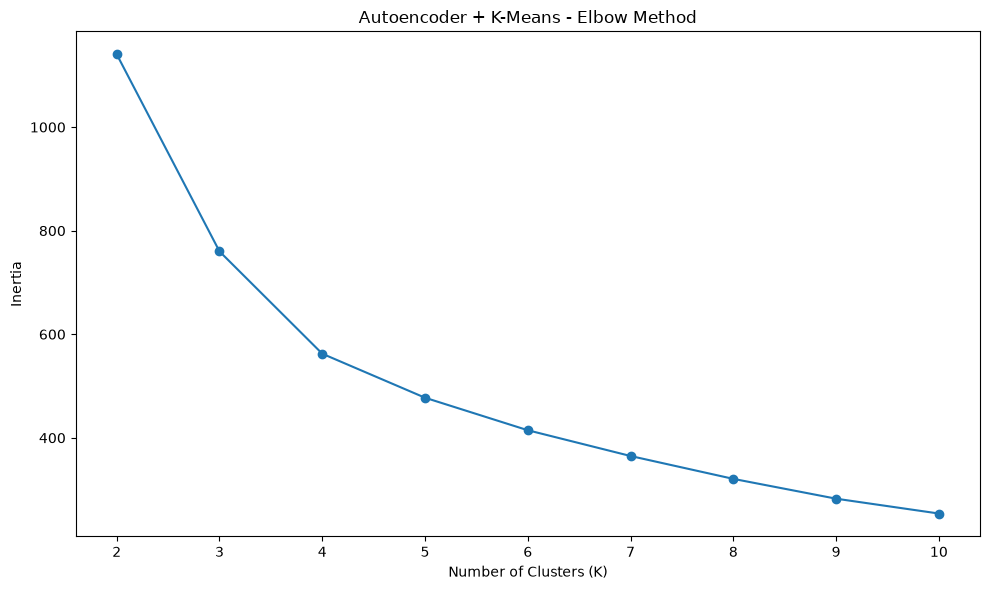

In [138]:
plt.figure(figsize=(10, 6))

plt.plot(
    autoencoder_kmeans_results_df["K"],
    autoencoder_kmeans_results_df["Inertia"],
    marker="o",
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Autoencoder + K-Means - Elbow Method")
plt.xticks(list(K_RANGE))
plt.tight_layout()
plt.show()

Silhouette Score

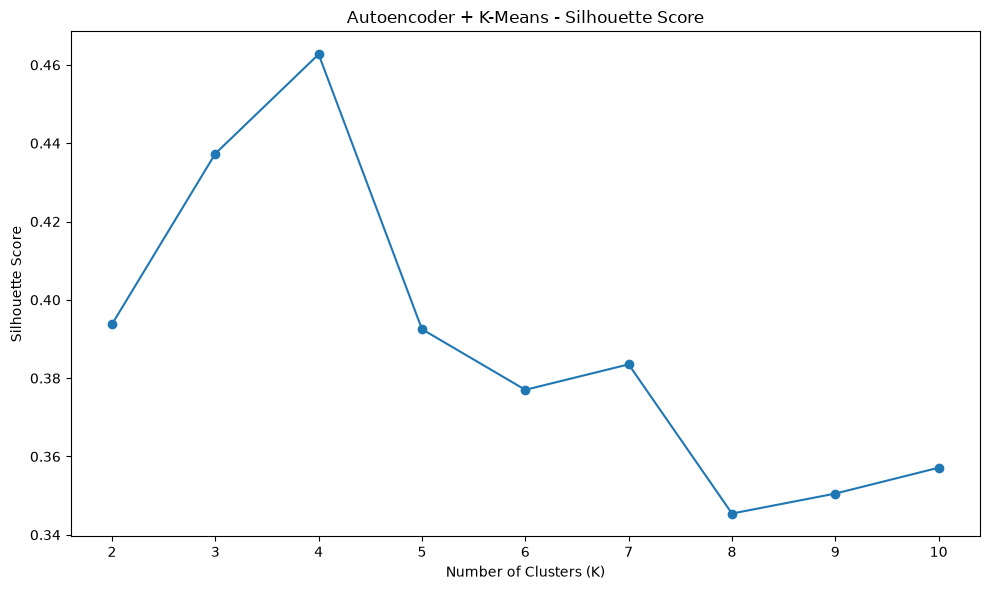

In [139]:
plt.figure(figsize=(10, 6))

plt.plot(
    autoencoder_kmeans_results_df["K"],
    autoencoder_kmeans_results_df["Silhouette Score"],
    marker="o",
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Autoencoder + K-Means - Silhouette Score")
plt.xticks(list(K_RANGE))
plt.tight_layout()
plt.show()

Davies-Bouldin

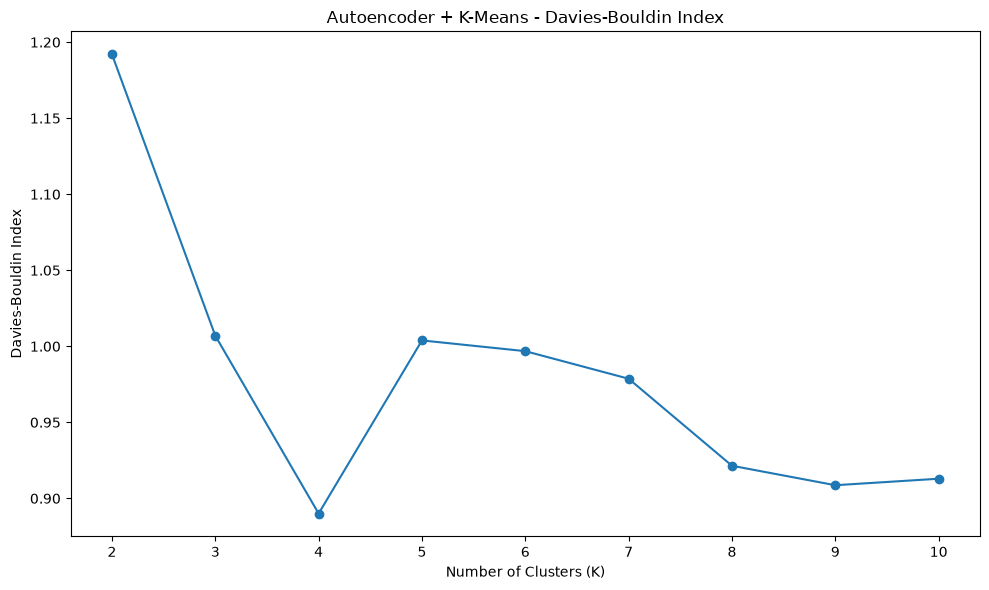

In [140]:
plt.figure(figsize=(10, 6))

plt.plot(
    autoencoder_kmeans_results_df["K"],
    autoencoder_kmeans_results_df["Davies-Bouldin Index"],
    marker="o",
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Davies-Bouldin Index")
plt.title("Autoencoder + K-Means - Davies-Bouldin Index")
plt.xticks(list(K_RANGE))
plt.tight_layout()
plt.show()

Calinski-Harabasz

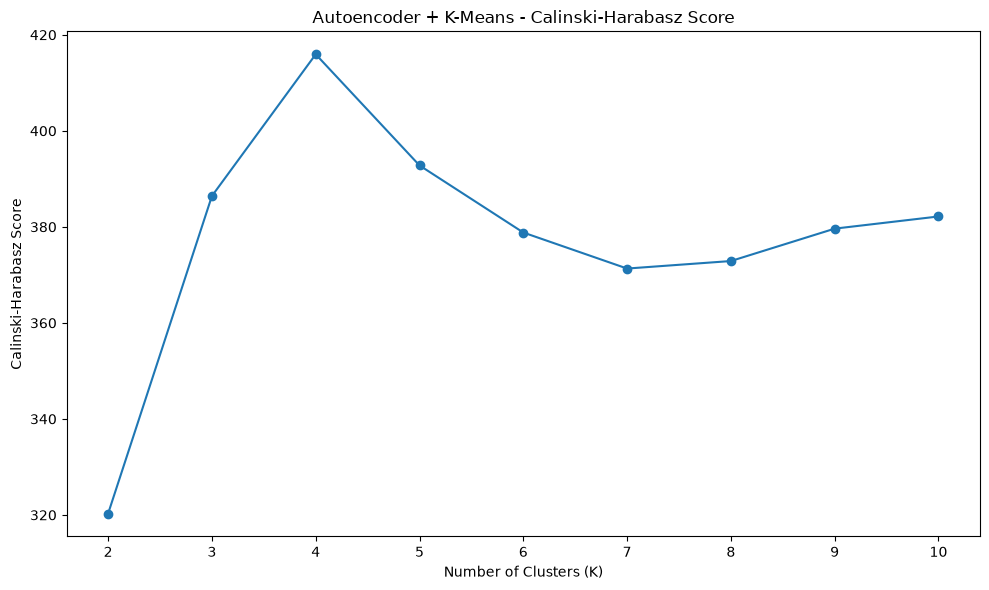

In [141]:
plt.figure(figsize=(10, 6))

plt.plot(
    autoencoder_kmeans_results_df["K"],
    autoencoder_kmeans_results_df["Calinski-Harabasz Score"],
    marker="o",
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Autoencoder + K-Means - Calinski-Harabasz Score")
plt.xticks(list(K_RANGE))
plt.tight_layout()
plt.show()

### 9.5.14 Direct PCA vs Autoencoder comparison

In [142]:
# ==================================================
# Compare PCA and Autoencoder Representations
# ==================================================

representation_comparison_df = pd.concat([
    kmeans_results_df[
        [
            "Model",
            "K",
            "Silhouette Score",
            "Davies-Bouldin Index",
            "Calinski-Harabasz Score",
        ]
    ].assign(
        Representation="PCA"
    ),

    autoencoder_kmeans_results_df[
        [
            "Model",
            "K",
            "Silhouette Score",
            "Davies-Bouldin Index",
            "Calinski-Harabasz Score",
        ]
    ].assign(
        Representation="Autoencoder"
    ),
], ignore_index=True)

representation_comparison_df

,Model,K,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,Representation
0,K-Means,2,0.319061,1.369437,249.046472,PCA
1,K-Means,3,0.348711,1.143806,240.160732,PCA
2,K-Means,4,0.349593,1.057253,277.647527,PCA
3,K-Means,5,0.366551,0.978495,273.430977,PCA
4,K-Means,6,0.362804,1.002467,260.779147,PCA
5,K-Means,7,0.370703,0.993112,257.927914,PCA
6,K-Means,8,0.316147,1.054260,254.259554,PCA
7,K-Means,9,0.320375,1.011666,252.947603,PCA
8,K-Means,10,0.322486,1.017627,245.270329,PCA
9,Autoencoder + K-Means,2,0.393748,1.192034,320.292061,Autoencoder


In [143]:
# ==================================================
# Best Result per Representation
# ==================================================

representation_best_results = pd.DataFrame([
    {
        "Representation": "PCA",
        "Best Silhouette": (
            kmeans_results_df["Silhouette Score"].max()
        ),
        "Best Davies-Bouldin": (
            kmeans_results_df["Davies-Bouldin Index"].min()
        ),
        "Best Calinski-Harabasz": (
            kmeans_results_df["Calinski-Harabasz Score"].max()
        ),
    },
    {
        "Representation": "Autoencoder",
        "Best Silhouette": (
            autoencoder_kmeans_results_df[
                "Silhouette Score"
            ].max()
        ),
        "Best Davies-Bouldin": (
            autoencoder_kmeans_results_df[
                "Davies-Bouldin Index"
            ].min()
        ),
        "Best Calinski-Harabasz": (
            autoencoder_kmeans_results_df[
                "Calinski-Harabasz Score"
            ].max()
        ),
    },
])

representation_best_results

,Representation,Best Silhouette,Best Davies-Bouldin,Best Calinski-Harabasz
0,PCA,0.370703,0.978495,277.647527
1,Autoencoder,0.462708,0.890033,415.936269


### 9.5.15 Fit the preferred candidate

In [144]:
# ==================================================
# Fit Preferred Autoencoder + K-Means Solution
# ==================================================

AE_SELECTED_K = 4

ae_kmeans_model = KMeans(
    n_clusters=AE_SELECTED_K,
    random_state=RANDOM_STATE,
    n_init=50,
)

ae_cluster_labels = ae_kmeans_model.fit_predict(
    X_autoencoder_cluster
)

print(
    pd.Series(ae_cluster_labels)
    .value_counts()
    .sort_index()
)

0    291
1     63
2    143
3     91
Name: count, dtype: int64


### 9.5.16 Cluster Profile Comparison

In [145]:
# ==================================================
# Autoencoder + K-Means Cluster Sizes
# ==================================================

ae_cluster_size_summary_df = (
    pd.Series(
        ae_cluster_labels,
        name="Cluster"
    )
    .value_counts()
    .sort_index()
    .rename("Company Count")
    .to_frame()
)

ae_cluster_size_summary_df["Cluster Share"] = (
    ae_cluster_size_summary_df["Company Count"]
    / len(ae_cluster_labels)
)

ae_cluster_size_summary_df

,Company Count,Cluster Share
Cluster,,
0,291,0.494898
1,63,0.107143
2,143,0.243197
3,91,0.154762


In [146]:
# ==================================================
# Autoencoder + K-Means Raw KPI Profiles
# ==================================================

ae_profile_df = peer_universe_df.copy()

ae_profile_df["Cluster"] = ae_cluster_labels

ae_cluster_profiles = (
    ae_profile_df
    .groupby("Cluster")[balanced_clustering_kpis]
    .median()
)

ae_cluster_profiles

,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.174113,0.047243,0.611028,3.408975e+05,1.702865,0.196568,0.139559,1.808724
1,-0.566323,-0.255542,0.436392,3.031116e+05,2.370274,0.100236,-0.508603,0.430364
2,0.001528,-0.045011,0.685284,3.713189e+05,1.530721,0.222104,0.049928,-1.544686
3,0.165801,0.066361,0.665314,1.387896e+06,3.047894,0.060924,0.145270,1.246133


In [147]:
ae_cluster_profiles_with_counts = (
    ae_cluster_profiles.copy()
)

ae_cluster_profiles_with_counts.insert(
    0,
    "Company Count",
    ae_cluster_size_summary_df["Company Count"],
)

ae_cluster_profiles_with_counts

,Company Count,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,,
0,291,0.174113,0.047243,0.611028,3.408975e+05,1.702865,0.196568,0.139559,1.808724
1,63,-0.566323,-0.255542,0.436392,3.031116e+05,2.370274,0.100236,-0.508603,0.430364
2,143,0.001528,-0.045011,0.685284,3.713189e+05,1.530721,0.222104,0.049928,-1.544686
3,91,0.165801,0.066361,0.665314,1.387896e+06,3.047894,0.060924,0.145270,1.246133


In [148]:
# ==================================================
# Standardised Autoencoder + K-Means Profiles
# ==================================================

ae_standardised_profile_df = (
    balanced_model_features_df.copy()
)

ae_standardised_profile_df["Cluster"] = (
    ae_cluster_labels
)

ae_standardised_profiles = (
    ae_standardised_profile_df
    .groupby("Cluster")[balanced_clustering_kpis]
    .median()
)

ae_standardised_profiles

,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.351164,0.232276,-0.000252,-0.072813,-0.055962,0.016126,0.253376,0.323914
1,-2.907539,-2.202553,-0.335995,-0.143357,0.353966,-0.267542,-2.968978,-0.335949
2,-0.405431,-0.507190,0.141319,-0.005166,-0.161695,0.130627,-0.191928,-1.284399
3,0.318400,0.389668,0.103021,2.855241,0.770166,-0.405849,0.282122,0.055279


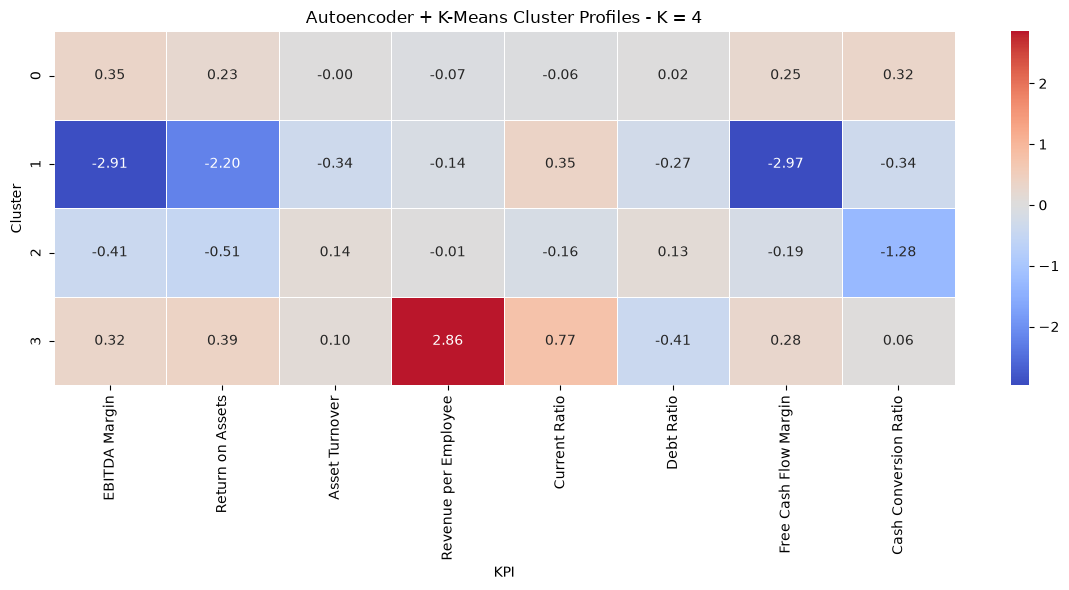

In [149]:
# ==================================================
# Autoencoder + K-Means Cluster Profile Heatmap
# ==================================================

plt.figure(figsize=(12, 6))

sns.heatmap(
    ae_standardised_profiles,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm",
    linewidths=0.5,
)

plt.title(
    "Autoencoder + K-Means Cluster Profiles - K = 4"
)

plt.xlabel("KPI")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

**For Technology sector, >25M revenue band**

The autoencoder learned a nonlinear three-dimensional representation that produced more clearly separated K-Means clusters than the four-component PCA representation. The resulting four-cluster solution also retained strong business interpretability and adequate cluster sizes for financial benchmarking.

### 9.5.17 Autoencoder Stability Analysis

Neural networks are stochastic models whose learned representations may vary because of random weight initialization and the optimisation process. To determine whether the strong clustering performance of the baseline autoencoder is reproducible, the same architecture is retrained across multiple random seeds.

All other experimental conditions are held constant, including the company cohort, preprocessing pipeline, train-validation split, latent dimensionality, and K-Means cluster count.

Stability is evaluated using:

- Validation reconstruction loss
- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Score
- Cluster size balance
- Agreement between cluster assignments across runs

#### 9.5.17.1 Define the stability experiment

In [150]:
# ==================================================
# Autoencoder Stability Configuration
# ==================================================

AUTOENCODER_SEEDS = [
    42,
    123,
    456,
    789,
    2026,
]

AE_STABILITY_K = 4

print(f"Number of stability runs: {len(AUTOENCODER_SEEDS)}")
print(f"Fixed cluster count: K = {AE_STABILITY_K}")

Number of stability runs: 5
Fixed cluster count: K = 4


#### 9.5.17.2 Create a reusable autoencoder builder

In [151]:
# ==================================================
# Build Baseline Autoencoder
# ==================================================

def build_baseline_autoencoder(
    input_dim: int,
    latent_dim: int,
) -> tuple[Model, Model]:
    """
    Builds the baseline autoencoder and corresponding encoder.

    Architecture:
    input -> 16 -> 8 -> latent -> 8 -> 16 -> reconstruction
    """

    input_layer = Input(
        shape=(input_dim,),
        name="input_layer",
    )

    # Encoder
    encoded = Dense(
        16,
        activation="relu",
        name="encoder_dense_1",
    )(input_layer)

    encoded = Dense(
        8,
        activation="relu",
        name="encoder_dense_2",
    )(encoded)

    latent_space = Dense(
        latent_dim,
        activation="linear",
        name="latent_space",
    )(encoded)

    # Decoder
    decoded = Dense(
        8,
        activation="relu",
        name="decoder_dense_1",
    )(latent_space)

    decoded = Dense(
        16,
        activation="relu",
        name="decoder_dense_2",
    )(decoded)

    output_layer = Dense(
        input_dim,
        activation="linear",
        name="reconstruction",
    )(decoded)

    autoencoder = Model(
        inputs=input_layer,
        outputs=output_layer,
        name="baseline_autoencoder",
    )

    encoder = Model(
        inputs=input_layer,
        outputs=latent_space,
        name="baseline_encoder",
    )

    autoencoder.compile(
        optimizer="adam",
        loss="mse",
    )

    return autoencoder, encoder

#### 9.5.17.3 Run the multi-seed experiment

In [152]:
# ==================================================
# Run Multi-Seed Stability Experiment
# ==================================================

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
)

ae_stability_records = []
ae_stability_labels = {}

for seed in AUTOENCODER_SEEDS:

    print(f"\nRunning seed {seed}...")

    # --------------------------------------------------
    # Reset TensorFlow state
    # --------------------------------------------------

    tf.keras.backend.clear_session()

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # --------------------------------------------------
    # Build fresh model
    # --------------------------------------------------

    stability_autoencoder, stability_encoder = (
        build_baseline_autoencoder(
            input_dim=INPUT_DIM,
            latent_dim=LATENT_DIM,
        )
    )

    # --------------------------------------------------
    # Early stopping
    # --------------------------------------------------

    stability_early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=20,
        min_delta=1e-4,
        restore_best_weights=True,
    )

    # --------------------------------------------------
    # Train model
    # --------------------------------------------------

    stability_history = stability_autoencoder.fit(
        X_ae_train,
        X_ae_train,
        validation_data=(
            X_ae_validation,
            X_ae_validation,
        ),
        epochs=300,
        batch_size=32,
        callbacks=[stability_early_stopping],
        verbose=0,
    )

    # --------------------------------------------------
    # Reconstruction performance
    # --------------------------------------------------

    validation_loss = stability_autoencoder.evaluate(
        X_ae_validation,
        X_ae_validation,
        verbose=0,
    )

    # --------------------------------------------------
    # Generate latent representation
    # --------------------------------------------------

    latent_representation = stability_encoder.predict(
        X_autoencoder,
        verbose=0,
    )

    # Scale latent dimensions before K-Means
    stability_latent_scaler = StandardScaler()

    scaled_latent_representation = (
        stability_latent_scaler.fit_transform(
            latent_representation
        )
    )

    # --------------------------------------------------
    # Fit K-Means
    # --------------------------------------------------

    stability_kmeans = KMeans(
        n_clusters=AE_STABILITY_K,
        random_state=RANDOM_STATE,
        n_init=50,
    )

    cluster_labels = stability_kmeans.fit_predict(
        scaled_latent_representation
    )

    # Store labels for later agreement analysis
    ae_stability_labels[seed] = cluster_labels

    # --------------------------------------------------
    # Cluster balance
    # --------------------------------------------------

    cluster_sizes = (
        pd.Series(cluster_labels)
        .value_counts()
    )

    # --------------------------------------------------
    # Store results
    # --------------------------------------------------

    ae_stability_records.append({
        "Seed": seed,
        "Epochs Trained": len(
            stability_history.history["loss"]
        ),
        "Validation Reconstruction Loss": validation_loss,
        "Silhouette Score": silhouette_score(
            scaled_latent_representation,
            cluster_labels,
        ),
        "Davies-Bouldin Index": davies_bouldin_score(
            scaled_latent_representation,
            cluster_labels,
        ),
        "Calinski-Harabasz Score": calinski_harabasz_score(
            scaled_latent_representation,
            cluster_labels,
        ),
        "Smallest Cluster": cluster_sizes.min(),
        "Largest Cluster": cluster_sizes.max(),
    })


ae_stability_results_df = pd.DataFrame(
    ae_stability_records
)

ae_stability_results_df


Running seed 42...



Running seed 123...



Running seed 456...



Running seed 789...



Running seed 2026...


,Seed,Epochs Trained,Validation Reconstruction Loss,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,Smallest Cluster,Largest Cluster
0,42,299,0.297786,0.462522,0.886680,415.230827,62,291
1,123,300,0.303882,0.341357,0.950169,419.687620,70,227
2,456,300,0.354099,0.456503,0.792607,490.349123,52,276
3,789,300,0.291312,0.477890,0.872136,631.992670,56,302
4,2026,177,0.396164,0.358984,0.931484,345.543326,52,263


#### 9.5.17.4 Summarize metric stability

In [153]:
# ==================================================
# Stability Metric Summary
# ==================================================

ae_stability_metric_summary = (
    ae_stability_results_df[
        [
            "Validation Reconstruction Loss",
            "Silhouette Score",
            "Davies-Bouldin Index",
            "Calinski-Harabasz Score",
            "Smallest Cluster",
            "Largest Cluster",
        ]
    ]
    .agg([
        "mean",
        "std",
        "min",
        "max",
    ])
    .T
)

ae_stability_metric_summary

,mean,std,min,max
Validation Reconstruction Loss,0.328649,0.045183,0.291312,0.396164
Silhouette Score,0.419451,0.064027,0.341357,0.477890
Davies-Bouldin Index,0.886615,0.061440,0.792607,0.950169
Calinski-Harabasz Score,460.560713,108.663095,345.543326,631.992670
Smallest Cluster,58.400000,7.668116,52.000000,70.000000
Largest Cluster,271.800000,29.080922,227.000000,302.000000


#### 9.5.17.5 Visualize metric variability

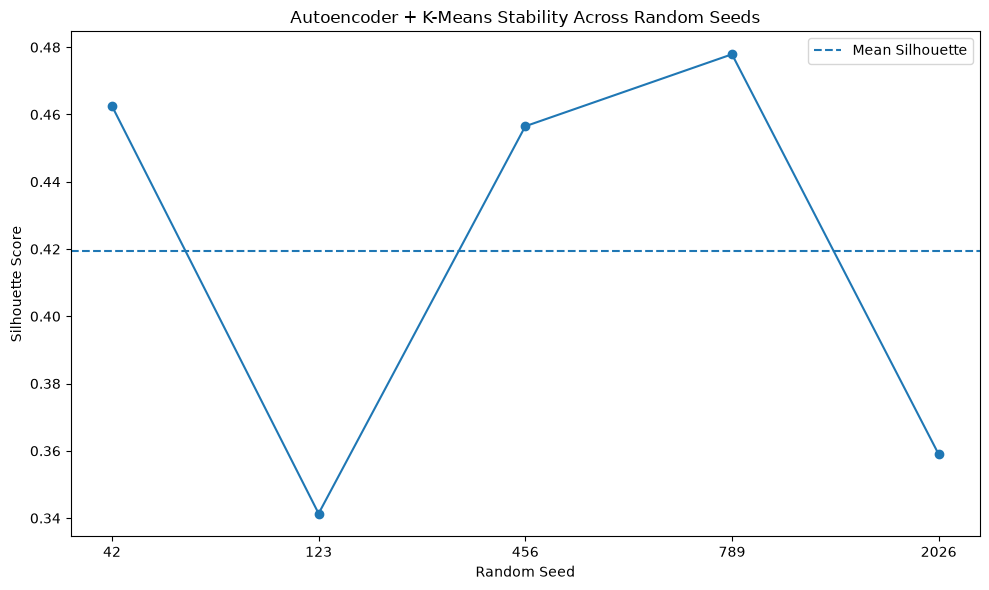

In [154]:
# ==================================================
# Autoencoder Stability - Silhouette Score
# ==================================================

plt.figure(figsize=(10, 6))

plt.plot(
    ae_stability_results_df["Seed"].astype(str),
    ae_stability_results_df["Silhouette Score"],
    marker="o",
)

plt.axhline(
    ae_stability_results_df["Silhouette Score"].mean(),
    linestyle="--",
    label="Mean Silhouette",
)

plt.xlabel("Random Seed")
plt.ylabel("Silhouette Score")
plt.title("Autoencoder + K-Means Stability Across Random Seeds")
plt.legend()
plt.tight_layout()
plt.show()

In [155]:
# ==================================================
# Pairwise Cluster Assignment Stability
# ==================================================

ae_pairwise_stability_records = []

for i, seed_a in enumerate(AUTOENCODER_SEEDS):

    for seed_b in AUTOENCODER_SEEDS[i + 1:]:

        labels_a = ae_stability_labels[seed_a]
        labels_b = ae_stability_labels[seed_b]

        ae_pairwise_stability_records.append({
            "Seed A": seed_a,
            "Seed B": seed_b,
            "Adjusted Rand Index": adjusted_rand_score(
                labels_a,
                labels_b,
            ),
            "Normalized Mutual Information": (
                normalized_mutual_info_score(
                    labels_a,
                    labels_b,
                )
            ),
        })


ae_pairwise_stability_df = pd.DataFrame(
    ae_pairwise_stability_records
)

ae_pairwise_stability_df

,Seed A,Seed B,Adjusted Rand Index,Normalized Mutual Information
0,42,123,0.293296,0.389068
1,42,456,0.516599,0.519197
2,42,789,0.596248,0.509345
3,42,2026,0.232534,0.325948
4,123,456,0.213999,0.348477
5,123,789,0.277042,0.343929
6,123,2026,0.395546,0.478167
7,456,789,0.449958,0.435844
8,456,2026,0.144595,0.244694
9,789,2026,0.232521,0.325047


In [156]:
# ==================================================
# Cluster Assignment Stability Summary
# ==================================================

ae_assignment_stability_summary = (
    ae_pairwise_stability_df[
        [
            "Adjusted Rand Index",
            "Normalized Mutual Information",
        ]
    ]
    .agg([
        "mean",
        "std",
        "min",
        "max",
    ])
    .T
)

ae_assignment_stability_summary

,mean,std,min,max
Adjusted Rand Index,0.335234,0.147235,0.144595,0.596248
Normalized Mutual Information,0.391972,0.090710,0.244694,0.519197


**For Technology Sector, >25M revenue**

The autoencoder can produce substantially better-separated clusters than PCA, but the learned representation is sensitive to neural-network initialization, causing unstable peer assignments. The autoencoder is the highest-performing full-coverage method, but not yet the most reliable method. across runs

### 9.5.18 Seed-Specific Optimal K Analysis

The previous stability analysis fixed the number of clusters at K=4 for every autoencoder run. However, different neural-network initialisations may produce latent spaces with different preferred cluster structures.

To distinguish cluster-boundary instability from deeper representation instability, each autoencoder seed is retrained and its latent representation is independently evaluated across K=2 to K=10.

The analysis records the preferred K according to Silhouette Score, Davies-Bouldin Index and Calinski-Harabasz Score for each seed.

-------------------------------------------------------------------------------------------------------

Here we use a new dictionary so we do not disturb the previous experiment objects:

#### 9.5.18.1 Evaluate K=2 to K=10 for every seed

In [157]:
# ==================================================
# Generate Latent Representations Across Seeds
# ==================================================

ae_seed_latent_representations = {}
ae_seed_training_records = []

for seed in AUTOENCODER_SEEDS:

    print(f"\nTraining autoencoder for seed {seed}...")

    # Reset TensorFlow state
    tf.keras.backend.clear_session()

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # Build fresh model
    seed_autoencoder, seed_encoder = (
        build_baseline_autoencoder(
            input_dim=INPUT_DIM,
            latent_dim=LATENT_DIM,
        )
    )

    # Early stopping
    seed_early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=20,
        min_delta=1e-4,
        restore_best_weights=True,
    )

    # Train
    seed_history = seed_autoencoder.fit(
        X_ae_train,
        X_ae_train,
        validation_data=(
            X_ae_validation,
            X_ae_validation,
        ),
        epochs=300,
        batch_size=32,
        callbacks=[seed_early_stopping],
        verbose=0,
    )

    # Validation reconstruction loss
    validation_loss = seed_autoencoder.evaluate(
        X_ae_validation,
        X_ae_validation,
        verbose=0,
    )

    # Generate latent representation
    latent_representation = seed_encoder.predict(
        X_autoencoder,
        verbose=0,
    )

    # Scale latent dimensions
    seed_latent_scaler = StandardScaler()

    scaled_latent_representation = (
        seed_latent_scaler.fit_transform(
            latent_representation
        )
    )

    # Store scaled latent space
    ae_seed_latent_representations[seed] = (
        scaled_latent_representation
    )

    ae_seed_training_records.append({
        "Seed": seed,
        "Epochs Trained": len(
            seed_history.history["loss"]
        ),
        "Validation Reconstruction Loss": validation_loss,
    })


ae_seed_training_summary_df = pd.DataFrame(
    ae_seed_training_records
)

ae_seed_training_summary_df


Training autoencoder for seed 42...



Training autoencoder for seed 123...



Training autoencoder for seed 456...



Training autoencoder for seed 789...



Training autoencoder for seed 2026...


,Seed,Epochs Trained,Validation Reconstruction Loss
0,42,299,0.297786
1,123,300,0.303882
2,456,300,0.354099
3,789,300,0.291312
4,2026,177,0.396164


#### 9.5.18.2 Identify the best K for each seed

In [158]:
# ==================================================
# Evaluate K Across Autoencoder Seeds
# ==================================================

ae_seed_k_results = []

for seed, latent_features in (
    ae_seed_latent_representations.items()
):

    for k in K_RANGE:

        model = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init=50,
        )

        labels = model.fit_predict(
            latent_features
        )

        ae_seed_k_results.append({
            "Seed": seed,
            "K": k,
            "Silhouette Score": silhouette_score(
                latent_features,
                labels,
            ),
            "Davies-Bouldin Index": davies_bouldin_score(
                latent_features,
                labels,
            ),
            "Calinski-Harabasz Score": calinski_harabasz_score(
                latent_features,
                labels,
            ),
        })


ae_seed_k_results_df = pd.DataFrame(
    ae_seed_k_results
)

ae_seed_k_results_df

,Seed,K,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,42,2,0.393157,1.193424,319.508570
1,42,3,0.436731,1.007788,385.667904
2,42,4,0.462522,0.886680,415.230827
3,42,5,0.389835,1.005547,392.389875
4,42,6,0.377981,0.988330,378.107668
5,42,7,0.382725,0.980038,370.102238
6,42,8,0.345675,0.920445,372.796225
7,42,9,0.353677,0.902151,379.526969
8,42,10,0.358125,0.905234,380.252885
9,123,2,0.377665,1.131993,370.076837


In [159]:
# ==================================================
# Best K by Metric for Each Seed
# ==================================================

ae_seed_best_k_records = []

for seed in AUTOENCODER_SEEDS:

    seed_results = ae_seed_k_results_df[
        ae_seed_k_results_df["Seed"] == seed
    ]

    best_silhouette_row = seed_results.loc[
        seed_results["Silhouette Score"].idxmax()
    ]

    best_dbi_row = seed_results.loc[
        seed_results["Davies-Bouldin Index"].idxmin()
    ]

    best_ch_row = seed_results.loc[
        seed_results["Calinski-Harabasz Score"].idxmax()
    ]

    ae_seed_best_k_records.append({
        "Seed": seed,
        "Best Silhouette K": int(
            best_silhouette_row["K"]
        ),
        "Best Silhouette Score": (
            best_silhouette_row["Silhouette Score"]
        ),
        "Best DBI K": int(
            best_dbi_row["K"]
        ),
        "Best Davies-Bouldin Index": (
            best_dbi_row["Davies-Bouldin Index"]
        ),
        "Best CH K": int(
            best_ch_row["K"]
        ),
        "Best Calinski-Harabasz Score": (
            best_ch_row["Calinski-Harabasz Score"]
        ),
    })


ae_seed_best_k_df = pd.DataFrame(
    ae_seed_best_k_records
)

ae_seed_best_k_df

,Seed,Best Silhouette K,Best Silhouette Score,Best DBI K,Best Davies-Bouldin Index,Best CH K,Best Calinski-Harabasz Score
0,42,4,0.462522,4,0.886680,4,415.230827
1,123,3,0.437552,7,0.855737,7,437.832173
2,456,2,0.528560,6,0.763221,4,490.349123
3,789,2,0.522343,2,0.811194,3,675.943874
4,2026,2,0.420647,5,0.898848,6,356.372734


In [160]:
# ==================================================
# Preferred K Frequency
# ==================================================

ae_preferred_k_frequency = pd.DataFrame({
    "Silhouette": (
        ae_seed_best_k_df[
            "Best Silhouette K"
        ].value_counts()
    ),
    "Davies-Bouldin": (
        ae_seed_best_k_df[
            "Best DBI K"
        ].value_counts()
    ),
    "Calinski-Harabasz": (
        ae_seed_best_k_df[
            "Best CH K"
        ].value_counts()
    ),
}).fillna(0).astype(int)

ae_preferred_k_frequency.index.name = "K"

ae_preferred_k_frequency.sort_index()

,Silhouette,Davies-Bouldin,Calinski-Harabasz
K,,,
2,3,1,0
3,1,0,1
4,1,1,2
5,0,1,0
6,0,1,1
7,0,1,1


#### 9.5.18.4 Silhouette Score

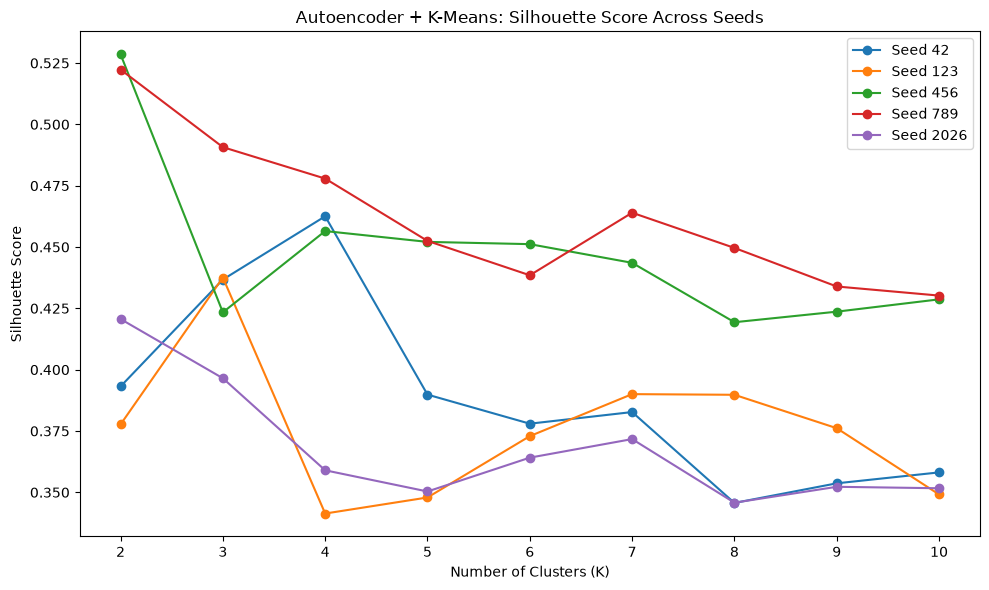

In [161]:
# ==================================================
# Silhouette Score Across Seeds and K
# ==================================================

plt.figure(figsize=(10, 6))

for seed in AUTOENCODER_SEEDS:

    subset = (
        ae_seed_k_results_df[
            ae_seed_k_results_df["Seed"] == seed
        ]
        .sort_values("K")
    )

    plt.plot(
        subset["K"],
        subset["Silhouette Score"],
        marker="o",
        label=f"Seed {seed}",
    )

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title(
    "Autoencoder + K-Means: "
    "Silhouette Score Across Seeds"
)
plt.xticks(list(K_RANGE))
plt.legend()
plt.tight_layout()
plt.show()

#### 9.5.18.5 Davies-Bouldin Index

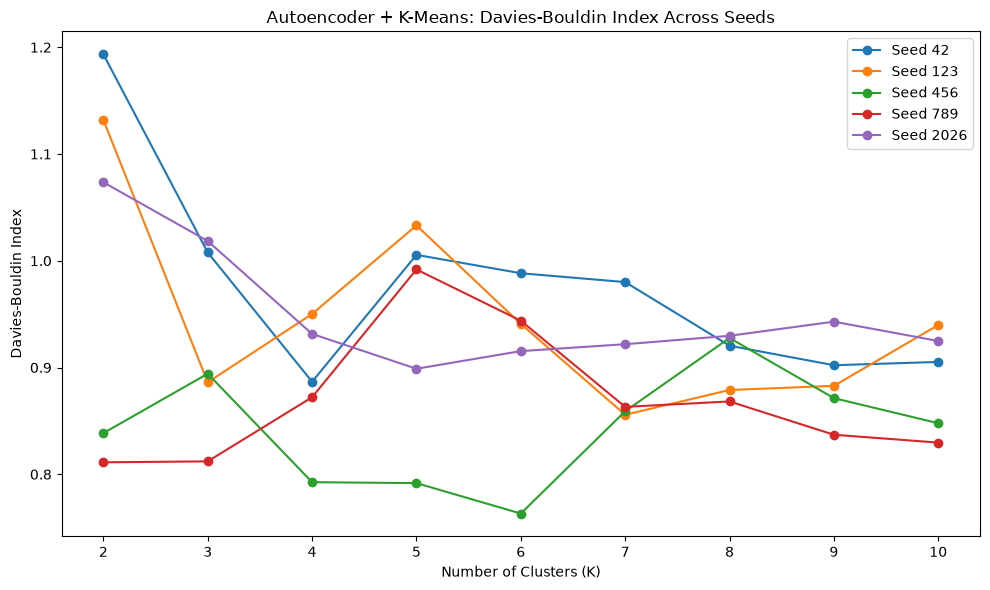

In [162]:
plt.figure(figsize=(10, 6))

for seed in AUTOENCODER_SEEDS:

    subset = (
        ae_seed_k_results_df[
            ae_seed_k_results_df["Seed"] == seed
        ]
        .sort_values("K")
    )

    plt.plot(
        subset["K"],
        subset["Davies-Bouldin Index"],
        marker="o",
        label=f"Seed {seed}",
    )

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Davies-Bouldin Index")
plt.title(
    "Autoencoder + K-Means: "
    "Davies-Bouldin Index Across Seeds"
)
plt.xticks(list(K_RANGE))
plt.legend()
plt.tight_layout()
plt.show()

#### 9.5.18.6 Calinski-Harabasz Score

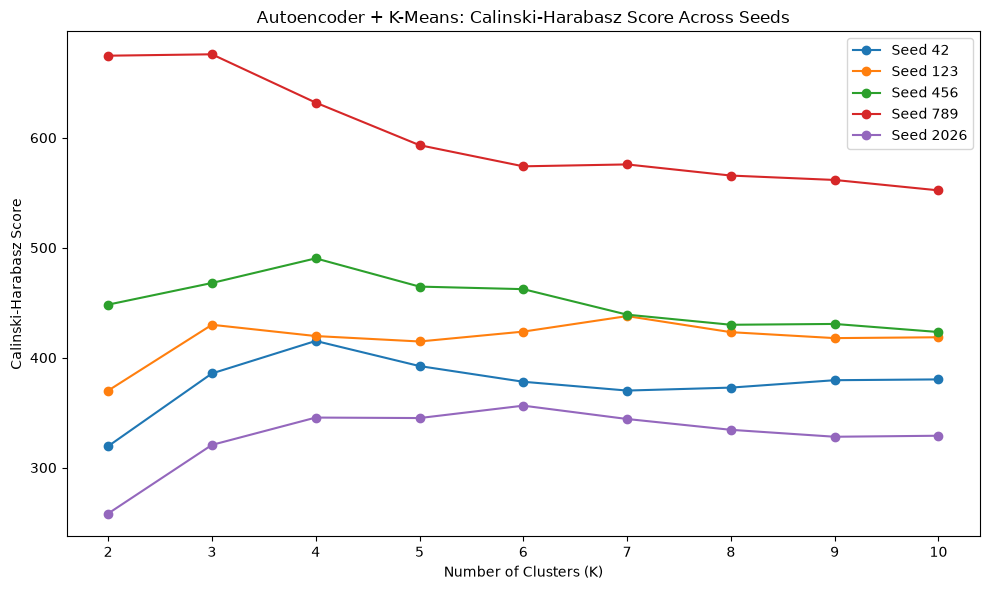

In [163]:
plt.figure(figsize=(10, 6))

for seed in AUTOENCODER_SEEDS:

    subset = (
        ae_seed_k_results_df[
            ae_seed_k_results_df["Seed"] == seed
        ]
        .sort_values("K")
    )

    plt.plot(
        subset["K"],
        subset["Calinski-Harabasz Score"],
        marker="o",
        label=f"Seed {seed}",
    )

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Calinski-Harabasz Score")
plt.title(
    "Autoencoder + K-Means: "
    "Calinski-Harabasz Score Across Seeds"
)
plt.xticks(list(K_RANGE))
plt.legend()
plt.tight_layout()
plt.show()

In [164]:
# ==================================================
# Best Seed-Specific Silhouette Results
# ==================================================

ae_seed_optimal_silhouette_results = (
    ae_seed_best_k_df[
        [
            "Seed",
            "Best Silhouette K",
            "Best Silhouette Score",
        ]
    ]
    .sort_values(
        "Best Silhouette Score",
        ascending=False,
    )
)

ae_seed_optimal_silhouette_results

,Seed,Best Silhouette K,Best Silhouette Score
2,456,2,0.528560
3,789,2,0.522343
0,42,4,0.462522
1,123,3,0.437552
4,2026,2,0.420647


#### 9.5.18.7 Baseline Autoencoder Stability Conclusion

The baseline autoencoder demonstrated strong potential but insufficient stability for immediate use as the primary benchmarking model.

In several runs, the learned neural representation substantially improved K-Means cluster separation relative to the PCA baseline. However, results varied considerably across random initialisations. The preferred number of clusters ranged from K=2 to K=4 according to the Silhouette Score, while other evaluation metrics showed even greater disagreement.

Pairwise assignment stability was also limited, with a mean Adjusted Rand Index of approximately 0.34 and mean Normalized Mutual Information of approximately 0.39. This indicates that different training runs frequently grouped the same companies differently.

The experiment therefore suggests that nonlinear neural representation learning can reveal highly clusterable financial structures, but the current autoencoder architecture is sensitive to random initialisation. The next stage evaluates a small set of controlled architecture variants to determine whether simpler networks or less aggressive compression can improve reproducibility while preserving clustering quality.

A nonlinear autoencoder improved cluster separation substantially relative to PCA in several runs, but the learned representations were sensitive to random initialization. This resulted in inconsistent optimal cluster counts and low-to-moderate agreement between company assignments.

### 9.5.19 Controlled Autoencoder Architecture Experiment

#### 9.5.19.1 Experimental Design

The baseline autoencoder produced strong clustering performance but substantial variation across random initialisations. A controlled architecture experiment is therefore conducted to investigate whether neural representation stability can be improved.

Three configurations are compared:

1. **Simple Autoencoder** — reduced network capacity while retaining a three-dimensional latent space.
2. **Baseline Autoencoder** — the original architecture used in previous experiments.
3. **Latent-4 Autoencoder** — the baseline hidden-layer structure with a less aggressive four-dimensional latent representation.

Each architecture is trained using the same five random seeds and identical preprocessing, train-validation split, optimisation settings and clustering evaluation procedure.

The objective is not to identify the highest-performing individual run, but to determine which architecture provides the strongest balance between:

- average clustering quality,
- metric variability,
- preferred-K consistency,
- cluster-assignment stability, and
- business suitability.

#### 9.5.19.2 Define the architectures

In [165]:
# ==================================================
# Controlled Autoencoder Architectures
# ==================================================

AUTOENCODER_ARCHITECTURES = {
    "Simple": {
        "hidden_dims": [8],
        "latent_dim": 3,
    },
    "Baseline": {
        "hidden_dims": [16, 8],
        "latent_dim": 3,
    },
    "Latent-4": {
        "hidden_dims": [16, 8],
        "latent_dim": 4,
    },
}

AUTOENCODER_ARCHITECTURES

{'Simple': {'hidden_dims': [8], 'latent_dim': 3},
 'Baseline': {'hidden_dims': [16, 8], 'latent_dim': 3},
 'Latent-4': {'hidden_dims': [16, 8], 'latent_dim': 4}}

#### 9.5.19.3 Generalised autoencoder builder

In [166]:
# ==================================================
# General Autoencoder Builder
# ==================================================

def build_autoencoder(
    input_dim: int,
    hidden_dims: list[int],
    latent_dim: int,
) -> tuple[Model, Model]:
    """
    Builds a symmetric dense autoencoder and its encoder.

    Parameters
    ----------
    input_dim:
        Number of input features.

    hidden_dims:
        Encoder hidden-layer dimensions.
        The decoder mirrors these dimensions.

    latent_dim:
        Number of latent dimensions.
    """

    input_layer = Input(
        shape=(input_dim,),
        name="input_layer",
    )

    x = input_layer

    # Encoder
    for i, units in enumerate(hidden_dims, start=1):
        x = Dense(
            units,
            activation="relu",
            name=f"encoder_dense_{i}",
        )(x)

    latent_space = Dense(
        latent_dim,
        activation="linear",
        name="latent_space",
    )(x)

    # Decoder
    x = latent_space

    for i, units in enumerate(
        reversed(hidden_dims),
        start=1,
    ):
        x = Dense(
            units,
            activation="relu",
            name=f"decoder_dense_{i}",
        )(x)

    output_layer = Dense(
        input_dim,
        activation="linear",
        name="reconstruction",
    )(x)

    autoencoder = Model(
        inputs=input_layer,
        outputs=output_layer,
        name="autoencoder",
    )

    encoder = Model(
        inputs=input_layer,
        outputs=latent_space,
        name="encoder",
    )

    autoencoder.compile(
        optimizer="adam",
        loss="mse",
    )

    return autoencoder, encoder

#### 9.5.19.4 Run every architecture across every seed

In [167]:
# ==================================================
# Controlled Architecture Experiment
# ==================================================

ae_architecture_training_records = []
ae_architecture_k_records = []

ae_architecture_latent_spaces = {}
ae_architecture_cluster_labels = {}

for architecture_name, config in (
    AUTOENCODER_ARCHITECTURES.items()
):

    print(f"\n{'=' * 60}")
    print(f"Architecture: {architecture_name}")
    print(f"{'=' * 60}")

    for seed in AUTOENCODER_SEEDS:

        print(f"Training seed {seed}...")

        # --------------------------------------------------
        # Reset state and seeds
        # --------------------------------------------------

        tf.keras.backend.clear_session()

        random.seed(seed)
        np.random.seed(seed)
        tf.random.set_seed(seed)

        # --------------------------------------------------
        # Build fresh model
        # --------------------------------------------------

        experiment_autoencoder, experiment_encoder = (
            build_autoencoder(
                input_dim=INPUT_DIM,
                hidden_dims=config["hidden_dims"],
                latent_dim=config["latent_dim"],
            )
        )

        # --------------------------------------------------
        # Early stopping
        # --------------------------------------------------

        experiment_early_stopping = EarlyStopping(
            monitor="val_loss",
            patience=20,
            min_delta=1e-4,
            restore_best_weights=True,
        )

        # --------------------------------------------------
        # Train
        # --------------------------------------------------

        experiment_history = (
            experiment_autoencoder.fit(
                X_ae_train,
                X_ae_train,
                validation_data=(
                    X_ae_validation,
                    X_ae_validation,
                ),
                epochs=300,
                batch_size=32,
                callbacks=[
                    experiment_early_stopping
                ],
                verbose=0,
            )
        )

        # --------------------------------------------------
        # Reconstruction performance
        # --------------------------------------------------

        validation_loss = (
            experiment_autoencoder.evaluate(
                X_ae_validation,
                X_ae_validation,
                verbose=0,
            )
        )

        # --------------------------------------------------
        # Generate latent representation
        # --------------------------------------------------

        latent_representation = (
            experiment_encoder.predict(
                X_autoencoder,
                verbose=0,
            )
        )

        latent_scaler = StandardScaler()

        scaled_latent_representation = (
            latent_scaler.fit_transform(
                latent_representation
            )
        )

        latent_key = (
            architecture_name,
            seed,
        )

        ae_architecture_latent_spaces[
            latent_key
        ] = scaled_latent_representation

        # --------------------------------------------------
        # Store training result
        # --------------------------------------------------

        ae_architecture_training_records.append({
            "Architecture": architecture_name,
            "Seed": seed,
            "Latent Dimensions": config[
                "latent_dim"
            ],
            "Epochs Trained": len(
                experiment_history.history["loss"]
            ),
            "Validation Reconstruction Loss": (
                validation_loss
            ),
        })

        # --------------------------------------------------
        # Evaluate K-Means across K
        # --------------------------------------------------

        for k in K_RANGE:

            model = KMeans(
                n_clusters=k,
                random_state=RANDOM_STATE,
                n_init=50,
            )

            labels = model.fit_predict(
                scaled_latent_representation
            )

            label_key = (
                architecture_name,
                seed,
                k,
            )

            ae_architecture_cluster_labels[
                label_key
            ] = labels

            ae_architecture_k_records.append({
                "Architecture": architecture_name,
                "Seed": seed,
                "K": k,
                "Silhouette Score": silhouette_score(
                    scaled_latent_representation,
                    labels,
                ),
                "Davies-Bouldin Index": (
                    davies_bouldin_score(
                        scaled_latent_representation,
                        labels,
                    )
                ),
                "Calinski-Harabasz Score": (
                    calinski_harabasz_score(
                        scaled_latent_representation,
                        labels,
                    )
                ),
            })


Architecture: Simple
Training seed 42...


Training seed 123...


Training seed 456...


Training seed 789...


Training seed 2026...


...


Architecture: Latent-4
Training seed 42...


Training seed 123...


Training seed 456...


Training seed 789...


Training seed 2026...


In [168]:
ae_architecture_training_df = pd.DataFrame(
    ae_architecture_training_records
)

ae_architecture_k_results_df = pd.DataFrame(
    ae_architecture_k_records
)

In [169]:
ae_architecture_training_df

,Architecture,Seed,Latent Dimensions,Epochs Trained,Validation Reconstruction Loss
0,Simple,42,3,289,0.303581
1,Simple,123,3,300,0.323552
2,Simple,456,3,300,0.303685
3,Simple,789,3,300,0.324650
4,Simple,2026,3,300,0.351900
5,Baseline,42,3,299,0.297786
6,Baseline,123,3,300,0.303882
7,Baseline,456,3,300,0.354099
8,Baseline,789,3,300,0.291312
9,Baseline,2026,3,177,0.396164


In [170]:
ae_architecture_k_results_df.head()

,Architecture,Seed,K,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,Simple,42,2,0.537894,0.833543,318.009753
1,Simple,42,3,0.421513,0.956888,341.766076
2,Simple,42,4,0.366983,0.903442,346.698502
3,Simple,42,5,0.379590,0.913218,329.971957
4,Simple,42,6,0.355930,1.020491,308.287699


#### 9.5.19.5 Find each seed's preferred K

In [171]:
# ==================================================
# Best K per Architecture and Seed
# ==================================================

ae_architecture_best_k_records = []

for architecture_name in (
    AUTOENCODER_ARCHITECTURES
):

    for seed in AUTOENCODER_SEEDS:

        subset = ae_architecture_k_results_df[
            (
                ae_architecture_k_results_df[
                    "Architecture"
                ]
                == architecture_name
            )
            &
            (
                ae_architecture_k_results_df[
                    "Seed"
                ]
                == seed
            )
        ]

        best_silhouette_row = subset.loc[
            subset["Silhouette Score"].idxmax()
        ]

        best_dbi_row = subset.loc[
            subset[
                "Davies-Bouldin Index"
            ].idxmin()
        ]

        best_ch_row = subset.loc[
            subset[
                "Calinski-Harabasz Score"
            ].idxmax()
        ]

        ae_architecture_best_k_records.append({
            "Architecture": architecture_name,
            "Seed": seed,
            "Best Silhouette K": int(
                best_silhouette_row["K"]
            ),
            "Best Silhouette Score": (
                best_silhouette_row[
                    "Silhouette Score"
                ]
            ),
            "Best DBI K": int(
                best_dbi_row["K"]
            ),
            "Best Davies-Bouldin Index": (
                best_dbi_row[
                    "Davies-Bouldin Index"
                ]
            ),
            "Best CH K": int(
                best_ch_row["K"]
            ),
            "Best Calinski-Harabasz Score": (
                best_ch_row[
                    "Calinski-Harabasz Score"
                ]
            ),
        })


ae_architecture_best_k_df = pd.DataFrame(
    ae_architecture_best_k_records
)

ae_architecture_best_k_df

,Architecture,Seed,Best Silhouette K,Best Silhouette Score,Best DBI K,Best Davies-Bouldin Index,Best CH K,Best Calinski-Harabasz Score
0,Simple,42,2,0.537894,2,0.833543,4,346.698502
1,Simple,123,5,0.361286,5,0.927825,5,296.259615
2,Simple,456,2,0.531817,4,0.806631,4,394.186567
3,Simple,789,3,0.495226,3,0.792613,4,464.027890
4,Simple,2026,4,0.431996,7,0.906623,3,434.132568
5,Baseline,42,4,0.462522,4,0.886680,4,415.230827
6,Baseline,123,3,0.437552,7,0.855737,7,437.832173
7,Baseline,456,2,0.528560,6,0.763221,4,490.349123
8,Baseline,789,2,0.522343,2,0.811194,3,675.943874
9,Baseline,2026,2,0.420647,5,0.898848,6,356.372734


#### 9.5.19.6 Architecture-level quality summary

In [172]:
# ==================================================
# Architecture Quality Summary
# ==================================================

ae_architecture_quality_summary = (
    ae_architecture_best_k_df
    .groupby("Architecture")
    .agg(
        Mean_Best_Silhouette=(
            "Best Silhouette Score",
            "mean",
        ),
        Std_Best_Silhouette=(
            "Best Silhouette Score",
            "std",
        ),
        Min_Best_Silhouette=(
            "Best Silhouette Score",
            "min",
        ),
        Max_Best_Silhouette=(
            "Best Silhouette Score",
            "max",
        ),
        Mean_Best_DBI=(
            "Best Davies-Bouldin Index",
            "mean",
        ),
        Mean_Best_CH=(
            "Best Calinski-Harabasz Score",
            "mean",
        ),
    )
)

ae_architecture_quality_summary

,Mean_Best_Silhouette,Std_Best_Silhouette,Min_Best_Silhouette,Max_Best_Silhouette,Mean_Best_DBI,Mean_Best_CH
Architecture,,,,,,
Baseline,0.474325,0.049041,0.420647,0.528560,0.843136,475.145746
Latent-4,0.446496,0.063433,0.387707,0.546787,0.914874,423.245642
Simple,0.471644,0.074694,0.361286,0.537894,0.853447,387.061028


#### 9.5.19.7 Preferred-K consistency

In [173]:
# ==================================================
# Preferred K Frequency by Architecture
# ==================================================

ae_architecture_k_frequency = (
    ae_architecture_best_k_df
    .groupby([
        "Architecture",
        "Best Silhouette K",
    ])
    .size()
    .unstack(fill_value=0)
)

ae_architecture_k_frequency

Best Silhouette K,2,3,4,5
Architecture,,,,
Baseline,3,1,1,0
Latent-4,3,1,1,0
Simple,2,1,1,1


#### 9.5.19.8 Assignment stability

In [174]:
# ==================================================
# Modal Preferred K per Architecture
# ==================================================

ae_architecture_modal_k = (
    ae_architecture_best_k_df
    .groupby("Architecture")[
        "Best Silhouette K"
    ]
    .agg(
        lambda values:
        values.value_counts().idxmax()
    )
)

ae_architecture_modal_k

Architecture
Baseline    2
Latent-4    2
Simple      2
Name: Best Silhouette K, dtype: int64

In [175]:
# ==================================================
# Pairwise Assignment Stability by Architecture
# ==================================================

ae_architecture_assignment_records = []

for architecture_name, modal_k in (
    ae_architecture_modal_k.items()
):

    for i, seed_a in enumerate(
        AUTOENCODER_SEEDS
    ):

        for seed_b in (
            AUTOENCODER_SEEDS[i + 1:]
        ):

            labels_a = (
                ae_architecture_cluster_labels[
                    (
                        architecture_name,
                        seed_a,
                        modal_k,
                    )
                ]
            )

            labels_b = (
                ae_architecture_cluster_labels[
                    (
                        architecture_name,
                        seed_b,
                        modal_k,
                    )
                ]
            )

            ae_architecture_assignment_records.append({
                "Architecture": architecture_name,
                "Comparison K": modal_k,
                "Seed A": seed_a,
                "Seed B": seed_b,
                "Adjusted Rand Index": (
                    adjusted_rand_score(
                        labels_a,
                        labels_b,
                    )
                ),
                "Normalized Mutual Information": (
                    normalized_mutual_info_score(
                        labels_a,
                        labels_b,
                    )
                ),
            })


ae_architecture_assignment_df = pd.DataFrame(
    ae_architecture_assignment_records
)

ae_architecture_assignment_df

,Architecture,Comparison K,Seed A,Seed B,Adjusted Rand Index,Normalized Mutual Information
0,Baseline,2,42,123,0.705173,0.665942
1,Baseline,2,42,456,0.217170,0.192028
2,Baseline,2,42,789,0.420655,0.308756
3,Baseline,2,42,2026,0.244640,0.207810
4,Baseline,2,123,456,0.120209,0.159627
5,Baseline,2,123,789,0.344465,0.292345
6,Baseline,2,123,2026,0.123000,0.143849
7,Baseline,2,456,789,0.373171,0.331942
8,Baseline,2,456,2026,0.670650,0.484999
9,Baseline,2,789,2026,0.253283,0.166167


Summarize

In [176]:
ae_architecture_assignment_summary = (
    ae_architecture_assignment_df
    .groupby("Architecture")
    .agg(
        Mean_ARI=(
            "Adjusted Rand Index",
            "mean",
        ),
        Std_ARI=(
            "Adjusted Rand Index",
            "std",
        ),
        Min_ARI=(
            "Adjusted Rand Index",
            "min",
        ),
        Mean_NMI=(
            "Normalized Mutual Information",
            "mean",
        ),
        Std_NMI=(
            "Normalized Mutual Information",
            "std",
        ),
        Min_NMI=(
            "Normalized Mutual Information",
            "min",
        ),
    )
)

ae_architecture_assignment_summary

,Mean_ARI,Std_ARI,Min_ARI,Mean_NMI,Std_NMI,Min_NMI
Architecture,,,,,,
Baseline,0.347242,0.204635,0.120209,0.295347,0.167077,0.143849
Latent-4,0.207529,0.160208,0.027845,0.165239,0.135221,0.017022
Simple,0.211189,0.188192,-0.036667,0.191497,0.144597,0.004872


#### 9.5.19.9 Controlled Architecture Experiment Conclusion

The controlled architecture experiment did not resolve the stability limitations identified in the baseline autoencoder.

The original baseline architecture remained the strongest overall neural configuration, achieving the highest mean clustering quality and the highest pairwise assignment agreement. However, its mean Adjusted Rand Index remained approximately 0.35, indicating substantial variation in company-to-cluster assignments across random initialisations.

Reducing network capacity through a simpler architecture did not improve reproducibility, while increasing the latent dimensionality from three to four substantially improved reconstruction accuracy but produced weaker clustering quality and lower assignment stability.

These findings demonstrate that reconstruction performance alone is not an appropriate criterion for selecting an autoencoder representation for financial peer clustering. More fundamentally, the instability appears to arise from the reconstruction-only training objective: multiple latent representations can reconstruct the original KPI data effectively while producing materially different clustering structures.

The baseline autoencoder therefore remains promising as a representation-learning method, but is not sufficiently reproducible for use as the primary benchmarking model in its current form.

## **9.6 Deep Embedded Clustering**

### 9.6.1 Experimental Design

Deep Embedded Clustering (DEC) is evaluated as a clustering-aware neural alternative to the reconstruction-only autoencoder.

The previous autoencoder experiments demonstrated strong potential for nonlinear representation learning but substantial sensitivity to random initialisation. Although several runs produced well-separated financial archetypes, different seeds frequently learned different latent geometries and company assignments.

DEC directly addresses this limitation by fine-tuning the pretrained encoder using a clustering objective. Following autoencoder pretraining, K-Means is used to initialise cluster centres in the latent space. The encoder and cluster centres are then jointly refined using soft cluster assignments and a target distribution that emphasises high-confidence assignments.

The initial proof-of-concept experiment uses:

- Baseline architecture: 8 → 16 → 8 → 3
- Random seed: 42
- Number of clusters: K = 4

This allows the DEC-refined representation to be compared directly with the previously evaluated Autoencoder + K-Means solution.

### 9.6.2 DEC Imports and Configuration

In [177]:
# ==================================================
# DEC Imports
# ==================================================

from tensorflow.keras.layers import Layer
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.losses import KLDivergence

In [178]:
# ==================================================
# DEC Proof-of-Concept Configuration
# ==================================================

DEC_SEED = 42
DEC_K = 4

DEC_MAX_ITERATIONS = 1_000
DEC_UPDATE_INTERVAL = 10
DEC_BATCH_SIZE = 64
DEC_TOLERANCE = 0.001

print(f"DEC seed: {DEC_SEED}")
print(f"DEC clusters: {DEC_K}")

DEC seed: 42
DEC clusters: 4


### 9.6.3 Build the DEC Clustering Layer

In [179]:
# ==================================================
# DEC Clustering Layer
# ==================================================

class ClusteringLayer(Layer):
    """
    DEC clustering layer using Student's t-distribution.

    Converts latent representations into soft cluster assignments.
    """

    def __init__(
        self,
        n_clusters: int,
        alpha: float = 1.0,
        **kwargs,
    ):
        super().__init__(**kwargs)

        self.n_clusters = n_clusters
        self.alpha = alpha

    def build(self, input_shape):

        latent_dim = int(input_shape[-1])

        self.clusters = self.add_weight(
            name="clusters",
            shape=(self.n_clusters, latent_dim),
            initializer="glorot_uniform",
            trainable=True,
        )

        super().build(input_shape)

    def call(self, inputs):

        # Squared distance between each company
        # and each cluster centre
        squared_distance = tf.reduce_sum(
            tf.square(
                tf.expand_dims(inputs, axis=1)
                - self.clusters
            ),
            axis=2,
        )

        # Student's t-distribution
        q = 1.0 / (
            1.0
            + squared_distance / self.alpha
        )

        q = q ** (
            (self.alpha + 1.0) / 2.0
        )

        # Normalise into soft assignments
        q = q / tf.reduce_sum(
            q,
            axis=1,
            keepdims=True,
        )

        return q

    def get_config(self):

        config = super().get_config()

        config.update({
            "n_clusters": self.n_clusters,
            "alpha": self.alpha,
        })

        return config

### 9.6.4 Define the Target Distribution

In [180]:
# ==================================================
# DEC Target Distribution
# ==================================================

def target_distribution(
    q: np.ndarray,
) -> np.ndarray:
    """
    Creates the DEC target distribution.

    High-confidence assignments receive greater weight,
    encouraging clearer cluster separation.
    """

    weight = (
        q ** 2
        / q.sum(axis=0)
    )

    p = (
        weight.T
        / weight.sum(axis=1)
    ).T

    return p

### 9.6.5 Pretrain a Fresh Autoencoder

In [181]:
# ==================================================
# Reset Random State
# ==================================================

tf.keras.backend.clear_session()

random.seed(DEC_SEED)
np.random.seed(DEC_SEED)
tf.random.set_seed(DEC_SEED)

Build the baseline architecture

In [182]:
# ==================================================
# Build DEC Pretraining Autoencoder
# ==================================================

dec_autoencoder, dec_encoder = build_autoencoder(
    input_dim=INPUT_DIM,
    hidden_dims=[16, 8],
    latent_dim=3,
)

Early stopping

In [183]:
dec_pretraining_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    min_delta=1e-4,
    restore_best_weights=True,
)

Train

In [184]:
# ==================================================
# Pretrain Autoencoder
# ==================================================

dec_pretraining_history = dec_autoencoder.fit(
    X_ae_train,
    X_ae_train,
    validation_data=(
        X_ae_validation,
        X_ae_validation,
    ),
    epochs=300,
    batch_size=32,
    callbacks=[
        dec_pretraining_early_stopping
    ],
    verbose=0,
)

print(
    f"Pretraining epochs: "
    f"{len(dec_pretraining_history.history['loss'])}"
)

Pretraining epochs: 299


In [185]:
dec_pretraining_validation_loss = (
    dec_autoencoder.evaluate(
        X_ae_validation,
        X_ae_validation,
        verbose=0,
    )
)

print(
    "DEC pretraining validation loss: "
    f"{dec_pretraining_validation_loss:.6f}"
)

DEC pretraining validation loss: 0.297786


### 9.6.6 Generate the Initial Latent Representation

In [186]:
# ==================================================
# Generate Initial DEC Latent Representation
# ==================================================

X_dec_initial_latent = dec_encoder.predict(
    X_autoencoder,
    verbose=0,
)

print(
    f"Initial latent shape: "
    f"{X_dec_initial_latent.shape}"
)

Initial latent shape: (588, 3)


For DEC, we do not StandardScale this latent space before passing it into the clustering layer.

The trainable cluster centres and encoder will operate directly in the learned neural geometry.

### 9.6.7 Initialise DEC with K-Means

In [187]:
# ==================================================
# Initialise DEC Cluster Centres
# ==================================================

dec_initial_kmeans = KMeans(
    n_clusters=DEC_K,
    random_state=RANDOM_STATE,
    n_init=50,
)

dec_initial_labels = (
    dec_initial_kmeans.fit_predict(
        X_dec_initial_latent
    )
)

In [188]:
dec_initial_cluster_sizes = (
    pd.Series(
        dec_initial_labels,
        name="Cluster",
    )
    .value_counts()
    .sort_index()
)

dec_initial_cluster_sizes

Cluster
0    276
1    102
2    151
3     59
Name: count, dtype: int64

### 9.6.8 Build the DEC Model

In [189]:
# ==================================================
# Build DEC Model
# ==================================================

clustering_output = ClusteringLayer(
    n_clusters=DEC_K,
    name="clustering",
)(
    dec_encoder.output
)

dec_model = Model(
    inputs=dec_encoder.input,
    outputs=clustering_output,
    name="DEC",
)

In [190]:
dec_model.get_layer(
    name="clustering"
).set_weights([
    dec_initial_kmeans.cluster_centers_
])

In [191]:
dec_model.compile(
    optimizer=SGD(
        learning_rate=0.01,
        momentum=0.9,
    ),
    loss=KLDivergence(),
)

In [192]:
dec_model.summary()

Model: "DEC"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder_dense_1 (Dense)              │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder_dense_2 (Dense)              │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ latent_space (Dense)                 │ (None, 3)                   │              27 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ clustering (ClusteringLayer)         │ (None, 4)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 319 (1.25 KB)

 Trainable params: 319 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

### 9.6.9 Inspect the Initial Soft Assignments

In [193]:
# ==================================================
# Initial DEC Soft Assignments
# ==================================================

q_initial = dec_model.predict(
    X_autoencoder,
    verbose=0,
)

print(f"Soft assignment shape: {q_initial.shape}")

Soft assignment shape: (588, 4)


In [194]:
dec_initial_soft_assignments_df = pd.DataFrame(
    q_initial,
    columns=[
        f"Cluster_{i}_Probability"
        for i in range(DEC_K)
    ],
    index=peer_universe_df.index,
)

dec_initial_soft_assignments_df.head()

,Cluster_0_Probability,Cluster_1_Probability,Cluster_2_Probability,Cluster_3_Probability
0,0.098732,0.655290,0.091431,0.154546
1,0.241444,0.580887,0.098742,0.078927
2,0.260512,0.204437,0.254325,0.280726
3,0.398193,0.261467,0.184699,0.155642
4,0.096751,0.376143,0.083894,0.443211


In [195]:
dec_initial_soft_assignments_df.sum(
    axis=1
).describe()

count    5.880000e+02
mean     1.000000e+00
std      4.658663e-08
min      9.999998e-01
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

### 9.6.10 DEC Iterative Refinement

In [196]:
# ==================================================
# DEC Iterative Refinement
# ==================================================

n_samples = X_autoencoder.shape[0]

index_array = np.arange(n_samples)

dec_training_records = []

y_pred_last = dec_initial_labels.copy()

batch_index = 0

In [197]:
for iteration in range(
    DEC_MAX_ITERATIONS
):

    # --------------------------------------------------
    # Update target distribution
    # --------------------------------------------------

    if iteration % DEC_UPDATE_INTERVAL == 0:

        q = dec_model.predict(
            X_autoencoder,
            verbose=0,
        )

        p = target_distribution(q)

        y_pred = q.argmax(axis=1)

        delta_label = np.mean(
            y_pred != y_pred_last
        )

        dec_training_records.append({
            "Iteration": iteration,
            "Label Change Share": delta_label,
        })

        if iteration % 100 == 0:

            print(
                f"Iteration {iteration:4d} | "
                f"Label change share: "
                f"{delta_label:.6f}"
            )

        # Stop once assignments stabilise
        if (
            iteration > 0
            and delta_label < DEC_TOLERANCE
        ):

            print(
                "\nDEC converged."
            )

            print(
                f"Iteration: {iteration}"
            )

            print(
                "Final label change share: "
                f"{delta_label:.6f}"
            )

            break

        y_pred_last = y_pred.copy()

    # --------------------------------------------------
    # Train one mini-batch
    # --------------------------------------------------

    batch_start = (
        batch_index
        * DEC_BATCH_SIZE
    )

    batch_end = min(
        (batch_index + 1)
        * DEC_BATCH_SIZE,
        n_samples,
    )

    batch_indices = index_array[
        batch_start:batch_end
    ]

    dec_model.train_on_batch(
        X_autoencoder[batch_indices],
        p[batch_indices],
    )

    # Advance batch
    batch_index += 1

    # Restart after final batch
    if batch_end >= n_samples:
        batch_index = 0

Iteration    0 | Label change share: 0.000000



DEC converged.
Iteration: 70
Final label change share: 0.000000


### 9.6.11 Store Training History

In [198]:
dec_training_history_df = pd.DataFrame(
    dec_training_records
)

dec_training_history_df

,Iteration,Label Change Share
0,0,0.000000
1,10,0.017007
2,20,0.023810
3,30,0.011905
4,40,0.001701
5,50,0.001701
6,60,0.001701
7,70,0.000000


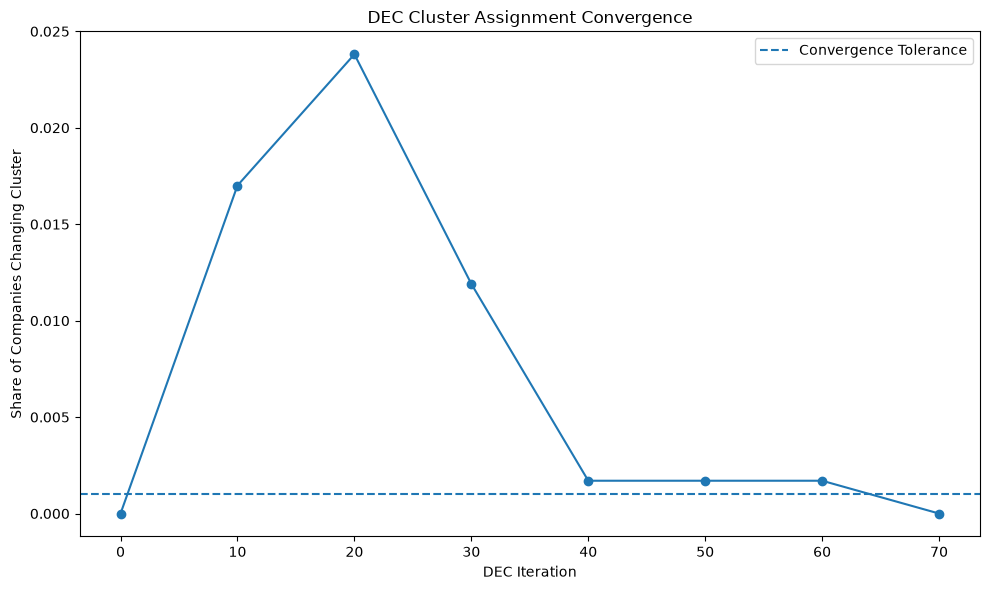

In [199]:
plt.figure(figsize=(10, 6))

plt.plot(
    dec_training_history_df["Iteration"],
    dec_training_history_df[
        "Label Change Share"
    ],
    marker="o",
)

plt.axhline(
    y=DEC_TOLERANCE,
    linestyle="--",
    label="Convergence Tolerance",
)

plt.xlabel("DEC Iteration")
plt.ylabel("Share of Companies Changing Cluster")
plt.title("DEC Cluster Assignment Convergence")
plt.legend()
plt.tight_layout()
plt.show()

### 9.6.12 Generate the Final DEC Result

In [200]:
# ==================================================
# Final DEC Assignments
# ==================================================

q_final = dec_model.predict(
    X_autoencoder,
    verbose=0,
)

dec_final_labels = q_final.argmax(
    axis=1
)

In [201]:
dec_final_cluster_sizes = (
    pd.Series(
        dec_final_labels,
        name="Cluster",
    )
    .value_counts()
    .sort_index()
)

dec_final_cluster_sizes

Cluster
0    261
1    106
2    144
3     77
Name: count, dtype: int64

### 9.6.13 Extract the Refined Latent Representation

In [202]:
# ==================================================
# Final DEC Latent Representation
# ==================================================

X_dec_final_latent = dec_encoder.predict(
    X_autoencoder,
    verbose=0,
)

print(
    f"Final DEC latent shape: "
    f"{X_dec_final_latent.shape}"
)

Final DEC latent shape: (588, 3)


### 9.6.14 Initial vs Final Clustering Metrics

In [203]:
# ==================================================
# Initial vs Final DEC Metrics
# ==================================================

dec_comparison_df = pd.DataFrame([
    {
        "Stage": "Before DEC Refinement",
        "Silhouette Score": silhouette_score(
            X_dec_initial_latent,
            dec_initial_labels,
        ),
        "Davies-Bouldin Index": (
            davies_bouldin_score(
                X_dec_initial_latent,
                dec_initial_labels,
            )
        ),
        "Calinski-Harabasz Score": (
            calinski_harabasz_score(
                X_dec_initial_latent,
                dec_initial_labels,
            )
        ),
    },
    {
        "Stage": "After DEC Refinement",
        "Silhouette Score": silhouette_score(
            X_dec_final_latent,
            dec_final_labels,
        ),
        "Davies-Bouldin Index": (
            davies_bouldin_score(
                X_dec_final_latent,
                dec_final_labels,
            )
        ),
        "Calinski-Harabasz Score": (
            calinski_harabasz_score(
                X_dec_final_latent,
                dec_final_labels,
            )
        ),
    },
])

dec_comparison_df

,Stage,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,Before DEC Refinement,0.451189,0.908821,434.488749
1,After DEC Refinement,0.514436,0.813440,617.792318


### 9.6.15 Visualize the DEC Cluster Structure

#### 9.6.15.1 Reusable cluster plotting function

In [204]:
# ==================================================
# Plot 2D Latent Cluster Structure
# ==================================================

def plot_latent_clusters(
    latent_features: np.ndarray,
    labels: np.ndarray,
    x_dimension: int,
    y_dimension: int,
    title: str,
) -> None:
    """
    Plots cluster assignments using two dimensions
    from a latent representation.
    """

    plt.figure(figsize=(10, 8))

    for cluster in sorted(np.unique(labels)):

        cluster_mask = labels == cluster

        plt.scatter(
            latent_features[
                cluster_mask,
                x_dimension,
            ],
            latent_features[
                cluster_mask,
                y_dimension,
            ],
            alpha=0.65,
            label=f"Cluster {cluster}",
        )

    plt.xlabel(
        f"Latent Dimension {x_dimension + 1}"
    )

    plt.ylabel(
        f"Latent Dimension {y_dimension + 1}"
    )

    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

#### 9.6.15.2 Before DEC refinement

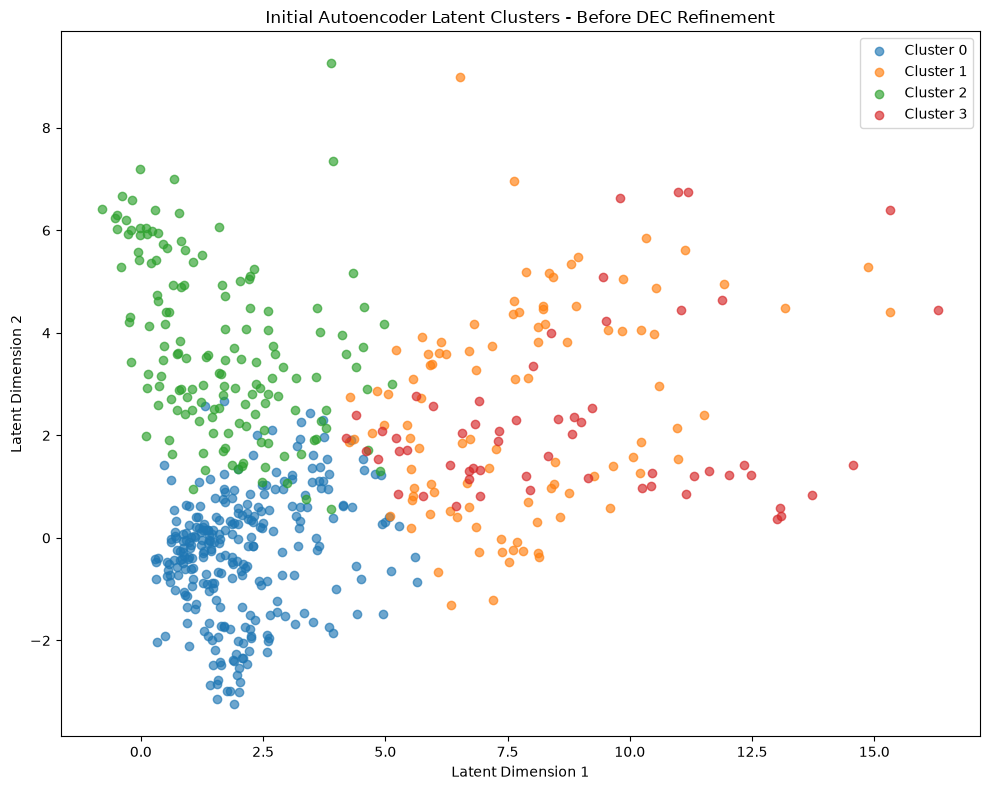

In [205]:
plot_latent_clusters(
    latent_features=X_dec_initial_latent,
    labels=dec_initial_labels,
    x_dimension=0,
    y_dimension=1,
    title=(
        "Initial Autoencoder Latent Clusters "
        "- Before DEC Refinement"
    ),
)

#### 9.6.15.3 After DEC refinement

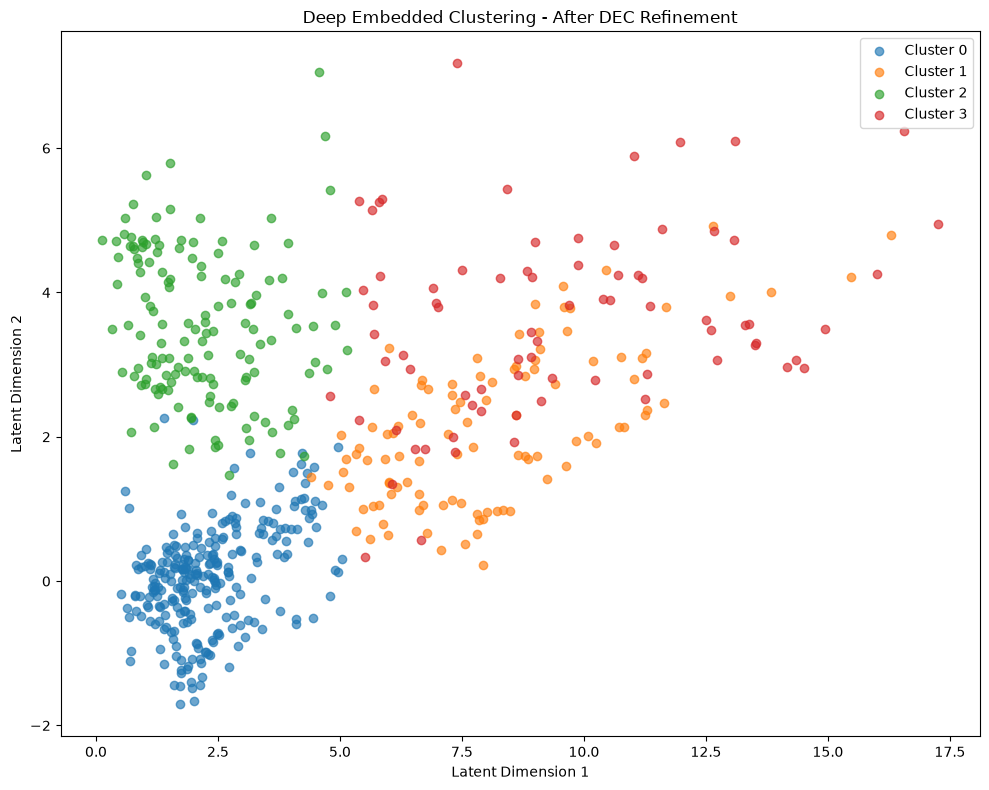

In [206]:
plot_latent_clusters(
    latent_features=X_dec_final_latent,
    labels=dec_final_labels,
    x_dimension=0,
    y_dimension=1,
    title=(
        "Deep Embedded Clustering "
        "- After DEC Refinement"
    ),
)

#### 9.6.15.4 All three DEC latent-dimension pairs

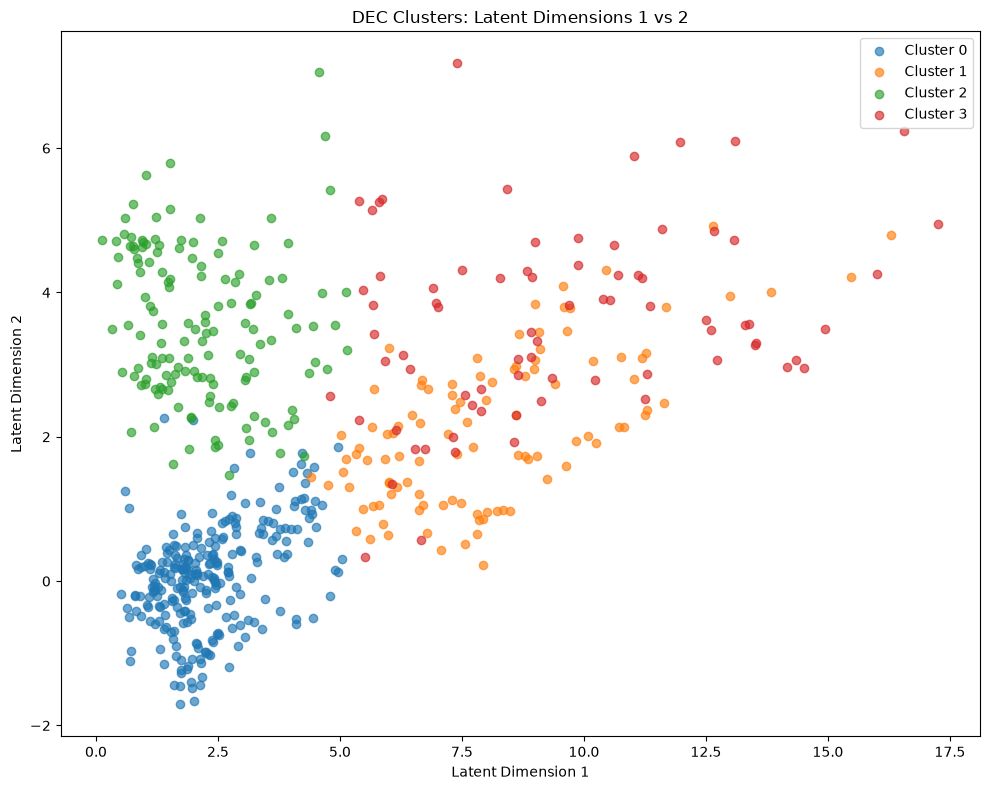

In [207]:
plot_latent_clusters(
    latent_features=X_dec_final_latent,
    labels=dec_final_labels,
    x_dimension=0,
    y_dimension=1,
    title="DEC Clusters: Latent Dimensions 1 vs 2",
)

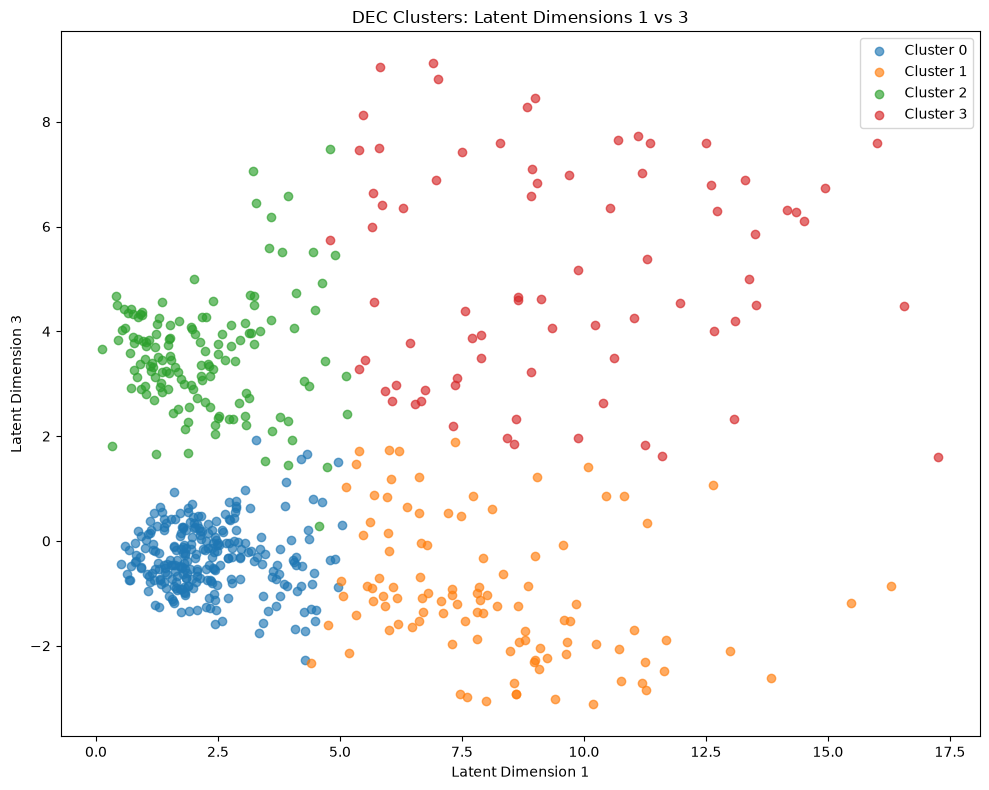

In [208]:
plot_latent_clusters(
    latent_features=X_dec_final_latent,
    labels=dec_final_labels,
    x_dimension=0,
    y_dimension=2,
    title="DEC Clusters: Latent Dimensions 1 vs 3",
)

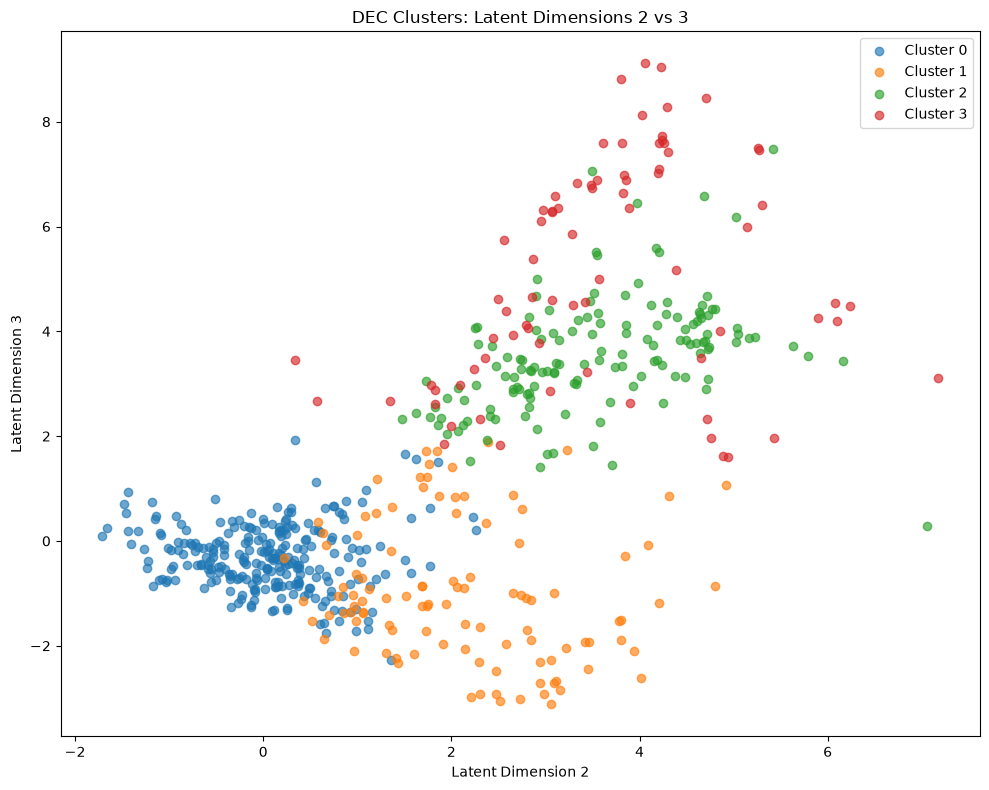

In [209]:
plot_latent_clusters(
    latent_features=X_dec_final_latent,
    labels=dec_final_labels,
    x_dimension=1,
    y_dimension=2,
    title="DEC Clusters: Latent Dimensions 2 vs 3",
)

#### 9.6.15.5 Add the learned DEC cluster centres

In [210]:
# ==================================================
# Extract Learned DEC Cluster Centres
# ==================================================

dec_cluster_centres = (
    dec_model
    .get_layer("clustering")
    .get_weights()[0]
)

print(
    f"DEC cluster centres shape: "
    f"{dec_cluster_centres.shape}"
)

DEC cluster centres shape: (4, 3)


In [211]:
# ==================================================
# Plot DEC Clusters with Learned Centres
# ==================================================

def plot_dec_clusters_with_centres(
    latent_features: np.ndarray,
    labels: np.ndarray,
    cluster_centres: np.ndarray,
    x_dimension: int,
    y_dimension: int,
    title: str,
) -> None:

    plt.figure(figsize=(10, 8))

    for cluster in sorted(np.unique(labels)):

        cluster_mask = labels == cluster

        plt.scatter(
            latent_features[
                cluster_mask,
                x_dimension,
            ],
            latent_features[
                cluster_mask,
                y_dimension,
            ],
            alpha=0.60,
            label=f"Cluster {cluster}",
        )

    plt.scatter(
        cluster_centres[:, x_dimension],
        cluster_centres[:, y_dimension],
        marker="X",
        s=250,
        edgecolor="black",
        linewidth=1.5,
        label="DEC Cluster Centres",
    )

    plt.xlabel(
        f"Latent Dimension {x_dimension + 1}"
    )

    plt.ylabel(
        f"Latent Dimension {y_dimension + 1}"
    )

    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

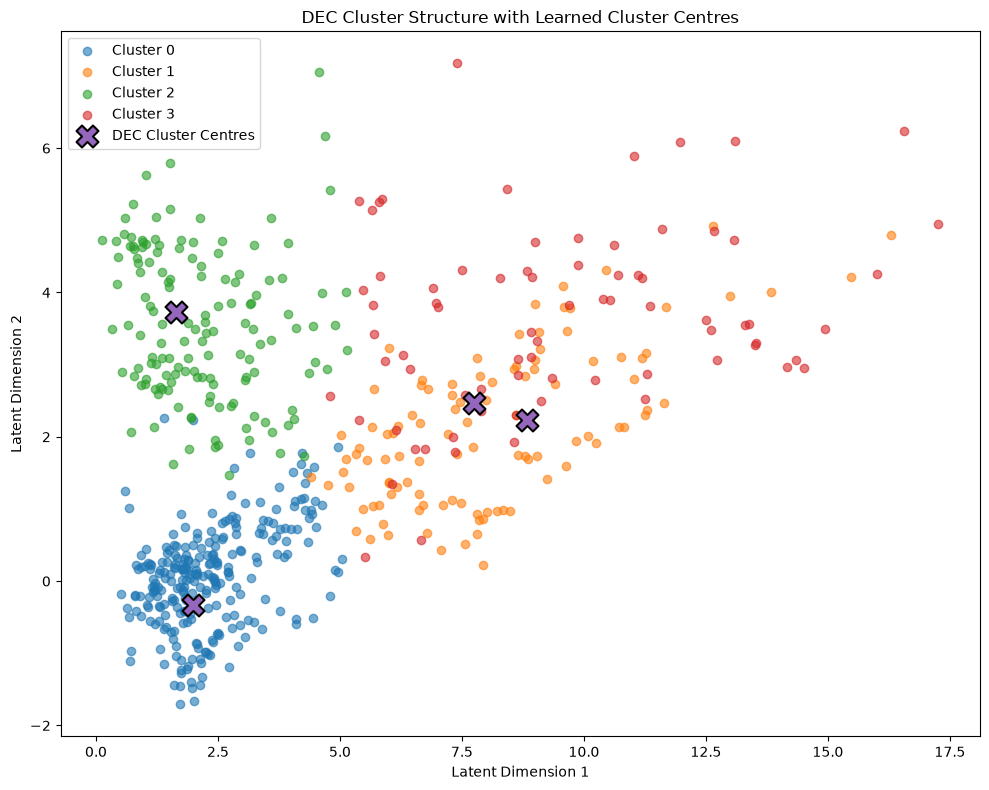

In [212]:
plot_dec_clusters_with_centres(
    latent_features=X_dec_final_latent,
    labels=dec_final_labels,
    cluster_centres=dec_cluster_centres,
    x_dimension=0,
    y_dimension=1,
    title=(
        "DEC Cluster Structure with "
        "Learned Cluster Centres"
    ),
)

#### 9.6.15.6 Before DEC refinement

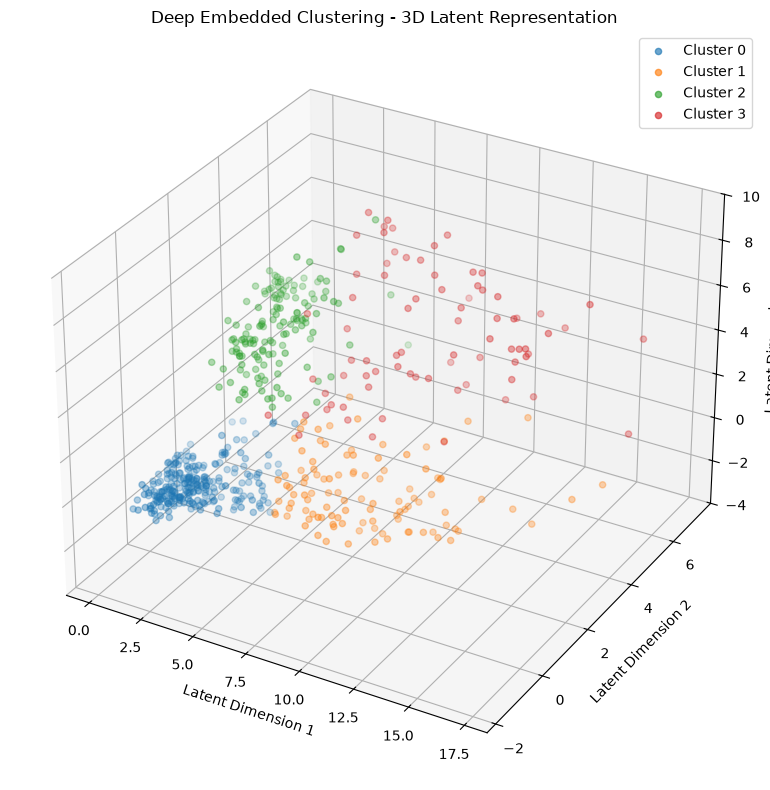

In [213]:
# ==================================================
# 3D DEC Cluster Visualization
# ==================================================

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(
    111,
    projection="3d",
)

for cluster in sorted(
    np.unique(dec_final_labels)
):

    cluster_mask = (
        dec_final_labels == cluster
    )

    ax.scatter(
        X_dec_final_latent[
            cluster_mask,
            0,
        ],
        X_dec_final_latent[
            cluster_mask,
            1,
        ],
        X_dec_final_latent[
            cluster_mask,
            2,
        ],
        alpha=0.65,
        label=f"Cluster {cluster}",
    )

ax.set_xlabel("Latent Dimension 1")
ax.set_ylabel("Latent Dimension 2")
ax.set_zlabel("Latent Dimension 3")

ax.set_title(
    "Deep Embedded Clustering "
    "- 3D Latent Representation"
)

ax.legend()

plt.tight_layout()
plt.show()

### 9.6.16 DEC Multi-Seed Stability Analysis

#### 9.6.16.1 Define the stability experiment

The proof-of-concept DEC experiment improved cluster separation while preserving healthy cluster sizes. However, the previous reconstruction-only autoencoder experiments demonstrated substantial sensitivity to random initialisation.

To determine whether the clustering-aware DEC objective improves reproducibility, the same baseline architecture is retrained and refined across five random seeds.

All experimental conditions are held constant except for the neural-network random seed:

- Baseline autoencoder architecture
- Three-dimensional latent representation
- K = 4 clusters
- Identical preprocessing and company cohort
- Identical train-validation split
- Identical DEC optimisation settings

Stability is evaluated by comparing:

- clustering quality before and after DEC refinement,
- cluster-size balance,
- convergence behaviour,
- Adjusted Rand Index (ARI), and
- Normalized Mutual Information (NMI).

The primary research question is whether DEC produces more consistent company-to-cluster assignments than the reconstruction-only autoencoder pipeline.

In [214]:
# ==================================================
# DEC Multi-Seed Stability Configuration
# ==================================================

DEC_STABILITY_SEEDS = [
    42,
    123,
    456,
    789,
    2026,
]

DEC_STABILITY_K = 4

print(
    f"DEC stability runs: "
    f"{len(DEC_STABILITY_SEEDS)}"
)

print(
    f"Fixed cluster count: "
    f"K = {DEC_STABILITY_K}"
)

DEC stability runs: 5
Fixed cluster count: K = 4


#### 9.6.16.2 Create one reusable DEC experiment function

In [215]:
# ==================================================
# Run One DEC Experiment
# ==================================================

def run_dec_experiment(
    seed: int,
    n_clusters: int,
) -> dict:
    """
    Runs one complete DEC experiment:

    1. Pretrains the baseline autoencoder
    2. Generates the initial latent representation
    3. Initializes clusters using K-Means
    4. Refines the encoder and cluster centres using DEC
    5. Returns initial and final metrics, labels and diagnostics
    """

    # --------------------------------------------------
    # Reset state and random seeds
    # --------------------------------------------------

    tf.keras.backend.clear_session()

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # --------------------------------------------------
    # Build baseline autoencoder
    # --------------------------------------------------

    autoencoder_model, encoder_model = (
        build_autoencoder(
            input_dim=INPUT_DIM,
            hidden_dims=[16, 8],
            latent_dim=3,
        )
    )

    # --------------------------------------------------
    # Autoencoder pretraining
    # --------------------------------------------------

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=20,
        min_delta=1e-4,
        restore_best_weights=True,
    )

    pretraining_history = autoencoder_model.fit(
        X_ae_train,
        X_ae_train,
        validation_data=(
            X_ae_validation,
            X_ae_validation,
        ),
        epochs=300,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0,
    )

    validation_loss = autoencoder_model.evaluate(
        X_ae_validation,
        X_ae_validation,
        verbose=0,
    )

    # --------------------------------------------------
    # Initial latent representation
    # --------------------------------------------------

    initial_latent = encoder_model.predict(
        X_autoencoder,
        verbose=0,
    )

    # --------------------------------------------------
    # K-Means initialization
    # --------------------------------------------------

    initial_kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=RANDOM_STATE,
        n_init=50,
    )

    initial_labels = initial_kmeans.fit_predict(
        initial_latent
    )

    # --------------------------------------------------
    # Initial clustering metrics
    # --------------------------------------------------

    initial_silhouette = silhouette_score(
        initial_latent,
        initial_labels,
    )

    initial_dbi = davies_bouldin_score(
        initial_latent,
        initial_labels,
    )

    initial_ch = calinski_harabasz_score(
        initial_latent,
        initial_labels,
    )

    # --------------------------------------------------
    # Build DEC model
    # --------------------------------------------------

    clustering_output = ClusteringLayer(
        n_clusters=n_clusters,
        name="clustering",
    )(
        encoder_model.output
    )

    dec_model_instance = Model(
        inputs=encoder_model.input,
        outputs=clustering_output,
        name=f"DEC_seed_{seed}",
    )

    # Initialize DEC centres with K-Means centres
    dec_model_instance.get_layer(
        "clustering"
    ).set_weights([
        initial_kmeans.cluster_centers_
    ])

    dec_model_instance.compile(
        optimizer=SGD(
            learning_rate=0.01,
            momentum=0.9,
        ),
        loss=KLDivergence(),
    )

    # --------------------------------------------------
    # DEC iterative refinement
    # --------------------------------------------------

    n_samples = X_autoencoder.shape[0]

    index_array = np.arange(n_samples)

    y_pred_last = initial_labels.copy()

    batch_index = 0

    convergence_iteration = (
        DEC_MAX_ITERATIONS
    )

    final_delta_label = np.nan

    convergence_records = []

    for iteration in range(
        DEC_MAX_ITERATIONS
    ):

        if iteration % DEC_UPDATE_INTERVAL == 0:

            q = dec_model_instance.predict(
                X_autoencoder,
                verbose=0,
            )

            p = target_distribution(q)

            y_pred = q.argmax(axis=1)

            delta_label = np.mean(
                y_pred != y_pred_last
            )

            convergence_records.append({
                "Iteration": iteration,
                "Label Change Share": delta_label,
            })

            final_delta_label = delta_label

            if (
                iteration > 0
                and delta_label
                < DEC_TOLERANCE
            ):

                convergence_iteration = (
                    iteration
                )

                break

            y_pred_last = y_pred.copy()

        # ----------------------------------------------
        # Mini-batch training
        # ----------------------------------------------

        batch_start = (
            batch_index
            * DEC_BATCH_SIZE
        )

        batch_end = min(
            (batch_index + 1)
            * DEC_BATCH_SIZE,
            n_samples,
        )

        batch_indices = index_array[
            batch_start:batch_end
        ]

        dec_model_instance.train_on_batch(
            X_autoencoder[batch_indices],
            p[batch_indices],
        )

        batch_index += 1

        if batch_end >= n_samples:
            batch_index = 0

    # --------------------------------------------------
    # Final DEC assignments
    # --------------------------------------------------

    q_final = dec_model_instance.predict(
        X_autoencoder,
        verbose=0,
    )

    final_labels = q_final.argmax(
        axis=1
    )

    # --------------------------------------------------
    # Final latent representation
    # --------------------------------------------------

    final_latent = encoder_model.predict(
        X_autoencoder,
        verbose=0,
    )

    # --------------------------------------------------
    # Final clustering metrics
    # --------------------------------------------------

    final_silhouette = silhouette_score(
        final_latent,
        final_labels,
    )

    final_dbi = davies_bouldin_score(
        final_latent,
        final_labels,
    )

    final_ch = calinski_harabasz_score(
        final_latent,
        final_labels,
    )

    # --------------------------------------------------
    # Cluster sizes
    # --------------------------------------------------

    initial_cluster_sizes = (
        pd.Series(initial_labels)
        .value_counts()
    )

    final_cluster_sizes = (
        pd.Series(final_labels)
        .value_counts()
    )

    # --------------------------------------------------
    # Return everything needed later
    # --------------------------------------------------

    return {
        "seed": seed,

        "epochs_trained": len(
            pretraining_history.history[
                "loss"
            ]
        ),

        "validation_loss": validation_loss,

        "initial_latent": initial_latent,
        "final_latent": final_latent,

        "initial_labels": initial_labels,
        "final_labels": final_labels,

        "initial_silhouette": (
            initial_silhouette
        ),
        "final_silhouette": (
            final_silhouette
        ),

        "initial_dbi": initial_dbi,
        "final_dbi": final_dbi,

        "initial_ch": initial_ch,
        "final_ch": final_ch,

        "initial_smallest_cluster": (
            initial_cluster_sizes.min()
        ),
        "initial_largest_cluster": (
            initial_cluster_sizes.max()
        ),

        "final_smallest_cluster": (
            final_cluster_sizes.min()
        ),
        "final_largest_cluster": (
            final_cluster_sizes.max()
        ),

        "convergence_iteration": (
            convergence_iteration
        ),

        "final_label_change_share": (
            final_delta_label
        ),

        "convergence_history": (
            pd.DataFrame(
                convergence_records
            )
        ),
    }

#### 9.6.16.3 Run the multi-seed experiment

In [216]:
# ==================================================
# Run DEC Stability Experiment
# ==================================================

dec_stability_results = {}

for seed in DEC_STABILITY_SEEDS:

    print(
        f"\nRunning DEC stability "
        f"experiment for seed {seed}..."
    )

    result = run_dec_experiment(
        seed=seed,
        n_clusters=DEC_STABILITY_K,
    )

    dec_stability_results[seed] = result

    print(
        f"Seed {seed} complete | "
        f"Silhouette: "
        f"{result['initial_silhouette']:.3f}"
        f" → "
        f"{result['final_silhouette']:.3f}"
    )


Running DEC stability experiment for seed 42...


Seed 42 complete | Silhouette: 0.451 → 0.514

Running DEC stability experiment for seed 123...


Seed 123 complete | Silhouette: 0.389 → 0.594

Running DEC stability experiment for seed 456...


Seed 456 complete | Silhouette: 0.460 → 0.635

Running DEC stability experiment for seed 789...


Seed 789 complete | Silhouette: 0.478 → 0.567

Running DEC stability experiment for seed 2026...


Seed 2026 complete | Silhouette: 0.336 → 0.544


#### 9.6.16.5 Stability Summary

In [217]:
# ==================================================
# DEC Stability Results Summary
# ==================================================

dec_stability_records = []

for seed, result in (
    dec_stability_results.items()
):

    dec_stability_records.append({
        "Seed": seed,

        "Epochs Trained": (
            result["epochs_trained"]
        ),

        "Validation Reconstruction Loss": (
            result["validation_loss"]
        ),

        "Initial Silhouette": (
            result["initial_silhouette"]
        ),

        "Final Silhouette": (
            result["final_silhouette"]
        ),

        "Silhouette Improvement": (
            result["final_silhouette"]
            - result["initial_silhouette"]
        ),

        "Initial DBI": (
            result["initial_dbi"]
        ),

        "Final DBI": (
            result["final_dbi"]
        ),

        "DBI Improvement": (
            result["initial_dbi"]
            - result["final_dbi"]
        ),

        "Initial CH": (
            result["initial_ch"]
        ),

        "Final CH": (
            result["final_ch"]
        ),

        "CH Improvement": (
            result["final_ch"]
            - result["initial_ch"]
        ),

        "Initial Smallest Cluster": (
            result[
                "initial_smallest_cluster"
            ]
        ),

        "Final Smallest Cluster": (
            result[
                "final_smallest_cluster"
            ]
        ),

        "Initial Largest Cluster": (
            result[
                "initial_largest_cluster"
            ]
        ),

        "Final Largest Cluster": (
            result[
                "final_largest_cluster"
            ]
        ),

        "Convergence Iteration": (
            result[
                "convergence_iteration"
            ]
        ),
    })


dec_stability_results_df = pd.DataFrame(
    dec_stability_records
)

dec_stability_results_df

,Seed,Epochs Trained,Validation Reconstruction Loss,Initial Silhouette,Final Silhouette,Silhouette Improvement,Initial DBI,Final DBI,DBI Improvement,Initial CH,Final CH,CH Improvement,Initial Smallest Cluster,Final Smallest Cluster,Initial Largest Cluster,Final Largest Cluster,Convergence Iteration
0,42,299,0.297786,0.451189,0.514436,0.063247,0.908821,0.813440,0.095382,434.488749,617.792341,183.303592,59,77,276,261,70
1,123,300,0.303882,0.389342,0.594217,0.204875,0.943061,0.537329,0.405732,436.094694,1291.644823,855.550128,68,60,275,256,150
2,456,300,0.354099,0.460500,0.635339,0.174839,0.770295,0.558540,0.211755,498.314107,1100.895102,602.580995,52,82,281,266,190
3,789,300,0.291312,0.477967,0.566974,0.089007,0.849008,0.604291,0.244717,666.923547,1009.299296,342.375749,54,98,296,239,300
4,2026,177,0.396164,0.336354,0.543638,0.207284,0.961748,0.636281,0.325468,466.676699,1051.361489,584.684791,51,54,318,293,200


In [218]:
# ==================================================
# DEC Metric Improvement Summary
# ==================================================

dec_metric_improvement_summary = (
    dec_stability_results_df[
        [
            "Silhouette Improvement",
            "DBI Improvement",
            "CH Improvement",
        ]
    ]
    .agg([
        "mean",
        "std",
        "min",
        "max",
    ])
    .T
)

dec_metric_improvement_summary

,mean,std,min,max
Silhouette Improvement,0.147850,0.067329,0.063247,0.207284
DBI Improvement,0.256611,0.117396,0.095382,0.405732
CH Improvement,513.699051,258.995158,183.303592,855.550128


#### 9.6.16.6 Pairwise assignment stability before and after DEC

In [219]:
# ==================================================
# Pairwise DEC Assignment Stability
# ==================================================

dec_pairwise_stability_records = []

for i, seed_a in enumerate(
    DEC_STABILITY_SEEDS
):

    for seed_b in (
        DEC_STABILITY_SEEDS[i + 1:]
    ):

        result_a = (
            dec_stability_results[seed_a]
        )

        result_b = (
            dec_stability_results[seed_b]
        )

        # ----------------------------------------------
        # Before DEC
        # ----------------------------------------------

        initial_ari = adjusted_rand_score(
            result_a["initial_labels"],
            result_b["initial_labels"],
        )

        initial_nmi = (
            normalized_mutual_info_score(
                result_a["initial_labels"],
                result_b["initial_labels"],
            )
        )

        # ----------------------------------------------
        # After DEC
        # ----------------------------------------------

        final_ari = adjusted_rand_score(
            result_a["final_labels"],
            result_b["final_labels"],
        )

        final_nmi = (
            normalized_mutual_info_score(
                result_a["final_labels"],
                result_b["final_labels"],
            )
        )

        dec_pairwise_stability_records.append({
            "Seed A": seed_a,
            "Seed B": seed_b,

            "Initial ARI": initial_ari,
            "Final ARI": final_ari,
            "ARI Improvement": (
                final_ari
                - initial_ari
            ),

            "Initial NMI": initial_nmi,
            "Final NMI": final_nmi,
            "NMI Improvement": (
                final_nmi
                - initial_nmi
            ),
        })


dec_pairwise_stability_df = pd.DataFrame(
    dec_pairwise_stability_records
)

dec_pairwise_stability_df

,Seed A,Seed B,Initial ARI,Final ARI,ARI Improvement,Initial NMI,Final NMI,NMI Improvement
0,42,123,0.520071,0.509051,-0.011020,0.501084,0.470782,-0.030302
1,42,456,0.568216,0.589446,0.021230,0.556334,0.573558,0.017224
2,42,789,0.606212,0.674680,0.068467,0.511731,0.618910,0.107179
3,42,2026,0.293153,0.321998,0.028845,0.331601,0.342024,0.010423
4,123,456,0.407748,0.365432,-0.042317,0.465428,0.406614,-0.058814
5,123,789,0.487874,0.460652,-0.027222,0.444753,0.438403,-0.006350
6,123,2026,0.412269,0.439196,0.026927,0.412465,0.457687,0.045222
7,456,789,0.449790,0.518765,0.068976,0.448000,0.516615,0.068615
8,456,2026,0.176051,0.222279,0.046228,0.268208,0.291634,0.023426
9,789,2026,0.318031,0.322014,0.003983,0.352354,0.356369,0.004015


#### 9.6.16.7 Summarize before vs after stability

In [220]:
# ==================================================
# DEC Assignment Stability Summary
# ==================================================

dec_assignment_stability_summary = (
    dec_pairwise_stability_df[
        [
            "Initial ARI",
            "Final ARI",
            "ARI Improvement",
            "Initial NMI",
            "Final NMI",
            "NMI Improvement",
        ]
    ]
    .agg([
        "mean",
        "std",
        "min",
        "max",
    ])
    .T
)

dec_assignment_stability_summary

,mean,std,min,max
Initial ARI,0.423942,0.132583,0.176051,0.606212
Final ARI,0.442351,0.137259,0.222279,0.674680
ARI Improvement,0.018410,0.037816,-0.042317,0.068976
Initial NMI,0.429196,0.089243,0.268208,0.556334
Final NMI,0.447260,0.103372,0.291634,0.618910
NMI Improvement,0.018064,0.047569,-0.058814,0.107179


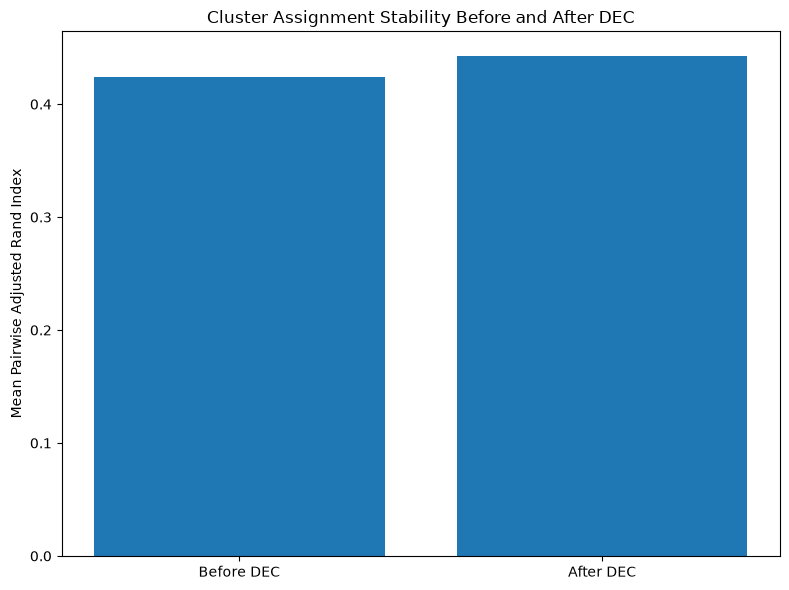

In [221]:
# ==================================================
# DEC Assignment Stability Comparison
# ==================================================

stability_plot_df = pd.DataFrame({
    "Stage": [
        "Before DEC",
        "After DEC",
    ],

    "Mean ARI": [
        dec_pairwise_stability_df[
            "Initial ARI"
        ].mean(),

        dec_pairwise_stability_df[
            "Final ARI"
        ].mean(),
    ],
})

plt.figure(figsize=(8, 6))

plt.bar(
    stability_plot_df["Stage"],
    stability_plot_df["Mean ARI"],
)

plt.ylabel("Mean Pairwise Adjusted Rand Index")
plt.title(
    "Cluster Assignment Stability "
    "Before and After DEC"
)

plt.tight_layout()
plt.show()

In [222]:
# ==================================================
# Initial vs Final Assignment Agreement Within Seed
# ==================================================

dec_within_seed_records = []

for seed, result in (
    dec_stability_results.items()
):

    dec_within_seed_records.append({
        "Seed": seed,

        "Initial vs Final ARI": (
            adjusted_rand_score(
                result["initial_labels"],
                result["final_labels"],
            )
        ),

        "Initial vs Final NMI": (
            normalized_mutual_info_score(
                result["initial_labels"],
                result["final_labels"],
            )
        ),
    })


dec_within_seed_stability_df = pd.DataFrame(
    dec_within_seed_records
)

dec_within_seed_stability_df

,Seed,Initial vs Final ARI,Initial vs Final NMI
0,42,0.889616,0.843461
1,123,0.726726,0.721614
2,456,0.782695,0.721125
3,789,0.611573,0.611072
4,2026,0.687332,0.655818


#### 9.6.16.7 DEC Multi-Seed Stability Conclusion

The multi-seed DEC experiment produced a clear distinction between clustering quality and clustering reproducibility.

DEC substantially improved the internal quality of every tested clustering solution. Across all five random seeds, Silhouette Scores increased, Davies-Bouldin Indices decreased, and Calinski-Harabasz Scores increased. The mean Silhouette improvement was approximately 0.15, demonstrating that the clustering-aware optimisation objective consistently produced more compact and better-separated latent groups.

However, improvements in cross-seed assignment stability were limited. Mean pairwise Adjusted Rand Index increased only from approximately 0.42 to 0.44, while mean Normalized Mutual Information increased from approximately 0.43 to 0.45. Seven of ten seed-pair comparisons improved, but three became less similar after DEC refinement.

Within-seed comparisons showed that final DEC assignments generally remained strongly related to their initial K-Means solutions, with initial-to-final ARI values ranging from approximately 0.61 to 0.89. This suggests that DEC primarily sharpens the cluster structure inherited from each pretrained autoencoder rather than forcing different neural initialisations toward a common peer-group solution.

The experiment therefore concludes that DEC is highly effective at improving cluster separation, but does not substantially resolve the random-initialisation sensitivity of reconstruction-based neural representations.

## **9.7 Improved Deep Embedded Clustering**

### 9.7.1 Experimental Design

Improved Deep Embedded Clustering (IDEC) extends DEC by jointly optimizing both clustering loss and reconstruction loss during the refinement stage.

The previous DEC experiment substantially improved cluster separation across all random seeds, but only marginally improved cross-seed assignment stability. This suggests that DEC sharpened each seed-specific representation rather than forcing different neural initialisations toward a common clustering structure.

IDEC is tested to determine whether preserving reconstruction quality during clustering refinement can improve the balance between:

- cluster separation,
- representation stability,
- company assignment consistency,
- cluster size balance, and
- business interpretability.

The experiment uses the same baseline autoencoder architecture, K=4, and five random seeds as the DEC stability analysis, allowing a direct comparison between Autoencoder + K-Means, DEC, and IDEC.

### 9.7.2 IDEC Configuration

In [223]:
# ==================================================
# IDEC Multi-Seed Stability Configuration
# ==================================================

IDEC_STABILITY_SEEDS = [
    42,
    123,
    456,
    789,
    2026,
]

IDEC_STABILITY_K = 4

IDEC_MAX_ITERATIONS = 1_000
IDEC_UPDATE_INTERVAL = 10
IDEC_BATCH_SIZE = 64
IDEC_TOLERANCE = 0.001

# Weight assigned to reconstruction loss
IDEC_RECONSTRUCTION_WEIGHT = 1.0

print(f"IDEC stability runs: {len(IDEC_STABILITY_SEEDS)}")
print(f"Fixed cluster count: K = {IDEC_STABILITY_K}")
print(f"Reconstruction loss weight: {IDEC_RECONSTRUCTION_WEIGHT}")

IDEC stability runs: 5
Fixed cluster count: K = 4
Reconstruction loss weight: 1.0


### 9.7.3 Build IDEC Model

In [224]:
# ==================================================
# Build IDEC Model
# ==================================================

def build_idec_model(
    encoder_model: Model,
    autoencoder_model: Model,
    n_clusters: int,
) -> Model:
    """
    Builds an IDEC model with two outputs:

    1. DEC clustering probabilities
    2. Autoencoder reconstruction

    The encoder and decoder weights are inherited from
    the pretrained autoencoder.
    """

    clustering_output = ClusteringLayer(
        n_clusters=n_clusters,
        name="clustering",
    )(
        encoder_model.output
    )

    reconstruction_output = (
        autoencoder_model.output
    )

    idec_model = Model(
        inputs=encoder_model.input,
        outputs=[
            clustering_output,
            reconstruction_output,
        ],
        name="IDEC",
    )

    idec_model.compile(
        optimizer=SGD(
            learning_rate=0.01,
            momentum=0.9,
        ),
        loss=[
            KLDivergence(),
            "mse",
        ],
        loss_weights=[
            1.0,
            IDEC_RECONSTRUCTION_WEIGHT,
        ],
    )

    return idec_model

### 9.7.4 Run One IDEC Experiment

In [225]:
# ==================================================
# Run One IDEC Experiment
# ==================================================

def run_idec_experiment(
    seed: int,
    n_clusters: int,
) -> dict:
    """
    Runs one complete IDEC experiment:

    1. Pretrains the baseline autoencoder
    2. Generates the initial latent representation
    3. Initializes clusters using K-Means
    4. Refines encoder, decoder, and cluster centres using IDEC
    5. Returns initial and final metrics, labels, and diagnostics
    """

    # --------------------------------------------------
    # Reset state and random seeds
    # --------------------------------------------------

    tf.keras.backend.clear_session()

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # --------------------------------------------------
    # Build baseline autoencoder
    # --------------------------------------------------

    autoencoder_model, encoder_model = (
        build_autoencoder(
            input_dim=INPUT_DIM,
            hidden_dims=[16, 8],
            latent_dim=3,
        )
    )

    # --------------------------------------------------
    # Autoencoder pretraining
    # --------------------------------------------------

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=20,
        min_delta=1e-4,
        restore_best_weights=True,
    )

    pretraining_history = autoencoder_model.fit(
        X_ae_train,
        X_ae_train,
        validation_data=(
            X_ae_validation,
            X_ae_validation,
        ),
        epochs=300,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0,
    )

    validation_loss = autoencoder_model.evaluate(
        X_ae_validation,
        X_ae_validation,
        verbose=0,
    )

    # --------------------------------------------------
    # Initial latent representation
    # --------------------------------------------------

    initial_latent = encoder_model.predict(
        X_autoencoder,
        verbose=0,
    )

    # --------------------------------------------------
    # K-Means initialization
    # --------------------------------------------------

    initial_kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=RANDOM_STATE,
        n_init=50,
    )

    initial_labels = initial_kmeans.fit_predict(
        initial_latent
    )

    # --------------------------------------------------
    # Initial clustering metrics
    # --------------------------------------------------

    initial_silhouette = silhouette_score(
        initial_latent,
        initial_labels,
    )

    initial_dbi = davies_bouldin_score(
        initial_latent,
        initial_labels,
    )

    initial_ch = calinski_harabasz_score(
        initial_latent,
        initial_labels,
    )

    # --------------------------------------------------
    # Build IDEC model
    # --------------------------------------------------

    idec_model_instance = build_idec_model(
        encoder_model=encoder_model,
        autoencoder_model=autoencoder_model,
        n_clusters=n_clusters,
    )

    # Initialize cluster centres from K-Means
    idec_model_instance.get_layer(
        "clustering"
    ).set_weights([
        initial_kmeans.cluster_centers_
    ])

    # --------------------------------------------------
    # IDEC iterative refinement
    # --------------------------------------------------

    n_samples = X_autoencoder.shape[0]

    index_array = np.arange(n_samples)

    y_pred_last = initial_labels.copy()

    batch_index = 0

    convergence_iteration = (
        IDEC_MAX_ITERATIONS
    )

    final_delta_label = np.nan

    convergence_records = []

    for iteration in range(
        IDEC_MAX_ITERATIONS
    ):

        if iteration % IDEC_UPDATE_INTERVAL == 0:

            q, reconstructed = (
                idec_model_instance.predict(
                    X_autoencoder,
                    verbose=0,
                )
            )

            p = target_distribution(q)

            y_pred = q.argmax(axis=1)

            delta_label = np.mean(
                y_pred != y_pred_last
            )

            convergence_records.append({
                "Iteration": iteration,
                "Label Change Share": delta_label,
            })

            final_delta_label = delta_label

            if (
                iteration > 0
                and delta_label
                < IDEC_TOLERANCE
            ):

                convergence_iteration = (
                    iteration
                )

                break

            y_pred_last = y_pred.copy()

        # ----------------------------------------------
        # Mini-batch training
        # ----------------------------------------------

        batch_start = (
            batch_index
            * IDEC_BATCH_SIZE
        )

        batch_end = min(
            (batch_index + 1)
            * IDEC_BATCH_SIZE,
            n_samples,
        )

        batch_indices = index_array[
            batch_start:batch_end
        ]

        idec_model_instance.train_on_batch(
            X_autoencoder[batch_indices],
            [
                p[batch_indices],
                X_autoencoder[batch_indices],
            ],
        )

        batch_index += 1

        if batch_end >= n_samples:
            batch_index = 0

    # --------------------------------------------------
    # Final IDEC assignments
    # --------------------------------------------------

    q_final, reconstructed_final = (
        idec_model_instance.predict(
            X_autoencoder,
            verbose=0,
        )
    )

    final_labels = q_final.argmax(axis=1)

    # --------------------------------------------------
    # Final latent representation
    # --------------------------------------------------

    final_latent = encoder_model.predict(
        X_autoencoder,
        verbose=0,
    )

    # --------------------------------------------------
    # Final reconstruction loss
    # --------------------------------------------------

    final_reconstruction_error = np.mean(
        np.square(
            X_autoencoder
            - reconstructed_final
        )
    )

    # --------------------------------------------------
    # Final clustering metrics
    # --------------------------------------------------

    final_silhouette = silhouette_score(
        final_latent,
        final_labels,
    )

    final_dbi = davies_bouldin_score(
        final_latent,
        final_labels,
    )

    final_ch = calinski_harabasz_score(
        final_latent,
        final_labels,
    )

    # --------------------------------------------------
    # Cluster sizes
    # --------------------------------------------------

    initial_cluster_sizes = (
        pd.Series(initial_labels)
        .value_counts()
    )

    final_cluster_sizes = (
        pd.Series(final_labels)
        .value_counts()
    )

    # --------------------------------------------------
    # Return everything needed later
    # --------------------------------------------------

    return {
        "seed": seed,

        "epochs_trained": len(
            pretraining_history.history["loss"]
        ),

        "pretraining_validation_loss": (
            validation_loss
        ),

        "final_reconstruction_error": (
            final_reconstruction_error
        ),

        "initial_latent": initial_latent,
        "final_latent": final_latent,

        "initial_labels": initial_labels,
        "final_labels": final_labels,

        "initial_silhouette": (
            initial_silhouette
        ),
        "final_silhouette": (
            final_silhouette
        ),

        "initial_dbi": initial_dbi,
        "final_dbi": final_dbi,

        "initial_ch": initial_ch,
        "final_ch": final_ch,

        "initial_smallest_cluster": (
            initial_cluster_sizes.min()
        ),
        "initial_largest_cluster": (
            initial_cluster_sizes.max()
        ),

        "final_smallest_cluster": (
            final_cluster_sizes.min()
        ),
        "final_largest_cluster": (
            final_cluster_sizes.max()
        ),

        "convergence_iteration": (
            convergence_iteration
        ),

        "final_label_change_share": (
            final_delta_label
        ),

        "convergence_history": (
            pd.DataFrame(
                convergence_records
            )
        ),
    }

### 9.7.5 Run IDEC Across Seeds

In [226]:
# ==================================================
# Run IDEC Stability Experiment
# ==================================================

idec_stability_results = {}

for seed in IDEC_STABILITY_SEEDS:

    print(
        f"\nRunning IDEC stability "
        f"experiment for seed {seed}..."
    )

    result = run_idec_experiment(
        seed=seed,
        n_clusters=IDEC_STABILITY_K,
    )

    idec_stability_results[seed] = result

    print(
        f"Seed {seed} complete | "
        f"Silhouette: "
        f"{result['initial_silhouette']:.3f}"
        f" → "
        f"{result['final_silhouette']:.3f}"
    )


Running IDEC stability experiment for seed 42...


Seed 42 complete | Silhouette: 0.451 → 0.499

Running IDEC stability experiment for seed 123...


Seed 123 complete | Silhouette: 0.389 → 0.504

Running IDEC stability experiment for seed 456...


Seed 456 complete | Silhouette: 0.460 → 0.527

Running IDEC stability experiment for seed 789...


Seed 789 complete | Silhouette: 0.478 → 0.530

Running IDEC stability experiment for seed 2026...


Seed 2026 complete | Silhouette: 0.336 → 0.429


### 9.7.6 Build the IDEC Results Summary

In [227]:
# ==================================================
# IDEC Stability Results Summary
# ==================================================

idec_stability_records = []

for seed, result in (
    idec_stability_results.items()
):

    idec_stability_records.append({
        "Seed": seed,

        "Epochs Trained": (
            result["epochs_trained"]
        ),

        "Pretraining Validation Loss": (
            result[
                "pretraining_validation_loss"
            ]
        ),

        "Final Reconstruction Error": (
            result[
                "final_reconstruction_error"
            ]
        ),

        "Initial Silhouette": (
            result["initial_silhouette"]
        ),

        "Final Silhouette": (
            result["final_silhouette"]
        ),

        "Silhouette Improvement": (
            result["final_silhouette"]
            - result["initial_silhouette"]
        ),

        "Initial DBI": (
            result["initial_dbi"]
        ),

        "Final DBI": (
            result["final_dbi"]
        ),

        "DBI Improvement": (
            result["initial_dbi"]
            - result["final_dbi"]
        ),

        "Initial CH": (
            result["initial_ch"]
        ),

        "Final CH": (
            result["final_ch"]
        ),

        "CH Improvement": (
            result["final_ch"]
            - result["initial_ch"]
        ),

        "Initial Smallest Cluster": (
            result[
                "initial_smallest_cluster"
            ]
        ),

        "Final Smallest Cluster": (
            result[
                "final_smallest_cluster"
            ]
        ),

        "Initial Largest Cluster": (
            result[
                "initial_largest_cluster"
            ]
        ),

        "Final Largest Cluster": (
            result[
                "final_largest_cluster"
            ]
        ),

        "Convergence Iteration": (
            result[
                "convergence_iteration"
            ]
        ),
    })


idec_stability_results_df = pd.DataFrame(
    idec_stability_records
)

idec_stability_results_df

,Seed,Epochs Trained,Pretraining Validation Loss,Final Reconstruction Error,Initial Silhouette,Final Silhouette,Silhouette Improvement,Initial DBI,Final DBI,DBI Improvement,Initial CH,Final CH,CH Improvement,Initial Smallest Cluster,Final Smallest Cluster,Initial Largest Cluster,Final Largest Cluster,Convergence Iteration
0,42,299,0.297786,0.221890,0.451189,0.498581,0.047392,0.908821,0.841833,0.066988,434.488749,550.657922,116.169174,59,68,276,267,70
1,123,300,0.303882,0.220763,0.389342,0.503631,0.114289,0.943061,0.698876,0.244186,436.094694,885.455726,449.361031,68,64,275,259,140
2,456,300,0.354099,0.224657,0.460500,0.526756,0.066256,0.770295,0.682300,0.087994,498.314107,710.784040,212.469934,52,80,281,267,80
3,789,300,0.291312,0.193447,0.477967,0.530350,0.052383,0.849008,0.720510,0.128498,666.923547,873.718009,206.794463,54,79,296,267,160
4,2026,177,0.396164,0.259775,0.336354,0.428621,0.092266,0.961748,0.804923,0.156826,466.676699,758.906324,292.229626,51,54,318,307,170


### 9.7.7 Summarize IDEC Metric Improvement

In [228]:
# ==================================================
# IDEC Metric Improvement Summary
# ==================================================

idec_metric_improvement_summary = (
    idec_stability_results_df[
        [
            "Silhouette Improvement",
            "DBI Improvement",
            "CH Improvement",
        ]
    ]
    .agg([
        "mean",
        "std",
        "min",
        "max",
    ])
    .T
)

idec_metric_improvement_summary

,mean,std,min,max
Silhouette Improvement,0.074517,0.028244,0.047392,0.114289
DBI Improvement,0.136898,0.069385,0.066988,0.244186
CH Improvement,255.404845,125.067996,116.169174,449.361031


### 9.7.8 Pairwise Assignment Stability

In [229]:
# ==================================================
# Pairwise IDEC Assignment Stability
# ==================================================

idec_pairwise_stability_records = []

for i, seed_a in enumerate(
    IDEC_STABILITY_SEEDS
):

    for seed_b in (
        IDEC_STABILITY_SEEDS[i + 1:]
    ):

        result_a = (
            idec_stability_results[seed_a]
        )

        result_b = (
            idec_stability_results[seed_b]
        )

        # ----------------------------------------------
        # Before IDEC
        # ----------------------------------------------

        initial_ari = adjusted_rand_score(
            result_a["initial_labels"],
            result_b["initial_labels"],
        )

        initial_nmi = (
            normalized_mutual_info_score(
                result_a["initial_labels"],
                result_b["initial_labels"],
            )
        )

        # ----------------------------------------------
        # After IDEC
        # ----------------------------------------------

        final_ari = adjusted_rand_score(
            result_a["final_labels"],
            result_b["final_labels"],
        )

        final_nmi = (
            normalized_mutual_info_score(
                result_a["final_labels"],
                result_b["final_labels"],
            )
        )

        idec_pairwise_stability_records.append({
            "Seed A": seed_a,
            "Seed B": seed_b,

            "Initial ARI": initial_ari,
            "Final ARI": final_ari,
            "ARI Improvement": (
                final_ari
                - initial_ari
            ),

            "Initial NMI": initial_nmi,
            "Final NMI": final_nmi,
            "NMI Improvement": (
                final_nmi
                - initial_nmi
            ),
        })


idec_pairwise_stability_df = pd.DataFrame(
    idec_pairwise_stability_records
)

idec_pairwise_stability_df

,Seed A,Seed B,Initial ARI,Final ARI,ARI Improvement,Initial NMI,Final NMI,NMI Improvement
0,42,123,0.520071,0.491895,-0.028176,0.501084,0.463757,-0.037326
1,42,456,0.568216,0.586845,0.018629,0.556334,0.567814,0.011479
2,42,789,0.606212,0.649629,0.043417,0.511731,0.548191,0.036460
3,42,2026,0.293153,0.281854,-0.011299,0.331601,0.321391,-0.010210
4,123,456,0.407748,0.380066,-0.027683,0.465428,0.420377,-0.045051
5,123,789,0.487874,0.530302,0.042428,0.444753,0.470415,0.025663
6,123,2026,0.412269,0.425214,0.012945,0.412465,0.463251,0.050786
7,456,789,0.449790,0.500164,0.050374,0.448000,0.485014,0.037014
8,456,2026,0.176051,0.189096,0.013045,0.268208,0.270725,0.002517
9,789,2026,0.318031,0.356330,0.038299,0.352354,0.385659,0.033305


In [230]:
# ==================================================
# IDEC Assignment Stability Summary
# ==================================================

idec_assignment_stability_summary = (
    idec_pairwise_stability_df[
        [
            "Initial ARI",
            "Final ARI",
            "ARI Improvement",
            "Initial NMI",
            "Final NMI",
            "NMI Improvement",
        ]
    ]
    .agg([
        "mean",
        "std",
        "min",
        "max",
    ])
    .T
)

idec_assignment_stability_summary

,mean,std,min,max
Initial ARI,0.423942,0.132583,0.176051,0.606212
Final ARI,0.439140,0.140926,0.189096,0.649629
ARI Improvement,0.015198,0.029349,-0.028176,0.050374
Initial NMI,0.429196,0.089243,0.268208,0.556334
Final NMI,0.439660,0.093189,0.270725,0.567814
NMI Improvement,0.010464,0.032688,-0.045051,0.050786


### 9.7.9 Initial vs Final Assignment Agreement Within Seed

In [231]:
# ==================================================
# Initial vs Final IDEC Assignment Agreement
# ==================================================

idec_within_seed_records = []

for seed, result in (
    idec_stability_results.items()
):

    idec_within_seed_records.append({
        "Seed": seed,

        "Initial vs Final ARI": (
            adjusted_rand_score(
                result["initial_labels"],
                result["final_labels"],
            )
        ),

        "Initial vs Final NMI": (
            normalized_mutual_info_score(
                result["initial_labels"],
                result["final_labels"],
            )
        ),
    })


idec_within_seed_stability_df = pd.DataFrame(
    idec_within_seed_records
)

idec_within_seed_stability_df

,Seed,Initial vs Final ARI,Initial vs Final NMI
0,42,0.925920,0.877478
1,123,0.775636,0.770243
2,456,0.847279,0.790438
3,789,0.773050,0.745372
4,2026,0.824263,0.772137


### 9.7.10 Compare DEC vs IDEC

In [232]:
# ==================================================
# DEC vs IDEC Metric Improvement Comparison
# ==================================================

deep_clustering_improvement_comparison = pd.DataFrame([
    {
        "Method": "DEC",
        "Mean Silhouette Improvement": (
            dec_stability_results_df[
                "Silhouette Improvement"
            ].mean()
        ),
        "Mean DBI Improvement": (
            dec_stability_results_df[
                "DBI Improvement"
            ].mean()
        ),
        "Mean CH Improvement": (
            dec_stability_results_df[
                "CH Improvement"
            ].mean()
        ),
    },
    {
        "Method": "IDEC",
        "Mean Silhouette Improvement": (
            idec_stability_results_df[
                "Silhouette Improvement"
            ].mean()
        ),
        "Mean DBI Improvement": (
            idec_stability_results_df[
                "DBI Improvement"
            ].mean()
        ),
        "Mean CH Improvement": (
            idec_stability_results_df[
                "CH Improvement"
            ].mean()
        ),
    },
])

deep_clustering_improvement_comparison

,Method,Mean Silhouette Improvement,Mean DBI Improvement,Mean CH Improvement
0,DEC,0.147850,0.256611,513.699051
1,IDEC,0.074517,0.136898,255.404845


In [233]:
# ==================================================
# DEC vs IDEC Assignment Stability Comparison
# ==================================================

deep_clustering_stability_comparison = pd.DataFrame([
    {
        "Method": "DEC",
        "Mean Initial ARI": (
            dec_pairwise_stability_df[
                "Initial ARI"
            ].mean()
        ),
        "Mean Final ARI": (
            dec_pairwise_stability_df[
                "Final ARI"
            ].mean()
        ),
        "Mean ARI Improvement": (
            dec_pairwise_stability_df[
                "ARI Improvement"
            ].mean()
        ),
        "Mean Initial NMI": (
            dec_pairwise_stability_df[
                "Initial NMI"
            ].mean()
        ),
        "Mean Final NMI": (
            dec_pairwise_stability_df[
                "Final NMI"
            ].mean()
        ),
        "Mean NMI Improvement": (
            dec_pairwise_stability_df[
                "NMI Improvement"
            ].mean()
        ),
    },
    {
        "Method": "IDEC",
        "Mean Initial ARI": (
            idec_pairwise_stability_df[
                "Initial ARI"
            ].mean()
        ),
        "Mean Final ARI": (
            idec_pairwise_stability_df[
                "Final ARI"
            ].mean()
        ),
        "Mean ARI Improvement": (
            idec_pairwise_stability_df[
                "ARI Improvement"
            ].mean()
        ),
        "Mean Initial NMI": (
            idec_pairwise_stability_df[
                "Initial NMI"
            ].mean()
        ),
        "Mean Final NMI": (
            idec_pairwise_stability_df[
                "Final NMI"
            ].mean()
        ),
        "Mean NMI Improvement": (
            idec_pairwise_stability_df[
                "NMI Improvement"
            ].mean()
        ),
    },
])

deep_clustering_stability_comparison

,Method,Mean Initial ARI,Mean Final ARI,Mean ARI Improvement,Mean Initial NMI,Mean Final NMI,Mean NMI Improvement
0,DEC,0.423942,0.442351,0.018410,0.429196,0.44726,0.018064
1,IDEC,0.423942,0.439140,0.015198,0.429196,0.43966,0.010464


### 9.7.11 IDEC Experiment Conclusion

IDEC was evaluated to determine whether preserving reconstruction quality during clustering refinement could improve the stability limitations observed in DEC.

The results show that IDEC improved clustering quality across all tested random seeds. Mean Silhouette Score increased by approximately 0.075, Davies-Bouldin Index improved by approximately 0.137, and Calinski-Harabasz Score increased by approximately 255. This confirms that the joint clustering and reconstruction objective still produces cleaner latent clusters than the initial autoencoder representation.

However, the improvement was weaker than DEC. DEC produced approximately twice the average improvement in Silhouette, Davies-Bouldin and Calinski-Harabasz metrics. This suggests that the reconstruction objective acts as a constraint, limiting how aggressively the latent space can be reshaped for clustering.

IDEC also produced only marginal improvements in cross-seed assignment stability. Mean pairwise Adjusted Rand Index increased from approximately 0.424 to 0.439, while mean Normalized Mutual Information increased from approximately 0.429 to 0.440. These gains are small and do not meaningfully resolve the random-initialisation sensitivity observed in the autoencoder and DEC experiments.

Within-seed assignment agreement remained relatively high, indicating that IDEC refines the initial cluster structure more conservatively than DEC. However, because different seeds still begin from different latent geometries, IDEC does not force the models toward a common peer-group solution.

Overall, IDEC improves clustering quality while preserving more of the original representation, but it does not provide a sufficient stability improvement to justify using the current neural clustering pipeline as the primary benchmarking model.

# **10. Save Experiment Results**

## **10.1 Setup**

In [234]:
# ==================================================
# Experiment Result Output Paths
# ==================================================

from pathlib import Path
from datetime import datetime

EXPERIMENT_RESULTS_DIR = OUTPUTS_DIR / "experiment_results"

SCENARIO_ID = "technology_revenue_20m" # Change this as needed
SCENARIO_NAME = "Technology companies with revenue >= $20M" # Change this as needed
SCENARIO_SECTOR_FILTER = "Technology" # Change this as needed
SCENARIO_REVENUE_MIN = 20_000_000 # Change this as needed
SCENARIO_REVENUE_MAX = None # Change this as needed
SCENARIO_N_COMPANIES = len(peer_universe_df)

scenario_results_dir = EXPERIMENT_RESULTS_DIR / f"scenario_{SCENARIO_ID}"

scenario_results_dir.mkdir(
    parents=True,
    exist_ok=True,
)

print(f"Scenario results directory: {scenario_results_dir}")

Scenario results directory: C:\Users\semoy\OneDrive\Documentos\GitHub\financial_kpi_clustering\outputs\experiment_results\scenario_technology_revenue_20m


In [235]:
# ==================================================
# Add Scenario Metadata
# ==================================================

def add_scenario_metadata(
    df: pd.DataFrame,
    scenario_id: str = SCENARIO_ID,
    scenario_name: str = SCENARIO_NAME,
    sector_filter: str = SCENARIO_SECTOR_FILTER,
    revenue_min: int | float | None = SCENARIO_REVENUE_MIN,
    revenue_max: int | float | None = SCENARIO_REVENUE_MAX,
    n_companies: int = SCENARIO_N_COMPANIES,
) -> pd.DataFrame:
    """
    Adds scenario-level metadata to an experiment result table.
    """

    output_df = df.copy()

    output_df.insert(0, "Scenario ID", scenario_id)
    output_df.insert(1, "Scenario Name", scenario_name)
    output_df.insert(2, "Sector Filter", sector_filter)
    output_df.insert(3, "Revenue Minimum", revenue_min)
    output_df.insert(4, "Revenue Maximum", revenue_max)
    output_df.insert(5, "N Companies", n_companies)

    output_df["Saved At"] = datetime.now().strftime(
        "%Y-%m-%d %H:%M:%S"
    )

    return output_df

## **10.2 Save traditional clustering results**

In [236]:
# ==================================================
# Save Traditional Clustering Results
# ==================================================

traditional_results_to_combine = []

# K-Means
traditional_results_to_combine.append(
    kmeans_results_df.copy()
)

# Agglomerative
traditional_results_to_combine.append(
    agglomerative_results_df.copy()
)

# Gaussian Mixture
traditional_results_to_combine.append(
    gmm_results_df.copy()
)

# HDBSCAN
hdbscan_export_df = hdbscan_tuning_results_df.copy()

# Align HDBSCAN column names where possible
hdbscan_export_df["Model"] = "HDBSCAN"
hdbscan_export_df["K"] = hdbscan_export_df[
    "Number of Clusters"
]

traditional_results_to_combine.append(
    hdbscan_export_df
)

traditional_clustering_results_df = pd.concat(
    traditional_results_to_combine,
    ignore_index=True,
    sort=False,
)

traditional_clustering_results_df = add_scenario_metadata(
    traditional_clustering_results_df
)

traditional_clustering_results_df.to_csv(
    scenario_results_dir / "traditional_clustering_results.csv",
    index=False,
)

traditional_clustering_results_df.head()

,Scenario ID,Scenario Name,Sector Filter,Revenue Minimum,Revenue Maximum,N Companies,Model,K,Inertia,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,AIC,BIC,Min Cluster Size,Min Samples,Number of Clusters,Noise Count,Noise Share,Saved At
0,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,K-Means,2,3206.419707,0.319061,1.369437,249.046472,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-07-13 11:36:16
1,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,K-Means,3,2509.045790,0.348711,1.143806,240.160732,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-07-13 11:36:16
2,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,K-Means,4,1883.189369,0.349593,1.057253,277.647527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-07-13 11:36:16
3,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,K-Means,5,1588.694517,0.366551,0.978495,273.430977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-07-13 11:36:16
4,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,K-Means,6,1410.063611,0.362804,1.002467,260.779147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-07-13 11:36:16


## **10.3 Save autoencoder results**

In [237]:
# ==================================================
# Save Autoencoder Results
# ==================================================

autoencoder_results_export_df = add_scenario_metadata(
    ae_architecture_best_k_df
)

autoencoder_results_export_df.to_csv(
    scenario_results_dir / "autoencoder_results.csv",
    index=False,
)

autoencoder_results_export_df.head()

,Scenario ID,Scenario Name,Sector Filter,Revenue Minimum,Revenue Maximum,N Companies,Architecture,Seed,Best Silhouette K,Best Silhouette Score,Best DBI K,Best Davies-Bouldin Index,Best CH K,Best Calinski-Harabasz Score,Saved At
0,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,Simple,42,2,0.537894,2,0.833543,4,346.698502,2026-07-13 11:36:16
1,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,Simple,123,5,0.361286,5,0.927825,5,296.259615,2026-07-13 11:36:16
2,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,Simple,456,2,0.531817,4,0.806631,4,394.186567,2026-07-13 11:36:16
3,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,Simple,789,3,0.495226,3,0.792613,4,464.027890,2026-07-13 11:36:16
4,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,Simple,2026,4,0.431996,7,0.906623,3,434.132568,2026-07-13 11:36:16


In [238]:
autoencoder_k_results_export_df = add_scenario_metadata(
    ae_architecture_k_results_df
)

autoencoder_k_results_export_df.to_csv(
    scenario_results_dir / "autoencoder_k_results.csv",
    index=False,
)

## **10.4 Save DEC results**

In [239]:
# ==================================================
# Save DEC Results
# ==================================================

dec_results_export_df = add_scenario_metadata(
    dec_stability_results_df
)

dec_results_export_df.to_csv(
    scenario_results_dir / "dec_results.csv",
    index=False,
)

dec_results_export_df.head()

,Scenario ID,Scenario Name,Sector Filter,Revenue Minimum,Revenue Maximum,N Companies,Seed,Epochs Trained,Validation Reconstruction Loss,Initial Silhouette,Final Silhouette,Silhouette Improvement,Initial DBI,Final DBI,DBI Improvement,Initial CH,Final CH,CH Improvement,Initial Smallest Cluster,Final Smallest Cluster,Initial Largest Cluster,Final Largest Cluster,Convergence Iteration,Saved At
0,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,42,299,0.297786,0.451189,0.514436,0.063247,0.908821,0.813440,0.095382,434.488749,617.792341,183.303592,59,77,276,261,70,2026-07-13 11:36:16
1,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,123,300,0.303882,0.389342,0.594217,0.204875,0.943061,0.537329,0.405732,436.094694,1291.644823,855.550128,68,60,275,256,150,2026-07-13 11:36:16
2,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,456,300,0.354099,0.460500,0.635339,0.174839,0.770295,0.558540,0.211755,498.314107,1100.895102,602.580995,52,82,281,266,190,2026-07-13 11:36:16
3,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,789,300,0.291312,0.477967,0.566974,0.089007,0.849008,0.604291,0.244717,666.923547,1009.299296,342.375749,54,98,296,239,300,2026-07-13 11:36:16
4,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,2026,177,0.396164,0.336354,0.543638,0.207284,0.961748,0.636281,0.325468,466.676699,1051.361489,584.684791,51,54,318,293,200,2026-07-13 11:36:16


## **10.5 Save IDEC results**

In [240]:
# ==================================================
# Save IDEC Results
# ==================================================

idec_results_export_df = add_scenario_metadata(
    idec_stability_results_df
)

idec_results_export_df.to_csv(
    scenario_results_dir / "idec_results.csv",
    index=False,
)

idec_results_export_df.head()

,Scenario ID,Scenario Name,Sector Filter,Revenue Minimum,Revenue Maximum,N Companies,Seed,Epochs Trained,Pretraining Validation Loss,Final Reconstruction Error,Initial Silhouette,Final Silhouette,Silhouette Improvement,Initial DBI,Final DBI,DBI Improvement,Initial CH,Final CH,CH Improvement,Initial Smallest Cluster,Final Smallest Cluster,Initial Largest Cluster,Final Largest Cluster,Convergence Iteration,Saved At
0,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,42,299,0.297786,0.221890,0.451189,0.498581,0.047392,0.908821,0.841833,0.066988,434.488749,550.657922,116.169174,59,68,276,267,70,2026-07-13 11:36:16
1,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,123,300,0.303882,0.220763,0.389342,0.503631,0.114289,0.943061,0.698876,0.244186,436.094694,885.455726,449.361031,68,64,275,259,140,2026-07-13 11:36:16
2,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,456,300,0.354099,0.224657,0.460500,0.526756,0.066256,0.770295,0.682300,0.087994,498.314107,710.784040,212.469934,52,80,281,267,80,2026-07-13 11:36:16
3,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,789,300,0.291312,0.193447,0.477967,0.530350,0.052383,0.849008,0.720510,0.128498,666.923547,873.718009,206.794463,54,79,296,267,160,2026-07-13 11:36:16
4,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,2026,177,0.396164,0.259775,0.336354,0.428621,0.092266,0.961748,0.804923,0.156826,466.676699,758.906324,292.229626,51,54,318,307,170,2026-07-13 11:36:16


## **10.6 Save stability results**

In [241]:
# ==================================================
# Save Deep Clustering Stability Results
# ==================================================

dec_pairwise_export_df = dec_pairwise_stability_df.copy()
dec_pairwise_export_df["Method"] = "DEC"

idec_pairwise_export_df = idec_pairwise_stability_df.copy()
idec_pairwise_export_df["Method"] = "IDEC"

deep_clustering_stability_results_df = pd.concat(
    [
        dec_pairwise_export_df,
        idec_pairwise_export_df,
    ],
    ignore_index=True,
)

deep_clustering_stability_results_df = add_scenario_metadata(
    deep_clustering_stability_results_df
)

deep_clustering_stability_results_df.to_csv(
    scenario_results_dir / "deep_clustering_stability_results.csv",
    index=False,
)

deep_clustering_stability_results_df.head()

,Scenario ID,Scenario Name,Sector Filter,Revenue Minimum,Revenue Maximum,N Companies,Seed A,Seed B,Initial ARI,Final ARI,ARI Improvement,Initial NMI,Final NMI,NMI Improvement,Method,Saved At
0,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,42,123,0.520071,0.509051,-0.011020,0.501084,0.470782,-0.030302,DEC,2026-07-13 11:36:16
1,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,42,456,0.568216,0.589446,0.021230,0.556334,0.573558,0.017224,DEC,2026-07-13 11:36:16
2,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,42,789,0.606212,0.674680,0.068467,0.511731,0.618910,0.107179,DEC,2026-07-13 11:36:16
3,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,42,2026,0.293153,0.321998,0.028845,0.331601,0.342024,0.010423,DEC,2026-07-13 11:36:16
4,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,123,456,0.407748,0.365432,-0.042317,0.465428,0.406614,-0.058814,DEC,2026-07-13 11:36:16


## **10.7 Create a unified scenario summary**

In [242]:
# ==================================================
# Unified Scenario Summary
# ==================================================

scenario_summary_records = []

### 10.7.1 K-Means

Here we are recording both the best and the selected K-Means candidate.

In [243]:
selected_kmeans_k = 5

selected_kmeans_row = kmeans_results_df[
    kmeans_results_df["K"] == selected_kmeans_k
].iloc[0]

scenario_summary_records.append({
    "Method": "K-Means",
    "Selected K": selected_kmeans_k,
    "Selection Basis": "Balanced baseline candidate",
    "Silhouette Score": selected_kmeans_row["Silhouette Score"],
    "Davies-Bouldin Index": selected_kmeans_row["Davies-Bouldin Index"],
    "Calinski-Harabasz Score": selected_kmeans_row["Calinski-Harabasz Score"],
    "Mean ARI": np.nan,
    "Mean NMI": np.nan,
    "Smallest Cluster": np.nan,
    "Largest Cluster": np.nan,
    "Recommendation Tier": "Production candidate",
    "Key Finding": "Stable and interpretable traditional baseline.",
})

### 10.7.2 Agglomerative

In [244]:
selected_agg_k = 4

selected_agg_row = agglomerative_results_df[
    agglomerative_results_df["K"] == selected_agg_k
].iloc[0]

scenario_summary_records.append({
    "Method": "Agglomerative",
    "Selected K": selected_agg_k,
    "Selection Basis": "Best Calinski-Harabasz / interpretable candidate",
    "Silhouette Score": selected_agg_row["Silhouette Score"],
    "Davies-Bouldin Index": selected_agg_row["Davies-Bouldin Index"],
    "Calinski-Harabasz Score": selected_agg_row["Calinski-Harabasz Score"],
    "Mean ARI": np.nan,
    "Mean NMI": np.nan,
    "Smallest Cluster": np.nan,
    "Largest Cluster": np.nan,
    "Recommendation Tier": "Production candidate",
    "Key Finding": "Comparable to K-Means with hierarchical structure.",
})

### 10.7.3 GMM

In [245]:
selected_gmm_k = 4

selected_gmm_row = gmm_results_df[
    gmm_results_df["K"] == selected_gmm_k
].iloc[0]

scenario_summary_records.append({
    "Method": "Gaussian Mixture",
    "Selected K": selected_gmm_k,
    "Selection Basis": "Best Calinski-Harabasz candidate",
    "Silhouette Score": selected_gmm_row["Silhouette Score"],
    "Davies-Bouldin Index": selected_gmm_row["Davies-Bouldin Index"],
    "Calinski-Harabasz Score": selected_gmm_row["Calinski-Harabasz Score"],
    "Mean ARI": np.nan,
    "Mean NMI": np.nan,
    "Smallest Cluster": np.nan,
    "Largest Cluster": np.nan,
    "Recommendation Tier": "Secondary candidate",
    "Key Finding": "Useful probabilistic comparison but weaker separation.",
})

### 10.7.4 HDBSCAN

In [246]:
hdbscan_valid_results = hdbscan_tuning_results_df.dropna(
    subset=["Silhouette Score"]
)

best_hdbscan_row = hdbscan_valid_results.loc[
    hdbscan_valid_results["Silhouette Score"].idxmax()
]

scenario_summary_records.append({
    "Method": "HDBSCAN",
    "Selected K": best_hdbscan_row["Number of Clusters"],
    "Selection Basis": "Best valid Silhouette candidate",
    "Silhouette Score": best_hdbscan_row["Silhouette Score"],
    "Davies-Bouldin Index": best_hdbscan_row["Davies-Bouldin Index"],
    "Calinski-Harabasz Score": best_hdbscan_row["Calinski-Harabasz Score"],
    "Mean ARI": np.nan,
    "Mean NMI": np.nan,
    "Smallest Cluster": np.nan,
    "Largest Cluster": np.nan,
    "Recommendation Tier": "Outlier / density diagnostic",
    "Key Finding": "Identifies dense peer groups but excludes many firms as noise.",
})

### 10.7.5 Autoencoder

In [247]:
baseline_ae_summary = ae_architecture_quality_summary.loc[
    "Baseline"
]

baseline_ae_stability = ae_architecture_assignment_summary.loc[
    "Baseline"
]

scenario_summary_records.append({
    "Method": "Autoencoder + K-Means",
    "Selected K": "Variable by seed",
    "Selection Basis": "Best architecture quality summary",
    "Silhouette Score": baseline_ae_summary["Mean_Best_Silhouette"],
    "Davies-Bouldin Index": baseline_ae_summary["Mean_Best_DBI"],
    "Calinski-Harabasz Score": baseline_ae_summary["Mean_Best_CH"],
    "Mean ARI": baseline_ae_stability["Mean_ARI"],
    "Mean NMI": baseline_ae_stability["Mean_NMI"],
    "Smallest Cluster": np.nan,
    "Largest Cluster": np.nan,
    "Recommendation Tier": "Research candidate",
    "Key Finding": "Higher cluster quality but unstable across random seeds.",
})

### 10.7.6 DEC

In [248]:
scenario_summary_records.append({
    "Method": "DEC",
    "Selected K": DEC_STABILITY_K,
    "Selection Basis": "Fixed K stability experiment",
    "Silhouette Score": dec_stability_results_df["Final Silhouette"].mean(),
    "Davies-Bouldin Index": dec_stability_results_df["Final DBI"].mean(),
    "Calinski-Harabasz Score": dec_stability_results_df["Final CH"].mean(),
    "Mean ARI": dec_pairwise_stability_df["Final ARI"].mean(),
    "Mean NMI": dec_pairwise_stability_df["Final NMI"].mean(),
    "Smallest Cluster": dec_stability_results_df["Final Smallest Cluster"].min(),
    "Largest Cluster": dec_stability_results_df["Final Largest Cluster"].max(),
    "Recommendation Tier": "Research candidate",
    "Key Finding": "Strong separation gains but only marginal stability improvement.",
})

### 10.7.7 IDEC

In [249]:
scenario_summary_records.append({
    "Method": "IDEC",
    "Selected K": IDEC_STABILITY_K,
    "Selection Basis": "Fixed K stability experiment",
    "Silhouette Score": idec_stability_results_df["Final Silhouette"].mean(),
    "Davies-Bouldin Index": idec_stability_results_df["Final DBI"].mean(),
    "Calinski-Harabasz Score": idec_stability_results_df["Final CH"].mean(),
    "Mean ARI": idec_pairwise_stability_df["Final ARI"].mean(),
    "Mean NMI": idec_pairwise_stability_df["Final NMI"].mean(),
    "Smallest Cluster": idec_stability_results_df["Final Smallest Cluster"].min(),
    "Largest Cluster": idec_stability_results_df["Final Largest Cluster"].max(),
    "Recommendation Tier": "Research candidate",
    "Key Finding": "More conservative than DEC but no major stability improvement.",
})

## **10.8 Create and Save file**

In [250]:
scenario_summary_df = pd.DataFrame(
    scenario_summary_records
)

scenario_summary_df = add_scenario_metadata(
    scenario_summary_df
)

scenario_summary_df.to_csv(
    scenario_results_dir / "scenario_summary.csv",
    index=False,
)

scenario_summary_df

,Scenario ID,Scenario Name,Sector Filter,Revenue Minimum,Revenue Maximum,N Companies,Method,Selected K,Selection Basis,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,Mean ARI,Mean NMI,Smallest Cluster,Largest Cluster,Recommendation Tier,Key Finding,Saved At
0,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,K-Means,5,Balanced baseline candidate,0.366551,0.978495,273.430977,NaN,NaN,NaN,NaN,Production candidate,Stable and interpretable traditional baseline.,2026-07-13 11:36:17
1,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,Agglomerative,4,Best Calinski-Harabasz / interpretable candidate,0.341366,1.055563,257.013876,NaN,NaN,NaN,NaN,Production candidate,Comparable to K-Means with hierarchical struct...,2026-07-13 11:36:17
2,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,Gaussian Mixture,4,Best Calinski-Harabasz candidate,0.263630,1.422348,171.173556,NaN,NaN,NaN,NaN,Secondary candidate,Useful probabilistic comparison but weaker sep...,2026-07-13 11:36:17
3,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,HDBSCAN,3.0,Best valid Silhouette candidate,0.509209,0.652650,259.813215,NaN,NaN,NaN,NaN,Outlier / density diagnostic,Identifies dense peer groups but excludes many...,2026-07-13 11:36:17
4,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,Autoencoder + K-Means,Variable by seed,Best architecture quality summary,0.474325,0.843136,475.145746,0.347242,0.295347,NaN,NaN,Research candidate,Higher cluster quality but unstable across ran...,2026-07-13 11:36:17
5,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,DEC,4,Fixed K stability experiment,0.570921,0.629976,1014.198610,0.442351,0.447260,54.0,293.0,Research candidate,Strong separation gains but only marginal stab...,2026-07-13 11:36:17
6,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,IDEC,4,Fixed K stability experiment,0.497588,0.749688,755.904404,0.439140,0.439660,54.0,307.0,Research candidate,More conservative than DEC but no major stabil...,2026-07-13 11:36:17


## **10.9 Create or update the unified experiment summary**

In [251]:
# ==================================================
# Create / Update Unified Experiment Summary
# ==================================================

unified_summary_path = (
    EXPERIMENT_RESULTS_DIR
    / "unified_experiment_summary.csv"
)

if unified_summary_path.exists():

    existing_unified_summary_df = pd.read_csv(
        unified_summary_path
    )

    # Remove old rows for this scenario before replacing
    existing_unified_summary_df = (
        existing_unified_summary_df[
            existing_unified_summary_df["Scenario ID"]
            != SCENARIO_ID
        ]
    )

    unified_experiment_summary_df = pd.concat(
        [
            existing_unified_summary_df,
            scenario_summary_df,
        ],
        ignore_index=True,
    )

else:

    unified_experiment_summary_df = (
        scenario_summary_df.copy()
    )

unified_experiment_summary_df.to_csv(
    unified_summary_path,
    index=False,
)

unified_experiment_summary_df

,Scenario ID,Scenario Name,Sector Filter,Revenue Minimum,Revenue Maximum,N Companies,Method,Selected K,Selection Basis,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,Mean ARI,Mean NMI,Smallest Cluster,Largest Cluster,Recommendation Tier,Key Finding,Saved At
0,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,K-Means,5,Balanced baseline candidate,0.366551,0.978495,273.430977,NaN,NaN,NaN,NaN,Production candidate,Stable and interpretable traditional baseline.,2026-07-13 11:36:17
1,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,Agglomerative,4,Best Calinski-Harabasz / interpretable candidate,0.341366,1.055563,257.013876,NaN,NaN,NaN,NaN,Production candidate,Comparable to K-Means with hierarchical struct...,2026-07-13 11:36:17
2,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,Gaussian Mixture,4,Best Calinski-Harabasz candidate,0.263630,1.422348,171.173556,NaN,NaN,NaN,NaN,Secondary candidate,Useful probabilistic comparison but weaker sep...,2026-07-13 11:36:17
3,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,HDBSCAN,3.0,Best valid Silhouette candidate,0.509209,0.652650,259.813215,NaN,NaN,NaN,NaN,Outlier / density diagnostic,Identifies dense peer groups but excludes many...,2026-07-13 11:36:17
4,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,Autoencoder + K-Means,Variable by seed,Best architecture quality summary,0.474325,0.843136,475.145746,0.347242,0.295347,NaN,NaN,Research candidate,Higher cluster quality but unstable across ran...,2026-07-13 11:36:17
5,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,DEC,4,Fixed K stability experiment,0.570921,0.629976,1014.198610,0.442351,0.447260,54.0,293.0,Research candidate,Strong separation gains but only marginal stab...,2026-07-13 11:36:17
6,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,None,588,IDEC,4,Fixed K stability experiment,0.497588,0.749688,755.904404,0.439140,0.439660,54.0,307.0,Research candidate,More conservative than DEC but no major stabil...,2026-07-13 11:36:17


## **10.10 Save Excel workbook**

In [252]:
# ==================================================
# Save Scenario Results to Excel Workbook
# ==================================================

scenario_workbook_path = (
    scenario_results_dir
    / f"{SCENARIO_ID}_experiment_results.xlsx"
)

with pd.ExcelWriter(
    scenario_workbook_path,
    engine="openpyxl",
) as writer:

    scenario_summary_df.to_excel(
        writer,
        sheet_name="Scenario Summary",
        index=False,
    )

    traditional_clustering_results_df.to_excel(
        writer,
        sheet_name="Traditional",
        index=False,
    )

    autoencoder_results_export_df.to_excel(
        writer,
        sheet_name="Autoencoder",
        index=False,
    )

    dec_results_export_df.to_excel(
        writer,
        sheet_name="DEC",
        index=False,
    )

    idec_results_export_df.to_excel(
        writer,
        sheet_name="IDEC",
        index=False,
    )

    deep_clustering_stability_results_df.to_excel(
        writer,
        sheet_name="Stability",
        index=False,
    )

print(f"Saved workbook to: {scenario_workbook_path}")

Saved workbook to: C:\Users\semoy\OneDrive\Documentos\GitHub\financial_kpi_clustering\outputs\experiment_results\scenario_technology_revenue_20m\technology_revenue_20m_experiment_results.xlsx


In [253]:
# 7/11/2026 -> now we need to run the experiment with different company archetypes. I need to figure out whether to reuse the previous code or re-write the algorithms from here...

In [254]:
modeling_df.shape

(3304, 27)

In [255]:
modeling_df.head()

,Symbol,Company Name,Exchange,Sector,Industry,Gross Margin,Operating Margin,Net Margin,EBITDA Margin,Return on Assets,Return on Equity,Asset Turnover,Revenue per Employee,Current Ratio,Quick Ratio,Cash Ratio,Debt to Equity,Debt Ratio,Equity Ratio,Operating Cash Flow Margin,Free Cash Flow Margin,Cash Conversion Ratio,Market Cap to Revenue,Enterprise Value to Revenue,Enterprise Value to EBITDA,Total Revenue,MarketCap
3,AIRI,Air Industries Group Common Stock,AMEX,Industrials,Aerospace & Defense,0.170844,-0.007053,-0.027232,0.078817,-0.022373,-0.067965,0.821564,299506.250000,1.243726,0.332917,0.018077,1.604396,0.528142,0.329184,-0.028213,-0.097536,1.036015,0.307715,0.969575,12.301565,47921000.0,1.474600e+07
5,AMS,American Shared Hospital Services Common Stock,AMEX,Healthcare,Medical Care Facilities,0.180329,-0.071719,-0.055302,0.144861,-0.027993,-0.064617,0.506174,342463.414634,0.755844,NaN,0.147671,0.940751,0.407542,0.433209,0.110320,-0.161527,-1.994849,0.386903,1.128908,7.793019,28082000.0,1.086500e+07
7,APT,"Alpha Pro Tech, Ltd. Common Stock",AMEX,Industrials,Building Products & Equipment,0.381066,0.064912,0.059704,0.080552,0.047631,0.056516,0.797793,484770.491803,12.942336,7.127156,4.186299,0.126156,0.106324,0.842794,0.040073,0.029269,0.671198,0.989872,0.840802,10.438016,59142000.0,5.854302e+07
8,AREN,"The Arena Group Holdings, Inc. Common Stock",AMEX,Communication Services,Internet Content & Information,0.506935,0.302541,0.926054,0.366192,1.108834,-25.877306,1.197375,847974.842767,2.095513,NaN,0.608010,-20.735959,0.888529,-0.042850,0.291082,0.219954,0.314325,0.568432,1.202060,3.282590,134828000.0,7.664050e+07
9,ASM,Avino Silver & Gold Mines Ltd. Common Shares (...,AMEX,Basic Materials,Other Precious Metals & Mining,0.526256,0.389420,0.288885,0.436033,0.095484,0.117524,0.330525,NaN,4.062881,3.687688,3.129391,0.026528,0.021553,0.812459,0.297342,0.012187,1.029276,13.607084,10.913775,25.029709,92227000.0,1.254941e+09


# **11. Different Cohort Experiments**

The previous sections used Technology companies above the selected revenue threshold as the primary case study. To assess whether the clustering findings generalize beyond one peer universe, additional cohort experiments are conducted.

Each scenario starts from the same KPI-complete modelling dataset, applies a new peer-universe filter, and then reruns the scenario-specific preprocessing steps:

1. peer universe filtering,
2. missing KPI imputation,
3. winsorization,
4. robust scaling,
5. clustering evaluation,
6. result export.

This avoids reusing preprocessing parameters learned from the Technology cohort and ensures that each experiment is evaluated within its own business context.

## **11.1 Traditional Clustering**

### 11.1.1 Define Scenario Base Dataset

In [256]:
# ==================================================
# Scenario Experiment Base Dataset
# ==================================================

base_modeling_df = modeling_df.copy()

print(f"Base modelling dataset shape: {base_modeling_df.shape}")
print(f"Available sectors: {base_modeling_df['Sector'].nunique()}")

base_modeling_df["Sector"].value_counts()

Base modelling dataset shape: (3304, 27)
Available sectors: 11


Sector
Technology                588
Industrials               553
Healthcare                496
Consumer Cyclical         460
Communication Services    227
Basic Materials           195
Consumer Defensive        195
Energy                    193
Financial Services        162
Real Estate               141
Utilities                  88
Name: count, dtype: int64

### 11.1.2 Define Robustness Scenarios

In [257]:
# ==================================================
# Define Robustness Scenarios
# ==================================================

ROBUSTNESS_SCENARIOS = [
    {
        "scenario_id": "technology_revenue_20m",
        "scenario_name": "Technology companies with revenue >= $20M",
        "sectors": ["Technology"],
        "revenue_range": (20_000_000, np.inf),
    },
    {
        "scenario_id": "healthcare_revenue_50m",
        "scenario_name": "Healthcare companies with revenue >= $50M",
        "sectors": ["Healthcare"],
        "revenue_range": (50_000_000, np.inf),
    },
    {
        "scenario_id": "industrials_revenue_20m",
        "scenario_name": "Industrials companies with revenue >= $20M",
        "sectors": ["Industrials"],
        "revenue_range": (20_000_000, np.inf),
    },
    {
        "scenario_id": "consumer_cyclical_revenue_20m",
        "scenario_name": "Consumer Cyclical companies with revenue >= $20M",
        "sectors": ["Consumer Cyclical"],
        "revenue_range": (20_000_000, np.inf),
    },
    {
        "scenario_id": "non_financial_large_cap_revenue_1b",
        "scenario_name": "Non-financial companies with revenue >= $1B",
        "sectors": [
            "Technology",
            "Healthcare",
            "Industrials",
            "Consumer Cyclical",
            "Consumer Defensive",
            "Energy",
            "Utilities",
            "Basic Materials",
            "Communication Services",
            "Real Estate",
        ],
        "revenue_range": (1_000_000_000, np.inf),
    },
]

ROBUSTNESS_SCENARIOS

[{'scenario_id': 'technology_revenue_20m',
  'scenario_name': 'Technology companies with revenue >= $20M',
  'sectors': ['Technology'],
  'revenue_range': (20000000, inf)},
 {'scenario_id': 'healthcare_revenue_50m',
  'scenario_name': 'Healthcare companies with revenue >= $50M',
  'sectors': ['Healthcare'],
  'revenue_range': (50000000, inf)},
 {'scenario_id': 'industrials_revenue_20m',
  'scenario_name': 'Industrials companies with revenue >= $20M',
  'sectors': ['Industrials'],
  'revenue_range': (20000000, inf)},
 {'scenario_id': 'consumer_cyclical_revenue_20m',
  'scenario_name': 'Consumer Cyclical companies with revenue >= $20M',
  'sectors': ['Consumer Cyclical'],
  'revenue_range': (20000000, inf)},
 {'scenario_id': 'non_financial_large_cap_revenue_1b',
  'scenario_name': 'Non-financial companies with revenue >= $1B',
  'sectors': ['Technology',
   'Healthcare',
   'Industrials',
   'Consumer Cyclical',
   'Consumer Defensive',
   'Energy',
   'Utilities',
   'Basic Materials',


### 11.1.3 Scenario Preprocessing Function

In [258]:
# ==================================================
# Prepare Scenario Feature Matrix
# ==================================================

def prepare_scenario_features(
    scenario: dict,
    data: pd.DataFrame,
    clustering_kpis: list[str],
    revenue_column: str = "Total Revenue",
    exclude_revenue_outliers: bool = EXCLUDE_REVENUE_OUTLIERS,
    min_companies_required: int = MIN_COMPANIES_REQUIRED,
    winsor_lower: float = 0.05,
    winsor_upper: float = 0.95,
) -> dict:
    """
    Filters a scenario-specific peer universe and prepares
    the feature matrix for clustering.

    Processing is performed independently per scenario:
    1. peer universe filtering
    2. missing-value imputation
    3. winsorization
    4. robust scaling
    """

    scenario_peer_universe_df = filter_peer_universe(
        data=data,
        sectors=scenario["sectors"],
        revenue_column=revenue_column,
        revenue_range=scenario["revenue_range"],
        exclude_revenue_outliers=exclude_revenue_outliers,
    )

    n_companies = len(scenario_peer_universe_df)

    if n_companies < min_companies_required:
        raise ValueError(
            f"Scenario '{scenario['scenario_id']}' contains only "
            f"{n_companies} companies. At least {min_companies_required} "
            "are required."
        )

    missing_kpis = [
        kpi for kpi in clustering_kpis
        if kpi not in scenario_peer_universe_df.columns
    ]

    if missing_kpis:
        raise ValueError(
            f"Scenario '{scenario['scenario_id']}' is missing KPIs: "
            f"{missing_kpis}"
        )

    # ----------------------------------------------
    # Build raw feature matrix
    # ----------------------------------------------

    scenario_raw_features_df = (
        scenario_peer_universe_df[clustering_kpis]
        .copy()
    )

    # ----------------------------------------------
    # Impute missing values within scenario
    # ----------------------------------------------

    scenario_imputer = SimpleImputer(
        strategy="median"
    )

    X_scenario_imputed = scenario_imputer.fit_transform(
        scenario_raw_features_df
    )

    scenario_imputed_features_df = pd.DataFrame(
        X_scenario_imputed,
        columns=clustering_kpis,
        index=scenario_peer_universe_df.index,
    )

    # ----------------------------------------------
    # Winsorize within scenario
    # ----------------------------------------------

    scenario_winsorized_features_df = (
        scenario_imputed_features_df.copy()
    )

    for kpi in clustering_kpis:
        scenario_winsorized_features_df[kpi] = winsorize_series(
            scenario_winsorized_features_df[kpi],
            lower=winsor_lower,
            upper=winsor_upper,
        )

    # ----------------------------------------------
    # RobustScale within scenario
    # ----------------------------------------------

    scenario_scaler = RobustScaler()

    X_scenario_scaled = scenario_scaler.fit_transform(
        scenario_winsorized_features_df
    )

    scenario_model_features_df = pd.DataFrame(
        X_scenario_scaled,
        columns=clustering_kpis,
        index=scenario_peer_universe_df.index,
    )

    return {
        "scenario": scenario,
        "peer_universe_df": scenario_peer_universe_df,
        "raw_features_df": scenario_raw_features_df,
        "imputed_features_df": scenario_imputed_features_df,
        "winsorized_features_df": scenario_winsorized_features_df,
        "model_features_df": scenario_model_features_df,
        "X_scaled": X_scenario_scaled,
        "imputer": scenario_imputer,
        "scaler": scenario_scaler,
        "n_companies": n_companies,
    }

### 11.1.4 Test the Function on One Scenario

In [259]:
# ==================================================
# Test Scenario Preparation
# ==================================================

test_scenario = ROBUSTNESS_SCENARIOS[0]

test_scenario_data = prepare_scenario_features(
    scenario=test_scenario,
    data=base_modeling_df,
    clustering_kpis=balanced_clustering_kpis,
)

print(f"Scenario: {test_scenario['scenario_name']}")
print(f"Companies: {test_scenario_data['n_companies']:,}")
print(f"Feature matrix shape: {test_scenario_data['X_scaled'].shape}")

test_scenario_data["model_features_df"].describe().T

Scenario: Technology companies with revenue >= $20M
Companies: 588
Feature matrix shape: (588, 8)


,count,mean,std,min,25%,50%,75%,max
EBITDA Margin,588.0,-0.168576,1.175782,-3.573632,-0.482100,0.000000e+00,0.517900,1.472553
Return on Assets,588.0,-0.247413,1.127624,-3.229885,-0.598856,0.000000e+00,0.401144,1.328274
Asset Turnover,588.0,0.189065,0.771321,-0.882087,-0.379183,0.000000e+00,0.620817,2.089471
Revenue per Employee,588.0,0.482557,1.370028,-0.769427,-0.325197,0.000000e+00,0.674803,4.705990
Current Ratio,588.0,0.350764,1.062786,-0.721859,-0.396649,-6.808790e-17,0.603351,3.382913
Debt Ratio,588.0,0.124759,0.623543,-0.590340,-0.451502,0.000000e+00,0.548498,1.470128
Free Cash Flow Margin,588.0,-0.212443,1.179629,-3.617592,-0.506454,0.000000e+00,0.493546,1.286021
Cash Conversion Ratio,588.0,-0.122949,1.392719,-3.553047,-0.586686,0.000000e+00,0.413314,2.901542


### 11.1.5 Scenario Traditional Clustering Function

In [260]:
# ==================================================
# Run Traditional Clustering for One Scenario
# ==================================================

def run_traditional_clustering_for_scenario(
    scenario_data: dict,
    k_range=K_RANGE,
) -> pd.DataFrame:
    """
    Runs K-Means, Agglomerative, Gaussian Mixture and HDBSCAN
    on one scenario feature matrix.
    """

    X = scenario_data["X_scaled"]

    results = []

    # ----------------------------------------------
    # K-Means
    # ----------------------------------------------

    for k in k_range:

        model = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init=50,
        )

        labels = model.fit_predict(X)

        results.append({
            "Model": "K-Means",
            "K": k,
            "Silhouette Score": silhouette_score(X, labels),
            "Davies-Bouldin Index": davies_bouldin_score(X, labels),
            "Calinski-Harabasz Score": calinski_harabasz_score(X, labels),
            "Inertia": model.inertia_,
            "AIC": np.nan,
            "BIC": np.nan,
            "Noise Share": np.nan,
        })

    # ----------------------------------------------
    # Agglomerative
    # ----------------------------------------------

    for k in k_range:

        model = AgglomerativeClustering(
            n_clusters=k,
            linkage="ward",
        )

        labels = model.fit_predict(X)

        results.append({
            "Model": "Agglomerative",
            "K": k,
            "Silhouette Score": silhouette_score(X, labels),
            "Davies-Bouldin Index": davies_bouldin_score(X, labels),
            "Calinski-Harabasz Score": calinski_harabasz_score(X, labels),
            "Inertia": np.nan,
            "AIC": np.nan,
            "BIC": np.nan,
            "Noise Share": np.nan,
        })

    # ----------------------------------------------
    # Gaussian Mixture
    # ----------------------------------------------

    for k in k_range:

        model = GaussianMixture(
            n_components=k,
            random_state=RANDOM_STATE,
            covariance_type="full",
            n_init=10,
        )

        labels = model.fit_predict(X)

        results.append({
            "Model": "Gaussian Mixture",
            "K": k,
            "Silhouette Score": silhouette_score(X, labels),
            "Davies-Bouldin Index": davies_bouldin_score(X, labels),
            "Calinski-Harabasz Score": calinski_harabasz_score(X, labels),
            "Inertia": np.nan,
            "AIC": model.aic(X),
            "BIC": model.bic(X),
            "Noise Share": np.nan,
        })

    # ----------------------------------------------
    # HDBSCAN
    # ----------------------------------------------

    for min_cluster_size in [10, 15, 20, 25]:

        for min_samples in [5, 10, 15]:

            model = HDBSCAN(
                min_cluster_size=min_cluster_size,
                min_samples=min_samples,
            )

            labels = model.fit_predict(X)

            non_noise_mask = labels != -1
            n_clusters = len(set(labels) - {-1})
            noise_share = (labels == -1).mean()

            if n_clusters >= 2 and non_noise_mask.sum() > n_clusters:

                silhouette = silhouette_score(
                    X[non_noise_mask],
                    labels[non_noise_mask],
                )

                dbi = davies_bouldin_score(
                    X[non_noise_mask],
                    labels[non_noise_mask],
                )

                ch = calinski_harabasz_score(
                    X[non_noise_mask],
                    labels[non_noise_mask],
                )

            else:
                silhouette = np.nan
                dbi = np.nan
                ch = np.nan

            results.append({
                "Model": "HDBSCAN",
                "K": n_clusters,
                "Min Cluster Size": min_cluster_size,
                "Min Samples": min_samples,
                "Silhouette Score": silhouette,
                "Davies-Bouldin Index": dbi,
                "Calinski-Harabasz Score": ch,
                "Inertia": np.nan,
                "AIC": np.nan,
                "BIC": np.nan,
                "Noise Share": noise_share,
            })

    return pd.DataFrame(results)

### 11.1.6 Run Traditional Clustering for Test Scenario

In [261]:
# ==================================================
# Test Traditional Scenario Pipeline
# ==================================================

test_traditional_results_df = run_traditional_clustering_for_scenario(
    scenario_data=test_scenario_data,
    k_range=K_RANGE,
)

test_traditional_results_df.head()

,Model,K,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,Inertia,AIC,BIC,Noise Share,Min Cluster Size,Min Samples
0,K-Means,2,0.261500,1.596964,196.283200,4386.347107,NaN,NaN,NaN,NaN,NaN
1,K-Means,3,0.276690,1.379078,172.087248,3686.616559,NaN,NaN,NaN,NaN,NaN
2,K-Means,4,0.267058,1.322074,180.350100,3039.556990,NaN,NaN,NaN,NaN,NaN
3,K-Means,5,0.270330,1.237261,166.561769,2732.685151,NaN,NaN,NaN,NaN,NaN
4,K-Means,6,0.269233,1.251183,157.464712,2488.778743,NaN,NaN,NaN,NaN,NaN


In [262]:
test_traditional_results_df.sort_values(
    "Silhouette Score",
    ascending=False,
).head(10)

,Model,K,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,Inertia,AIC,BIC,Noise Share,Min Cluster Size,Min Samples
31,HDBSCAN,2,0.485620,0.601904,85.277319,NaN,NaN,NaN,0.654762,15.0,10.0
28,HDBSCAN,3,0.393455,0.853340,91.060080,NaN,NaN,NaN,0.721088,10.0,10.0
30,HDBSCAN,4,0.360263,0.980005,133.844285,NaN,NaN,NaN,0.588435,15.0,5.0
33,HDBSCAN,4,0.360263,0.980005,133.844285,NaN,NaN,NaN,0.588435,20.0,5.0
27,HDBSCAN,2,0.349978,0.798151,33.206682,NaN,NaN,NaN,0.205782,10.0,5.0
36,HDBSCAN,3,0.342596,1.027373,126.134291,NaN,NaN,NaN,0.569728,25.0,5.0
1,K-Means,3,0.276690,1.379078,172.087248,3686.616559,NaN,NaN,NaN,NaN,NaN
6,K-Means,8,0.273194,1.264675,150.314776,2080.765268,NaN,NaN,NaN,NaN,NaN
3,K-Means,5,0.270330,1.237261,166.561769,2732.685151,NaN,NaN,NaN,NaN,NaN
4,K-Means,6,0.269233,1.251183,157.464712,2488.778743,NaN,NaN,NaN,NaN,NaN


In [263]:
test_traditional_results_df["Model"].value_counts()

Model
HDBSCAN             12
K-Means              9
Agglomerative        9
Gaussian Mixture     9
Name: count, dtype: int64

In [264]:
best_traditional_by_model = (
    test_traditional_results_df
    .dropna(subset=["Silhouette Score"])
    .sort_values(
        "Silhouette Score",
        ascending=False
    )
    .groupby("Model")
    .head(1)
    .sort_values(
        "Silhouette Score",
        ascending=False
    )
)

best_traditional_by_model

,Model,K,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,Inertia,AIC,BIC,Noise Share,Min Cluster Size,Min Samples
31,HDBSCAN,2,0.485620,0.601904,85.277319,NaN,NaN,NaN,0.654762,15.0,10.0
1,K-Means,3,0.276690,1.379078,172.087248,3686.616559,NaN,NaN,NaN,NaN,NaN
13,Agglomerative,6,0.257285,1.457126,130.065490,NaN,NaN,NaN,NaN,NaN,NaN
18,Gaussian Mixture,2,0.238075,1.682748,176.390965,NaN,11520.441968,11909.970666,NaN,NaN,NaN


In [265]:
test_traditional_results_df[
    (
        test_traditional_results_df["Model"] != "HDBSCAN"
    )
    |
    (
        test_traditional_results_df["Noise Share"] <= 0.30
    )
].sort_values(
    "Silhouette Score",
    ascending=False
).head(10)

,Model,K,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,Inertia,AIC,BIC,Noise Share,Min Cluster Size,Min Samples
27,HDBSCAN,2,0.349978,0.798151,33.206682,NaN,NaN,NaN,0.205782,10.0,5.0
1,K-Means,3,0.276690,1.379078,172.087248,3686.616559,NaN,NaN,NaN,NaN,NaN
6,K-Means,8,0.273194,1.264675,150.314776,2080.765268,NaN,NaN,NaN,NaN,NaN
3,K-Means,5,0.270330,1.237261,166.561769,2732.685151,NaN,NaN,NaN,NaN,NaN
4,K-Means,6,0.269233,1.251183,157.464712,2488.778743,NaN,NaN,NaN,NaN,NaN
2,K-Means,4,0.267058,1.322074,180.350100,3039.556990,NaN,NaN,NaN,NaN,NaN
5,K-Means,7,0.264788,1.232160,155.352896,2248.396487,NaN,NaN,NaN,NaN,NaN
0,K-Means,2,0.261500,1.596964,196.283200,4386.347107,NaN,NaN,NaN,NaN,NaN
13,Agglomerative,6,0.257285,1.457126,130.065490,NaN,NaN,NaN,NaN,NaN,NaN
14,Agglomerative,7,0.256837,1.419051,128.286972,NaN,NaN,NaN,NaN,NaN,NaN


### 11.1.7 Add Scenario Metadata Helper

In [266]:
# ==================================================
# Add Scenario Metadata
# ==================================================

def add_scenario_metadata_to_results(
    df: pd.DataFrame,
    scenario: dict,
    n_companies: int,
) -> pd.DataFrame:
    """
    Adds scenario metadata to a result dataframe.
    """

    output_df = df.copy()

    output_df.insert(
        0,
        "Scenario ID",
        scenario["scenario_id"],
    )

    output_df.insert(
        1,
        "Scenario Name",
        scenario["scenario_name"],
    )

    output_df.insert(
        2,
        "Sector Filter",
        ", ".join(scenario["sectors"]),
    )

    output_df.insert(
        3,
        "Revenue Minimum",
        scenario["revenue_range"][0],
    )

    output_df.insert(
        4,
        "Revenue Maximum",
        scenario["revenue_range"][1],
    )

    output_df.insert(
        5,
        "N Companies",
        n_companies,
    )

    return output_df

### 11.1.8 Run Traditional Clustering Across All Scenarios

In [267]:
# ==================================================
# Run Traditional Clustering Across Scenarios
# ==================================================

all_traditional_scenario_results = []
scenario_prepared_data = {}

for scenario in ROBUSTNESS_SCENARIOS:

    print("=" * 80)
    print(f"Running scenario: {scenario['scenario_name']}")
    print("=" * 80)

    # ----------------------------------------------
    # Prepare scenario-specific features
    # ----------------------------------------------

    scenario_data = prepare_scenario_features(
        scenario=scenario,
        data=base_modeling_df,
        clustering_kpis=balanced_clustering_kpis,
    )

    scenario_prepared_data[
        scenario["scenario_id"]
    ] = scenario_data

    print(
        f"Companies in scenario: "
        f"{scenario_data['n_companies']:,}"
    )

    # ----------------------------------------------
    # Run traditional clustering
    # ----------------------------------------------

    scenario_traditional_results_df = (
        run_traditional_clustering_for_scenario(
            scenario_data=scenario_data,
            k_range=K_RANGE,
        )
    )

    # ----------------------------------------------
    # Add scenario metadata
    # ----------------------------------------------

    scenario_traditional_results_df = (
        add_scenario_metadata_to_results(
            df=scenario_traditional_results_df,
            scenario=scenario,
            n_companies=scenario_data["n_companies"],
        )
    )

    all_traditional_scenario_results.append(
        scenario_traditional_results_df
    )

    print("Completed.")

Running scenario: Technology companies with revenue >= $20M
Companies in scenario: 588


Completed.
Running scenario: Healthcare companies with revenue >= $50M
Companies in scenario: 440


Completed.
Running scenario: Industrials companies with revenue >= $20M
Companies in scenario: 553


Completed.
Running scenario: Consumer Cyclical companies with revenue >= $20M
Companies in scenario: 460


Completed.
Running scenario: Non-financial companies with revenue >= $1B
Companies in scenario: 1,645


Completed.


Combine

In [268]:
# ==================================================
# Combined Traditional Scenario Results
# ==================================================

all_traditional_scenario_results_df = pd.concat(
    all_traditional_scenario_results,
    ignore_index=True,
    sort=False,
)

all_traditional_scenario_results_df.head()

,Scenario ID,Scenario Name,Sector Filter,Revenue Minimum,Revenue Maximum,N Companies,Model,K,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,Inertia,AIC,BIC,Noise Share,Min Cluster Size,Min Samples
0,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,inf,588,K-Means,2,0.261500,1.596964,196.283200,4386.347107,NaN,NaN,NaN,NaN,NaN
1,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,inf,588,K-Means,3,0.276690,1.379078,172.087248,3686.616559,NaN,NaN,NaN,NaN,NaN
2,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,inf,588,K-Means,4,0.267058,1.322074,180.350100,3039.556990,NaN,NaN,NaN,NaN,NaN
3,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,inf,588,K-Means,5,0.270330,1.237261,166.561769,2732.685151,NaN,NaN,NaN,NaN,NaN
4,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,inf,588,K-Means,6,0.269233,1.251183,157.464712,2488.778743,NaN,NaN,NaN,NaN,NaN


In [269]:
all_traditional_scenario_results_df.groupby(
    ["Scenario ID", "Model"]
).size()

Scenario ID                         Model           
consumer_cyclical_revenue_20m       Agglomerative        9
                                    Gaussian Mixture     9
                                    HDBSCAN             12
                                    K-Means              9
healthcare_revenue_50m              Agglomerative        9
                                    Gaussian Mixture     9
                                    HDBSCAN             12
                                    K-Means              9
industrials_revenue_20m             Agglomerative        9
                                    Gaussian Mixture     9
                                    HDBSCAN             12
                                    K-Means              9
non_financial_large_cap_revenue_1b  Agglomerative        9
                                    Gaussian Mixture     9
                                    HDBSCAN             12
                                    K-Means              9
tec

### 11.1.9 Save Traditional Scenario Results

In [270]:
# ==================================================
# Save Traditional Robustness Results
# ==================================================

robustness_results_dir = (
    EXPERIMENT_RESULTS_DIR
    / "robustness_scenarios"
)

robustness_results_dir.mkdir(
    parents=True,
    exist_ok=True,
)

traditional_robustness_path = (
    robustness_results_dir
    / "traditional_clustering_robustness_results.csv"
)

all_traditional_scenario_results_df.to_csv(
    traditional_robustness_path,
    index=False,
)

print(f"Saved to: {traditional_robustness_path}")

Saved to: C:\Users\semoy\OneDrive\Documentos\GitHub\financial_kpi_clustering\outputs\experiment_results\robustness_scenarios\traditional_clustering_robustness_results.csv


### 11.1.10 Create Best Traditional Result per Scenario and Method

In [271]:
# ==================================================
# Best Traditional Result per Scenario and Method
# ==================================================

best_traditional_by_scenario_method_df = (
    all_traditional_scenario_results_df
    .dropna(subset=["Silhouette Score"])
    .sort_values(
        "Silhouette Score",
        ascending=False,
    )
    .groupby(
        [
            "Scenario ID",
            "Scenario Name",
            "Model",
        ],
        as_index=False,
    )
    .head(1)
    .sort_values(
        [
            "Scenario ID",
            "Silhouette Score",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

best_traditional_by_scenario_method_df

,Scenario ID,Scenario Name,Sector Filter,Revenue Minimum,Revenue Maximum,N Companies,Model,K,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,Inertia,AIC,BIC,Noise Share,Min Cluster Size,Min Samples
147,consumer_cyclical_revenue_20m,Consumer Cyclical companies with revenue >= $20M,Consumer Cyclical,20000000,inf,460,HDBSCAN,2,0.396413,0.858469,63.586511,NaN,NaN,NaN,0.136957,15.0,5.0
118,consumer_cyclical_revenue_20m,Consumer Cyclical companies with revenue >= $20M,Consumer Cyclical,20000000,inf,460,K-Means,3,0.299007,1.302935,161.437284,2205.425350,NaN,NaN,NaN,NaN,NaN
127,consumer_cyclical_revenue_20m,Consumer Cyclical companies with revenue >= $20M,Consumer Cyclical,20000000,inf,460,Agglomerative,3,0.298107,1.298093,153.565263,NaN,NaN,NaN,NaN,NaN,NaN
136,consumer_cyclical_revenue_20m,Consumer Cyclical companies with revenue >= $20M,Consumer Cyclical,20000000,inf,460,Gaussian Mixture,3,0.250225,1.650530,117.891621,NaN,7935.093534,8488.677884,NaN,NaN,NaN
73,healthcare_revenue_50m,Healthcare companies with revenue >= $50M,Healthcare,50000000,inf,440,HDBSCAN,2,0.621522,0.423934,228.268829,NaN,NaN,NaN,0.197727,20.0,10.0
48,healthcare_revenue_50m,Healthcare companies with revenue >= $50M,Healthcare,50000000,inf,440,Agglomerative,2,0.456274,0.889547,243.062514,NaN,NaN,NaN,NaN,NaN,NaN
39,healthcare_revenue_50m,Healthcare companies with revenue >= $50M,Healthcare,50000000,inf,440,K-Means,2,0.456100,0.890981,253.300290,2572.751730,NaN,NaN,NaN,NaN,NaN
57,healthcare_revenue_50m,Healthcare companies with revenue >= $50M,Healthcare,50000000,inf,440,Gaussian Mixture,2,0.317747,1.323732,185.463865,NaN,7387.404408,7751.127359,NaN,NaN,NaN
111,industrials_revenue_20m,Industrials companies with revenue >= $20M,Industrials,20000000,inf,553,HDBSCAN,2,0.542903,0.608139,131.726348,NaN,NaN,NaN,0.153707,20.0,5.0
87,industrials_revenue_20m,Industrials companies with revenue >= $20M,Industrials,20000000,inf,553,Agglomerative,2,0.444309,1.024947,143.855745,NaN,NaN,NaN,NaN,NaN,NaN


In [272]:
best_traditional_by_scenario_method_path = (
    robustness_results_dir
    / "best_traditional_by_scenario_method.csv"
)

best_traditional_by_scenario_method_df.to_csv(
    best_traditional_by_scenario_method_path,
    index=False,
)

print(f"Saved to: {best_traditional_by_scenario_method_path}")

Saved to: C:\Users\semoy\OneDrive\Documentos\GitHub\financial_kpi_clustering\outputs\experiment_results\robustness_scenarios\best_traditional_by_scenario_method.csv


### 11.1.11 Create Practical Best Result Table

Because HDBSCAN can look artificially strong when it discards many companies as noise, create a version where HDBSCAN is only considered if Noise Share <= 0.30.

In [273]:
# ==================================================
# Practical Traditional Candidate Results
# ==================================================

practical_traditional_candidates_df = (
    all_traditional_scenario_results_df[
        (
            all_traditional_scenario_results_df["Model"]
            != "HDBSCAN"
        )
        |
        (
            all_traditional_scenario_results_df["Noise Share"]
            <= 0.30
        )
    ]
    .dropna(subset=["Silhouette Score"])
    .copy()
)

practical_best_traditional_by_scenario_df = (
    practical_traditional_candidates_df
    .sort_values(
        "Silhouette Score",
        ascending=False,
    )
    .groupby(
        [
            "Scenario ID",
            "Scenario Name",
        ],
        as_index=False,
    )
    .head(1)
    .sort_values("Scenario ID")
)

practical_best_traditional_by_scenario_df

,Scenario ID,Scenario Name,Sector Filter,Revenue Minimum,Revenue Maximum,N Companies,Model,K,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,Inertia,AIC,BIC,Noise Share,Min Cluster Size,Min Samples
147,consumer_cyclical_revenue_20m,Consumer Cyclical companies with revenue >= $20M,Consumer Cyclical,20000000,inf,460,HDBSCAN,2,0.396413,0.858469,63.586511,NaN,NaN,NaN,0.136957,15.0,5.0
67,healthcare_revenue_50m,Healthcare companies with revenue >= $50M,Healthcare,50000000,inf,440,HDBSCAN,2,0.621522,0.423934,228.268829,NaN,NaN,NaN,0.197727,10.0,10.0
108,industrials_revenue_20m,Industrials companies with revenue >= $20M,Industrials,20000000,inf,553,HDBSCAN,2,0.542903,0.608139,131.726348,NaN,NaN,NaN,0.153707,15.0,5.0
183,non_financial_large_cap_revenue_1b,Non-financial companies with revenue >= $1B,"Technology, Healthcare, Industrials, Consumer ...",1000000000,inf,1645,HDBSCAN,2,0.578039,0.597320,494.054762,NaN,NaN,NaN,0.098480,10.0,5.0
27,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,inf,588,HDBSCAN,2,0.349978,0.798151,33.206682,NaN,NaN,NaN,0.205782,10.0,5.0


In [274]:
practical_best_traditional_path = (
    robustness_results_dir
    / "practical_best_traditional_by_scenario.csv"
)

practical_best_traditional_by_scenario_df.to_csv(
    practical_best_traditional_path,
    index=False,
)

print(f"Saved to: {practical_best_traditional_path}")

Saved to: C:\Users\semoy\OneDrive\Documentos\GitHub\financial_kpi_clustering\outputs\experiment_results\robustness_scenarios\practical_best_traditional_by_scenario.csv


### 11.1.12 Full-assignment practical best

Exclude HDBSCAN entirely, because the product must assign every company.

This gives the best K-Means/Agglomerative/GMM candidate per scenario.

That second table will be very useful for the report and product decision.

In [275]:
# ==================================================
# Best Full-Assignment Traditional Method per Scenario
# ==================================================

full_assignment_methods = [
    "K-Means",
    "Agglomerative",
    "Gaussian Mixture",
]

full_assignment_candidates_df = (
    all_traditional_scenario_results_df[
        all_traditional_scenario_results_df["Model"].isin(
            full_assignment_methods
        )
    ]
    .dropna(subset=["Silhouette Score"])
    .copy()
)

best_full_assignment_by_scenario_df = (
    full_assignment_candidates_df
    .sort_values(
        "Silhouette Score",
        ascending=False,
    )
    .groupby(
        [
            "Scenario ID",
            "Scenario Name",
        ],
        as_index=False,
    )
    .head(1)
    .sort_values("Scenario ID")
)

best_full_assignment_by_scenario_df

,Scenario ID,Scenario Name,Sector Filter,Revenue Minimum,Revenue Maximum,N Companies,Model,K,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,Inertia,AIC,BIC,Noise Share,Min Cluster Size,Min Samples
118,consumer_cyclical_revenue_20m,Consumer Cyclical companies with revenue >= $20M,Consumer Cyclical,20000000,inf,460,K-Means,3,0.299007,1.302935,161.437284,2205.425350,NaN,NaN,NaN,NaN,NaN
48,healthcare_revenue_50m,Healthcare companies with revenue >= $50M,Healthcare,50000000,inf,440,Agglomerative,2,0.456274,0.889547,243.062514,NaN,NaN,NaN,NaN,NaN,NaN
87,industrials_revenue_20m,Industrials companies with revenue >= $20M,Industrials,20000000,inf,553,Agglomerative,2,0.444309,1.024947,143.855745,NaN,NaN,NaN,NaN,NaN,NaN
156,non_financial_large_cap_revenue_1b,Non-financial companies with revenue >= $1B,"Technology, Healthcare, Industrials, Consumer ...",1000000000,inf,1645,K-Means,2,0.509381,0.860049,790.128369,12449.407967,NaN,NaN,NaN,NaN,NaN
1,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,inf,588,K-Means,3,0.276690,1.379078,172.087248,3686.616559,NaN,NaN,NaN,NaN,NaN


In [276]:
best_full_assignment_path = (
    robustness_results_dir
    / "best_full_assignment_traditional_by_scenario.csv"
)

best_full_assignment_by_scenario_df.to_csv(
    best_full_assignment_path,
    index=False,
)

print(f"Saved to: {best_full_assignment_path}")

Saved to: C:\Users\semoy\OneDrive\Documentos\GitHub\financial_kpi_clustering\outputs\experiment_results\robustness_scenarios\best_full_assignment_traditional_by_scenario.csv


In [277]:
traditional_scenario_comparison_df = (
    best_traditional_by_scenario_method_df[
        [
            "Scenario ID",
            "Scenario Name",
            "N Companies",
            "Model",
            "K",
            "Silhouette Score",
            "Davies-Bouldin Index",
            "Calinski-Harabasz Score",
            "Noise Share",
            "Min Cluster Size",
            "Min Samples",
        ]
    ]
    .sort_values(
        [
            "Scenario ID",
            "Silhouette Score",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

traditional_scenario_comparison_df

,Scenario ID,Scenario Name,N Companies,Model,K,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,Noise Share,Min Cluster Size,Min Samples
147,consumer_cyclical_revenue_20m,Consumer Cyclical companies with revenue >= $20M,460,HDBSCAN,2,0.396413,0.858469,63.586511,0.136957,15.0,5.0
118,consumer_cyclical_revenue_20m,Consumer Cyclical companies with revenue >= $20M,460,K-Means,3,0.299007,1.302935,161.437284,NaN,NaN,NaN
127,consumer_cyclical_revenue_20m,Consumer Cyclical companies with revenue >= $20M,460,Agglomerative,3,0.298107,1.298093,153.565263,NaN,NaN,NaN
136,consumer_cyclical_revenue_20m,Consumer Cyclical companies with revenue >= $20M,460,Gaussian Mixture,3,0.250225,1.650530,117.891621,NaN,NaN,NaN
73,healthcare_revenue_50m,Healthcare companies with revenue >= $50M,440,HDBSCAN,2,0.621522,0.423934,228.268829,0.197727,20.0,10.0
48,healthcare_revenue_50m,Healthcare companies with revenue >= $50M,440,Agglomerative,2,0.456274,0.889547,243.062514,NaN,NaN,NaN
39,healthcare_revenue_50m,Healthcare companies with revenue >= $50M,440,K-Means,2,0.456100,0.890981,253.300290,NaN,NaN,NaN
57,healthcare_revenue_50m,Healthcare companies with revenue >= $50M,440,Gaussian Mixture,2,0.317747,1.323732,185.463865,NaN,NaN,NaN
111,industrials_revenue_20m,Industrials companies with revenue >= $20M,553,HDBSCAN,2,0.542903,0.608139,131.726348,0.153707,20.0,5.0
87,industrials_revenue_20m,Industrials companies with revenue >= $20M,553,Agglomerative,2,0.444309,1.024947,143.855745,NaN,NaN,NaN


### 11.1.13 Traditional Robustness Experiment Interim Finding

The traditional clustering robustness analysis shows that clustering performance varies meaningfully across peer-universe definitions.

HDBSCAN achieved the strongest Silhouette Score in every tested scenario. In several cohorts, including Healthcare, Industrials, Consumer Cyclical and large-cap non-financial companies, HDBSCAN achieved strong separation while classifying a relatively moderate share of companies as noise. This suggests that density-based clustering can identify compact peer groups when the selected universe contains clear dense regions.

However, HDBSCAN is not consistently suitable as a default benchmarking method because it does not guarantee full company assignment. In the Technology cohort, the strongest HDBSCAN configuration classified more than 60% of companies as noise, making it unsuitable for a peer benchmarking product despite its high internal score.

Among full-assignment methods, K-Means and Agglomerative clustering remained the most practical traditional candidates. Their scores were generally lower than HDBSCAN, but they assign every company to a peer group, which is important for product usability.

The results suggest that the final benchmarking system should evaluate multiple clustering candidates per selected peer universe rather than relying on a single universal algorithm.

## **11.2 Neural Clustering**

### 11.2.1 Neural Robustness Configuration

A streamlined neural robustness experiment is conducted across the same scenario set. Unlike the Technology deep dive, this robustness stage does not repeat the full autoencoder architecture search or IDEC analysis.

Instead, each scenario is evaluated using:

1. Autoencoder + K-Means
2. DEC

Both are tested across three representative random seeds. This provides a compact cross-scenario check of whether neural representation learning consistently improves cluster separation and whether DEC improves stability beyond the initial autoencoder representation.

In [278]:
# ==================================================
# Neural Robustness Configuration
# ==================================================

ROBUSTNESS_NEURAL_SEEDS = [
    42,
    456,
    2026,
]

ROBUSTNESS_NEURAL_K = 4

ROBUSTNESS_DEC_MAX_ITERATIONS = 500
ROBUSTNESS_DEC_UPDATE_INTERVAL = 10
ROBUSTNESS_DEC_BATCH_SIZE = 64
ROBUSTNESS_DEC_TOLERANCE = 0.001

print(f"Neural robustness seeds: {ROBUSTNESS_NEURAL_SEEDS}")
print(f"Fixed neural K: {ROBUSTNESS_NEURAL_K}")

Neural robustness seeds: [42, 456, 2026]
Fixed neural K: 4


### 11.2.2 Run Autoencoder + K-Means for One Scenario

In [279]:
# ==================================================
# Run Autoencoder + K-Means for One Scenario
# ==================================================

def run_autoencoder_kmeans_for_scenario(
    scenario_data: dict,
    seed: int,
    n_clusters: int = ROBUSTNESS_NEURAL_K,
) -> dict:
    """
    Runs baseline Autoencoder + K-Means for one scenario and seed.
    """

    X = scenario_data["X_scaled"]

    # --------------------------------------------------
    # Reset state and random seeds
    # --------------------------------------------------

    tf.keras.backend.clear_session()

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # --------------------------------------------------
    # Train-validation split
    # --------------------------------------------------

    X_train, X_validation = train_test_split(
        X,
        test_size=0.2,
        random_state=RANDOM_STATE,
    )

    # --------------------------------------------------
    # Build baseline autoencoder
    # --------------------------------------------------

    autoencoder_model, encoder_model = build_autoencoder(
        input_dim=X.shape[1],
        hidden_dims=[16, 8],
        latent_dim=3,
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=20,
        min_delta=1e-4,
        restore_best_weights=True,
    )

    history = autoencoder_model.fit(
        X_train,
        X_train,
        validation_data=(
            X_validation,
            X_validation,
        ),
        epochs=300,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0,
    )

    validation_loss = autoencoder_model.evaluate(
        X_validation,
        X_validation,
        verbose=0,
    )

    # --------------------------------------------------
    # Latent representation
    # --------------------------------------------------

    latent_features = encoder_model.predict(
        X,
        verbose=0,
    )

    # --------------------------------------------------
    # K-Means on latent representation
    # --------------------------------------------------

    model = KMeans(
        n_clusters=n_clusters,
        random_state=RANDOM_STATE,
        n_init=50,
    )

    labels = model.fit_predict(
        latent_features
    )

    cluster_sizes = (
        pd.Series(labels)
        .value_counts()
    )

    return {
        "seed": seed,
        "epochs_trained": len(history.history["loss"]),
        "validation_loss": validation_loss,
        "latent_features": latent_features,
        "labels": labels,
        "silhouette": silhouette_score(latent_features, labels),
        "dbi": davies_bouldin_score(latent_features, labels),
        "ch": calinski_harabasz_score(latent_features, labels),
        "smallest_cluster": cluster_sizes.min(),
        "largest_cluster": cluster_sizes.max(),
    }

### **11.2.3 Run DEC for One Scenario**

In [280]:
# ==================================================
# Run DEC for One Scenario
# ==================================================

def run_dec_for_scenario(
    scenario_data: dict,
    seed: int,
    n_clusters: int = ROBUSTNESS_NEURAL_K,
) -> dict:
    """
    Runs DEC for one scenario and seed.

    Returns both the initial Autoencoder + K-Means result
    and the final DEC-refined result.
    """

    X = scenario_data["X_scaled"]

    # --------------------------------------------------
    # Reset state and random seeds
    # --------------------------------------------------

    tf.keras.backend.clear_session()

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # --------------------------------------------------
    # Train-validation split
    # --------------------------------------------------

    X_train, X_validation = train_test_split(
        X,
        test_size=0.2,
        random_state=RANDOM_STATE,
    )

    # --------------------------------------------------
    # Build and pretrain autoencoder
    # --------------------------------------------------

    autoencoder_model, encoder_model = build_autoencoder(
        input_dim=X.shape[1],
        hidden_dims=[16, 8],
        latent_dim=3,
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=20,
        min_delta=1e-4,
        restore_best_weights=True,
    )

    history = autoencoder_model.fit(
        X_train,
        X_train,
        validation_data=(
            X_validation,
            X_validation,
        ),
        epochs=300,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0,
    )

    validation_loss = autoencoder_model.evaluate(
        X_validation,
        X_validation,
        verbose=0,
    )

    # --------------------------------------------------
    # Initial latent representation
    # --------------------------------------------------

    initial_latent = encoder_model.predict(
        X,
        verbose=0,
    )

    initial_kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=RANDOM_STATE,
        n_init=50,
    )

    initial_labels = initial_kmeans.fit_predict(
        initial_latent
    )

    initial_cluster_sizes = (
        pd.Series(initial_labels)
        .value_counts()
    )

    # --------------------------------------------------
    # Build DEC model
    # --------------------------------------------------

    clustering_output = ClusteringLayer(
        n_clusters=n_clusters,
        name="clustering",
    )(
        encoder_model.output
    )

    dec_model_instance = Model(
        inputs=encoder_model.input,
        outputs=clustering_output,
        name=f"DEC_robustness_seed_{seed}",
    )

    dec_model_instance.get_layer(
        "clustering"
    ).set_weights([
        initial_kmeans.cluster_centers_
    ])

    dec_model_instance.compile(
        optimizer=SGD(
            learning_rate=0.01,
            momentum=0.9,
        ),
        loss=KLDivergence(),
    )

    # --------------------------------------------------
    # DEC refinement loop
    # --------------------------------------------------

    n_samples = X.shape[0]
    index_array = np.arange(n_samples)

    y_pred_last = initial_labels.copy()
    batch_index = 0

    convergence_iteration = ROBUSTNESS_DEC_MAX_ITERATIONS
    final_delta_label = np.nan

    for iteration in range(
        ROBUSTNESS_DEC_MAX_ITERATIONS
    ):

        if iteration % ROBUSTNESS_DEC_UPDATE_INTERVAL == 0:

            q = dec_model_instance.predict(
                X,
                verbose=0,
            )

            p = target_distribution(q)

            y_pred = q.argmax(axis=1)

            delta_label = np.mean(
                y_pred != y_pred_last
            )

            final_delta_label = delta_label

            if (
                iteration > 0
                and delta_label < ROBUSTNESS_DEC_TOLERANCE
            ):
                convergence_iteration = iteration
                break

            y_pred_last = y_pred.copy()

        batch_start = batch_index * ROBUSTNESS_DEC_BATCH_SIZE

        batch_end = min(
            (batch_index + 1) * ROBUSTNESS_DEC_BATCH_SIZE,
            n_samples,
        )

        batch_indices = index_array[
            batch_start:batch_end
        ]

        dec_model_instance.train_on_batch(
            X[batch_indices],
            p[batch_indices],
        )

        batch_index += 1

        if batch_end >= n_samples:
            batch_index = 0

    # --------------------------------------------------
    # Final DEC result
    # --------------------------------------------------

    q_final = dec_model_instance.predict(
        X,
        verbose=0,
    )

    final_labels = q_final.argmax(axis=1)

    final_latent = encoder_model.predict(
        X,
        verbose=0,
    )

    final_cluster_sizes = (
        pd.Series(final_labels)
        .value_counts()
    )

    return {
        "seed": seed,
        "epochs_trained": len(history.history["loss"]),
        "validation_loss": validation_loss,

        "initial_latent": initial_latent,
        "final_latent": final_latent,

        "initial_labels": initial_labels,
        "final_labels": final_labels,

        "initial_silhouette": silhouette_score(
            initial_latent,
            initial_labels,
        ),
        "final_silhouette": silhouette_score(
            final_latent,
            final_labels,
        ),

        "initial_dbi": davies_bouldin_score(
            initial_latent,
            initial_labels,
        ),
        "final_dbi": davies_bouldin_score(
            final_latent,
            final_labels,
        ),

        "initial_ch": calinski_harabasz_score(
            initial_latent,
            initial_labels,
        ),
        "final_ch": calinski_harabasz_score(
            final_latent,
            final_labels,
        ),

        "initial_smallest_cluster": initial_cluster_sizes.min(),
        "initial_largest_cluster": initial_cluster_sizes.max(),

        "final_smallest_cluster": final_cluster_sizes.min(),
        "final_largest_cluster": final_cluster_sizes.max(),

        "convergence_iteration": convergence_iteration,
        "final_label_change_share": final_delta_label,
    }

### 11.2.4 Run Neural Robustness Across All Scenarios

In [281]:
# ==================================================
# Run Neural Robustness Across Scenarios
# ==================================================

all_autoencoder_robustness_records = []
all_dec_robustness_records = []

neural_robustness_results = {}

for scenario in ROBUSTNESS_SCENARIOS:

    scenario_id = scenario["scenario_id"]

    print("=" * 80)
    print(f"Running neural robustness scenario: {scenario['scenario_name']}")
    print("=" * 80)

    scenario_data = scenario_prepared_data[scenario_id]

    neural_robustness_results[scenario_id] = {
        "autoencoder": {},
        "dec": {},
    }

    for seed in ROBUSTNESS_NEURAL_SEEDS:

        print(f"Seed {seed} | Autoencoder + K-Means")

        ae_result = run_autoencoder_kmeans_for_scenario(
            scenario_data=scenario_data,
            seed=seed,
            n_clusters=ROBUSTNESS_NEURAL_K,
        )

        neural_robustness_results[scenario_id]["autoencoder"][seed] = (
            ae_result
        )

        all_autoencoder_robustness_records.append({
            "Scenario ID": scenario_id,
            "Scenario Name": scenario["scenario_name"],
            "Sector Filter": ", ".join(scenario["sectors"]),
            "Revenue Minimum": scenario["revenue_range"][0],
            "Revenue Maximum": scenario["revenue_range"][1],
            "N Companies": scenario_data["n_companies"],
            "Method": "Autoencoder + K-Means",
            "Seed": seed,
            "K": ROBUSTNESS_NEURAL_K,
            "Epochs Trained": ae_result["epochs_trained"],
            "Validation Reconstruction Loss": ae_result["validation_loss"],
            "Silhouette Score": ae_result["silhouette"],
            "Davies-Bouldin Index": ae_result["dbi"],
            "Calinski-Harabasz Score": ae_result["ch"],
            "Smallest Cluster": ae_result["smallest_cluster"],
            "Largest Cluster": ae_result["largest_cluster"],
        })

        print(
            f"  AE Silhouette: {ae_result['silhouette']:.3f}"
        )

        print(f"Seed {seed} | DEC")

        dec_result = run_dec_for_scenario(
            scenario_data=scenario_data,
            seed=seed,
            n_clusters=ROBUSTNESS_NEURAL_K,
        )

        neural_robustness_results[scenario_id]["dec"][seed] = (
            dec_result
        )

        all_dec_robustness_records.append({
            "Scenario ID": scenario_id,
            "Scenario Name": scenario["scenario_name"],
            "Sector Filter": ", ".join(scenario["sectors"]),
            "Revenue Minimum": scenario["revenue_range"][0],
            "Revenue Maximum": scenario["revenue_range"][1],
            "N Companies": scenario_data["n_companies"],
            "Method": "DEC",
            "Seed": seed,
            "K": ROBUSTNESS_NEURAL_K,
            "Epochs Trained": dec_result["epochs_trained"],
            "Validation Reconstruction Loss": dec_result["validation_loss"],
            "Initial Silhouette": dec_result["initial_silhouette"],
            "Final Silhouette": dec_result["final_silhouette"],
            "Silhouette Improvement": (
                dec_result["final_silhouette"]
                - dec_result["initial_silhouette"]
            ),
            "Initial DBI": dec_result["initial_dbi"],
            "Final DBI": dec_result["final_dbi"],
            "DBI Improvement": (
                dec_result["initial_dbi"]
                - dec_result["final_dbi"]
            ),
            "Initial CH": dec_result["initial_ch"],
            "Final CH": dec_result["final_ch"],
            "CH Improvement": (
                dec_result["final_ch"]
                - dec_result["initial_ch"]
            ),
            "Initial Smallest Cluster": dec_result["initial_smallest_cluster"],
            "Final Smallest Cluster": dec_result["final_smallest_cluster"],
            "Initial Largest Cluster": dec_result["initial_largest_cluster"],
            "Final Largest Cluster": dec_result["final_largest_cluster"],
            "Convergence Iteration": dec_result["convergence_iteration"],
        })

        print(
            f"  DEC Silhouette: "
            f"{dec_result['initial_silhouette']:.3f}"
            f" → {dec_result['final_silhouette']:.3f}"
        )


Running neural robustness scenario: Technology companies with revenue >= $20M
Seed 42 | Autoencoder + K-Means


  AE Silhouette: 0.398
Seed 42 | DEC


  DEC Silhouette: 0.398 → 0.566
Seed 456 | Autoencoder + K-Means


  AE Silhouette: 0.409
Seed 456 | DEC


  DEC Silhouette: 0.409 → 0.602
Seed 2026 | Autoencoder + K-Means


...

  DEC Silhouette: 0.475 → 0.690
Seed 456 | Autoencoder + K-Means


  AE Silhouette: 0.439
Seed 456 | DEC


  DEC Silhouette: 0.439 → 0.691
Seed 2026 | Autoencoder + K-Means


  AE Silhouette: 0.462
Seed 2026 | DEC


  DEC Silhouette: 0.462 → 0.642


### 11.2.5 Create Neural Robustness DataFrames

In [282]:
# ==================================================
# Neural Robustness Result Tables
# ==================================================

autoencoder_robustness_results_df = pd.DataFrame(
    all_autoencoder_robustness_records
)

dec_robustness_results_df = pd.DataFrame(
    all_dec_robustness_records
)

autoencoder_robustness_results_df.head()

,Scenario ID,Scenario Name,Sector Filter,Revenue Minimum,Revenue Maximum,N Companies,Method,Seed,K,Epochs Trained,Validation Reconstruction Loss,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,Smallest Cluster,Largest Cluster
0,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,inf,588,Autoencoder + K-Means,42,4,206,0.301913,0.397530,0.960615,477.007571,79,231
1,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,inf,588,Autoencoder + K-Means,456,4,217,0.345632,0.409294,0.960235,538.573070,49,302
2,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,inf,588,Autoencoder + K-Means,2026,4,282,0.296138,0.391914,0.924163,392.715096,60,311
3,healthcare_revenue_50m,Healthcare companies with revenue >= $50M,Healthcare,50000000,inf,440,Autoencoder + K-Means,42,4,214,0.126154,0.435750,0.752514,624.338484,37,241
4,healthcare_revenue_50m,Healthcare companies with revenue >= $50M,Healthcare,50000000,inf,440,Autoencoder + K-Means,456,4,300,0.156362,0.370865,0.929955,392.064484,34,226


In [283]:
dec_robustness_results_df.head()

,Scenario ID,Scenario Name,Sector Filter,Revenue Minimum,Revenue Maximum,N Companies,Method,Seed,K,Epochs Trained,Validation Reconstruction Loss,Initial Silhouette,Final Silhouette,Silhouette Improvement,Initial DBI,Final DBI,DBI Improvement,Initial CH,Final CH,CH Improvement,Initial Smallest Cluster,Final Smallest Cluster,Initial Largest Cluster,Final Largest Cluster,Convergence Iteration
0,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,inf,588,DEC,42,4,206,0.301913,0.397530,0.566382,0.168852,0.960615,0.596159,0.364456,477.007571,1161.621389,684.613818,79,97,231,212,160
1,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,inf,588,DEC,456,4,217,0.345632,0.409294,0.602340,0.193047,0.960235,0.588726,0.371510,538.573070,1451.897706,913.324635,49,76,302,299,150
2,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,inf,588,DEC,2026,4,282,0.296138,0.391914,0.540027,0.148113,0.924163,0.633051,0.291112,392.715096,909.745588,517.030492,60,66,311,309,60
3,healthcare_revenue_50m,Healthcare companies with revenue >= $50M,Healthcare,50000000,inf,440,DEC,42,4,214,0.126154,0.435750,0.552864,0.117115,0.752514,0.553248,0.199266,624.338484,1022.735054,398.396570,37,71,241,189,180
4,healthcare_revenue_50m,Healthcare companies with revenue >= $50M,Healthcare,50000000,inf,440,DEC,456,4,300,0.156362,0.370865,0.499166,0.128302,0.929955,0.616860,0.313095,392.064484,844.578690,452.514206,34,46,226,169,120


### 11.2.6 Save Neural Robustness Results

In [284]:
# ==================================================
# Save Neural Robustness Results
# ==================================================

autoencoder_robustness_path = (
    robustness_results_dir
    / "autoencoder_robustness_results.csv"
)

dec_robustness_path = (
    robustness_results_dir
    / "dec_robustness_results.csv"
)

autoencoder_robustness_results_df.to_csv(
    autoencoder_robustness_path,
    index=False,
)

dec_robustness_results_df.to_csv(
    dec_robustness_path,
    index=False,
)

print(f"Saved Autoencoder robustness results to: {autoencoder_robustness_path}")
print(f"Saved DEC robustness results to: {dec_robustness_path}")

Saved Autoencoder robustness results to: C:\Users\semoy\OneDrive\Documentos\GitHub\financial_kpi_clustering\outputs\experiment_results\robustness_scenarios\autoencoder_robustness_results.csv
Saved DEC robustness results to: C:\Users\semoy\OneDrive\Documentos\GitHub\financial_kpi_clustering\outputs\experiment_results\robustness_scenarios\dec_robustness_results.csv


### 11.2.7 Neural Robustness Summary

In [285]:
# ==================================================
# Autoencoder Robustness Summary
# ==================================================

autoencoder_robustness_summary_df = (
    autoencoder_robustness_results_df
    .groupby(
        [
            "Scenario ID",
            "Scenario Name",
            "Method",
        ],
        as_index=False,
    )
    .agg(
        N_Companies=("N Companies", "first"),
        Mean_Silhouette=("Silhouette Score", "mean"),
        Std_Silhouette=("Silhouette Score", "std"),
        Min_Silhouette=("Silhouette Score", "min"),
        Max_Silhouette=("Silhouette Score", "max"),
        Mean_DBI=("Davies-Bouldin Index", "mean"),
        Mean_CH=("Calinski-Harabasz Score", "mean"),
        Smallest_Cluster=("Smallest Cluster", "min"),
        Largest_Cluster=("Largest Cluster", "max"),
    )
)

autoencoder_robustness_summary_df

,Scenario ID,Scenario Name,Method,N_Companies,Mean_Silhouette,Std_Silhouette,Min_Silhouette,Max_Silhouette,Mean_DBI,Mean_CH,Smallest_Cluster,Largest_Cluster
0,consumer_cyclical_revenue_20m,Consumer Cyclical companies with revenue >= $20M,Autoencoder + K-Means,460,0.405823,0.040496,0.380048,0.452499,0.937729,368.574327,38,267
1,healthcare_revenue_50m,Healthcare companies with revenue >= $50M,Autoencoder + K-Means,440,0.406880,0.033028,0.370865,0.435750,0.836459,548.572013,34,241
2,industrials_revenue_20m,Industrials companies with revenue >= $20M,Autoencoder + K-Means,553,0.472383,0.089807,0.398228,0.572239,0.907772,463.377330,41,386
3,non_financial_large_cap_revenue_1b,Non-financial companies with revenue >= $1B,Autoencoder + K-Means,1645,0.458680,0.018014,0.439125,0.474599,0.783262,1523.423733,151,1013
4,technology_revenue_20m,Technology companies with revenue >= $20M,Autoencoder + K-Means,588,0.399579,0.008869,0.391914,0.409294,0.948338,469.431913,49,311


In [286]:
# ==================================================
# DEC Robustness Summary
# ==================================================

dec_robustness_summary_df = (
    dec_robustness_results_df
    .groupby(
        [
            "Scenario ID",
            "Scenario Name",
            "Method",
        ],
        as_index=False,
    )
    .agg(
        N_Companies=("N Companies", "first"),
        Mean_Initial_Silhouette=("Initial Silhouette", "mean"),
        Mean_Final_Silhouette=("Final Silhouette", "mean"),
        Mean_Silhouette_Improvement=("Silhouette Improvement", "mean"),
        Std_Final_Silhouette=("Final Silhouette", "std"),
        Min_Final_Silhouette=("Final Silhouette", "min"),
        Max_Final_Silhouette=("Final Silhouette", "max"),
        Mean_Initial_DBI=("Initial DBI", "mean"),
        Mean_Final_DBI=("Final DBI", "mean"),
        Mean_DBI_Improvement=("DBI Improvement", "mean"),
        Mean_Initial_CH=("Initial CH", "mean"),
        Mean_Final_CH=("Final CH", "mean"),
        Mean_CH_Improvement=("CH Improvement", "mean"),
        Smallest_Final_Cluster=("Final Smallest Cluster", "min"),
        Largest_Final_Cluster=("Final Largest Cluster", "max"),
    )
)

dec_robustness_summary_df

,Scenario ID,Scenario Name,Method,N_Companies,Mean_Initial_Silhouette,Mean_Final_Silhouette,Mean_Silhouette_Improvement,Std_Final_Silhouette,Min_Final_Silhouette,Max_Final_Silhouette,Mean_Initial_DBI,Mean_Final_DBI,Mean_DBI_Improvement,Mean_Initial_CH,Mean_Final_CH,Mean_CH_Improvement,Smallest_Final_Cluster,Largest_Final_Cluster
0,consumer_cyclical_revenue_20m,Consumer Cyclical companies with revenue >= $20M,DEC,460,0.405823,0.519190,0.113366,0.035474,0.478485,0.543513,0.937729,0.699266,0.238463,368.574327,613.627985,245.053658,39,258
1,healthcare_revenue_50m,Healthcare companies with revenue >= $50M,DEC,440,0.406880,0.511995,0.105115,0.036202,0.483953,0.552864,0.836459,0.612511,0.223948,548.572013,945.993279,397.421266,46,210
2,industrials_revenue_20m,Industrials companies with revenue >= $20M,DEC,553,0.472383,0.534454,0.062071,0.070779,0.490610,0.616108,0.907772,0.709302,0.198469,463.377330,750.632938,287.255608,42,374
3,non_financial_large_cap_revenue_1b,Non-financial companies with revenue >= $1B,DEC,1645,0.458680,0.674272,0.215592,0.027759,0.642225,0.690870,0.783262,0.470339,0.312923,1523.423733,4577.755415,3054.331682,141,969
4,technology_revenue_20m,Technology companies with revenue >= $20M,DEC,588,0.399579,0.569583,0.170004,0.031280,0.540027,0.602340,0.948338,0.605978,0.342359,469.431913,1174.421561,704.989649,66,309


In [287]:
autoencoder_robustness_summary_df.to_csv(
    robustness_results_dir / "autoencoder_robustness_summary.csv",
    index=False,
)

dec_robustness_summary_df.to_csv(
    robustness_results_dir / "dec_robustness_summary.csv",
    index=False,
)

### 11.2.8 Neural Assignment Stability Across Seeds

In [288]:
# ==================================================
# Neural Robustness Assignment Stability
# ==================================================

neural_stability_records = []

for scenario in ROBUSTNESS_SCENARIOS:

    scenario_id = scenario["scenario_id"]

    # ----------------------------------------------
    # Autoencoder + K-Means stability
    # ----------------------------------------------

    ae_results = neural_robustness_results[
        scenario_id
    ]["autoencoder"]

    for i, seed_a in enumerate(
        ROBUSTNESS_NEURAL_SEEDS
    ):

        for seed_b in ROBUSTNESS_NEURAL_SEEDS[i + 1:]:

            labels_a = ae_results[seed_a]["labels"]
            labels_b = ae_results[seed_b]["labels"]

            neural_stability_records.append({
                "Scenario ID": scenario_id,
                "Scenario Name": scenario["scenario_name"],
                "Method": "Autoencoder + K-Means",
                "Seed A": seed_a,
                "Seed B": seed_b,
                "ARI": adjusted_rand_score(labels_a, labels_b),
                "NMI": normalized_mutual_info_score(labels_a, labels_b),
            })

    # ----------------------------------------------
    # DEC stability
    # ----------------------------------------------

    dec_results = neural_robustness_results[
        scenario_id
    ]["dec"]

    for i, seed_a in enumerate(
        ROBUSTNESS_NEURAL_SEEDS
    ):

        for seed_b in ROBUSTNESS_NEURAL_SEEDS[i + 1:]:

            labels_a = dec_results[seed_a]["final_labels"]
            labels_b = dec_results[seed_b]["final_labels"]

            neural_stability_records.append({
                "Scenario ID": scenario_id,
                "Scenario Name": scenario["scenario_name"],
                "Method": "DEC",
                "Seed A": seed_a,
                "Seed B": seed_b,
                "ARI": adjusted_rand_score(labels_a, labels_b),
                "NMI": normalized_mutual_info_score(labels_a, labels_b),
            })

neural_assignment_stability_df = pd.DataFrame(
    neural_stability_records
)

neural_assignment_stability_df

,Scenario ID,Scenario Name,Method,Seed A,Seed B,ARI,NMI
0,technology_revenue_20m,Technology companies with revenue >= $20M,Autoencoder + K-Means,42,456,0.436980,0.370123
1,technology_revenue_20m,Technology companies with revenue >= $20M,Autoencoder + K-Means,42,2026,0.437344,0.415913
2,technology_revenue_20m,Technology companies with revenue >= $20M,Autoencoder + K-Means,456,2026,0.719074,0.622590
3,technology_revenue_20m,Technology companies with revenue >= $20M,DEC,42,456,0.425734,0.413413
4,technology_revenue_20m,Technology companies with revenue >= $20M,DEC,42,2026,0.411034,0.419778
5,technology_revenue_20m,Technology companies with revenue >= $20M,DEC,456,2026,0.795689,0.716394
6,healthcare_revenue_50m,Healthcare companies with revenue >= $50M,Autoencoder + K-Means,42,456,0.420633,0.505164
7,healthcare_revenue_50m,Healthcare companies with revenue >= $50M,Autoencoder + K-Means,42,2026,0.598687,0.605992
8,healthcare_revenue_50m,Healthcare companies with revenue >= $50M,Autoencoder + K-Means,456,2026,0.663648,0.661864
9,healthcare_revenue_50m,Healthcare companies with revenue >= $50M,DEC,42,456,0.349817,0.462221


In [289]:
neural_assignment_stability_summary_df = (
    neural_assignment_stability_df
    .groupby(
        [
            "Scenario ID",
            "Scenario Name",
            "Method",
        ],
        as_index=False,
    )
    .agg(
        Mean_ARI=("ARI", "mean"),
        Std_ARI=("ARI", "std"),
        Min_ARI=("ARI", "min"),
        Max_ARI=("ARI", "max"),
        Mean_NMI=("NMI", "mean"),
        Std_NMI=("NMI", "std"),
        Min_NMI=("NMI", "min"),
        Max_NMI=("NMI", "max"),
    )
)

neural_assignment_stability_summary_df

,Scenario ID,Scenario Name,Method,Mean_ARI,Std_ARI,Min_ARI,Max_ARI,Mean_NMI,Std_NMI,Min_NMI,Max_NMI
0,consumer_cyclical_revenue_20m,Consumer Cyclical companies with revenue >= $20M,Autoencoder + K-Means,0.410977,0.222292,0.233096,0.660175,0.453116,0.172594,0.305689,0.642965
1,consumer_cyclical_revenue_20m,Consumer Cyclical companies with revenue >= $20M,DEC,0.416709,0.237299,0.233146,0.684670,0.476179,0.163338,0.333477,0.654331
2,healthcare_revenue_50m,Healthcare companies with revenue >= $50M,Autoencoder + K-Means,0.560989,0.125817,0.420633,0.663648,0.591007,0.079417,0.505164,0.661864
3,healthcare_revenue_50m,Healthcare companies with revenue >= $50M,DEC,0.493841,0.129782,0.349817,0.601716,0.574900,0.114708,0.462221,0.691534
4,industrials_revenue_20m,Industrials companies with revenue >= $20M,Autoencoder + K-Means,0.551374,0.253306,0.402458,0.843850,0.570380,0.162494,0.460956,0.757093
5,industrials_revenue_20m,Industrials companies with revenue >= $20M,DEC,0.563719,0.251091,0.406461,0.853297,0.579380,0.154750,0.481041,0.757758
6,non_financial_large_cap_revenue_1b,Non-financial companies with revenue >= $1B,Autoencoder + K-Means,0.745851,0.078928,0.660642,0.816458,0.707653,0.075228,0.627037,0.775980
7,non_financial_large_cap_revenue_1b,Non-financial companies with revenue >= $1B,DEC,0.560127,0.158029,0.432993,0.737056,0.644272,0.079865,0.554199,0.706442
8,technology_revenue_20m,Technology companies with revenue >= $20M,Autoencoder + K-Means,0.531133,0.162762,0.436980,0.719074,0.469542,0.134506,0.370123,0.622590
9,technology_revenue_20m,Technology companies with revenue >= $20M,DEC,0.544152,0.217961,0.411034,0.795689,0.516528,0.173118,0.413413,0.716394


In [290]:
neural_assignment_stability_df.to_csv(
    robustness_results_dir / "neural_assignment_stability_results.csv",
    index=False,
)

neural_assignment_stability_summary_df.to_csv(
    robustness_results_dir / "neural_assignment_stability_summary.csv",
    index=False,
)

### 11.2.8 Neural Robustness Experiment Finding

The neural robustness experiment shows that the Autoencoder + K-Means and DEC findings generalize beyond the original Technology cohort.

Across all five tested peer universes, the autoencoder produced moderate-to-strong cluster separation, indicating that nonlinear representation learning captures useful financial structure beyond the original scaled KPI space. DEC then improved the clustering quality in every scenario, with mean Silhouette improvements ranging from approximately 0.06 to 0.22.

The strongest DEC improvement occurred in the non-financial large-cap scenario, where the mean Silhouette Score increased from approximately 0.46 to 0.67. Technology also improved substantially, increasing from approximately 0.40 to 0.57. These results suggest that DEC is consistently effective at sharpening latent financial clusters across different business contexts.

However, assignment stability across seeds remained mixed. Some seed pairs showed strong agreement, while others remained only moderately aligned. This supports the earlier Technology deep-dive conclusion: DEC improves the separation of each learned latent structure, but does not fully eliminate sensitivity to random neural initialization.

Overall, the robustness experiment supports DEC as a strong research candidate for advanced financial KPI clustering, while also reinforcing the need for careful validation, fixed seeds, and stability checks before using neural clustering as a production-default benchmarking method.

# **12. Final Results**

## **12.1 Create combined comparison table**

In [291]:
# ==================================================
# Combined Scenario Comparison Table
# ==================================================

combined_comparison_records = []

for scenario in ROBUSTNESS_SCENARIOS:

    scenario_id = scenario["scenario_id"]

    # ----------------------------------------------
    # Scenario metadata
    # ----------------------------------------------

    scenario_name = scenario["scenario_name"]
    sector_filter = ", ".join(scenario["sectors"])
    revenue_min = scenario["revenue_range"][0]
    revenue_max = scenario["revenue_range"][1]

    n_companies = scenario_prepared_data[
        scenario_id
    ]["n_companies"]

    # ----------------------------------------------
    # Best full-assignment traditional method
    # ----------------------------------------------

    full_assignment_row = (
        best_full_assignment_by_scenario_df[
            best_full_assignment_by_scenario_df["Scenario ID"]
            == scenario_id
        ]
        .iloc[0]
    )

    # ----------------------------------------------
    # Best practical method including HDBSCAN
    # ----------------------------------------------

    practical_row = (
        practical_best_traditional_by_scenario_df[
            practical_best_traditional_by_scenario_df["Scenario ID"]
            == scenario_id
        ]
        .iloc[0]
    )

    # ----------------------------------------------
    # Autoencoder summary
    # ----------------------------------------------

    ae_row = (
        autoencoder_robustness_summary_df[
            autoencoder_robustness_summary_df["Scenario ID"]
            == scenario_id
        ]
        .iloc[0]
    )

    # ----------------------------------------------
    # DEC summary
    # ----------------------------------------------

    dec_row = (
        dec_robustness_summary_df[
            dec_robustness_summary_df["Scenario ID"]
            == scenario_id
        ]
        .iloc[0]
    )

    # ----------------------------------------------
    # Neural stability summary
    # ----------------------------------------------

    ae_stability_row = (
        neural_assignment_stability_summary_df[
            (
                neural_assignment_stability_summary_df["Scenario ID"]
                == scenario_id
            )
            &
            (
                neural_assignment_stability_summary_df["Method"]
                == "Autoencoder + K-Means"
            )
        ]
        .iloc[0]
    )

    dec_stability_row = (
        neural_assignment_stability_summary_df[
            (
                neural_assignment_stability_summary_df["Scenario ID"]
                == scenario_id
            )
            &
            (
                neural_assignment_stability_summary_df["Method"]
                == "DEC"
            )
        ]
        .iloc[0]
    )

    # ----------------------------------------------
    # Recommendation logic
    # ----------------------------------------------

    practical_method = practical_row["Model"]
    practical_noise_share = practical_row["Noise Share"]

    dec_mean_silhouette = dec_row["Mean_Final_Silhouette"]
    full_assignment_silhouette = full_assignment_row["Silhouette Score"]
    practical_silhouette = practical_row["Silhouette Score"]

    dec_mean_ari = dec_stability_row["Mean_ARI"]

    if (
        practical_method == "HDBSCAN"
        and practical_noise_share <= 0.20
        and practical_silhouette >= dec_mean_silhouette
    ):
        recommendation = "HDBSCAN"
        recommendation_reason = (
            "Best practical separation with acceptable noise share."
        )

    elif (
        dec_mean_silhouette > full_assignment_silhouette
        and dec_mean_ari >= 0.40
    ):
        recommendation = "DEC"
        recommendation_reason = (
            "Strong neural separation with moderate cross-seed stability."
        )

    else:
        recommendation = full_assignment_row["Model"]
        recommendation_reason = (
            "Best full-assignment traditional method; more suitable "
            "as a stable production default."
        )

    # ----------------------------------------------
    # Append comparison record
    # ----------------------------------------------

    combined_comparison_records.append({
        "Scenario ID": scenario_id,
        "Scenario Name": scenario_name,
        "Sector Filter": sector_filter,
        "Revenue Minimum": revenue_min,
        "Revenue Maximum": revenue_max,
        "N Companies": n_companies,

        # Full-assignment traditional
        "Best Full-Assignment Method": full_assignment_row["Model"],
        "Best Full-Assignment K": full_assignment_row["K"],
        "Best Full-Assignment Silhouette": full_assignment_silhouette,
        "Best Full-Assignment DBI": full_assignment_row["Davies-Bouldin Index"],
        "Best Full-Assignment CH": full_assignment_row["Calinski-Harabasz Score"],

        # Practical including HDBSCAN
        "Best Practical Method": practical_method,
        "Best Practical K": practical_row["K"],
        "Best Practical Silhouette": practical_silhouette,
        "Best Practical DBI": practical_row["Davies-Bouldin Index"],
        "Best Practical CH": practical_row["Calinski-Harabasz Score"],
        "Best Practical Noise Share": practical_noise_share,

        # Autoencoder
        "Autoencoder Mean Silhouette": ae_row["Mean_Silhouette"],
        "Autoencoder Std Silhouette": ae_row["Std_Silhouette"],
        "Autoencoder Mean DBI": ae_row["Mean_DBI"],
        "Autoencoder Mean CH": ae_row["Mean_CH"],
        "Autoencoder Mean ARI": ae_stability_row["Mean_ARI"],
        "Autoencoder Mean NMI": ae_stability_row["Mean_NMI"],

        # DEC
        "DEC Mean Initial Silhouette": dec_row["Mean_Initial_Silhouette"],
        "DEC Mean Final Silhouette": dec_mean_silhouette,
        "DEC Mean Silhouette Improvement": dec_row["Mean_Silhouette_Improvement"],
        "DEC Std Final Silhouette": dec_row["Std_Final_Silhouette"],
        "DEC Mean Final DBI": dec_row["Mean_Final_DBI"],
        "DEC Mean Final CH": dec_row["Mean_Final_CH"],
        "DEC Mean ARI": dec_stability_row["Mean_ARI"],
        "DEC Mean NMI": dec_stability_row["Mean_NMI"],

        # Recommendation
        "Recommended Method": recommendation,
        "Recommendation Reason": recommendation_reason,
    })


combined_scenario_comparison_df = pd.DataFrame(
    combined_comparison_records
)

combined_scenario_comparison_df

,Scenario ID,Scenario Name,Sector Filter,Revenue Minimum,Revenue Maximum,N Companies,Best Full-Assignment Method,Best Full-Assignment K,Best Full-Assignment Silhouette,Best Full-Assignment DBI,Best Full-Assignment CH,Best Practical Method,Best Practical K,Best Practical Silhouette,Best Practical DBI,Best Practical CH,Best Practical Noise Share,Autoencoder Mean Silhouette,Autoencoder Std Silhouette,Autoencoder Mean DBI,Autoencoder Mean CH,Autoencoder Mean ARI,Autoencoder Mean NMI,DEC Mean Initial Silhouette,DEC Mean Final Silhouette,DEC Mean Silhouette Improvement,DEC Std Final Silhouette,DEC Mean Final DBI,DEC Mean Final CH,DEC Mean ARI,DEC Mean NMI,Recommended Method,Recommendation Reason
0,technology_revenue_20m,Technology companies with revenue >= $20M,Technology,20000000,inf,588,K-Means,3,0.276690,1.379078,172.087248,HDBSCAN,2,0.349978,0.798151,33.206682,0.205782,0.399579,0.008869,0.948338,469.431913,0.531133,0.469542,0.399579,0.569583,0.170004,0.031280,0.605978,1174.421561,0.544152,0.516528,DEC,Strong neural separation with moderate cross-s...
1,healthcare_revenue_50m,Healthcare companies with revenue >= $50M,Healthcare,50000000,inf,440,Agglomerative,2,0.456274,0.889547,243.062514,HDBSCAN,2,0.621522,0.423934,228.268829,0.197727,0.406880,0.033028,0.836459,548.572013,0.560989,0.591007,0.406880,0.511995,0.105115,0.036202,0.612511,945.993279,0.493841,0.574900,HDBSCAN,Best practical separation with acceptable nois...
2,industrials_revenue_20m,Industrials companies with revenue >= $20M,Industrials,20000000,inf,553,Agglomerative,2,0.444309,1.024947,143.855745,HDBSCAN,2,0.542903,0.608139,131.726348,0.153707,0.472383,0.089807,0.907772,463.377330,0.551374,0.570380,0.472383,0.534454,0.062071,0.070779,0.709302,750.632938,0.563719,0.579380,HDBSCAN,Best practical separation with acceptable nois...
3,consumer_cyclical_revenue_20m,Consumer Cyclical companies with revenue >= $20M,Consumer Cyclical,20000000,inf,460,K-Means,3,0.299007,1.302935,161.437284,HDBSCAN,2,0.396413,0.858469,63.586511,0.136957,0.405823,0.040496,0.937729,368.574327,0.410977,0.453116,0.405823,0.519190,0.113366,0.035474,0.699266,613.627985,0.416709,0.476179,DEC,Strong neural separation with moderate cross-s...
4,non_financial_large_cap_revenue_1b,Non-financial companies with revenue >= $1B,"Technology, Healthcare, Industrials, Consumer ...",1000000000,inf,1645,K-Means,2,0.509381,0.860049,790.128369,HDBSCAN,2,0.578039,0.597320,494.054762,0.098480,0.458680,0.018014,0.783262,1523.423733,0.745851,0.707653,0.458680,0.674272,0.215592,0.027759,0.470339,4577.755415,0.560127,0.644272,DEC,Strong neural separation with moderate cross-s...


In [292]:
# ==================================================
# Save Combined Scenario Comparison Table
# ==================================================

combined_scenario_comparison_path = (
    robustness_results_dir
    / "combined_scenario_comparison.csv"
)

combined_scenario_comparison_df.to_csv(
    combined_scenario_comparison_path,
    index=False,
)

print(f"Saved to: {combined_scenario_comparison_path}")

Saved to: C:\Users\semoy\OneDrive\Documentos\GitHub\financial_kpi_clustering\outputs\experiment_results\robustness_scenarios\combined_scenario_comparison.csv


## **12.2 Create compact version for report**

In [293]:
# ==================================================
# Compact Combined Scenario Comparison Table
# ==================================================

compact_combined_scenario_comparison_df = (
    combined_scenario_comparison_df[
        [
            "Scenario ID",
            "Scenario Name",
            "N Companies",

            "Best Full-Assignment Method",
            "Best Full-Assignment K",
            "Best Full-Assignment Silhouette",

            "Best Practical Method",
            "Best Practical K",
            "Best Practical Silhouette",
            "Best Practical Noise Share",

            "Autoencoder Mean Silhouette",
            "Autoencoder Mean ARI",

            "DEC Mean Final Silhouette",
            "DEC Mean Silhouette Improvement",
            "DEC Mean ARI",

            "Recommended Method",
            "Recommendation Reason",
        ]
    ]
    .copy()
)

compact_combined_scenario_comparison_df

,Scenario ID,Scenario Name,N Companies,Best Full-Assignment Method,Best Full-Assignment K,Best Full-Assignment Silhouette,Best Practical Method,Best Practical K,Best Practical Silhouette,Best Practical Noise Share,Autoencoder Mean Silhouette,Autoencoder Mean ARI,DEC Mean Final Silhouette,DEC Mean Silhouette Improvement,DEC Mean ARI,Recommended Method,Recommendation Reason
0,technology_revenue_20m,Technology companies with revenue >= $20M,588,K-Means,3,0.276690,HDBSCAN,2,0.349978,0.205782,0.399579,0.531133,0.569583,0.170004,0.544152,DEC,Strong neural separation with moderate cross-s...
1,healthcare_revenue_50m,Healthcare companies with revenue >= $50M,440,Agglomerative,2,0.456274,HDBSCAN,2,0.621522,0.197727,0.406880,0.560989,0.511995,0.105115,0.493841,HDBSCAN,Best practical separation with acceptable nois...
2,industrials_revenue_20m,Industrials companies with revenue >= $20M,553,Agglomerative,2,0.444309,HDBSCAN,2,0.542903,0.153707,0.472383,0.551374,0.534454,0.062071,0.563719,HDBSCAN,Best practical separation with acceptable nois...
3,consumer_cyclical_revenue_20m,Consumer Cyclical companies with revenue >= $20M,460,K-Means,3,0.299007,HDBSCAN,2,0.396413,0.136957,0.405823,0.410977,0.519190,0.113366,0.416709,DEC,Strong neural separation with moderate cross-s...
4,non_financial_large_cap_revenue_1b,Non-financial companies with revenue >= $1B,1645,K-Means,2,0.509381,HDBSCAN,2,0.578039,0.098480,0.458680,0.745851,0.674272,0.215592,0.560127,DEC,Strong neural separation with moderate cross-s...


In [294]:
# ==================================================
# Save Compact Combined Scenario Comparison Table
# ==================================================

compact_combined_scenario_comparison_path = (
    robustness_results_dir
    / "compact_combined_scenario_comparison.csv"
)

compact_combined_scenario_comparison_df.to_csv(
    compact_combined_scenario_comparison_path,
    index=False,
)

print(f"Saved to: {compact_combined_scenario_comparison_path}")

Saved to: C:\Users\semoy\OneDrive\Documentos\GitHub\financial_kpi_clustering\outputs\experiment_results\robustness_scenarios\compact_combined_scenario_comparison.csv


In [297]:
def classify_recommended_method_type(method):
    if method == "DEC":
        return "Full-assignment neural"
    elif method == "HDBSCAN":
        return "Density-based partial-assignment"
    elif method in ["K-Means", "Agglomerative", "Gaussian Mixture"]:
        return "Traditional full-assignment"
    else:
        return "Other"

combined_scenario_comparison_df["Recommended Method Type"] = (
    combined_scenario_comparison_df["Recommended Method"]
    .apply(classify_recommended_method_type)
)

compact_combined_scenario_comparison_df["Recommended Method Type"] = (
    compact_combined_scenario_comparison_df["Recommended Method"]
    .apply(classify_recommended_method_type)
)

In [298]:
# ==================================================
# Rounded Compact Comparison for Display
# ==================================================

rounded_compact_comparison_df = (
    compact_combined_scenario_comparison_df.copy()
)

numeric_columns = rounded_compact_comparison_df.select_dtypes(
    include="number"
).columns

rounded_compact_comparison_df[numeric_columns] = (
    rounded_compact_comparison_df[numeric_columns]
    .round(3)
)

rounded_compact_comparison_df

,Scenario ID,Scenario Name,N Companies,Best Full-Assignment Method,Best Full-Assignment K,Best Full-Assignment Silhouette,Best Practical Method,Best Practical K,Best Practical Silhouette,Best Practical Noise Share,Autoencoder Mean Silhouette,Autoencoder Mean ARI,DEC Mean Final Silhouette,DEC Mean Silhouette Improvement,DEC Mean ARI,Recommended Method,Recommendation Reason,Recommended Method Type
0,technology_revenue_20m,Technology companies with revenue >= $20M,588,K-Means,3,0.277,HDBSCAN,2,0.350,0.206,0.400,0.531,0.570,0.170,0.544,DEC,Strong neural separation with moderate cross-s...,Full-assignment neural
1,healthcare_revenue_50m,Healthcare companies with revenue >= $50M,440,Agglomerative,2,0.456,HDBSCAN,2,0.622,0.198,0.407,0.561,0.512,0.105,0.494,HDBSCAN,Best practical separation with acceptable nois...,Density-based partial-assignment
2,industrials_revenue_20m,Industrials companies with revenue >= $20M,553,Agglomerative,2,0.444,HDBSCAN,2,0.543,0.154,0.472,0.551,0.534,0.062,0.564,HDBSCAN,Best practical separation with acceptable nois...,Density-based partial-assignment
3,consumer_cyclical_revenue_20m,Consumer Cyclical companies with revenue >= $20M,460,K-Means,3,0.299,HDBSCAN,2,0.396,0.137,0.406,0.411,0.519,0.113,0.417,DEC,Strong neural separation with moderate cross-s...,Full-assignment neural
4,non_financial_large_cap_revenue_1b,Non-financial companies with revenue >= $1B,1645,K-Means,2,0.509,HDBSCAN,2,0.578,0.098,0.459,0.746,0.674,0.216,0.560,DEC,Strong neural separation with moderate cross-s...,Full-assignment neural


## **12.3 Save to Excel workbook**

In [296]:
# ==================================================
# Save Robustness Results Workbook
# ==================================================

robustness_workbook_path = (
    robustness_results_dir
    / "robustness_experiment_results.xlsx"
)

with pd.ExcelWriter(
    robustness_workbook_path,
    engine="openpyxl",
) as writer:

    compact_combined_scenario_comparison_df.to_excel(
        writer,
        sheet_name="Compact Comparison",
        index=False,
    )

    combined_scenario_comparison_df.to_excel(
        writer,
        sheet_name="Full Comparison",
        index=False,
    )

    best_full_assignment_by_scenario_df.to_excel(
        writer,
        sheet_name="Best Full Assignment",
        index=False,
    )

    practical_best_traditional_by_scenario_df.to_excel(
        writer,
        sheet_name="Best Practical",
        index=False,
    )

    autoencoder_robustness_summary_df.to_excel(
        writer,
        sheet_name="Autoencoder Summary",
        index=False,
    )

    dec_robustness_summary_df.to_excel(
        writer,
        sheet_name="DEC Summary",
        index=False,
    )

    neural_assignment_stability_summary_df.to_excel(
        writer,
        sheet_name="Neural Stability",
        index=False,
    )

print(f"Saved workbook to: {robustness_workbook_path}")

Saved workbook to: C:\Users\semoy\OneDrive\Documentos\GitHub\financial_kpi_clustering\outputs\experiment_results\robustness_scenarios\robustness_experiment_results.xlsx


## **12.4 Conclusions from Comparison Table**

The cross-scenario comparison demonstrates that no single clustering algorithm is universally optimal across all peer universes. HDBSCAN achieved strong separation in several sectors when noise share was acceptable, especially Healthcare and Industrials, suggesting that density-based clustering is valuable when peer groups form naturally dense regions. However, because HDBSCAN does not guarantee full company assignment, it is less suitable as a universal default for benchmarking.

DEC consistently outperformed the best full-assignment traditional method across all tested scenarios and achieved the strongest result overall in Technology, Consumer Cyclical and the non-financial large-cap cohort. This supports the value of deep clustering as an advanced method for financial KPI peer grouping. However, because neural methods showed only moderate assignment stability across random seeds, DEC should be deployed with fixed seeds, versioned models and validation checks rather than treated as an automatically reliable default.

Overall, the results support a dynamic model-selection approach: the benchmarking system should evaluate multiple candidate clustering methods for each selected peer universe and recommend the most suitable method based on separation quality, cluster balance, noise share and interpretability.